# WELCOME paper realisation

This notebook reproduces the theory, emulation, and simulation-based validation analyses used in the accompanying paper. Reference simulations are used only for independent validation and are not used to construct or calibrate WELCOME targets.


## 1. Scientific and runtime parameters


In [1]:
# ============================================================
# MASTER PARAMETERS
#
# Scientific, computational, and path settings are defined here.
# Plot-only choices may be adjusted locally in the diagnostic cells.
# ============================================================

from pathlib import Path


# ============================================================
# OPTIONAL EXPENSIVE CALCULATIONS
#
# The power-spectrum products are managed automatically from saved NPZ files.
# These switches control only the remaining optional calculations.
# ============================================================

RUN_WAVELET_L1_CALCULATION = False
RUN_EMULATION = False


# ------------------------------------------------------------
# Cosmology
# ------------------------------------------------------------

H = 0.70
H0_NORMALIZATION = 100.0
OMEGA_B = 0.046
OMEGA_CDM = 0.233
SUM_MNU_EV = 0.0
N_S = 0.97
A_S_TIMES_1E9 = 2.10
SIGMA8_TARGET = 0.82
W_DE = -1.0
WA_DE = 0.0
HALOFIT_VERSION = "mead2020"


# ------------------------------------------------------------
# Source population
#
# For a single source plane, set NZ_FILE = None and change only
# SOURCE_PLANE_REDSHIFT.  All downstream source tags and filenames
# are generated automatically from this value.
# ------------------------------------------------------------

# NZ_FILE = Path(r"E:/data/Euclid_like_nz_files/Euclid_like_nz_bin4.npy")
NZ_FILE = None
SOURCE_PLANE_REDSHIFT = 1.0334
SINGLE_PLANE_CAMB_SIGMA_Z = 0.005


# ------------------------------------------------------------
# Line-of-sight integration
# ------------------------------------------------------------

LENS_SHELL_WIDTH_HMPC = 150.0


# ------------------------------------------------------------
# Theoretical-product resolution
#
# This may remain high even when the emulator is run at a lower
# HEALPix resolution.
# ------------------------------------------------------------

THEORY_NSIDE = 4096

# Power-spectrum products
THEORY_ELL_MIN = 2
THEORY_ELL_MAX = 3000
N_POWER_SPECTRUM_BINS = 40
N_THEORY_POWER_SPECTRA = 100
THEORY_RANDOM_SEED = 12345
F_SKY = 1.0
NOISE_LEVEL = 0.0
PSD_RELATIVE_FLOOR = 1.0e-12

# Numerical settings for the theoretical covariance
CAMB_KMAX_MPC = 100.0
PROFILE_KMAX_MPC = 100.0
N_MEAN_Z = 320
N_HALO_Z = 80
N_MASS = 192
LOG10_M_MIN = 8.0
LOG10_M_MAX = 16.5
SIGMA_K_MIN = 1.0e-5
SIGMA_K_MAX = 100.0
SIGMA_NK = 768
N_ANGLE = 24
N_LONG = 700
LONG_K_MIN = 1.0e-6
LONG_K_MAX = 5.0e-2
RESPONSE_DLOGK = 2.0e-3
CONC_SCATTER_LOG10 = 0.15
CONC_GH_ORDER = 3
C_K_TIDAL = 1.0

# Simulation power-spectrum measurement
SIMULATION_MAP_DIR = Path(r"E:/data/sim_data")
SIMULATION_MAP_PATTERN = "allskymap_nres12r{index:03d}.zs16.mag.dat"
N_SIMULATION_MAPS = 100
SIMULATION_ANAFAST_ITER = 3


# ============================================================
# EMULATION CONFIGURATION
#
# Change this block when running a new emulation configuration.
# EMULATION_LMAX is automatically capped at the HEALPix limit
# 3 * EMULATION_NSIDE - 1.
# ============================================================

EMULATION_NSIDE = 512
EMULATION_LMAX_TARGET = 2000
EMULATION_LMAX = min(
    EMULATION_LMAX_TARGET,
    3 * EMULATION_NSIDE - 1,
)

REALISATION_START = 0
REALISATION_END = 99

N_JOBS = 5
N_ITERATIONS = 30
RANDOM_SEED = 14
HARMONIC_ITER = 3
OVERWRITE_EMULATION = False


# ------------------------------------------------------------
# Emulator L1 decomposition
#
# The bands requires form a contiguous telescoping chain.  The final
# upper edge requires equal EMULATION_COARSE_ARCMIN.
# ------------------------------------------------------------

EMULATION_L1_BANDS = [
    (10.0, 20.0),
    (20.0, 40.0),
]
EMULATION_COARSE_ARCMIN = 40.0


# ------------------------------------------------------------
# Theory grids
# ------------------------------------------------------------

K_MIN = 1.0e-4
K_MAX = 50.0
N_K = 512


# ------------------------------------------------------------
# Theoretical wavelet products
#
# This list is intentionally broader than the subset used by the
# emulator so that theory/reference diagnostics can use additional
# scales without changing the emulation configuration.
# ------------------------------------------------------------

THEORY_L1_PRODUCT_BANDS = [
    (5.0, 10.0),
    (8.0, 16.0),
    (10.0, 20.0),
    (15.0, 30.0),
    (16.0, 32.0),
    (20.0, 40.0),
]
COARSE_ARCMIN = EMULATION_COARSE_ARCMIN
HISTOGRAM_BINS = 400


# ------------------------------------------------------------
# Output and reference paths
# ------------------------------------------------------------

BASE_OUTPUT_DIR = Path(r"E:/data/full_sky_map_results")
L1_DIR = BASE_OUTPUT_DIR / "wavelet_l1"

EMULATION_OUTPUT_DIR = (
    BASE_OUTPUT_DIR
    / "emulated_map"
    / f"nside{EMULATION_NSIDE}_lmax{EMULATION_LMAX}"
)


TARGET_POWER_NPZ = BASE_OUTPUT_DIR / "100_theoretical_ps.npz"
SIMULATION_POWER_NPZ = BASE_OUTPUT_DIR / "100_sim_ps.npz"

# Optional single-map reference interface used by validation cells.
REFERENCE_MAP_PATH = Path(
    r"E:/data/sim_data/allskymap_nres12r000.zs16.mag.dat"
)
REFERENCE_MAP_FORMAT = "native_binary"


# ------------------------------------------------------------
# Create output directories
# ------------------------------------------------------------

for _path in (
    BASE_OUTPUT_DIR,
    L1_DIR,
    EMULATION_OUTPUT_DIR,
):
    _path.mkdir(parents=True, exist_ok=True)


print("=" * 88)
print("MASTER CONFIGURATION")
print("=" * 88)
print("Source-plane redshift :", SOURCE_PLANE_REDSHIFT)
print("Theory NSIDE          :", THEORY_NSIDE)
print("Emulation NSIDE       :", EMULATION_NSIDE)
print("Emulation lmax target :", EMULATION_LMAX_TARGET)
print("Emulation lmax used   :", EMULATION_LMAX)
print("Realisation range     :", REALISATION_START, "-", REALISATION_END)
print("Iterations            :", N_ITERATIONS)
print("Harmonic iter         :", HARMONIC_ITER)
print("Run theory wavelet L1 :", RUN_WAVELET_L1_CALCULATION)
print("Run emulation         :", RUN_EMULATION)
print("=" * 88)


MASTER CONFIGURATION
Source-plane redshift : 1.0334
Theory NSIDE          : 4096
Emulation NSIDE       : 512
Emulation lmax target : 2000
Emulation lmax used   : 1535
Realisation range     : 0 - 99
Iterations            : 30
Harmonic iter         : 3
Run theory wavelet L1 : False
Run emulation         : False


## 2. Imports and software environment


In [2]:
# ============================================================
# IMPORTS
# ============================================================

import gc
import sys
import json
import os
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import camb
import astropy
import joblib
import matplotlib
import scipy
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from camb import model
from camb.sources import GaussianSourceWindow
from astropy import units as u
from joblib import Parallel, delayed
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FuncFormatter, NullFormatter
from numpy.polynomial import Chebyshev
from numpy.polynomial.hermite import hermgauss
from numpy.polynomial.legendre import leggauss
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import PchipInterpolator, interp1d
from scipy.optimize import brentq
from scipy.special import eval_legendre, j1, ndtr, sici, spherical_jn
from scipy.stats import chi2, gaussian_kde, norm

plt.rcParams.update({
    'axes.titlesize': 22,            # Font size for the plot titles
    'axes.labelsize': 20,            # Font size for the x and y labels
    'legend.fontsize': 16,           # Font size for the legend
    'xtick.labelsize': 20,           # Font size for the x-tick labels
    'ytick.labelsize': 20,           # Font size for the y-tick labels
    'axes.linewidth': 3.5,           # Width of the axes' lines
    'xtick.major.width': 3.25,       # Width of the major x-tick lines
    'ytick.major.width': 3.25,       # Width of the major y-tick lines
    'xtick.minor.width': 4.0,        # Width of the minor x-tick lines
    'ytick.minor.width': 4.0,        # Width of the minor y-tick lines
    'figure.titlesize': 20,          # Font size for figure titles
    'legend.handlelength': 2,        # Length of the legend lines
    'legend.handleheight': 0.7,      # Height of the legend markers
    'legend.labelspacing': 0.5,      # Vertical spacing between legend entries
    'lines.linewidth': 3.0,          # Line width for plot lines
    'lines.markersize': 3,           # Size of markers in plot lines
    'axes.grid': False,              # Disable grid on all plots
    'grid.alpha': 0.75,              # Set gridline transparency
    'grid.linestyle': '--',          # Set gridline style
    'grid.linewidth': 0.7,           # Set gridline width
    'grid.color': 'gray',            # Set gridline color
})


# ============================================================
# SOFTWARE ENVIRONMENT
#
# These version strings are printed into the notebook output so
# that the numerical environment used for a run can be recorded.
# ============================================================

print("=" * 88)
print("SOFTWARE ENVIRONMENT")
print("=" * 88)
print("Python     :", sys.version.split()[0])
print("NumPy      :", np.__version__)
print("SciPy      :", scipy.__version__)
print("Healpy     :", getattr(hp, "__version__", "unknown"))
print("CAMB       :", getattr(camb, "__version__", "unknown"))
print("Astropy    :", getattr(astropy, "__version__", "unknown"))
print("Matplotlib :", getattr(matplotlib, "__version__", "unknown"))
print("Pandas     :", pd.__version__)
print("Joblib     :", getattr(joblib, "__version__", "unknown"))
print("=" * 88)


SOFTWARE ENVIRONMENT
Python     : 3.12.13
NumPy      : 2.5.1
SciPy      : 1.18.0
Healpy     : 1.19.0
CAMB       : 2.0.0
Astropy    : 8.0.1
Matplotlib : 3.11.1
Pandas     : 3.0.3
Joblib     : 1.5.3


## 3. Core functions and classes


In [3]:
# ============================================================
# CORE FUNCTIONS AND CLASSES
# ============================================================

# Source configuration and map I/O
def load_nz_file(path):
    """Load and normalise a source redshift distribution from .npy."""

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"n(z) file not found:\n{path}")

    data = np.load(path, allow_pickle=False)
    data = np.asarray(data, dtype=np.float64)

    if data.ndim != 2:
        raise ValueError(
            "n(z) input must be a 2-D array containing z and n(z)."
        )

    if data.shape[1] == 2:
        z = data[:, 0]
        nz = data[:, 1]
    elif data.shape[0] == 2:
        z = data[0]
        nz = data[1]
    else:
        raise ValueError(
            "n(z) input must have shape (N, 2) or (2, N)."
        )

    order = np.argsort(z)
    z = np.asarray(z[order], dtype=np.float64)
    nz = np.asarray(nz[order], dtype=np.float64)

    valid = np.isfinite(z) & np.isfinite(nz) & (z >= 0.0)
    z = z[valid]
    nz = np.clip(nz[valid], 0.0, None)

    if z.size < 2 or np.any(np.diff(z) <= 0.0):
        raise ValueError("The n(z) redshift grid must be strictly increasing.")

    return z, nz

def source_summary_from_distribution(z, nz):
    """Return useful summary redshifts without replacing the full n(z)."""

    mean_z = float(np.trapezoid(z * nz, z))
    variance_z = float(np.trapezoid((z - mean_z) ** 2 * nz, z))
    std_z = float(np.sqrt(max(variance_z, 0.0)))

    cumulative = cumulative_trapezoid(nz, z, initial=0.0)
    cumulative = cumulative / cumulative[-1]
    median_z = float(np.interp(0.5, cumulative, z))
    peak_z = float(z[np.argmax(nz)])

    return mean_z, std_z, median_z, peak_z

def configure_source_population(nz_file, source_plane_redshift):
    """Build the common source configuration used by the full notebook."""

    if nz_file is not None:
        z, nz = load_nz_file(nz_file)
        mean_z, std_z, median_z, peak_z = source_summary_from_distribution(z, nz)

        return {
            "mode": "redshift_distribution",
            "z": z,
            "nz": nz,
            "effective_redshift": mean_z,
            "redshift_std": std_z,
            "median_redshift": median_z,
            "peak_redshift": peak_z,
            "tag": Path(nz_file).stem,
            "path": Path(nz_file),
        }

    z0 = float(source_plane_redshift)
    if not np.isfinite(z0) or z0 <= 0.0:
        raise ValueError("SOURCE_PLANE_REDSHIFT must be positive.")

    return {
        "mode": "single_source_plane",
        "z": None,
        "nz": None,
        "effective_redshift": z0,
        "redshift_std": 0.0,
        "median_redshift": z0,
        "peak_redshift": z0,
        "tag": f"source_plane_z{z0:.5f}".replace(".", "p"),
        "path": None,
    }

def read_native_fullsky_map_binary(filename, return_nside=False):
    """Read the legacy block-structured full-sky binary map format."""

    skip = [
        0,
        536870908,
        1073741818,
        1610612728,
        2147483638,
        2684354547,
        3221225457,
    ]
    block_sizes = [skip[i + 1] - skip[i] for i in range(6)]

    with open(filename, "rb") as stream:
        np.fromfile(stream, dtype=np.uint32, count=1)
        native_nside_header = int(np.fromfile(stream, dtype=np.int32, count=1)[0])
        npix = int(np.fromfile(stream, dtype=np.int64, count=1)[0])
        np.fromfile(stream, dtype=np.uint32, count=1)
        np.fromfile(stream, dtype=np.uint32, count=1)

        print(f"[REFERENCE] native nside={native_nside_header}, npix={npix:,}")

        field = np.empty(npix, dtype=np.float32)
        offset = 0
        remaining = npix

        for block_size in block_sizes:
            count = min(block_size, remaining)
            if count <= 0:
                break

            loaded = np.fromfile(stream, dtype=np.float32, count=count)
            if loaded.size != count:
                raise EOFError(f"Expected {count:,}, read {loaded.size:,}")

            field[offset:offset + count] = loaded
            offset += count
            remaining -= count
            np.fromfile(stream, dtype=np.uint32, count=2)

        if remaining > 0:
            loaded = np.fromfile(stream, dtype=np.float32, count=remaining)
            if loaded.size != remaining:
                raise EOFError("Unexpected EOF in final binary block.")
            field[offset:offset + remaining] = loaded
            np.fromfile(stream, dtype=np.uint32, count=2)

    if return_nside:
        return field, native_nside_header

    return field

def read_reference_map(path=REFERENCE_MAP_PATH, map_format=REFERENCE_MAP_FORMAT):
    """Load an optional validation map without coupling the core pipeline to it."""

    if path is None:
        raise ValueError(
            "REFERENCE_MAP_PATH is None. Set it in Cell 1 before running "
            "reference-map validation cells."
        )

    path = Path(path)
    if map_format == "npy":
        return np.asarray(np.load(path, mmap_mode="r"), dtype=np.float32)
    if map_format == "native_binary":
        return read_native_fullsky_map_binary(path)

    raise ValueError(
        "REFERENCE_MAP_FORMAT must be 'npy' or 'native_binary'."
    )

# Wavelet, PDF, and emulator support
def normalize_pdf(kappa, pdf):
    kappa = np.asarray(kappa, dtype=float)
    pdf = np.asarray(pdf, dtype=float)
    pdf = np.nan_to_num(pdf, nan=0.0, posinf=0.0, neginf=0.0)
    pdf = np.clip(pdf, 0.0, None)
    norm = trapezoid(pdf, kappa)
    if not np.isfinite(norm) or norm <= 0.0:
        raise ValueError(f"Invalid PDF normalization: {norm}")
    return pdf / norm

def l1_from_pdf(pdf, kappa):
    return np.asarray(pdf, dtype=float) * np.abs(np.asarray(kappa, dtype=float))

def pdf_moments(kappa, pdf):
    kappa = np.asarray(kappa, dtype=float)
    pdf = normalize_pdf(kappa, pdf)
    mean = trapezoid(kappa * pdf, kappa)
    variance = trapezoid((kappa - mean) ** 2 * pdf, kappa)
    third = trapezoid((kappa - mean) ** 3 * pdf, kappa)
    fourth = trapezoid((kappa - mean) ** 4 * pdf, kappa)
    s3 = third / variance**2 if variance > 0 else np.nan
    excess_kurtosis = fourth / variance**2 - 3.0 if variance > 0 else np.nan
    return mean, variance, s3, excess_kurtosis, trapezoid(pdf, kappa)

def tau_of_rho(rho):
    rho = np.asarray(rho, dtype=float)
    nu = 1.4
    return nu * (1.0 - rho ** (-1.0 / nu))

def theory_kappa_grid(theory_variance):
    sigma = np.sqrt(float(theory_variance))
    if not np.isfinite(sigma) or sigma <= 0.0:
        raise ValueError(f"Invalid theoretical sigma: {sigma}")
    return np.linspace(THEORY_KAPPA_MIN_SIGMA * sigma, THEORY_KAPPA_MAX_SIGMA * sigma, THEORY_KAPPA_POINTS)

class ThreeScaleCosmology:
    def __init__(
        self,
        h,
        H0,
        Ob,
        Oc,
        mnu,
        ns,
        As_1e9,
        w,
        wa,
        source_mode,
        source_plane_redshift=None,
        source_z=None,
        source_nz=None,
    ):
        self.h = float(h)
        self.H0 = float(H0)
        self.Ob = float(Ob)
        self.Oc = float(Oc)
        self.mnu = float(mnu)
        self.ns = float(ns)
        self.As = float(As_1e9) * 1.0e-9
        self.w = float(w)
        self.wa = float(wa)
        self.speed_light = 299792.458

        self.Omnu = self.mnu / 93.14 / self.h**2
        self.Om = self.Ob + self.Oc + self.Omnu
        self.Ol = 1.0 - self.Om

        self.source_mode = str(source_mode)
        self.source_plane_redshift = (
            None if source_plane_redshift is None
            else float(source_plane_redshift)
        )
        self.source_z = (
            None if source_z is None
            else np.asarray(source_z, dtype=np.float64)
        )
        self.source_nz = (
            None if source_nz is None
            else np.asarray(source_nz, dtype=np.float64)
        )

        if self.source_mode == "redshift_distribution":
            if self.source_z is None or self.source_nz is None:
                raise ValueError("source_z and source_nz are required for n(z) mode.")
            self.zmax = max(5.0, float(self.source_z[-1]))
        elif self.source_mode == "single_source_plane":
            if self.source_plane_redshift is None:
                raise ValueError("A source-plane redshift is required.")
            self.zmax = max(5.0, self.source_plane_redshift)
        else:
            raise ValueError(f"Unknown source mode: {self.source_mode}")

        self.pars, self.results = self._build_camb_with_target_sigma8()

        if self.source_mode == "single_source_plane":
            self.source_chi_hmpc = float(
                self.get_chi(self.source_plane_redshift)
            )
        else:
            positive = self.source_nz > 0.0
            zmax_source = float(self.source_z[positive][-1])
            self.source_chi_hmpc = float(self.get_chi(zmax_source))

        print(
            "[COSMO] source mode=", self.source_mode,
            ", maximum source chi=",
            f"{self.source_chi_hmpc:.6f} Mpc/h",
        )

    def _make_camb_params(self, As):
        pars = camb.set_params(
            H0=self.H0 * self.h,
            omch2=self.Oc * self.h**2,
            ombh2=self.Ob * self.h**2,
            mnu=self.mnu,
            omnuh2=self.Omnu * self.h**2,
            As=float(As),
            ns=self.ns,
            NonLinear=camb.model.NonLinear_both,
            halofit_version=HALOFIT_VERSION,
            w=self.w,
            wa=self.wa,
            dark_energy_model='fluid',
        )
        pars.set_matter_power(
            redshifts=[0.0],
            kmax=20.0,
            nonlinear=False,
            silent=True,
        )
        pars.WantTransfer = True
        return pars

    def _build_camb_with_target_sigma8(self):
        pars0 = self._make_camb_params(self.As)
        results0 = camb.get_results(pars0)
        sigma8_0 = float(np.asarray(results0.get_sigma8()).reshape(-1)[-1])

        if not np.isfinite(sigma8_0) or sigma8_0 <= 0.0:
            raise RuntimeError(f"CAMB returned invalid sigma8={sigma8_0}")

        As_matched = self.As * (float(SIGMA8_TARGET) / sigma8_0) ** 2
        pars = self._make_camb_params(As_matched)
        results = camb.get_results(pars)
        sigma8_final = float(np.asarray(results.get_sigma8()).reshape(-1)[-1])

        self.As = float(As_matched)
        self.sigma8_camb = sigma8_final

        print(
            '[COSMO] CAMB amplitude match: '
            f'sigma8(initial)={sigma8_0:.8f}, '
            f'As={self.As:.8e}, '
            f'sigma8(final)={sigma8_final:.8f}'
        )
        return pars, results

    def get_chi(self, redshift):
        return self.results.comoving_radial_distance(redshift, tol=1.0e-7) * self.h

    def get_z_from_chi(self, chi):
        return self.results.redshift_at_comoving_radial_distance(
            np.asarray(chi, dtype=float) / self.h
        )

    def get_lensing_weight_array_source_plane(self, chis, chi_source=None):
        chis = np.asarray(chis, dtype=float)
        if chi_source is None:
            chi_source = self.source_chi_hmpc
        chi_source = float(chi_source)

        z_lens = np.asarray(self.get_z_from_chi(chis), dtype=float)
        prefactor = 1.5 * self.Om * (self.H0 / self.speed_light) ** 2

        geometry = np.zeros_like(chis)
        valid = (chis > 0.0) & (chis < chi_source)
        geometry[valid] = (chi_source - chis[valid]) / chi_source

        weights = prefactor * chis * (1.0 + z_lens) * geometry
        return z_lens, weights

    def get_lensing_weight_array_nz(self, chis):
        """Lensing kernel for an arbitrary normalised source n(z)."""

        chis = np.asarray(chis, dtype=np.float64)
        z_lens = np.asarray(self.get_z_from_chi(chis), dtype=np.float64)
        prefactor = 1.5 * self.Om * (self.H0 / self.speed_light) ** 2

        if self.source_mode == "single_source_plane":
            return self.get_lensing_weight_array_source_plane(chis)

        z_source = self.source_z
        nz_source = self.source_nz
        chi_source = np.asarray(self.get_chi(z_source), dtype=np.float64)

        geometry = np.zeros_like(chis)
        for i, chi_lens in enumerate(chis):
            valid = chi_source > chi_lens
            if np.count_nonzero(valid) < 2:
                continue
            kernel = (
                nz_source[valid]
                * (chi_source[valid] - chi_lens)
                / chi_source[valid]
            )
            geometry[i] = np.trapezoid(kernel, z_source[valid])

        weights = prefactor * chis * (1.0 + z_lens) * geometry
        return z_lens, weights

    def get_matter_power_interpolator(self, nonlinear, kmin, kmax, nk):
        self.k_values = np.logspace(np.log10(kmin), np.log10(kmax), int(nk))
        return camb.get_matter_power_interpolator(
            self.pars,
            nonlinear=bool(nonlinear),
            hubble_units=True,
            k_hunit=True,
            kmax=float(kmax),
            zmax=self.zmax,
        )

class ThreeScaleVariance:
    """
    Covariances used inside the LDT rate function.

    The important change relative to the original notebook is that the
    contraction/rate function uses the LINEAR spectrum.  Nonlinear small-scale
    power is introduced afterwards through a model-based variance rescaling.
    This avoids putting a fully nonlinear P(k) directly into the initial
    Gaussian rate function.
    """

    def __init__(
        self,
        cosmo,
        pk_linear,
        pk_nonlinear,
    ):
        self.cosmo = cosmo
        self.pk_linear = pk_linear
        self.pk_nonlinear = pk_nonlinear

    @staticmethod
    def top_hat_window(x):
        x = np.asarray(
            x,
            dtype=float,
        )
        result = np.ones_like(
            x
        )
        nonzero = (
            np.abs(
                x
            )
            >
            1.0e-12
        )
        result[
            nonzero
        ] = (
            2.0
            *
            j1(
                x[
                    nonzero
                ]
            )
            /
            x[
                nonzero
            ]
        )
        return result

    def sigma2(
        self,
        redshift,
        R1,
        R2=None,
        *,
        nonlinear=False,
    ):
        if R2 is None:
            R2 = R1

        k = self.cosmo.k_values

        pk_object = (
            self.pk_nonlinear
            if nonlinear
            else
            self.pk_linear
        )

        pk = pk_object.P(
            float(
                redshift
            ),
            k,
        )

        window = (
            self.top_hat_window(
                k
                *
                float(
                    R1
                )
            )
            *
            self.top_hat_window(
                k
                *
                float(
                    R2
                )
            )
        )

        return float(
            simpson(
                k
                *
                pk
                *
                window
                /
                (
                    2.0
                    *
                    np.pi
                ),
                x=k,
            )
        )

    def linear_sigma2(
        self,
        redshift,
        R1,
        R2=None,
    ):
        return self.sigma2(
            redshift,
            R1,
            R2,
            nonlinear=False,
        )

    def nonlinear_sigma2(
        self,
        redshift,
        R1,
        R2=None,
    ):
        return self.sigma2(
            redshift,
            R1,
            R2,
            nonlinear=True,
        )

    def wavelet_slice_variance(
        self,
        redshift,
        R1,
        R2,
        *,
        nonlinear=False,
    ):
        return (
            self.sigma2(
                redshift,
                R1,
                nonlinear=nonlinear,
            )
            +
            self.sigma2(
                redshift,
                R2,
                nonlinear=nonlinear,
            )
            -
            2.0
            *
            self.sigma2(
                redshift,
                R1,
                R2,
                nonlinear=nonlinear,
            )
        )

def theory_top_hat_beam(
    theta_arcmin,
    lmax,
):
    """
    Spherical top-hat definition used consistently for map smoothing and theory calculations.
    This filter is defined by the configured angular scale and is independent of any reference data.
    """
    theta_radian = np.deg2rad(
        float(
            theta_arcmin
        )
        /
        60.0
    )

    beta = np.linspace(
        0.0,
        1.2
        *
        theta_radian,
        12000,
    )

    normalization = (
        2.0
        *
        np.pi
        *
        (
            1.0
            -
            np.cos(
                theta_radian
            )
        )
    )

    profile = np.where(
        beta
        <=
        theta_radian,
        1.0
        /
        normalization,
        0.0,
    )

    return hp.beam2bl(
        profile,
        beta,
        lmax=lmax,
    )

@dataclass
class ThreeScaleTheoryContext:
    cosmo: object
    variance: object
    chis: np.ndarray
    dchis: np.ndarray
    z_lens: np.ndarray
    lensing_weight: np.ndarray

    @classmethod
    def build(cls):
        cosmo = ThreeScaleCosmology(
            h=H,
            H0=H0_NORMALIZATION,
            Ob=OMEGA_B,
            Oc=OMEGA_CDM,
            mnu=SUM_MNU_EV,
            ns=N_S,
            As_1e9=A_S_TIMES_1E9,
            w=W_DE,
            wa=WA_DE,
            source_mode=SOURCE_MODE,
            source_plane_redshift=(
                SOURCE_PLANE_REDSHIFT
                if SOURCE_MODE == "single_source_plane"
                else None
            ),
            source_z=SOURCE_Z_GRID,
            source_nz=SOURCE_NZ,
        )

        # Build a generic line-of-sight shell grid.  The final shell is
        # shortened automatically when the maximum source distance is not
        # an integer multiple of LENS_SHELL_WIDTH_HMPC.
        chi_max = float(cosmo.source_chi_hmpc)
        shell_width = float(LENS_SHELL_WIDTH_HMPC)

        edges = np.arange(0.0, chi_max, shell_width, dtype=np.float64)
        if edges.size == 0 or edges[0] != 0.0:
            edges = np.r_[0.0, edges]
        if edges[-1] < chi_max:
            edges = np.r_[edges, chi_max]

        dchis = np.diff(edges)
        chis = 0.5 * (edges[:-1] + edges[1:])

        z_lens, lensing_weight = cosmo.get_lensing_weight_array_nz(chis)

        print('[LOS] shell centres [Mpc/h]:', chis)
        print('[LOS] shell widths [Mpc/h]:', dchis)
        print('[LOS] lens redshifts:', z_lens)

        pk_linear = (
            cosmo.get_matter_power_interpolator(
                False,
                K_MIN,
                K_MAX,
                N_K,
            )
        )

        pk_nonlinear = (
            cosmo.get_matter_power_interpolator(
                True,
                K_MIN,
                K_MAX,
                N_K,
            )
        )

        variance = ThreeScaleVariance(
            cosmo,
            pk_linear,
            pk_nonlinear,
        )

        context = cls(
            cosmo,
            variance,
            chis,
            dchis,
            z_lens,
            lensing_weight,
        )

        context._angular_cl_cache = {}

        return context

    # -----------------------------------------------------------------
    # Linear projected variances: these set the raw LDT variance.
    # -----------------------------------------------------------------

    def wavelet_linear_variance(
        self,
        theta1_arcmin,
        theta2_arcmin,
    ):
        theta1 = (
            theta1_arcmin
            *
            u.arcmin
        ).to(
            u.radian
        ).value

        theta2 = (
            theta2_arcmin
            *
            u.arcmin
        ).to(
            u.radian
        ).value

        values = np.asarray(
            [
                self.variance.wavelet_slice_variance(
                    z,
                    chi
                    *
                    theta1,
                    chi
                    *
                    theta2,
                    nonlinear=False,
                )
                for z, chi in zip(
                    self.z_lens,
                    self.chis,
                )
            ],
            dtype=float,
        )

        return float(
            np.sum(
                self.dchis
                *
                self.lensing_weight**2
                *
                values
            )
        )

    def coarse_linear_variance(
        self,
        theta_arcmin,
    ):
        theta = (
            theta_arcmin
            *
            u.arcmin
        ).to(
            u.radian
        ).value

        values = np.asarray(
            [
                self.variance.linear_sigma2(
                    z,
                    chi
                    *
                    theta,
                )
                for z, chi in zip(
                    self.z_lens,
                    self.chis,
                )
            ],
            dtype=float,
        )

        return float(
            np.sum(
                self.dchis
                *
                self.lensing_weight**2
                *
                values
            )
        )

    # -----------------------------------------------------------------
    # Exact observable nonlinear C_ell and variance.
    # -----------------------------------------------------------------

    def angular_cl(
        self,
        *,
        nonlinear=True,
        lmax=None,
    ):
        if lmax is None:
            lmax = (
                3
                *
                int(
                    THEORY_NSIDE
                )
                -
                1
            )

        key = (
            bool(
                nonlinear
            ),
            int(
                lmax
            ),
        )

        if key in self._angular_cl_cache:
            return self._angular_cl_cache[
                key
            ].copy()

        ells = np.arange(
            lmax
            +
            1,
            dtype=float,
        )

        cl = np.zeros(
            lmax
            +
            1,
            dtype=float,
        )

        pk_object = (
            self.variance.pk_nonlinear
            if nonlinear
            else
            self.variance.pk_linear
        )

        for (
            chi,
            dchi,
            z,
            weight,
        ) in zip(
            self.chis,
            self.dchis,
            self.z_lens,
            self.lensing_weight,
        ):
            if (
                chi
                <=
                0.0
                or
                weight
                ==
                0.0
            ):
                continue

            k = (
                ells
                +
                0.5
            ) / chi

            valid = (
                (
                    k
                    >=
                    K_MIN
                )
                &
                (
                    k
                    <=
                    K_MAX
                )
            )

            plane_power = np.zeros_like(
                k
            )

            if np.any(
                valid
            ):
                plane_power[
                    valid
                ] = pk_object.P(
                    float(
                        z
                    ),
                    k[
                        valid
                    ],
                )

            cl += (
                dchi
                *
                weight**2
                *
                plane_power
                /
                chi**2
            )

        self._angular_cl_cache[
            key
        ] = cl.copy()

        return cl

    def _pixel_window(
        self,
        lmax,
    ):
        if not USE_PIXEL_WINDOW_IN_THEORY_VARIANCE:
            return np.ones(
                lmax
                +
                1,
                dtype=float,
            )

        return np.asarray(
            hp.pixwin(
                THEORY_NSIDE,
                lmax=lmax,
            ),
            dtype=float,
        )

    def wavelet_variance(
        self,
        theta1_arcmin,
        theta2_arcmin,
    ):
        lmax = (
            3
            *
            int(
                THEORY_NSIDE
            )
            -
            1
        )

        ells = np.arange(
            lmax
            +
            1,
            dtype=float,
        )

        cl = self.angular_cl(
            nonlinear=True,
            lmax=lmax,
        )

        pixel = self._pixel_window(
            lmax
        )

        beam1 = theory_top_hat_beam(
            theta1_arcmin,
            lmax,
        )

        beam2 = theory_top_hat_beam(
            theta2_arcmin,
            lmax,
        )

        total_filter = (
            pixel
            *
            (
                beam1
                -
                beam2
            )
        )

        return float(
            np.sum(
                (
                    2.0
                    *
                    ells
                    +
                    1.0
                )
                /
                (
                    4.0
                    *
                    np.pi
                )
                *
                cl
                *
                total_filter**2
            )
        )

    def coarse_variance(
        self,
        theta_arcmin,
    ):
        lmax = (
            3
            *
            int(
                THEORY_NSIDE
            )
            -
            1
        )

        ells = np.arange(
            lmax
            +
            1,
            dtype=float,
        )

        cl = self.angular_cl(
            nonlinear=True,
            lmax=lmax,
        )

        pixel = self._pixel_window(
            lmax
        )

        beam = theory_top_hat_beam(
            theta_arcmin,
            lmax,
        )

        total_filter = (
            pixel
            *
            beam
        )

        return float(
            np.sum(
                (
                    2.0
                    *
                    ells
                    +
                    1.0
                )
                /
                (
                    4.0
                    *
                    np.pi
                )
                *
                cl
                *
                total_filter**2
            )
        )

def psi_2cell_scalar(context, chi, z, delta1, delta2, theta1_rad, theta2_rad):
    delta1 = float(delta1)
    delta2 = float(delta2)
    if delta1 <= -0.9999 or delta2 <= -0.9999:
        return 1.0e100

    rho1 = 1.0 + delta1
    rho2 = 1.0 + delta2
    tau1 = float(tau_of_rho(rho1))
    tau2 = float(tau_of_rho(rho2))
    radius1 = float(chi) * np.sqrt(rho1) * float(theta1_rad)
    radius2 = float(chi) * np.sqrt(rho2) * float(theta2_rad)

    c11 = context.variance.linear_sigma2(z, radius1, radius1)
    c12 = context.variance.linear_sigma2(z, radius1, radius2)
    c22 = context.variance.linear_sigma2(z, radius2, radius2)
    determinant = c11 * c22 - c12**2

    if not np.isfinite(determinant) or determinant <= 0.0:
        return 1.0e100

    numerator = c11 * tau2**2 - 2.0 * c12 * tau1 * tau2 + c22 * tau1**2
    return numerator / (2.0 * determinant)

def solve_2cell_delta(
    context,
    lambda_value,
    lens_weight,
    chi,
    z,
    theta1_rad,
    theta2_rad,
    initial_guess,
):
    """
    Robust stationary-point solver for the two-cell rate function.

    The original implementation used a one-sided derivative with one fixed
    delta-step.  The smallest angular scale and the very first lens plane are
    much more numerically stiff, so here we use central differences and retry
    several derivative steps before declaring a failure.
    """
    if np.isclose(
        lambda_value,
        0.0,
        atol=1.0e-14,
    ):
        return np.asarray(
            [
                0.0,
                0.0,
            ],
            dtype=float,
        )

    # Try from fine to coarser finite-difference steps.  The coarser values
    # suppress numerical noise in the covariance interpolation at tiny radii.
    derivative_steps = (
        1.0e-5,
        2.0e-5,
        5.0e-5,
        1.0e-4,
        2.0e-4,
        5.0e-4,
    )

    # Absolute residual criterion.
    #
    # V5 no longer tries to solve the LDT saddle point outside the original
    # |lambda_raw| <= 600 domain, so there is no need to progressively loosen
    # the acceptance criterion in the tails.
    forcing_scale = abs(
        float(lambda_value)
        *
        float(lens_weight)
    )

    residual_tolerance = 2.0e-4

    guess0 = np.clip(
        np.asarray(
            initial_guess,
            dtype=float,
        ),
        -0.95,
        10.0,
    )

    fallback_guesses = [
        guess0,
        np.zeros(
            2,
            dtype=float,
        ),
        np.asarray(
            [
                -0.05,
                0.05,
            ]
        ),
        np.asarray(
            [
                -0.15,
                0.15,
            ]
        ),
        np.asarray(
            [
                -0.30,
                0.30,
            ]
        ),
        np.asarray(
            [
                0.15,
                -0.15,
            ]
        ),
    ]

    best_x = None
    best_residual = np.inf
    best_step = None

    for derivative_step in derivative_steps:

        def equations(
            delta,
        ):
            d1 = float(
                delta[
                    0
                ]
            )

            d2 = float(
                delta[
                    1
                ]
            )

            # Keep all central-difference evaluation points inside rho > 0.
            h1 = min(
                derivative_step,
                0.45
                *
                (
                    d1
                    +
                    0.999
                ),
            )

            h2 = min(
                derivative_step,
                0.45
                *
                (
                    d2
                    +
                    0.999
                ),
            )

            h1 = max(
                h1,
                1.0e-7,
            )

            h2 = max(
                h2,
                1.0e-7,
            )

            psi_d1_plus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1
                +
                h1,
                d2,
                theta1_rad,
                theta2_rad,
            )

            psi_d1_minus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1
                -
                h1,
                d2,
                theta1_rad,
                theta2_rad,
            )

            psi_d2_plus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1,
                d2
                +
                h2,
                theta1_rad,
                theta2_rad,
            )

            psi_d2_minus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1,
                d2
                -
                h2,
                theta1_rad,
                theta2_rad,
            )

            derivative1 = (
                psi_d1_plus
                -
                psi_d1_minus
            ) / (
                2.0
                *
                h1
            )

            derivative2 = (
                psi_d2_plus
                -
                psi_d2_minus
            ) / (
                2.0
                *
                h2
            )

            result = np.asarray(
                [
                    (
                        float(
                            lambda_value
                        )
                        *
                        float(
                            lens_weight
                        )
                        +
                        derivative1
                    ),
                    (
                        -float(
                            lambda_value
                        )
                        *
                        float(
                            lens_weight
                        )
                        +
                        derivative2
                    ),
                ],
                dtype=float,
            )

            return np.nan_to_num(
                result,
                nan=1.0e100,
                posinf=1.0e100,
                neginf=-1.0e100,
            )

        # First use the continuation guess with a root solver.
        hybrid = root(
            equations,
            guess0,
            method="hybr",
        )

        if (
            hybrid.success
            and
            np.all(
                np.isfinite(
                    hybrid.x
                )
            )
            and
            np.all(
                hybrid.x
                >
                -0.999
            )
        ):
            residual = float(
                np.linalg.norm(
                    equations(
                        hybrid.x
                    )
                )
            )

            if residual < best_residual:
                best_x = (
                    hybrid.x.copy()
                )
                best_residual = (
                    residual
                )
                best_step = (
                    derivative_step
                )

            if (
                residual
                <
                residual_tolerance
            ):
                return hybrid.x.astype(
                    float
                )

        # Robust bounded fallbacks.
        for fallback_guess in fallback_guesses:
            solution = least_squares(
                equations,
                x0=np.clip(
                    fallback_guess,
                    -0.95,
                    10.0,
                ),
                bounds=(
                    [
                        -0.999,
                        -0.999,
                    ],
                    [
                        30.0,
                        30.0,
                    ],
                ),
                x_scale="jac",
                loss="linear",
                xtol=1.0e-11,
                ftol=1.0e-11,
                gtol=1.0e-11,
                max_nfev=1200,
            )

            residual = float(
                np.linalg.norm(
                    equations(
                        solution.x
                    )
                )
            )

            if residual < best_residual:
                best_x = (
                    solution.x.copy()
                )
                best_residual = (
                    residual
                )
                best_step = (
                    derivative_step
                )

            if (
                solution.success
                and
                residual
                <
                residual_tolerance
            ):
                return solution.x.astype(
                    float
                )

        # The best solution from this derivative scale is an excellent
        # continuation seed for the next one.
        if (
            best_x
            is not None
        ):
            guess0 = np.clip(
                best_x,
                -0.95,
                10.0,
            )

            fallback_guesses[
                0
            ] = guess0

    # Do not silently accept a bad stationary point.  Give a diagnostic that
    # identifies whether the failure is numerical and which derivative scale
    # was best.
    raise RuntimeError(
        "2-cell solve failed after adaptive central differences: "
        f"lambda={lambda_value}, "
        f"z={z}, "
        f"chi={chi}, "
        f"lens_weight={lens_weight}, "
        f"best_delta={best_x}, "
        f"best_residual={best_residual}, "
        f"accepted_tolerance={residual_tolerance}, "
        f"forcing_scale={forcing_scale}, "
        f"best_derivative_step={best_step}"
    )

def projected_cgf_2cell(context, theta1_arcmin, theta2_arcmin, lambdas):
    lambdas = np.asarray(lambdas, dtype=float)
    theta1_rad = (theta1_arcmin * u.arcmin).to(u.radian).value
    theta2_rad = (theta2_arcmin * u.arcmin).to(u.radian).value
    nplanes = len(context.chis)
    zero_index = int(np.argmin(np.abs(lambdas)))
    deltas = np.zeros((nplanes, len(lambdas), 2), dtype=float)

    # The first observer-near plane can have a tiny lensing weight while the
    # small physical top-hat radius makes the stationary equations stiff.
    # Its CGF contribution is negligible.  The threshold below is relative,
    # model-based, and is not obtained from any reference data.
    maximum_weight = np.max(
        np.abs(
            context.lensing_weight
        )
    )

    negligible_weight = (
        maximum_weight
        *
        1.0e-7
    )

    for plane in range(nplanes):
        print(f"[THEORY 2-cell] plane {plane + 1}/{nplanes}", end="\r")

        if (
            np.abs(
                context.lensing_weight[
                    plane
                ]
            )
            <=
            negligible_weight
        ):
            # delta=0 is already stored. This plane contributes essentially
            # zero to the projected CGF because of its vanishing lensing weight.
            continue

        for index in range(zero_index + 1, len(lambdas)):
            deltas[plane, index] = solve_2cell_delta(
                context, lambdas[index], context.lensing_weight[plane],
                context.chis[plane], context.z_lens[plane],
                theta1_rad, theta2_rad,
                deltas[plane, index - 1],
            )

        for index in range(zero_index - 1, -1, -1):
            deltas[plane, index] = solve_2cell_delta(
                context, lambdas[index], context.lensing_weight[plane],
                context.chis[plane], context.z_lens[plane],
                theta1_rad, theta2_rad,
                deltas[plane, index + 1],
            )

    print()
    phi = np.zeros(len(lambdas), dtype=float)

    for index, lambda_value in enumerate(lambdas):
        for plane in range(nplanes):
            delta1, delta2 = deltas[plane, index]
            psi = psi_2cell_scalar(
                context,
                context.chis[plane],
                context.z_lens[plane],
                delta1,
                delta2,
                theta1_rad,
                theta2_rad,
            )
            # Wavelet convention: smoothed(theta2) - smoothed(theta1)
            phi[index] += (
                lambda_value * context.lensing_weight[plane] * (delta1 - delta2) - psi
            ) * context.dchis[plane]

    phi -= phi[zero_index]
    return phi

def psi_1cell_scalar(context, chi, z, delta, theta_rad):
    delta = float(delta)
    if delta <= -0.9999:
        return 1.0e100
    rho = 1.0 + delta
    radius = float(chi) * np.sqrt(rho) * float(theta_rad)
    sigma2 = context.variance.linear_sigma2(z, radius)
    if not np.isfinite(sigma2) or sigma2 <= 0.0:
        return 1.0e100
    return float(tau_of_rho(rho) ** 2) / (2.0 * sigma2)

def solve_1cell_delta(
    context,
    lambda_value,
    lens_weight,
    chi,
    z,
    theta_rad,
    initial_guess,
):

    if np.isclose(
        lambda_value,
        0.0,
        atol=1.0e-14,
    ):
        return 0.0


    derivative_step = 1.0e-5


    def equation(
        delta_array,
    ):

        delta = float(
            delta_array[0]
        )


        psi_plus = psi_1cell_scalar(
            context,
            chi,
            z,
            delta + derivative_step,
            theta_rad,
        )


        psi_minus = psi_1cell_scalar(
            context,
            chi,
            z,
            max(
                delta - derivative_step,
                -0.9998,
            ),
            theta_rad,
        )


        derivative = (
            psi_plus
            - psi_minus
        ) / (
            2.0
            * derivative_step
        )


        return np.array(
            [
                float(lambda_value)
                * float(lens_weight)
                - derivative
            ],
            dtype=float,
        )


    # ========================================================
    # Initial guesses
    # ========================================================

    guesses = [

        float(
            initial_guess
        ),

        0.0,

        -0.2,

        0.2,

        -0.5,

        0.5,
    ]


    best_x = None

    best_residual = np.inf


    # ========================================================
    # Try all guesses
    # ========================================================

    for guess in guesses:

        solution = least_squares(

            equation,

            x0=[
                np.clip(
                    guess,
                    -0.95,
                    10.0,
                )
            ],

            bounds=(
                -0.999,
                30.0,
            ),

            xtol=1.0e-10,

            ftol=1.0e-10,

            gtol=1.0e-10,

            max_nfev=400,
        )


        residual = abs(
            float(
                equation(
                    solution.x
                )[0]
            )
        )


        if residual < best_residual:

            best_x = float(
                solution.x[0]
            )

            best_residual = float(
                residual
            )


        # ----------------------------------------------------
        # Use global solver tolerance
        # ----------------------------------------------------

        if (
            solution.success
            and
            residual
            <
            SOLVER_RESIDUAL_TOL
        ):

            return float(
                solution.x[0]
            )


    # ========================================================
    # Accept the numerically best solution if it still meets
    # the same residual tolerance
    # ========================================================

    if (
        best_x is not None
        and
        np.isfinite(
            best_x
        )
        and
        np.isfinite(
            best_residual
        )
        and
        best_residual
        <
        SOLVER_RESIDUAL_TOL
    ):

        return float(
            best_x
        )


    # ========================================================
    # Actual failure
    # ========================================================

    raise RuntimeError(
        f"1-cell solve failed: "
        f"lambda={lambda_value}, "
        f"z={z}, "
        f"best_delta={best_x}, "
        f"residual={best_residual}, "
        f"tolerance={SOLVER_RESIDUAL_TOL}"
    )

def projected_cgf_1cell(context, theta_arcmin, lambdas):
    lambdas = np.asarray(lambdas, dtype=float)
    theta_rad = (theta_arcmin * u.arcmin).to(u.radian).value
    nplanes = len(context.chis)
    zero_index = int(np.argmin(np.abs(lambdas)))
    deltas = np.zeros((nplanes, len(lambdas)), dtype=float)

    maximum_weight = np.max(
        np.abs(
            context.lensing_weight
        )
    )

    negligible_weight = (
        maximum_weight
        *
        1.0e-7
    )

    for plane in range(nplanes):
        print(f"[THEORY 1-cell] plane {plane + 1}/{nplanes}", end="\r")

        if (
            np.abs(
                context.lensing_weight[
                    plane
                ]
            )
            <=
            negligible_weight
        ):
            continue

        for index in range(zero_index + 1, len(lambdas)):
            deltas[plane, index] = solve_1cell_delta(
                context, lambdas[index], context.lensing_weight[plane],
                context.chis[plane], context.z_lens[plane], theta_rad,
                deltas[plane, index - 1],
            )

        for index in range(zero_index - 1, -1, -1):
            deltas[plane, index] = solve_1cell_delta(
                context, lambdas[index], context.lensing_weight[plane],
                context.chis[plane], context.z_lens[plane], theta_rad,
                deltas[plane, index + 1],
            )

    print()
    phi = np.zeros(len(lambdas), dtype=float)

    for index, lambda_value in enumerate(lambdas):
        for plane in range(nplanes):
            delta = deltas[plane, index]
            psi = psi_1cell_scalar(
                context, context.chis[plane], context.z_lens[plane],
                delta, theta_rad,
            )
            # Positive coarse field; no sign reversal.
            phi[index] += (
                lambda_value * context.lensing_weight[plane] * delta - psi
            ) * context.dchis[plane]

    phi -= phi[zero_index]
    return phi

def scgf_to_pdf(kappa_grid, real_lambdas, scgf):
    real_lambdas = np.asarray(real_lambdas, dtype=float)
    scgf = np.asarray(scgf, dtype=float)
    kappa_grid = np.asarray(kappa_grid, dtype=float)

    derivative = CubicSpline(real_lambdas, scgf)(real_lambdas, 1)
    radicand = 2.0 * (real_lambdas * derivative - scgf)
    tolerance = max(np.nanmax(np.abs(radicand)) * 1.0e-10, 1.0e-14)
    valid = np.isfinite(radicand) & np.isfinite(derivative) & (radicand >= -tolerance)

    x_data = np.sign(real_lambdas[valid]) * np.sqrt(np.clip(radicand[valid], 0.0, None))
    y_data = derivative[valid]
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data, y_data = x_data[finite], y_data[finite]

    order = np.argsort(x_data)
    x_data, y_data = x_data[order], y_data[order]
    unique_x, unique_indices = np.unique(np.round(x_data, 14), return_index=True)
    x_data = x_data[unique_indices]
    y_data = y_data[unique_indices]

    degree = min(POLYNOMIAL_DEGREE, len(x_data) - 1)
    if degree < 3:
        raise RuntimeError("Too few valid SCGF points for analytic continuation.")

    # Chebyshev fitting is substantially better conditioned than a global
    # monomial np.polyfit at the small-scale wavelet where the continuation
    # curve is strongly curved.
    polynomial = Chebyshev.fit(
        x_data,
        y_data,
        deg=degree,
        domain=[
            float(np.min(x_data)),
            float(np.max(x_data)),
        ],
    )

    polynomial_derivative = polynomial.deriv()

    lambda_contour = 1j * np.arange(
        0.0,
        CONTOUR_MAX,
        CONTOUR_STEP,
    )

    tau_contour = np.zeros_like(
        lambda_contour,
        dtype=np.complex128,
    )

    for index in range(1, len(lambda_contour)):
        lambda_value = lambda_contour[index]

        def equation(tau):
            return (
                tau
                -
                polynomial_derivative(tau)
                *
                lambda_value
            )

        try:
            tau_contour[index] = newton(
                equation,
                x0=tau_contour[index - 1],
                tol=1.0e-10,
                maxiter=100,
            )
        except (RuntimeError, OverflowError):
            tau_contour[index] = newton(
                equation,
                x0=tau_contour[index - 1],
                x1=(
                    tau_contour[index - 1]
                    +
                    (
                        1.0e-6
                        +
                        1.0e-6j
                    )
                ),
                tol=1.0e-10,
                maxiter=200,
            )

    phi_contour = (
        lambda_contour
        *
        polynomial(
            tau_contour
        )
        -
        0.5
        *
        tau_contour**2
    )
    delta_lambda = abs(lambda_contour[1] - lambda_contour[0]) * 1j
    weights = np.full(len(lambda_contour), delta_lambda, dtype=np.complex128)
    weights[0] *= 0.5
    weights[-1] *= 0.5

    # Standard inverse transform. The field signs were already fixed in each CGF.
    exponent = -lambda_contour[:, None] * kappa_grid[None, :] + phi_contour[:, None]
    pdf = np.imag(np.sum(np.exp(exponent) * weights[:, None], axis=0) / np.pi)
    return normalize_pdf(kappa_grid, pdf)

def _rescaled_lambda_grid(
    target_variance,
    variance_ratio,
):
    """
    Build the FINAL lambda grid while guaranteeing that the RAW LDT solver
    never sees |lambda_raw| > LAMBDA_MAX_ABS_MAX.

    We use

        lambda_raw = variance_ratio * lambda_final

    and therefore enforce

        |lambda_final|
        <= LAMBDA_MAX_ABS_MAX / variance_ratio.

    This restores the original code's solver-safe |lambda| <= 600 domain.
    """
    sigma = np.sqrt(
        float(
            target_variance
        )
    )

    if (
        not np.isfinite(
            sigma
        )
        or
        sigma
        <=
        0.0
    ):
        raise ValueError(
            f"Invalid target sigma: {sigma}"
        )

    ratio = max(
        float(
            variance_ratio
        ),
        1.0e-12,
    )

    # Original desired final-lambda range.
    requested_final_max = np.clip(
        LAMBDA_SIGMA_FACTOR
        /
        sigma,
        LAMBDA_MIN_ABS_MAX,
        LAMBDA_MAX_ABS_MAX,
    )

    # HARD raw-LDT safety ceiling inherited from the original solver.
    raw_solver_max = float(
        LAMBDA_MAX_ABS_MAX
    )

    # Since lambda_raw = ratio * lambda_final:
    safe_final_max = min(
        requested_final_max,
        raw_solver_max
        /
        ratio,
    )

    if (
        not np.isfinite(
            safe_final_max
        )
        or
        safe_final_max
        <=
        0.0
    ):
        raise ValueError(
            "Could not construct a safe lambda grid."
        )

    lambdas = np.linspace(
        -safe_final_max,
        safe_final_max,
        REAL_LAMBDA_POINTS,
    )

    raw_lambdas = (
        ratio
        *
        lambdas
    )

    maximum_raw = float(
        np.max(
            np.abs(
                raw_lambdas
            )
        )
    )

    if (
        maximum_raw
        >
        raw_solver_max
        +
        1.0e-10
    ):
        raise RuntimeError(
            "Internal lambda-grid safety check failed: "
            f"max |lambda_raw|={maximum_raw} > {raw_solver_max}"
        )

    print(
        "[lambda-grid] "
        f"requested final max={requested_final_max:.6f}, "
        f"safe final max={safe_final_max:.6f}, "
        f"max raw={maximum_raw:.6f}"
    )

    return lambdas

def wavelet_theory_product(
    context,
    theta1_arcmin,
    theta2_arcmin,
    name,
):
    # Raw LDT variance from the linear initial covariance.
    linear_variance = context.wavelet_linear_variance(
        theta1_arcmin,
        theta2_arcmin,
    )

    # Observable nonlinear variance from the theory C_ell, with spherical
    # top-hat and the configured HEALPix pixel window.
    target_variance = context.wavelet_variance(
        theta1_arcmin,
        theta2_arcmin,
    )

    variance_ratio = (
        target_variance
        /
        linear_variance
    )

    lambdas = _rescaled_lambda_grid(
        target_variance,
        variance_ratio,
    )

    raw_lambdas = (
        variance_ratio
        *
        lambdas
    )

    maximum_raw_lambda = float(
        np.max(
            np.abs(
                raw_lambdas
            )
        )
    )

    if (
        maximum_raw_lambda
        >
        LAMBDA_MAX_ABS_MAX
        +
        1.0e-10
    ):
        raise RuntimeError(
            "Unsafe raw lambda reached wavelet theory product: "
            f"{maximum_raw_lambda}"
        )

    kappa = theory_kappa_grid(
        target_variance
    )

    print(
        f"[{name}] linear LDT variance="
        f"{linear_variance:.8e}"
    )

    print(
        f"[{name}] exact nonlinear observable variance="
        f"{target_variance:.8e}"
    )

    print(
        f"[{name}] variance-rescaling ratio="
        f"{variance_ratio:.6f}"
    )

    raw_scgf = projected_cgf_2cell(
        context,
        theta1_arcmin,
        theta2_arcmin,
        raw_lambdas,
    )

    # Standard model-based LDT variance rescaling:
    #     phi_NL(lambda) = phi_LDT(r lambda) / r
    # with r = sigma_NL^2 / sigma_L^2.
    scgf = (
        raw_scgf
        /
        variance_ratio
    )

    pdf = scgf_to_pdf(
        kappa,
        lambdas,
        scgf,
    )

    pdf_statistics = pdf_moments(
        kappa,
        pdf,
    )

    return {
        "field_name":
            name,
        "scales_arcmin":
            np.asarray(
                [
                    theta1_arcmin,
                    theta2_arcmin,
                ],
                dtype=float,
            ),
        "kappa":
            kappa,
        "pdf":
            pdf,
        "l1":
            l1_from_pdf(
                pdf,
                kappa,
            ),
        "variance":
            float(
                pdf_statistics[
                    1
                ]
            ),
        "theory_variance":
            float(
                target_variance
            ),
        "linear_ldt_variance":
            float(
                linear_variance
            ),
        "variance_rescaling_ratio":
            float(
                variance_ratio
            ),
        "real_lambdas":
            lambdas,
        "raw_lambdas":
            raw_lambdas,
        "scgf":
            scgf,
        "raw_scgf":
            raw_scgf,
        "redshift":
            float(
                SOURCE_EFFECTIVE_REDSHIFT
            ),
        "sigma_z":
            float(
                SOURCE_REDSHIFT_STD
            ),
        "source_mode":
            str(SOURCE_MODE),
        "corrections":
            np.asarray(
                [
                    "linear-rate-function",
                    "configured-source-population",
                    "configured-sigma8-camb-amplitude-match",
                    "theory-nonlinear-variance-rescaling",
                    "spherical-top-hat",
                    "healpix-pixel-window",
                    "configured-line-of-sight-shells",
                    "chebyshev-continuation",
                ],
                dtype=str,
            ),
    }

def coarse_theory_product(
    context,
    theta_arcmin,
):
    linear_variance = context.coarse_linear_variance(
        theta_arcmin
    )

    target_variance = context.coarse_variance(
        theta_arcmin
    )

    variance_ratio = (
        target_variance
        /
        linear_variance
    )

    lambdas = _rescaled_lambda_grid(
        target_variance,
        variance_ratio,
    )

    raw_lambdas = (
        variance_ratio
        *
        lambdas
    )

    maximum_raw_lambda = float(
        np.max(
            np.abs(
                raw_lambdas
            )
        )
    )

    if (
        maximum_raw_lambda
        >
        LAMBDA_MAX_ABS_MAX
        +
        1.0e-10
    ):
        raise RuntimeError(
            "Unsafe raw lambda reached wavelet theory product: "
            f"{maximum_raw_lambda}"
        )

    kappa = theory_kappa_grid(
        target_variance
    )

    print(
        "[coarse] linear LDT variance="
        f"{linear_variance:.8e}"
    )

    print(
        "[coarse] exact nonlinear observable variance="
        f"{target_variance:.8e}"
    )

    print(
        "[coarse] variance-rescaling ratio="
        f"{variance_ratio:.6f}"
    )

    raw_scgf = projected_cgf_1cell(
        context,
        theta_arcmin,
        raw_lambdas,
    )

    scgf = (
        raw_scgf
        /
        variance_ratio
    )

    pdf = scgf_to_pdf(
        kappa,
        lambdas,
        scgf,
    )

    pdf_statistics = pdf_moments(
        kappa,
        pdf,
    )

    return {
        "field_name":
            "coarse",
        "scales_arcmin":
            np.asarray(
                [
                    theta_arcmin
                ],
                dtype=float,
            ),
        "kappa":
            kappa,
        "pdf":
            pdf,
        "l1":
            l1_from_pdf(
                pdf,
                kappa,
            ),
        "variance":
            float(
                pdf_statistics[
                    1
                ]
            ),
        "theory_variance":
            float(
                target_variance
            ),
        "linear_ldt_variance":
            float(
                linear_variance
            ),
        "variance_rescaling_ratio":
            float(
                variance_ratio
            ),
        "real_lambdas":
            lambdas,
        "raw_lambdas":
            raw_lambdas,
        "scgf":
            scgf,
        "raw_scgf":
            raw_scgf,
        "redshift":
            float(
                SOURCE_EFFECTIVE_REDSHIFT
            ),
        "sigma_z":
            float(
                SOURCE_REDSHIFT_STD
            ),
        "source_mode":
            str(SOURCE_MODE),
        "corrections":
            np.asarray(
                [
                    "linear-rate-function",
                    "configured-source-population",
                    "configured-sigma8-camb-amplitude-match",
                    "theory-nonlinear-variance-rescaling",
                    "spherical-top-hat",
                    "healpix-pixel-window",
                    "configured-line-of-sight-shells",
                    "chebyshev-continuation",
                ],
                dtype=str,
            ),
    }

def top_hat_beam(theta_arcmin, lmax, n_beta=10000):
    theta = np.deg2rad(float(theta_arcmin)/60.0)
    beta = np.linspace(0.0, 1.2*theta, int(n_beta))
    norm = 2*np.pi*(1-np.cos(theta))
    profile = np.where(beta <= theta, 1.0/norm, 0.0)
    return hp.beam2bl(profile, beta, lmax=lmax)

def map_product(field, field_name, scales, nbins=HISTOGRAM_BINS):
    """Build a generic saved PDF/L1 product from a HEALPix-derived field."""
    field = np.asarray(field, dtype=float)
    hist, edges = np.histogram(
        field,
        bins=int(nbins),
        density=True,
    )
    kappa = 0.5 * (edges[:-1] + edges[1:])
    hist = normalize_pdf(kappa, hist)

    return {
        "field_name": field_name,
        "scales_arcmin": np.asarray(scales, dtype=float),
        "kappa": kappa,
        "pdf": hist,
        "l1": l1_from_pdf(hist, kappa),
        "variance": float(np.var(field)),
        "source_mode": str(SOURCE_MODE),
        "source_effective_redshift": float(SOURCE_EFFECTIVE_REDSHIFT),
        "source_redshift_std": float(SOURCE_REDSHIFT_STD),
        "nside": int(THEORY_NSIDE),
    }

def scale_token(value):
    """Convert an angular scale to the established saved-file token."""
    return f"{float(value):.1f}".replace(".", "_")

def source_token():
    """Return the saved-product source tag for either supported source mode."""
    if SOURCE_MODE == "single_source_plane":
        return (
            "z"
            + f"{float(SOURCE_PLANE_REDSHIFT):.4f}".replace(".", "_")
        )

    if SOURCE_MODE == "redshift_distribution":
        if NZ_FILE is None:
            raise ValueError(
                "NZ_FILE is required when SOURCE_MODE='redshift_distribution'."
            )
        return Path(NZ_FILE).stem

    raise ValueError(f"Unknown SOURCE_MODE: {SOURCE_MODE}")

def theory_l1_path(theta1=None, theta2=None, coarse=False):
    """Path of a saved theoretical wavelet/coarse product."""
    tag = source_token()

    if coarse:
        return (
            L1_DIR
            / f"coarse_theory_{tag}_theta{scale_token(COARSE_ARCMIN)}.npy"
        )

    if theta1 is None or theta2 is None:
        raise ValueError("theta1 and theta2 are required for a wavelet product.")

    return (
        L1_DIR
        / f"theory_{tag}_theta{scale_token(theta1)}_{scale_token(theta2)}.npy"
    )

def reference_l1_path(theta1=None, theta2=None, coarse=False):
    """Path of a saved reference-map wavelet/coarse product.

    The established on-disk naming convention uses the prefix ``sim_`` for
    reference-map products, so this function preserves that convention while
    keeping the generic function name used by the notebook.
    """
    tag = source_token()

    if coarse:
        return (
            L1_DIR
            / f"coarse_sim_{tag}_theta{scale_token(COARSE_ARCMIN)}.npy"
        )

    if theta1 is None or theta2 is None:
        raise ValueError("theta1 and theta2 are required for a wavelet product.")

    return (
        L1_DIR
        / f"sim_{tag}_theta{scale_token(theta1)}_{scale_token(theta2)}.npy"
    )

def save_dict(path,data):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); np.save(path,data,allow_pickle=True); print('[SAVED]',path)

def load_dict(path):
    x=np.load(path,allow_pickle=True); return x.item() if isinstance(x,np.ndarray) and x.shape==() else x

def apply_axis_limits(ax, xlim=None, ylim=None):
    """
    Apply optional x/y limits to a matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Target axis.

    xlim : tuple or None
        (xmin, xmax). None keeps automatic limits.

    ylim : tuple or None
        (ymin, ymax). None keeps automatic limits.
    """
    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

def first_persistent_exceedance(
    ells,
    residual_pct,
    sigma_pct,
    nsigma=1.0,
    n_consecutive=20,
):
    """
    Find the first ell where a residual remains outside the specified
    reference uncertainty band for at least n_consecutive multipole bins.

    Parameters
    ----------
    ells : array-like
        Multipole values.

    residual_pct : array-like
        Residual values in percent, using the caller's chosen convention.

    sigma_pct : array-like
        Reference 1-sigma uncertainty expressed in residual [%].

    nsigma : float
        Sigma threshold. Use 1.0 for 1 sigma, 2.0 for 2 sigma.

    n_consecutive : int
        Number of consecutive multipole bins required.

    Returns
    -------
    first_ell : int or None
        First ell of the persistent exceedance.
    """

    ells = np.asarray(ells)
    residual_pct = np.asarray(residual_pct, dtype=float)
    sigma_pct = np.asarray(sigma_pct, dtype=float)

    valid = (
        np.isfinite(ells)
        & np.isfinite(residual_pct)
        & np.isfinite(sigma_pct)
        & (sigma_pct >= 0.0)
    )

    outside = np.zeros_like(
        residual_pct,
        dtype=bool,
    )

    outside[valid] = (
        np.abs(residual_pct[valid])
        > nsigma * sigma_pct[valid]
    )

    if len(outside) < n_consecutive:
        return None

    running_count = np.convolve(
        outside.astype(int),
        np.ones(n_consecutive, dtype=int),
        mode="valid",
    )

    candidates = np.where(
        running_count == n_consecutive
    )[0]

    if len(candidates) == 0:
        return None

    return int(
        ells[candidates[0]]
    )

# Power-spectrum and covariance support
def trap_weights(x):
    x = np.asarray(x, dtype=float)
    w = np.empty_like(x)
    w[0] = 0.5 * (x[1] - x[0])
    w[-1] = 0.5 * (x[-1] - x[-2])
    w[1:-1] = 0.5 * (x[2:] - x[:-2])
    return w

def cov_to_corr(cov):
    cov = np.asarray(cov, dtype=float)
    d = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    den = np.outer(d, d)
    out = np.zeros_like(cov)
    good = den > 0
    out[good] = cov[good] / den[good]
    np.fill_diagonal(out, 1.0)
    return out

def project_psd(matrix, relative_floor=PSD_RELATIVE_FLOOR):
    matrix = np.asarray(matrix, dtype=float)
    matrix = 0.5 * (matrix + matrix.T)
    evals, evecs = np.linalg.eigh(matrix)
    scale = max(float(np.max(np.abs(evals))), np.finfo(float).tiny)
    evals = np.maximum(evals, relative_floor * scale)
    out = evecs @ np.diag(evals) @ evecs.T
    return 0.5 * (out + out.T)

def chisquare_copula_samples(mean, covariance, n_samples=N_THEORY_POWER_SPECTRA, seed=THEORY_RANDOM_SEED):
    mean = np.asarray(mean, dtype=float)
    covariance = project_psd(covariance)
    var = np.diag(covariance)
    if np.any(mean <= 0.0) or np.any(var <= 0.0):
        raise RuntimeError("positive mean/variance required for scaled-chi-square sampling")
    df = 2.0 * mean**2 / var
    scale = var / (2.0 * mean)
    target_corr = cov_to_corr(covariance)
    latent_corr = project_psd(target_corr)
    d = np.sqrt(np.diag(latent_corr))
    latent_corr = latent_corr / np.outer(d, d)
    np.fill_diagonal(latent_corr, 1.0)
    rng = np.random.default_rng(seed)
    z = rng.multivariate_normal(np.zeros(mean.size), latent_corr, size=n_samples, method="eigh")
    u = np.clip(norm.cdf(z), np.finfo(float).eps, 1.0 - np.finfo(float).eps)
    samples = scale[None, :] * chi2.ppf(u, df=df[None, :])
    return samples, df, scale, target_corr, latent_corr

def top_hat_window(x):
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    m = np.abs(x) > 1.0e-3
    xr = x[m]
    out[m] = 3.0 * (np.sin(xr) - xr * np.cos(xr)) / xr**3
    xs = x[~m]
    out[~m] = 1.0 - xs**2 / 10.0 + xs**4 / 280.0
    return out

def j0_second(x):
    x = np.asarray(x, dtype=float)
    j0 = spherical_jn(0, x)
    j1 = spherical_jn(1, x)
    out = np.empty_like(x)
    small = np.abs(x) < 1.0e-5
    out[small] = -1.0 / 3.0
    out[~small] = -j0[~small] + 2.0 * j1[~small] / x[~small]
    return out

def load_or_measure_simulation_power_spectra():
    """Load saved simulation power spectra, or measure and save them when absent."""
    if SIMULATION_POWER_NPZ.exists():
        print(f"[LOAD] simulation power-spectrum product: {SIMULATION_POWER_NPZ}")
        print("        saved power spectra loaded; map measurement skipped.")
        with np.load(SIMULATION_POWER_NPZ, allow_pickle=False) as ds:
            sim_ells_local = np.asarray(ds["ells"], dtype=int)
            sim_cls_local = np.asarray(ds["all_cls"], dtype=float)
        return sim_ells_local, sim_cls_local

    print(f"[MEASURE] simulation power-spectrum product not found: {SIMULATION_POWER_NPZ}")
    print(f"Measuring C_ell from native maps in: {SIMULATION_MAP_DIR}")

    if not SIMULATION_MAP_DIR.exists():
        raise FileNotFoundError(SIMULATION_MAP_DIR)

    sim_ells_local = np.arange(ELL_MIN, ELL_MAX + 1, dtype=int)
    sim_cls_local = np.empty(
        (N_SIMULATION_MAPS, sim_ells_local.size),
        dtype=np.float64,
    )

    native_nside = None

    for index in range(N_SIMULATION_MAPS):
        map_path = SIMULATION_MAP_DIR / SIMULATION_MAP_PATTERN.format(index=index)
        if not map_path.exists():
            raise FileNotFoundError(map_path)

        print(f"[SIM {index + 1:03d}/{N_SIMULATION_MAPS:03d}] {map_path.name}")
        field, this_nside = read_native_fullsky_map_binary(
            map_path,
            return_nside=True,
        )

        if native_nside is None:
            native_nside = int(this_nside)
        elif int(this_nside) != native_nside:
            raise RuntimeError(
                f"native NSIDE changed: first={native_nside}, "
                f"current={this_nside}, file={map_path}"
            )

        cl_full = hp.anafast(
            field,
            lmax=ELL_MAX,
            iter=SIMULATION_ANAFAST_ITER,
        )

        if cl_full.size <= ELL_MAX:
            raise RuntimeError(
                f"anafast returned only {cl_full.size} multipoles for {map_path}"
            )

        sim_cls_local[index] = np.asarray(
            cl_full[ELL_MIN:ELL_MAX + 1],
            dtype=np.float64,
        )

        del field, cl_full
        gc.collect()

    SIMULATION_POWER_NPZ.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        SIMULATION_POWER_NPZ,
        ells=sim_ells_local,
        all_cls=sim_cls_local,
        nside=np.int64(native_nside),
        lmax=np.int64(ELL_MAX),
        n_realisations=np.int64(N_SIMULATION_MAPS),
        first_realisation=np.int64(0),
        zs=np.float64(SOURCE_Z),
        anafast_iter=np.int64(SIMULATION_ANAFAST_ITER),
        downgraded=np.bool_(False),
        pixel_window_applied=np.bool_(True),
        pixel_window_deconvolved=np.bool_(False),
    )

    print(f"[SAVE] simulation power spectra: {SIMULATION_POWER_NPZ}")
    return sim_ells_local, sim_cls_local

def build_global_binning(ells):
    edges = np.rint(np.geomspace(ELL_MIN, ELL_MAX + 1, N_GLOBAL_BINS + 1)).astype(int)
    edges[0] = ELL_MIN
    edges[-1] = ELL_MAX + 1
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + 1

    B = np.zeros((N_GLOBAL_BINS, ells.size), dtype=float)
    eff = np.zeros(N_GLOBAL_BINS)
    lo = np.zeros(N_GLOBAL_BINS, dtype=int)
    hi = np.zeros(N_GLOBAL_BINS, dtype=int)
    modes = np.zeros(N_GLOBAL_BINS)

    for b in range(N_GLOBAL_BINS):
        mask = (ells >= edges[b]) & (ells < edges[b+1])
        ll = ells[mask].astype(float)
        if ll.size == 0:
            raise RuntimeError(f"empty ell bin {b}")
        ww = 2.0 * ll + 1.0
        sw = ww.sum()
        B[b, mask] = ww / sw
        eff[b] = np.sum(ww * ll) / sw
        lo[b], hi[b] = int(ll[0]), int(ll[-1])
        modes[b] = sw
    return edges, B, eff, lo, hi, modes

def make_camb_params(As_1e9, kmax=CAMB_KMAX_MPC):
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=100.0 * H,
        ombh2=OMEGA_B * H**2,
        omch2=OMEGA_CDM * H**2,
        mnu=SUM_MNU_EV,
        omk=0.0,
        tau=0.054,
        neutrino_hierarchy="degenerate",
        num_massive_neutrinos=(1 if SUM_MNU_EV > 0 else 0),
    )
    pars.InitPower.set_params(As=As_1e9 * 1.0e-9, ns=N_S)
    pars.set_dark_energy(w=W_DE, wa=WA_DE, dark_energy_model="ppf")
    pars.set_matter_power(redshifts=np.linspace(0.0, max(3.0, SOURCE_Z), 100), kmax=kmax, nonlinear=True, silent=True)
    pars.NonLinear = model.NonLinear_both
    pars.NonLinearModel.set_params(halofit_version=HALOFIT_VERSION)
    pars.WantCls = False
    pars.WantTransfer = True
    return pars

def P_lin(z, k):
    k = np.asarray(k, dtype=float)
    flat = k.ravel()
    zz = np.full_like(flat, float(z))
    out = np.asarray(pk_lin.P(zz, flat, grid=False), dtype=float)
    return out.reshape(k.shape)

def P_nl(z, k):
    k = np.asarray(k, dtype=float)
    flat = k.ravel()
    zz = np.full_like(flat, float(z))
    out = np.asarray(pk_nl.P(zz, flat, grid=False), dtype=float)
    return out.reshape(k.shape)

def source_kernel(z):
    z = np.asarray(z, dtype=float)
    chi = np.asarray(results.comoving_radial_distance(z), dtype=float)
    chi_s = float(np.asarray(results.comoving_radial_distance(SOURCE_Z)).squeeze())
    W = 1.5 * OMEGA_M * (100.0 * H / C_KM_S)**2 * (1.0 + z) * chi * np.clip(1.0 - chi / chi_s, 0.0, None)
    return chi, W, chi_s

def sigma_mass(z):
    R = (3.0 * mass_phys / (4.0 * np.pi * rho_m0))**(1.0 / 3.0)
    P = P_lin(z, sigma_k)
    Win = top_hat_window(np.outer(sigma_k, R))
    integ = sigma_k[:, None]**3 * P[:, None] * Win**2 / (2.0 * np.pi**2)
    s2 = np.trapezoid(integ, x=np.log(sigma_k), axis=0)
    sig = np.sqrt(np.maximum(s2, 1.0e-300))
    dlns = np.gradient(np.log(sig), lnM, edge_order=2)
    return sig, dlns

def tinker08_dn_dlnM(z, sig, dlns):
    Delta = 200.0
    alpha = 10.0**(-(0.75 / np.log10(Delta / 75.0))**1.2)
    A = 0.186 * (1.0 + z)**(-0.14)
    a = 1.47 * (1.0 + z)**(-0.06)
    b = 2.57 * (1.0 + z)**(-alpha)
    c = 1.19
    fs = A * ((sig / b)**(-a) + 1.0) * np.exp(-c / sig**2)
    return np.maximum((rho_m0 / mass_phys) * fs * np.abs(dlns), 0.0)

def tinker10_bias(sig):
    # Tinker et al. 2010, Delta=200 relative to mean density; CCL parameterization
    nu = DELTA_C / sig
    ld = np.log10(200.0)
    xp = np.exp(-(4.0 / ld)**4)
    A = 1.0 + 0.24 * ld * xp
    C = 0.019 + 0.107 * ld + 0.19 * xp
    aa = 0.44 * ld - 0.88
    B = 0.183
    bb = 1.5
    cc = 2.4
    nupa = nu**aa
    return 1.0 - A * nupa / (nupa + DELTA_C**aa) + B * nu**bb + C * nu**cc

def cbar_duffy08(z):
    c = 10.14 * (mass_h / 2.0e12)**(-0.081) * (1.0 + z)**(-1.01)
    return np.clip(c, 1.0, 40.0)

def concentration_nodes(cbar):
    x, w = hermgauss(CONC_GH_ORDER)
    sigln = CONC_SCATTER_LOG10 * np.log(10.0)
    cn = cbar[None, :] * np.exp(np.sqrt(2.0) * sigln * x[:, None])
    cn = np.clip(cn, 0.5, 80.0)
    return cn, w / np.sqrt(np.pi)

def nfw_u_comoving(k, c):
    # k: (Nk,), c: (Nm,); returns (Nk,Nm)
    k = np.asarray(k, dtype=float)
    c = np.asarray(c, dtype=float)
    # 200m COMOVING radius: mean reference density today; independent of z for fixed M_200m
    R200 = (3.0 * mass_phys / (4.0 * np.pi * 200.0 * rho_m0))**(1.0 / 3.0)
    rs = R200 / c
    x = np.outer(k, rs)
    cx = x * c[None, :]
    sx, cxint = sici(x)
    s1, c1 = sici((1.0 + c[None, :]) * x)
    safe = np.where(np.abs(x) > 1.0e-12, x, 1.0)
    num = np.sin(x) * (s1 - sx) + np.cos(x) * (c1 - cxint) - np.sin(cx) / ((1.0 + c[None, :]) * safe)
    den = np.log1p(c) - c / (1.0 + c)
    u = num / den[None, :]
    u[np.abs(x) < 1.0e-5] = 1.0
    return u

def halo_state(z):
    sig, dlns = sigma_mass(z)
    dn = tinker08_dn_dlnM(z, sig, dlns)
    bias = tinker10_bias(sig)
    base = wlnM * dn
    eps_m = 1.0 - np.sum(base * qM)
    eps_b = 1.0 - np.sum(base * qM * bias)
    return base, bias, eps_m, eps_b, concentration_nodes(cbar_duffy08(z))

def halo_integrals(z, k, state=None, need_matrices=True, need_conc_derivs=True):
    """Matter-profile halo integrals with low-mass delta completion.

    Returns center quantities for arbitrary k array:
      I11(k), I02diag(k), I11c(k), I02cdiag(k)
    If need_matrices:
      I12(k_i,k_j), I13[row=j,col=i]=I^1_3(k_i,k_j,k_j), I04(k_i,k_j)
    """
    k = np.asarray(k, dtype=float)
    if state is None:
        state = halo_state(z)
    base, bias, eps_m, eps_b, (cnodes, cweights) = state

    nk = k.size
    I11 = np.zeros(nk)
    I02d = np.zeros(nk)
    I11c = np.zeros(nk)
    I02cd = np.zeros(nk)
    if need_matrices:
        I12 = np.zeros((nk, nk))
        I13 = np.zeros((nk, nk))
        I04 = np.zeros((nk, nk))

    # Numerical derivative wrt ln c for Schmidt tidal halo response
    dc = 1.0e-3

    for cnode, wc in zip(cnodes, cweights):
        u = nfw_u_comoving(k, cnode)
        if need_conc_derivs:
            up = nfw_u_comoving(k, cnode * np.exp(dc))
            um = nfw_u_comoving(k, cnode * np.exp(-dc))
            du = (up - um) / (2.0 * dc)
        else:
            du = np.zeros_like(u)

        I11 += wc * np.sum(u * (base * qM * bias)[None, :], axis=1)
        I02d += wc * np.sum(u**2 * (base * qM**2)[None, :], axis=1)
        I11c += wc * np.sum(du * (base * qM * bias)[None, :], axis=1)
        I02cd += wc * 2.0 * np.sum(u * du * (base * qM**2)[None, :], axis=1)

        if need_matrices:
            wb12 = base * qM**2 * bias
            wb13 = base * qM**3 * bias
            wb04 = base * qM**4
            I12 += wc * ((u * np.sqrt(np.maximum(wb12, 0.0))[None, :]) @
                         (u * np.sqrt(np.maximum(wb12, 0.0))[None, :]).T)
            # I13[row j, col i] = int n q^3 b u_i u_j^2
            I13 += wc * np.einsum('im,jm,m->ji', u, u**2, wb13, optimize=True)
            I04 += wc * ((u**2 * np.sqrt(np.maximum(wb04, 0.0))[None, :]) @
                         (u**2 * np.sqrt(np.maximum(wb04, 0.0))[None, :]).T)

        # low-mass completion at M_min uses the same concentration node's u_min
        u0 = u[:, 0]
        du0 = du[:, 0]
        I11 += wc * eps_b * u0
        I02d += wc * eps_m * qmin * u0**2
        I11c += wc * eps_b * du0
        I02cd += wc * 2.0 * eps_m * qmin * u0 * du0
        if need_matrices:
            I12 += wc * eps_b * qmin * np.outer(u0, u0)
            I13 += wc * eps_b * qmin**2 * np.einsum('i,j->ji', u0, u0**2)
            I04 += wc * eps_m * qmin**3 * np.outer(u0**2, u0**2)

    out = dict(I11=I11, I02=I02d, I11c=I11c, I02c=I02cd,
               eps_m=eps_m, eps_b=eps_b)
    if need_matrices:
        out.update(I12=I12, I13=I13, I04=I04)
    return out

def safe_Plin(z, k):
    k = np.asarray(k, dtype=float)
    out = np.zeros_like(k)
    good = (k >= SIGMA_K_MIN) & (k <= PROFILE_KMAX_MPC)
    if np.any(good):
        out[good] = P_lin(z, k[good])
    return out

def f2_ccl_pair(krow, kcol, theta):
    """CCL/Takada-Hu transformed F2 used in isotropized parallelogram trispectrum."""
    mu = np.cos(theta)
    kk = kcol[None, :]
    kp = krow[:, None]
    kr2 = kk**2 + kp**2 + 2.0 * kk * kp * mu
    kr = np.sqrt(np.maximum(kr2, 0.0))
    tiny = kr2 < 1.0e-28
    den = np.where(tiny, 1.0, kr2)
    term = 1.0 + kp / kk * mu
    f2 = 5.0/7.0 - 0.5 * (1.0 + kk**2 / den) * term + 2.0/7.0 * kk**2 / den * term**2
    f2[tiny] = 13.0 / 28.0
    return kr, f2

def isotropic_pt_pieces(z, k):
    k = np.asarray(k, dtype=float)
    nk = k.size
    pk = safe_Plin(z, k)
    prow = pk[None, :]

    P_iso = np.zeros((nk, nk))
    P3 = np.zeros((nk, nk))
    P4A = np.zeros((nk, nk))
    P4X = np.zeros((nk, nk))
    Xint = np.zeros((nk, nk))

    kk = k[None, :]
    kp = k[:, None]
    r = kp / kk

    for th, wt in zip(theta_nodes, theta_weights):
        mu = np.cos(th)
        kr, f2 = f2_ccl_pair(k, k, th)
        pkr = safe_Plin(z, kr)
        P_iso += wt * pkr
        P3 += wt * pkr * f2
        P4A += wt * pkr * f2**2
        P4X += wt * pkr * f2 * f2.T

        den = 1.0 + r**2 + 2.0 * r * mu
        den = np.where(np.abs(den) < 1.0e-14, np.inf, den)
        xterm = ((5.0*r + (7.0 - 2.0*r**2)*mu) / den) * \
                (3.0/7.0*r + 0.5*(1.0+r**2)*mu + 4.0/7.0*r*mu**2)
        Xint += wt * xterm

    Bpt = 6.0/7.0 * prow * prow.T + 2.0 * prow * P3
    Bpt = Bpt + Bpt.T

    X = -7.0/4.0 * (1.0 + r**2) + Xint
    t1113 = 4.0/9.0 * prow**2 * prow.T * X
    t1113 = t1113 + t1113.T
    t1122 = 8.0 * (prow**2 * P4A + prow * prow.T * P4X)
    t1122 = t1122 + t1122.T
    Tpt = t1113 + t1122

    return P_iso, Bpt, Tpt

def ssc_from_F(F):
    C = np.einsum('p,ip,jp->ij', wp, F, F, optimize=True) / (4.0 * np.pi)  # full-sky L=0 mask prefactor
    return 0.5 * (C + C.T)

def stochastic_spectrum_metrics(cov, corr):
    eig = np.linalg.eigvalsh(0.5 * (cov + cov.T))
    eig = np.clip(eig, 0.0, None)
    s = eig.sum()
    pc1 = (eig[-1] / s) if s > 0 else np.nan
    p = eig / s if s > 0 else eig
    eff_rank = (1.0 / np.sum(p[p>0]**2)) if np.any(p>0) else np.nan
    off = ~np.eye(corr.shape[0], dtype=bool)
    return pc1, eff_rank, np.sqrt(np.mean(corr[off]**2)), np.mean(np.abs(corr[off])), np.max(np.abs(corr[off]))

def covariance_tick_formatter(
    value,
    position,
):
    if value == 0.0:
        return "0"

    exponent = int(
        np.floor(
            np.log10(
                abs(value)
            )
        )
    )

    coefficient = (
        value
        / (
            10.0 ** exponent
        )
    )

    if np.isclose(
        abs(coefficient),
        1.0,
    ):
        sign = (
            "-"
            if value < 0.0
            else ""
        )
        return (
            rf"${sign}10^{{{exponent}}}$"
        )

    return (
        rf"${coefficient:.1f}\times10^{{{exponent}}}$"
    )

def row_offdiag_rms(
    R,
):
    R = np.asarray(
        R,
        dtype=float,
    )

    out = np.empty(
        R.shape[0],
        dtype=float,
    )

    for i in range(
        R.shape[0]
    ):
        mask = np.ones(
            R.shape[0],
            dtype=bool,
        )

        mask[i] = False

        out[i] = np.sqrt(
            np.mean(
                R[
                    i,
                    mask,
                ] ** 2
            )
        )

    return out

def percent_residual(
    simulation_value,
    theory_value,
):
    simulation_value = np.asarray(
        simulation_value,
        dtype=float,
    )

    theory_value = np.asarray(
        theory_value,
        dtype=float,
    )

    out = np.full_like(
        simulation_value,
        np.nan,
        dtype=float,
    )

    good = (
        np.isfinite(
            simulation_value
        )
        & np.isfinite(
            theory_value
        )
        & (
            simulation_value
            != 0.0
        )
    )

    out[good] = (
        100.0
        * (
            simulation_value[good]
            - theory_value[good]
        )
        / simulation_value[good]
    )

    return out

def apply_power_spectrum_style_multipole_axis(
    axis,
):
    axis.set_xscale(
        "log"
    )

    axis.set_xlim(
        ELL_MIN,
        ELL_MAX,
    )

    axis.set_xticks(
        stochastic_ell_ticks
    )

    axis.set_xticklabels(
        [
            str(
                int(ell)
            )
            for ell
            in stochastic_ell_ticks
        ]
    )

    axis.xaxis.set_minor_formatter(
        plt.NullFormatter()
    )

# Saved-product utilities
def load_npz_product(path):
    """Load an NPZ product into a dictionary of NumPy arrays."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=False) as data:
        return {key: np.asarray(data[key]) for key in data.files}


def save_theory_power_product(path, **arrays):
    """Save the complete theoretical power-spectrum product."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)


## 4. Source redshift distribution


In [4]:
# ============================================================
# SOURCE REDSHIFT CONFIGURATION
# ============================================================

SOURCE_CONFIG = configure_source_population(
    NZ_FILE,
    SOURCE_PLANE_REDSHIFT,
)

SOURCE_MODE = SOURCE_CONFIG["mode"]
SOURCE_Z_GRID = SOURCE_CONFIG["z"]
SOURCE_NZ = SOURCE_CONFIG["nz"]
SOURCE_EFFECTIVE_REDSHIFT = SOURCE_CONFIG["effective_redshift"]
SOURCE_REDSHIFT_STD = SOURCE_CONFIG["redshift_std"]
SOURCE_MEDIAN_REDSHIFT = SOURCE_CONFIG["median_redshift"]
SOURCE_PEAK_REDSHIFT = SOURCE_CONFIG["peak_redshift"]
SOURCE_TAG = SOURCE_CONFIG["tag"]

print("=" * 88)
print("SOURCE POPULATION")
print("=" * 88)
print("mode              :", SOURCE_MODE)
print("source tag        :", SOURCE_TAG)
print("effective z       :", f"{SOURCE_EFFECTIVE_REDSHIFT:.6f}")
print("median z          :", f"{SOURCE_MEDIAN_REDSHIFT:.6f}")
print("peak z            :", f"{SOURCE_PEAK_REDSHIFT:.6f}")
print("redshift std      :", f"{SOURCE_REDSHIFT_STD:.6f}")
if SOURCE_MODE == "redshift_distribution":
    print("n(z) file         :", SOURCE_CONFIG["path"])
    print("n(z) integral     :", np.trapezoid(SOURCE_NZ, SOURCE_Z_GRID))
    print("z range           :", SOURCE_Z_GRID[0], "-", SOURCE_Z_GRID[-1])
else:
    print("source plane z    :", SOURCE_PLANE_REDSHIFT)
print("=" * 88)


SOURCE POPULATION
mode              : single_source_plane
source tag        : source_plane_z1p03340
effective z       : 1.033400
median z          : 1.033400
peak z            : 1.033400
redshift std      : 0.000000
source plane z    : 1.0334


## 5. Input power spectra


The theoretical product is loaded from its NPZ file when present; otherwise it is calculated and saved. The simulation product follows the same pattern, measuring the native maps with `healpy.anafast` only when the saved NPZ product is absent.


In [5]:
# ============================================================
# THEORETICAL AND REFERENCE POWER-SPECTRUM PRODUCTS
# ============================================================

THEORY_PS_PATH = TARGET_POWER_NPZ

SOURCE_Z = float(SOURCE_EFFECTIVE_REDSHIFT)
NSIDE = int(THEORY_NSIDE)

ELL_MIN = int(THEORY_ELL_MIN)
ELL_MAX = int(THEORY_ELL_MAX)

N_GLOBAL_BINS = int(N_POWER_SPECTRUM_BINS)

COV_ELL_MIN = float(ELL_MIN)
COV_ELL_MAX = float(ELL_MAX)

OMEGA_M = OMEGA_B + OMEGA_CDM

C_KM_S = 299792.458
RHO_CRIT_0 = 2.77536627e11
DELTA_C = 1.68647019984


# ============================================================
# Required fields in the saved theoretical product
# ============================================================

required_theory_keys = {
    "ells",
    "target_mean",
    "all_cls",
    "theory_target_mean_binned",
    "cov_gaussian",
    "cov_cng",
    "cov_ssc",
    "cov_total",
    "correlation_total",
    "correlation_bin_edges",
    "binning_matrix",
}


# ============================================================
# Load or generate the theoretical power-spectrum product
# ============================================================

if THEORY_PS_PATH.exists():

    print(
        f"[LOAD] theory power-spectrum product: "
        f"{THEORY_PS_PATH}"
    )

    theory_product = load_npz_product(
        THEORY_PS_PATH
    )

    upgraded = False


    # --------------------------------------------------------
    # Restore binning information for products written by
    # earlier notebook versions.
    # --------------------------------------------------------

    if "binning_matrix" not in theory_product:

        if "ells" not in theory_product:
            raise KeyError(
                "Cannot reconstruct binning_matrix because "
                "'ells' is missing from the saved theory product."
            )

        saved_ells = np.asarray(
            theory_product["ells"],
            dtype=int,
        )

        (
            reconstructed_bin_edges,
            reconstructed_B,
            reconstructed_ell_eff,
            reconstructed_bin_lo,
            reconstructed_bin_hi,
            reconstructed_mode_count,
        ) = build_global_binning(
            saved_ells
        )

        theory_product["binning_matrix"] = np.asarray(
            reconstructed_B,
            dtype=np.float64,
        )

        upgraded = True

        print(
            "[UPGRADE] reconstructed binning_matrix"
        )


    # --------------------------------------------------------
    # Restore total correlation matrix from total covariance.
    # --------------------------------------------------------

    if "correlation_total" not in theory_product:

        if "cov_total" not in theory_product:
            raise KeyError(
                "Cannot reconstruct correlation_total because "
                "'cov_total' is missing from the saved theory product."
            )

        theory_product["correlation_total"] = np.asarray(
            cov_to_corr(
                np.asarray(
                    theory_product["cov_total"],
                    dtype=float,
                )
            ),
            dtype=np.float64,
        )

        upgraded = True

        print(
            "[UPGRADE] reconstructed correlation_total"
        )


    # --------------------------------------------------------
    # Restore additional bin metadata when possible.
    # --------------------------------------------------------

    if (
        "ells" in theory_product
        and (
            "correlation_bin_edges" not in theory_product
            or "correlation_bin_ell_min" not in theory_product
            or "correlation_bin_ell_max" not in theory_product
            or "correlation_bin_ell_eff" not in theory_product
            or "correlation_bin_mode_count" not in theory_product
        )
    ):

        saved_ells = np.asarray(
            theory_product["ells"],
            dtype=int,
        )

        (
            reconstructed_bin_edges,
            reconstructed_B,
            reconstructed_ell_eff,
            reconstructed_bin_lo,
            reconstructed_bin_hi,
            reconstructed_mode_count,
        ) = build_global_binning(
            saved_ells
        )

        if "correlation_bin_edges" not in theory_product:
            theory_product["correlation_bin_edges"] = np.asarray(
                reconstructed_bin_edges,
                dtype=np.int64,
            )
            upgraded = True

        if "correlation_bin_ell_min" not in theory_product:
            theory_product["correlation_bin_ell_min"] = np.asarray(
                reconstructed_bin_lo,
                dtype=np.int64,
            )
            upgraded = True

        if "correlation_bin_ell_max" not in theory_product:
            theory_product["correlation_bin_ell_max"] = np.asarray(
                reconstructed_bin_hi,
                dtype=np.int64,
            )
            upgraded = True

        if "correlation_bin_ell_eff" not in theory_product:
            theory_product["correlation_bin_ell_eff"] = np.asarray(
                reconstructed_ell_eff,
                dtype=np.float64,
            )
            upgraded = True

        if "correlation_bin_mode_count" not in theory_product:
            theory_product["correlation_bin_mode_count"] = np.asarray(
                reconstructed_mode_count,
                dtype=np.float64,
            )
            upgraded = True


    # --------------------------------------------------------
    # Validate all non-reconstructable required fields.
    # --------------------------------------------------------

    missing = required_theory_keys.difference(
        theory_product
    )

    if missing:

        raise KeyError(
            "The saved theory product is missing "
            "non-reconstructable required fields: "
            + ", ".join(
                sorted(missing)
            )
        )


    # --------------------------------------------------------
    # Save the upgraded product once so future runs can load
    # it directly without reconstruction.
    # --------------------------------------------------------

    if upgraded:

        save_theory_power_product(
            THEORY_PS_PATH,
            **theory_product,
        )

        print(
            f"[SAVE] upgraded theory power-spectrum product: "
            f"{THEORY_PS_PATH}"
        )


# ============================================================
# Compute the theoretical product when no saved file exists
# ============================================================

else:

    print(
        f"[COMPUTE] theory power-spectrum product: "
        f"{THEORY_PS_PATH}"
    )


    # ========================================================
    # Multipole grid and covariance binning
    # ========================================================

    ells = np.arange(
        ELL_MIN,
        ELL_MAX + 1,
        dtype=int,
    )

    (
        bin_edges,
        B_global,
        ell_eff_global,
        bin_lo_global,
        bin_hi_global,
        mode_count_global,
    ) = build_global_binning(
        ells
    )

    sel_cov = (
        (ell_eff_global >= COV_ELL_MIN)
        & (ell_eff_global <= COV_ELL_MAX)
    )

    cov_bin_idx = np.where(
        sel_cov
    )[0]

    ell_eff = ell_eff_global[
        sel_cov
    ]

    bin_lo = bin_lo_global[
        sel_cov
    ]

    bin_hi = bin_hi_global[
        sel_cov
    ]

    N_COV = ell_eff.size

    print(
        "\nSelected covariance bins:"
    )

    for i, (le, lo, hi) in enumerate(
        zip(
            ell_eff,
            bin_lo,
            bin_hi,
        )
    ):
        print(
            f"  {i:2d}: "
            f"ell_eff={le:8.2f}   "
            f"[{lo},{hi}]"
        )


    # ========================================================
    # Match A_s to the requested sigma8
    # ========================================================

    print(
        "\n[1/7] Matching A_s to sigma8 with CAMB..."
    )

    As0 = 2.10

    r0 = camb.get_results(
        make_camb_params(
            As0,
            kmax=30.0,
        )
    )

    s8_0 = float(
        np.asarray(
            r0.get_sigma8()
        ).reshape(-1)[-1]
    )

    As_match = (
        As0
        * (SIGMA8_TARGET / s8_0) ** 2
    )

    r1 = camb.get_results(
        make_camb_params(
            As_match,
            kmax=30.0,
        )
    )

    s8_1 = float(
        np.asarray(
            r1.get_sigma8()
        ).reshape(-1)[-1]
    )

    As_match *= (
        SIGMA8_TARGET / s8_1
    ) ** 2

    print(
        f"  initial sigma8={s8_0:.10f}; "
        f"matched As={As_match:.10f} x1e-9"
    )

    del r0, r1

    gc.collect()


    # ========================================================
    # Build the CAMB matter-power backend
    # ========================================================

    print(
        "[2/7] Building production CAMB matter-power backend..."
    )

    results = camb.get_results(
        make_camb_params(
            As_match,
            kmax=CAMB_KMAX_MPC,
        )
    )

    pk_lin = results.get_matter_power_interpolator(
        nonlinear=False,
        hubble_units=False,
        k_hunit=False,
        log_interp=True,
        extrap_kmax=PROFILE_KMAX_MPC,
        silent=True,
    )

    pk_nl = results.get_matter_power_interpolator(
        nonlinear=True,
        hubble_units=False,
        k_hunit=False,
        log_interp=True,
        extrap_kmax=PROFILE_KMAX_MPC,
        silent=True,
    )


    # ========================================================
    # Compute the nonlinear mean C_ell
    # ========================================================

    print(
        "[3/7] Computing exact-source-plane nonlinear mean C_ell..."
    )

    z_mean = np.linspace(
        1.0e-4,
        SOURCE_Z,
        N_MEAN_Z,
    )

    (
        chi_mean,
        W_mean,
        chi_s,
    ) = source_kernel(
        z_mean
    )

    wchi_mean = trap_weights(
        chi_mean
    )

    cl_unpix = np.zeros(
        ells.size,
        dtype=float,
    )

    for (
        zz,
        cc,
        ww,
        dw,
    ) in zip(
        z_mean,
        chi_mean,
        W_mean,
        wchi_mean,
    ):

        if (
            cc <= 0.0
            or ww == 0.0
        ):
            continue

        kk = (
            ells.astype(float) + 0.5
        ) / cc

        good = (
            (kk >= 1.0e-5)
            & (kk <= PROFILE_KMAX_MPC)
        )

        if np.any(good):

            pp = P_nl(
                float(zz),
                kk[good],
            )

            cl_unpix[good] += (
                dw
                * (ww ** 2 / cc ** 2)
                * pp
            )

    if (
        not np.all(
            np.isfinite(cl_unpix)
        )
        or np.any(
            cl_unpix <= 0.0
        )
    ):
        raise RuntimeError(
            "Invalid theoretical C_ell."
        )


    # ========================================================
    # Pixel window and Gaussian covariance
    # ========================================================

    pixwin_full = np.asarray(
        hp.pixwin(
            NSIDE,
            lmax=ELL_MAX,
            pol=False,
        ),
        dtype=float,
    )

    pixwin = pixwin_full[
        ells
    ]

    pix2 = pixwin ** 2

    cl_pix = (
        cl_unpix
        * pix2
    )

    cl_bin_global = (
        B_global
        @ cl_pix
    )

    cl_bin_unpix_global = (
        B_global
        @ cl_unpix
    )

    varG_unbinned = (
        2.0
        * (cl_pix + NOISE_LEVEL) ** 2
        / (
            (2.0 * ells + 1.0)
            * F_SKY
        )
    )

    covG_global = (
        B_global
        * varG_unbinned[
            None,
            :
        ]
    ) @ B_global.T

    cov_G = covG_global[
        np.ix_(
            cov_bin_idx,
            cov_bin_idx,
        )
    ]

    pix2_eff = np.interp(
        ell_eff,
        ells.astype(float),
        pix2,
    )


    # ========================================================
    # Halo-model grids
    # ========================================================

    mass_h = np.geomspace(
        10.0 ** LOG10_M_MIN,
        10.0 ** LOG10_M_MAX,
        N_MASS,
    )

    lnM = np.log(
        mass_h
    )

    wlnM = trap_weights(
        lnM
    )

    mass_phys = (
        mass_h / H
    )

    rho_m0 = (
        RHO_CRIT_0
        * H ** 2
        * OMEGA_M
    )

    qM = (
        mass_phys
        / rho_m0
    )

    qmin = qM[0]

    sigma_k = np.geomspace(
        SIGMA_K_MIN,
        SIGMA_K_MAX,
        SIGMA_NK,
    )

    xg, wg = leggauss(
        N_ANGLE
    )

    theta_nodes = (
        0.5
        * np.pi
        * (xg + 1.0)
    )

    theta_weights = (
        0.5
        * wg
    )


    # ========================================================
    # cNG and halo-response fields
    # ========================================================

    print(
        "[4/7] Computing 1-4 halo cNG and halo-model SSC response fields..."
    )

    z_halo = np.linspace(
        1.0e-4,
        SOURCE_Z,
        N_HALO_Z,
    )

    (
        chi_halo,
        W_halo,
        _,
    ) = source_kernel(
        z_halo
    )

    wchi_halo = trap_weights(
        chi_halo
    )

    area_sr = (
        4.0
        * np.pi
        * F_SKY
    )

    cov_1h_u = np.zeros(
        (N_COV, N_COV)
    )

    cov_2h22_u = np.zeros_like(
        cov_1h_u
    )

    cov_2h13_u = np.zeros_like(
        cov_1h_u
    )

    cov_3h_u = np.zeros_like(
        cov_1h_u
    )

    cov_4h_u = np.zeros_like(
        cov_1h_u
    )

    PR1 = np.zeros(
        (N_COV, N_HALO_Z)
    )

    PRK = np.zeros(
        (N_COV, N_HALO_Z)
    )

    Dgrowth = np.zeros(
        N_HALO_Z
    )

    P0_growth = float(
        P_lin(
            0.0,
            np.array(
                [1.0e-3]
            ),
        )[0]
    )

    for iz, (
        zz,
        cc,
        ww,
        dw,
    ) in enumerate(
        zip(
            z_halo,
            chi_halo,
            W_halo,
            wchi_halo,
        )
    ):

        if (
            iz % 10 == 0
            or iz == N_HALO_Z - 1
        ):
            print(
                f"  halo z "
                f"{iz + 1:02d}/{N_HALO_Z}, "
                f"z={zz:.4f}"
            )

        if (
            cc <= 0.0
            or ww == 0.0
        ):
            continue

        k0 = (
            ell_eff + 0.5
        ) / cc

        em = np.exp(
            -RESPONSE_DLOGK
        )

        ep = np.exp(
            +RESPONSE_DLOGK
        )

        kall = np.concatenate(
            [
                k0 * em,
                k0,
                k0 * ep,
            ]
        )

        state = halo_state(
            float(zz)
        )

        hq_all = halo_integrals(
            float(zz),
            kall,
            state=state,
            need_matrices=True,
            need_conc_derivs=True,
        )

        n = N_COV

        slm = slice(
            0,
            n,
        )

        sl0 = slice(
            n,
            2 * n,
        )

        slp = slice(
            2 * n,
            3 * n,
        )

        I11 = hq_all[
            "I11"
        ][sl0]

        I02 = hq_all[
            "I02"
        ][sl0]

        I11c = hq_all[
            "I11c"
        ][sl0]

        I02c = hq_all[
            "I02c"
        ][sl0]

        I12 = hq_all[
            "I12"
        ][sl0, sl0]

        I13 = hq_all[
            "I13"
        ][sl0, sl0]

        I04 = hq_all[
            "I04"
        ][sl0, sl0]

        Pl = safe_Plin(
            float(zz),
            k0,
        )

        Pm = safe_Plin(
            float(zz),
            k0 * em,
        )

        Pp = safe_Plin(
            float(zz),
            k0 * ep,
        )

        PHM = (
            I11 ** 2
            * Pl
            + I02
        )

        PHM_m = (
            hq_all["I11"][slm] ** 2
            * Pm
            + hq_all["I02"][slm]
        )

        PHM_p = (
            hq_all["I11"][slp] ** 2
            * Pp
            + hq_all["I02"][slp]
        )

        dlnPHM = (
            np.log(
                np.maximum(
                    PHM_p,
                    1.0e-300,
                )
            )
            - np.log(
                np.maximum(
                    PHM_m,
                    1.0e-300,
                )
            )
        ) / (
            2.0
            * RESPONSE_DLOGK
        )

        dlnPl = (
            np.log(
                np.maximum(
                    Pp,
                    1.0e-300,
                )
            )
            - np.log(
                np.maximum(
                    Pm,
                    1.0e-300,
                )
            )
        ) / (
            2.0
            * RESPONSE_DLOGK
        )

        PR1[:, iz] = (
            (
                47.0 / 21.0
                - dlnPl / 3.0
            )
            * Pl
            * I11 ** 2
            + np.diag(I12)
        )

        GK_times_PHM = (
            (8.0 / 7.0)
            * I11 ** 2
            * Pl
            + C_K_TIDAL
            * (
                2.0
                * I11c
                * I11
                * Pl
                + I02c
            )
        )

        PRK[:, iz] = (
            GK_times_PHM
            - PHM
            * dlnPHM
        )

        (
            P_iso,
            Bpt,
            Tpt,
        ) = isotropic_pt_pieces(
            float(zz),
            k0,
        )

        i1r = I11[
            None,
            :
        ]

        i1c = I11[
            :,
            None,
        ]

        T1 = I04

        T22 = (
            2.0
            * P_iso
            * I12 ** 2
        )

        T13 = (
            2.0
            * (
                Pl[None, :]
                * i1r
                * I13
                + Pl[:, None]
                * i1c
                * I13.T
            )
        )

        T3 = (
            4.0
            * Bpt
            * i1r
            * i1c
            * I12
        )

        T4 = (
            i1r ** 2
            * i1c ** 2
            * Tpt
        )

        proj = (
            dw
            * ww ** 4
            / cc ** 6
            / area_sr
        )

        cov_1h_u += (
            proj
            * T1
        )

        cov_2h22_u += (
            proj
            * T22
        )

        cov_2h13_u += (
            proj
            * T13
        )

        cov_3h_u += (
            proj
            * T3
        )

        cov_4h_u += (
            proj
            * T4
        )

        Dgrowth[iz] = np.sqrt(
            max(
                float(
                    P_lin(
                        float(zz),
                        np.array(
                            [1.0e-3]
                        ),
                    )[0]
                )
                / P0_growth,
                0.0,
            )
        )


    for C in (
        cov_1h_u,
        cov_2h22_u,
        cov_2h13_u,
        cov_3h_u,
        cov_4h_u,
    ):
        C[:] = (
            0.5
            * (
                C
                + C.T
            )
        )

    cov_cng_u = (
        cov_1h_u
        + cov_2h22_u
        + cov_2h13_u
        + cov_3h_u
        + cov_4h_u
    )

    pix_outer = np.outer(
        pix2_eff,
        pix2_eff,
    )

    cov_1h = (
        cov_1h_u
        * pix_outer
    )

    cov_2h22 = (
        cov_2h22_u
        * pix_outer
    )

    cov_2h13 = (
        cov_2h13_u
        * pix_outer
    )

    cov_3h = (
        cov_3h_u
        * pix_outer
    )

    cov_4h = (
        cov_4h_u
        * pix_outer
    )

    cov_cng = (
        cov_cng_u
        * pix_outer
    )


    # ========================================================
    # Full-sky SSC
    # ========================================================

    print(
        "[5/7] Computing full-sky curved-sky L=0 SSC..."
    )

    p_long = np.geomspace(
        LONG_K_MIN,
        LONG_K_MAX,
        N_LONG,
    )

    lnp = np.log(
        p_long
    )

    wlnp = trap_weights(
        lnp
    )

    P_long0 = safe_Plin(
        0.0,
        p_long,
    )

    F_density = np.zeros(
        (N_COV, N_LONG)
    )

    F_total = np.zeros(
        (N_COV, N_LONG)
    )

    for ip, pp in enumerate(
        p_long
    ):

        x = (
            pp
            * chi_halo
        )

        j0 = spherical_jn(
            0,
            x,
        )

        j0dd = j0_second(
            x
        )

        common = (
            wchi_halo
            * W_halo ** 2
            / np.maximum(
                chi_halo,
                1.0e-30,
            ) ** 2
            * Dgrowth
        )

        F_density[:, ip] = np.sum(
            PR1
            * (
                common
                * j0
            )[None, :],
            axis=1,
        )

        tidal_kernel = (
            j0 / 6.0
            + 0.5
            * j0dd
        )

        F_total[:, ip] = np.sum(
            PR1
            * (
                common
                * j0
            )[None, :]
            + PRK
            * (
                common
                * tidal_kernel
            )[None, :],
            axis=1,
        )

    wp = (
        (2.0 / np.pi)
        * wlnp
        * p_long ** 3
        * P_long0
    )

    cov_ssc_density_u = ssc_from_F(
        F_density
    )

    cov_ssc_u = ssc_from_F(
        F_total
    )

    cov_ssc_density = (
        cov_ssc_density_u
        * pix_outer
    )

    cov_ssc = (
        cov_ssc_u
        * pix_outer
    )


    # ========================================================
    # Total covariance
    # ========================================================

    cov_G_cNG = (
        cov_G
        + cov_cng
    )

    cov_theory_raw = (
        cov_G
        + cov_cng
        + cov_ssc
    )

    cov_theory = project_psd(
        cov_theory_raw,
        PSD_RELATIVE_FLOOR,
    )

    R_theory = cov_to_corr(
        cov_theory
    )

    psd_change = (
        np.linalg.norm(
            cov_theory
            - cov_theory_raw
        )
        / max(
            np.linalg.norm(
                cov_theory_raw
            ),
            1.0e-300,
        )
    )


    # ========================================================
    # Generate theoretical realisations
    # ========================================================

    print(
        "[6/7] Generating 100 theory power-spectrum realisations..."
    )

    (
        theory_binned_samples,
        chisq_df,
        chisq_scale,
        sampling_target_corr,
        sampling_latent_corr,
    ) = chisquare_copula_samples(
        cl_bin_global,
        cov_theory,
        n_samples=N_THEORY_POWER_SPECTRA,
        seed=THEORY_RANDOM_SEED,
    )

    bin_ratio = (
        theory_binned_samples
        / cl_bin_global[
            None,
            :
        ]
    )

    theory_all_cls = np.empty(
        (
            N_THEORY_POWER_SPECTRA,
            ells.size,
        ),
        dtype=float,
    )

    assigned = np.zeros(
        ells.size,
        dtype=bool,
    )

    for b in range(
        N_GLOBAL_BINS
    ):

        mask = (
            B_global[b]
            > 0.0
        )

        theory_all_cls[
            :,
            mask,
        ] = (
            cl_pix[
                None,
                mask,
            ]
            * bin_ratio[
                :,
                b,
            ][
                :,
                None,
            ]
        )

        assigned[
            mask
        ] = True

    if not np.all(
        assigned
    ):
        raise RuntimeError(
            "Some ell values were not assigned to a theory bin."
        )

    theory_binned_from_full = (
        theory_all_cls
        @ B_global.T
    )

    theory_sample_cov = np.cov(
        theory_binned_from_full,
        rowvar=False,
        ddof=1,
    )

    theory_sample_corr = cov_to_corr(
        theory_sample_cov
    )

    theory_sample_mean = np.mean(
        theory_binned_from_full,
        axis=0,
    )

    print(
        f"  theory_all_cls shape = "
        f"{theory_all_cls.shape}"
    )

    print(
        f"  total covariance shape = "
        f"{cov_theory.shape}"
    )

    print(
        f"  PSD projection relative change = "
        f"{psd_change:.3e}"
    )


    # ========================================================
    # Save the complete theoretical product
    # ========================================================

    theory_product = {

        "ells":
            np.asarray(
                ells,
                dtype=np.int64,
            ),

        "target_mean":
            np.asarray(
                cl_pix,
                dtype=np.float64,
            ),

        "target_mean_unpixelized":
            np.asarray(
                cl_unpix,
                dtype=np.float64,
            ),

        "all_cls":
            np.asarray(
                theory_all_cls,
                dtype=np.float64,
            ),

        "theory_target_mean_binned":
            np.asarray(
                cl_bin_global,
                dtype=np.float64,
            ),

        "sampled_bandpowers":
            np.asarray(
                theory_binned_samples,
                dtype=np.float64,
            ),

        "sample_covariance":
            np.asarray(
                theory_sample_cov,
                dtype=np.float64,
            ),

        "sample_correlation":
            np.asarray(
                theory_sample_corr,
                dtype=np.float64,
            ),

        "cov_gaussian":
            np.asarray(
                cov_G,
                dtype=np.float64,
            ),

        "cov_1h":
            np.asarray(
                cov_1h,
                dtype=np.float64,
            ),

        "cov_2h22":
            np.asarray(
                cov_2h22,
                dtype=np.float64,
            ),

        "cov_2h13":
            np.asarray(
                cov_2h13,
                dtype=np.float64,
            ),

        "cov_3h":
            np.asarray(
                cov_3h,
                dtype=np.float64,
            ),

        "cov_4h":
            np.asarray(
                cov_4h,
                dtype=np.float64,
            ),

        "cov_cng":
            np.asarray(
                cov_cng,
                dtype=np.float64,
            ),

        "cov_ssc":
            np.asarray(
                cov_ssc,
                dtype=np.float64,
            ),

        "cov_total":
            np.asarray(
                cov_theory,
                dtype=np.float64,
            ),

        "correlation_total":
            np.asarray(
                R_theory,
                dtype=np.float64,
            ),

        "correlation_bin_edges":
            np.asarray(
                bin_edges,
                dtype=np.int64,
            ),

        "correlation_bin_ell_min":
            np.asarray(
                bin_lo_global,
                dtype=np.int64,
            ),

        "correlation_bin_ell_max":
            np.asarray(
                bin_hi_global,
                dtype=np.int64,
            ),

        "correlation_bin_ell_eff":
            np.asarray(
                ell_eff_global,
                dtype=np.float64,
            ),

        "correlation_bin_mode_count":
            np.asarray(
                mode_count_global,
                dtype=np.float64,
            ),

        "binning_matrix":
            np.asarray(
                B_global,
                dtype=np.float64,
            ),

        "nside":
            np.int64(
                NSIDE
            ),

        "ell_min":
            np.int64(
                ELL_MIN
            ),

        "ell_max":
            np.int64(
                ELL_MAX
            ),

        "n_bins":
            np.int64(
                N_GLOBAL_BINS
            ),

        "n_realisations":
            np.int64(
                N_THEORY_POWER_SPECTRA
            ),

        "sampling_seed":
            np.int64(
                THEORY_RANDOM_SEED
            ),

        "sampling_method":
            np.asarray(
                "gaussian_copula_scaled_chi_square"
            ),

        "source_redshift":
            np.float64(
                SOURCE_Z
            ),

        "f_sky":
            np.float64(
                F_SKY
            ),

        "noise_level":
            np.float64(
                NOISE_LEVEL
            ),

        "sigma8":
            np.float64(
                SIGMA8_TARGET
            ),

        "halofit_version":
            np.asarray(
                HALOFIT_VERSION
            ),

    }

    save_theory_power_product(
        THEORY_PS_PATH,
        **theory_product,
    )

    print(
        f"[SAVE] theory power-spectrum product: "
        f"{THEORY_PS_PATH}"
    )


# ============================================================
# Load or measure the 100 reference simulation spectra
# ============================================================

sim_ells, sim_all_cls = (
    load_or_measure_simulation_power_spectra()
)

print(
    f"Theory spectra     : "
    f"{theory_product['all_cls'].shape}"
)

print(
    f"Simulation spectra : "
    f"{sim_all_cls.shape}"
)

[LOAD] theory power-spectrum product: E:\data\full_sky_map_results\100_theoretical_ps.npz
[LOAD] simulation power-spectrum product: E:\data\full_sky_map_results\100_sim_ps.npz
        saved power spectra loaded; map measurement skipped.
Theory spectra     : (100, 2999)
Simulation spectra : (100, 12286)


## 6. Power-spectrum and covariance diagnostics


[ENSEMBLE] Simulation realisations : 100
[ENSEMBLE] Theory realisations     : 100
[ENSEMBLE] Band-power bins         : 40
[BOOTSTRAP] 5000 realisation-resampling draws


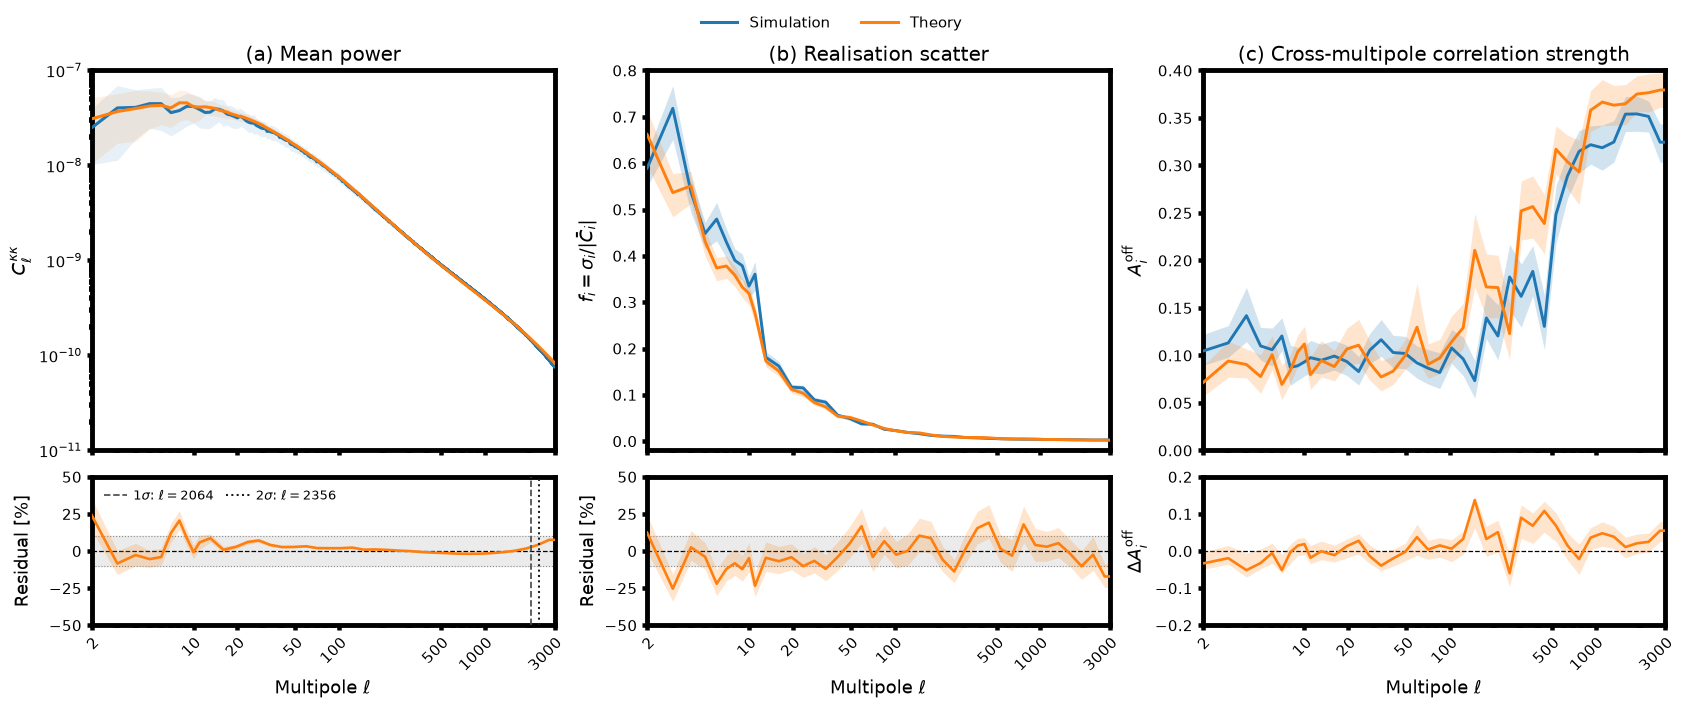

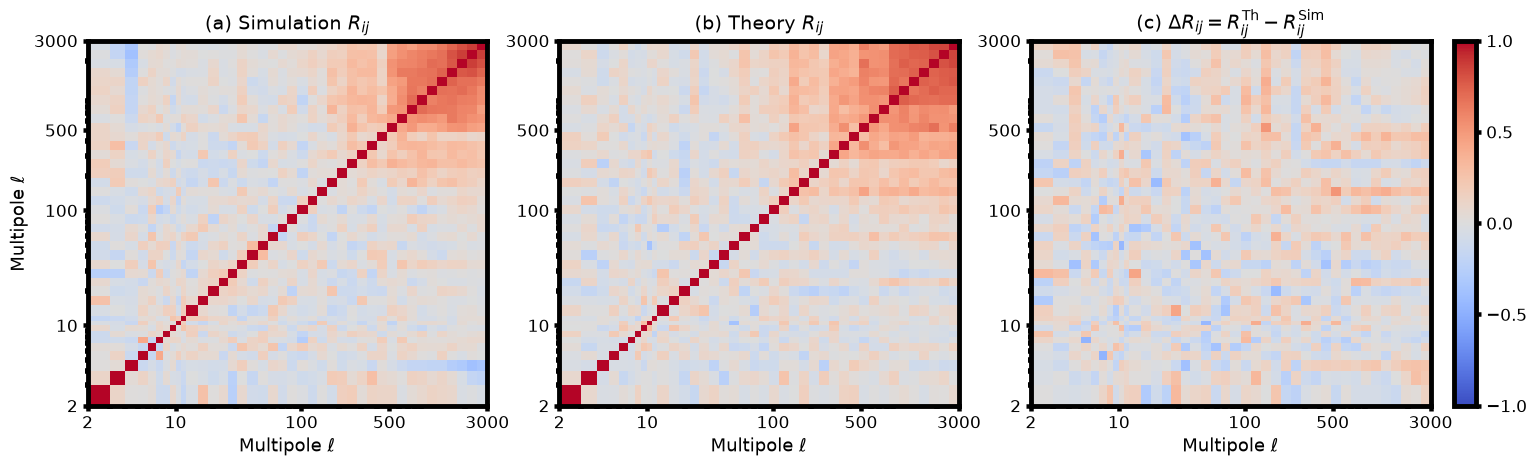


UNIQUE OFF-DIAGONAL CORRELATION-DIFFERENCE DISTRIBUTION (i < j)
Number of unique multipole pairs : 780
Median Delta R_ij                : +0.0255
Mean Delta R_ij                  : +0.0234
RMS Delta R_ij                   : 0.1420
Central 68% Delta R_ij range     : [-0.1134, +0.1546]
Central 95% Delta R_ij range     : [-0.2436, +0.2999]
Median |Delta R_ij|              : 0.0922
68th percentile |Delta R_ij|     : 0.1381
95th percentile |Delta R_ij|     : 0.2812
Maximum |Delta R_ij|             : 0.5191


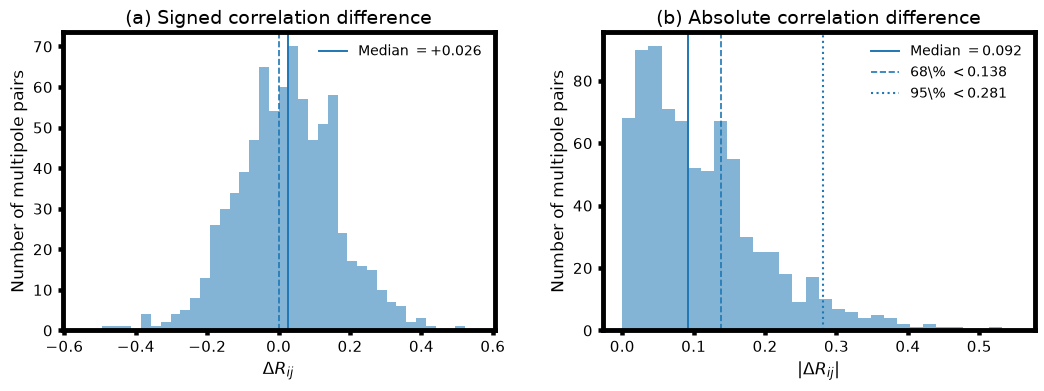


[PERMUTATION] 5000 random 100/100 relabellings

GLOBAL CORRELATION-STRUCTURE PERMUTATION TEST
Observed off-diagonal RMS(Delta R) : 0.1420
Null median RMS                    : 0.1338
Null 68th percentile               : 0.1373
Null 95th percentile               : 0.1467
Null 99th percentile               : 0.1525
Observed statistic percentile      : 86.10%
Permutation p-value                : 0.139172


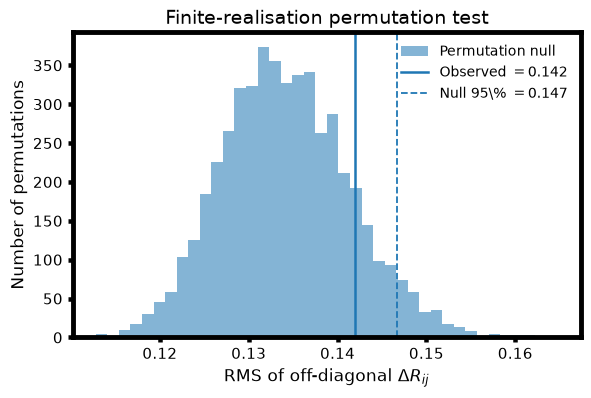


MAIN-TEXT STOCHASTICITY COMPARISON
Residual convention: 100 * (Theory / Simulation - 1)
Mean-power bins within +/-10%: 92.5%
Fractional-RMS bins within +/-10%: 60.0%
Median mean-power residual: +1.43%
Sigma-departure search grid: individual multipoles, sustained length = 20
First >1 sigma Theory-mean departure from Simulation scatter: ell = 1900
First >2 sigma Theory-mean departure from Simulation scatter: ell = 2180
Maximum consecutive >1 sigma run: 937 multipoles (ell = 2064 to 3000)
Maximum consecutive >2 sigma run: 623 multipoles (ell = 2378 to 3000)
Sustained >1 sigma Theory-mean departure from Simulation scatter (20 multipoles): ell = 2064
Sustained >2 sigma Theory-mean departure from Simulation scatter (20 multipoles): ell = 2356
Median fractional-RMS residual: -3.47%
Median coherence difference (Theory - Simulation): +0.0140
Maximum |Delta R_ij|: 0.5191
Note: grey +/-10% bands are visual accuracy targets, not confidence intervals.


In [6]:
# ============================================================
# PAPER-READY POWER-SPECTRUM AND STOCHASTICITY COMPARISON
# ============================================================
# Expected upstream objects:
#   TARGET_POWER_NPZ, SIMULATION_POWER_NPZ
# Optional upstream helper:
#   load_npz_product(path)
#
# Main-text version: exactly two paper figures.
#
# Figure 1 compresses the validation into three physical questions:
#   (a) Does the mean power agree?
#   (b) Does the realisation-to-realisation scatter agree?
#   (c) Does the cross-bin coherence agree?
# Each comparison is centred on zero in the lower panel.
#
# Figure 2 shows the full cross-multipole correlation structure:
#   R_ij^Simulation, R_ij^Theory, and Delta R_ij = Theory - Simulation.
#
# Uncertainty philosophy:
#   - bootstrap whole realisations, does not individual ell bins
#   - show 68% bootstrap intervals in the main-text figure
#   - +/-10% is a visual agreement target, not a confidence interval
#   - axes expand automatically rather than clipping discrepant points
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm, SymLogNorm
from matplotlib.ticker import NullFormatter


# ============================================================
# Configuration
# ============================================================

THEORY_PS_PATH = TARGET_POWER_NPZ
SIM_PS_PATH = SIMULATION_POWER_NPZ

DISPLAY_ELL_MIN = 2
DISPLAY_ELL_MAX = 3000

POWER_YLIM = (1.0e-11, 1.0e-7)
AGREEMENT_TARGET_PCT = 10.0
MIN_PERCENT_RESIDUAL_LIM = 12.0
MIN_COHERENCE_DIFF_LIM = 0.05
MIN_CORR_DIFF_LIM = 0.10

# Sustained significance criterion for the mean-power comparison.
SUSTAINED_N_MULTIPOLES = 20

POWER_TICKS = np.array([2, 10, 20, 50, 100, 500, 1000, 3000], dtype=float)
MATRIX_TICKS = np.array([2, 10, 100, 500, 3000], dtype=float)

# Bootstrap. 5000 is suitable for final figures; use 1000 while developing.
N_BOOTSTRAP = 5000
BOOTSTRAP_SEED = 20260901
CI_INNER = (16.0, 84.0)      # central 68%
CI_OUTER = (2.5, 97.5)       # central 95%

# Permutation null test for the full correlation structure.
# 5000 is suitable for a stable paper diagnostic; reduce while developing.
N_PERMUTATIONS = 5000
PERMUTATION_SEED = 20260902

# Numerical regularisation only for matrix diagnostics.
EPS = np.finfo(float).eps

# If True, save vector-quality PDFs and PNG previews.
SAVE_FIGURES = False
FIGURE_DIR = Path("stochasticity_figures")

# Figure typography.  Keep these explicit so the figure is not affected by
# external matplotlib rcParams used elsewhere in the analysis.
FIG_TITLE_SIZE = 14.0
PANEL_TITLE_SIZE = 14.5
AXIS_LABEL_SIZE = 13.0
TICK_LABEL_SIZE = 11.0
SHARED_LEGEND_SIZE = 11.0
SMALL_LEGEND_SIZE = 9.5



# ============================================================
# Small standalone helpers
# ============================================================

def _load_npz(path):
    """Use an upstream loader if available, otherwise np.load."""
    if "load_npz_product" in globals():
        return load_npz_product(path)
    return np.load(path, allow_pickle=True)


def cov_to_corr(cov):
    cov = np.asarray(cov, dtype=float)
    std = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    denom = np.outer(std, std)
    out = np.zeros_like(cov)
    np.divide(cov, denom, out=out, where=denom > 0.0)
    np.fill_diagonal(out, 1.0)
    return np.clip(out, -1.0, 1.0)


def row_offdiag_rms(corr):
    corr = np.asarray(corr, dtype=float)
    p = corr.shape[0]
    if p < 2:
        return np.full(p, np.nan)
    sq = corr**2
    return np.sqrt((np.sum(sq, axis=1) - np.diag(sq)) / (p - 1))


def safe_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full(np.broadcast_shapes(num.shape, den.shape), np.nan, dtype=float)
    np.divide(num, den, out=out, where=np.abs(den) > EPS)
    return out


def band_statistics(band):
    """Statistics defining the ensemble stochasticity of band powers."""
    band = np.asarray(band, dtype=float)
    mean = np.mean(band, axis=0)
    cov = np.cov(band, rowvar=False, ddof=1)
    sigma = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    frms = safe_ratio(sigma, np.abs(mean))
    corr = cov_to_corr(cov)
    coherence = row_offdiag_rms(corr)
    fractional_cov = safe_ratio(cov, np.outer(mean, mean))
    return {
        "mean": mean,
        "cov": cov,
        "sigma": sigma,
        "frms": frms,
        "corr": corr,
        "coherence": coherence,
        "fractional_cov": fractional_cov,
    }


def percentile_interval(samples, inner=CI_INNER, outer=CI_OUTER):
    """Median plus central 68% and 95% percentile intervals."""
    q = np.nanpercentile(
        samples,
        [outer[0], inner[0], 50.0, inner[1], outer[1]],
        axis=0,
    )
    return {
        "lo95": q[0],
        "lo68": q[1],
        "median": q[2],
        "hi68": q[3],
        "hi95": q[4],
    }


def bootstrap_ensemble(band, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    """
    Non-parametric bootstrap over whole realisations.

    This preserves the cross-bin dependence inside each realisation.
    """
    band = np.asarray(band, dtype=float)
    n_real, n_bin = band.shape
    rng = np.random.default_rng(seed)

    means = np.empty((n_boot, n_bin))
    frms = np.empty((n_boot, n_bin))
    coherence = np.empty((n_boot, n_bin))
    corrs = np.empty((n_boot, n_bin, n_bin))
    fcovs = np.empty((n_boot, n_bin, n_bin))

    for b in range(n_boot):
        idx = rng.integers(0, n_real, size=n_real)
        s = band_statistics(band[idx])
        means[b] = s["mean"]
        frms[b] = s["frms"]
        coherence[b] = s["coherence"]
        corrs[b] = s["corr"]
        fcovs[b] = s["fractional_cov"]

    return {
        "mean": means,
        "frms": frms,
        "coherence": coherence,
        "corr": corrs,
        "fractional_cov": fcovs,
    }



def offdiag_rms_difference(r_a, r_b):
    """
    RMS difference between two correlation matrices using only unique
    off-diagonal multipole pairs (i < j).
    """
    r_a = np.asarray(r_a, dtype=float)
    r_b = np.asarray(r_b, dtype=float)
    if r_a.shape != r_b.shape or r_a.ndim != 2 or r_a.shape[0] != r_a.shape[1]:
        raise ValueError("Correlation matrices must be square and have matching shapes.")

    iu = np.triu_indices_from(r_a, k=1)
    diff = r_b[iu] - r_a[iu]
    diff = diff[np.isfinite(diff)]
    if diff.size == 0:
        return np.nan
    return float(np.sqrt(np.mean(diff**2)))


def permutation_correlation_rms_test(
    sim_band,
    theory_band,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
):
    """
    Permutation null test for the global difference between two correlation
    matrices.

    Null hypothesis:
        Simulation and Theory realisations are exchangeable with respect to
        their cross-multipole correlation structure.

    Procedure:
        1. Pool all realisation vectors.
        2. Randomly relabel them into groups with the original sample sizes.
        3. Recompute each group's correlation matrix.
        4. Record the RMS correlation difference over unique off-diagonal
           multipole pairs (i < j).

    Returns the observed statistic, null distribution, percentile thresholds,
    and the one-sided permutation p-value P(T_null >= T_obs).
    """
    sim_band = np.asarray(sim_band, dtype=float)
    theory_band = np.asarray(theory_band, dtype=float)

    if sim_band.ndim != 2 or theory_band.ndim != 2:
        raise ValueError("Input ensembles must be 2D: [realisations, multipoles].")
    if sim_band.shape[1] != theory_band.shape[1]:
        raise ValueError("Simulation and Theory must have the same multipole dimension.")

    n_sim_local = sim_band.shape[0]
    n_theory_local = theory_band.shape[0]

    r_sim_obs = band_statistics(sim_band)["corr"]
    r_theory_obs = band_statistics(theory_band)["corr"]
    t_obs = offdiag_rms_difference(r_sim_obs, r_theory_obs)

    pooled = np.vstack([sim_band, theory_band])
    n_total = pooled.shape[0]
    rng = np.random.default_rng(seed)

    null_rms = np.empty(n_perm, dtype=float)

    for p in range(n_perm):
        perm = rng.permutation(n_total)
        idx_sim = perm[:n_sim_local]
        idx_theory = perm[n_sim_local:n_sim_local + n_theory_local]

        r_sim_p = band_statistics(pooled[idx_sim])["corr"]
        r_theory_p = band_statistics(pooled[idx_theory])["corr"]

        null_rms[p] = offdiag_rms_difference(r_sim_p, r_theory_p)

    # +1 correction avoids p=0 for a finite number of permutations.
    p_value = (1.0 + np.sum(null_rms >= t_obs)) / (n_perm + 1.0)

    thresholds = {
        "p50": float(np.percentile(null_rms, 50.0)),
        "p68": float(np.percentile(null_rms, 68.0)),
        "p95": float(np.percentile(null_rms, 95.0)),
        "p99": float(np.percentile(null_rms, 99.0)),
    }
    observed_percentile = 100.0 * float(np.mean(null_rms <= t_obs))

    return {
        "observed_rms": float(t_obs),
        "null_rms": null_rms,
        "p_value": float(p_value),
        "observed_percentile": observed_percentile,
        **thresholds,
    }


def fisher_z_difference(r_sim, r_theory, n_sim, n_theory):
    """
    Approximate element-wise significance of independent correlations.
    Diagonal is explicitly set to zero.
    """
    lim = 1.0 - 1.0e-12
    z_sim = np.arctanh(np.clip(r_sim, -lim, lim))
    z_theory = np.arctanh(np.clip(r_theory, -lim, lim))
    se = np.sqrt(1.0 / (n_sim - 3.0) + 1.0 / (n_theory - 3.0))
    z_diff = (z_sim - z_theory) / se
    np.fill_diagonal(z_diff, 0.0)
    return z_diff


def bootstrap_two_sample_comparison(sim_boot, theory_boot):
    """
    Pointwise two-sample discrepancies.

    ratio > 1 means Theory has a larger statistic than Simulation.
    Differences are Theory - Simulation.
    """
    return {
        "mean_ratio": safe_ratio(theory_boot["mean"], sim_boot["mean"]),
        "frms_ratio": safe_ratio(theory_boot["frms"], sim_boot["frms"]),
        "coherence_diff": theory_boot["coherence"] - sim_boot["coherence"],
        "corr_diff": theory_boot["corr"] - sim_boot["corr"],
        "fcov_diff": theory_boot["fractional_cov"] - sim_boot["fractional_cov"],
    }


def _active_ticks(ticks, xmin, xmax):
    return ticks[(ticks >= xmin) & (ticks <= xmax)]


def format_log_ell_axis(ax, ticks=POWER_TICKS):
    active = _active_ticks(ticks, DISPLAY_ELL_MIN, DISPLAY_ELL_MAX)
    ax.set_xscale("log")
    ax.set_xlim(DISPLAY_ELL_MIN, DISPLAY_ELL_MAX)
    ax.set_xticks(active)
    ax.set_xticklabels([str(int(x)) for x in active])
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_SIZE)
    ax.grid(False)


def format_matrix_axis(ax, bin_edges):
    active = _active_ticks(MATRIX_TICKS, bin_edges[0], bin_edges[-1])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    ax.set_ylim(bin_edges[0], bin_edges[-1])
    ax.set_xticks(active)
    ax.set_yticks(active)
    labels = [str(int(x)) for x in active]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_SIZE)
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(r"Multipole $\ell$", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(r"Multipole $\ell$", fontsize=AXIS_LABEL_SIZE)
    ax.grid(False)


def draw_ci(ax, x, ci, label=None, linewidth=2.0):
    """95% light band + 68% dark band + median line."""
    line, = ax.plot(x, ci["median"], linewidth=linewidth, label=label)
    color = line.get_color()
    ax.fill_between(x, ci["lo95"], ci["hi95"], color=color, alpha=0.10, linewidth=0)
    ax.fill_between(x, ci["lo68"], ci["hi68"], color=color, alpha=0.22, linewidth=0)
    return line


def maybe_save(fig, stem):
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")


# ============================================================
# Load products
# ============================================================

if not Path(THEORY_PS_PATH).exists():
    raise FileNotFoundError(f"Theory product not found: {THEORY_PS_PATH}")
if not Path(SIM_PS_PATH).exists():
    raise FileNotFoundError(f"Simulation product not found: {SIM_PS_PATH}")

th = _load_npz(THEORY_PS_PATH)
sim = _load_npz(SIM_PS_PATH)

theory_ells = np.asarray(th["ells"], dtype=int)
theory_target_mean = np.asarray(th["target_mean"], dtype=float)
theory_cls = np.asarray(th["all_cls"], dtype=float)
B = np.asarray(th["binning_matrix"], dtype=float)
bin_edges = np.asarray(th["correlation_bin_edges"], dtype=float)
ell_eff = np.asarray(th["correlation_bin_ell_eff"], dtype=float)

# Analytic/input theory covariance is kept as an optional diagnostic.
cov_theory_input = np.asarray(th["cov_total"], dtype=float)
R_theory_input = np.asarray(th["correlation_total"], dtype=float)

sim_ells = np.asarray(sim["ells"], dtype=int)
sim_cls_all = np.asarray(sim["all_cls"], dtype=float)

sim_lookup = {int(ell): i for i, ell in enumerate(sim_ells)}
missing = [int(ell) for ell in theory_ells if int(ell) not in sim_lookup]
if missing:
    raise ValueError(f"Simulation does not cover theory ell grid; first missing ell={missing[0]}.")

sim_idx = np.array([sim_lookup[int(ell)] for ell in theory_ells], dtype=int)
sim_cls = sim_cls_all[:, sim_idx]

n_sim = sim_cls.shape[0]
n_theory = theory_cls.shape[0]

# Exact same B is applied to both ensembles.
sim_band = sim_cls @ B.T
theory_band = theory_cls @ B.T

if sim_band.shape[1] != len(ell_eff):
    raise ValueError("Number of band-power bins does not match ell_eff.")

sim_stat = band_statistics(sim_band)
theory_stat = band_statistics(theory_band)

print(f"[ENSEMBLE] Simulation realisations : {n_sim}")
print(f"[ENSEMBLE] Theory realisations     : {n_theory}")
print(f"[ENSEMBLE] Band-power bins         : {sim_band.shape[1]}")


# ============================================================
# Bootstrap stochasticity estimator uncertainty
# ============================================================

print(f"[BOOTSTRAP] {N_BOOTSTRAP} realisation-resampling draws")
sim_boot = bootstrap_ensemble(sim_band, seed=BOOTSTRAP_SEED)
theory_boot = bootstrap_ensemble(theory_band, seed=BOOTSTRAP_SEED + 1)
cmp_boot = bootstrap_two_sample_comparison(sim_boot, theory_boot)

sim_ci = {k: percentile_interval(sim_boot[k]) for k in ("mean", "frms", "coherence")}
theory_ci = {k: percentile_interval(theory_boot[k]) for k in ("mean", "frms", "coherence")}
cmp_ci = {
    "mean_ratio": percentile_interval(cmp_boot["mean_ratio"]),
    "frms_ratio": percentile_interval(cmp_boot["frms_ratio"]),
    "coherence_diff": percentile_interval(cmp_boot["coherence_diff"]),
}


# ============================================================
# Main-text comparison quantities
# ============================================================

# Point estimates. Positive residual means Theory > Simulation.
mean_residual_pct = 100.0 * (safe_ratio(theory_stat["mean"], sim_stat["mean"]) - 1.0)
frms_residual_pct = 100.0 * (safe_ratio(theory_stat["frms"], sim_stat["frms"]) - 1.0)
coherence_diff = theory_stat["coherence"] - sim_stat["coherence"]

# Bootstrap distributions of the same quantities.
mean_residual_boot = 100.0 * (cmp_boot["mean_ratio"] - 1.0)
frms_residual_boot = 100.0 * (cmp_boot["frms_ratio"] - 1.0)
coherence_diff_boot = cmp_boot["coherence_diff"]

mean_residual_ci = percentile_interval(mean_residual_boot)
frms_residual_ci = percentile_interval(frms_residual_boot)
coherence_diff_ci = percentile_interval(coherence_diff_boot)


def draw_ci68(
    ax,
    x,
    point,
    ci,
    label=None,
    linewidth=2.0,
    alpha=0.20,
    zorder=3,
    color=None,
):
    """Draw the point estimate and central 68% bootstrap interval only."""
    line, = ax.plot(
        x,
        point,
        linewidth=linewidth,
        label=label,
        color=color,
        zorder=zorder,
    )
    ax.fill_between(
        x,
        ci["lo68"],
        ci["hi68"],
        color=line.get_color(),
        alpha=alpha,
        linewidth=0,
        zorder=zorder - 1,
    )
    return line


def extend_binned_to_xmax(x, point, ci=None, xmax=DISPLAY_ELL_MAX):
    """
    Visually extend a binned curve to the displayed right-hand boundary.

    The final band value is repeated at xmax.  This changes only the visual
    line/band extent; it does not create a new bin or alter any statistic.
    """
    x = np.asarray(x, dtype=float)
    point = np.asarray(point, dtype=float)

    if x.size == 0 or np.isclose(x[-1], float(xmax)):
        return x, point, ci

    x_ext = np.concatenate([x, [float(xmax)]])
    point_ext = np.concatenate([point, [point[-1]]])

    if ci is None:
        return x_ext, point_ext, None

    ci_ext = {}
    for key, value in ci.items():
        arr = np.asarray(value, dtype=float)
        ci_ext[key] = np.concatenate([arr, [arr[-1]]])

    return x_ext, point_ext, ci_ext


def recenter_ci68_on_point(point, ci):
    """
    Recenter the central 68% bootstrap interval on the plotted point estimate.

    The asymmetric bootstrap half-widths around the bootstrap median are kept,
    but the centre of the displayed band is moved onto the actual curve.
    """
    point = np.asarray(point, dtype=float)
    median = np.asarray(ci["median"], dtype=float)
    lo68 = np.asarray(ci["lo68"], dtype=float)
    hi68 = np.asarray(ci["hi68"], dtype=float)

    out = dict(ci)
    out["lo68"] = point - (median - lo68)
    out["median"] = point.copy()
    out["hi68"] = point + (hi68 - median)
    return out


def symmetric_limit(point, ci, minimum, padding=1.10):
    """Symmetric zero-centred axis limit without clipping the 68% interval."""
    values = np.concatenate([
        np.ravel(np.asarray(point, dtype=float)),
        np.ravel(np.asarray(ci["lo68"], dtype=float)),
        np.ravel(np.asarray(ci["hi68"], dtype=float)),
    ])
    finite = np.abs(values[np.isfinite(values)])
    vmax = float(np.max(finite)) if finite.size else 0.0
    return max(float(minimum), padding * vmax)


def add_percent_target_band(ax, target=AGREEMENT_TARGET_PCT):
    """Visual accuracy target only; this is not a statistical confidence band."""
    span = ax.axhspan(-target, target, color="0.92", zorder=0)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9, zorder=2)
    ax.axhline(+target, color="0.55", linestyle=":", linewidth=0.8, zorder=1)
    ax.axhline(-target, color="0.55", linestyle=":", linewidth=0.8, zorder=1)
    return span


def first_sustained_crossing(x, z, threshold, n_consecutive=SUSTAINED_N_MULTIPOLES):
    """Return the first x where |z| exceeds threshold for n consecutive multipoles.

    The returned x is the multipole of the first point in the run.
    Returns (None, None) if no such run is found.
    """
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)
    above = np.isfinite(z) & (np.abs(z) > float(threshold))

    if n_consecutive < 1:
        raise ValueError("n_consecutive must be >= 1.")
    if above.size < n_consecutive:
        return None, None

    run = np.convolve(above.astype(int), np.ones(n_consecutive, dtype=int), mode="valid")
    hits = np.flatnonzero(run == n_consecutive)
    if hits.size == 0:
        return None, None

    idx = int(hits[0])
    return float(x[idx]), idx


def first_threshold_crossing(x, z, threshold):
    """Return the first x where |z| exceeds threshold, irrespective of persistence."""
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)
    hits = np.flatnonzero(np.isfinite(z) & (np.abs(z) > float(threshold)))
    if hits.size == 0:
        return None, None
    idx = int(hits[0])
    return float(x[idx]), idx


def maximum_consecutive_run(x, z, threshold):
    """Return the longest consecutive run with |z| > threshold.

    Returns
    -------
    run_length : int
        Number of consecutive multipoles in the longest run.
    ell_start : float or None
        First multipole in that run.
    ell_end : float or None
        Last multipole in that run.
    """
    x = np.asarray(x, dtype=float)
    z = np.asarray(z, dtype=float)
    above = np.isfinite(z) & (np.abs(z) > float(threshold))

    best_len = 0
    best_start = None
    current_len = 0
    current_start = None

    for i, flag in enumerate(above):
        if flag:
            if current_len == 0:
                current_start = i
            current_len += 1
            if current_len > best_len:
                best_len = current_len
                best_start = current_start
        else:
            current_len = 0
            current_start = None

    if best_len == 0 or best_start is None:
        return 0, None, None

    best_end = best_start + best_len - 1
    return int(best_len), float(x[best_start]), float(x[best_end])


# The mean-power sigma-departure diagnostic is intentionally computed later
# on the native multipole grid (one value per ell), not on band powers.


# ============================================================
# Full-ell power-spectrum products for panel (a)
# ============================================================

plot_mask = (theory_ells >= DISPLAY_ELL_MIN) & (theory_ells <= DISPLAY_ELL_MAX)
ells_plot = theory_ells[plot_mask]

sim_mean_ell = np.mean(sim_cls, axis=0)
theory_mean_ell = np.mean(theory_cls, axis=0)
sim_std_ell = np.std(sim_cls, axis=0, ddof=1)
theory_std_ell = np.std(theory_cls, axis=0, ddof=1)

# ------------------------------------------------------------
# Native-multipole sigma departure for the mean power spectrum
# ------------------------------------------------------------
# This is evaluated at every individual multipole ell, not at ell_eff bins:
#   Z_ell = (Cbar_ell^Theory - Cbar_ell^Simulation) / sigma_ell^Simulation.
# The sustained criterion requires the threshold to be exceeded at
# SUSTAINED_N_MULTIPOLES consecutive multipoles within the displayed range.
mean_diff_ell = theory_mean_ell - sim_mean_ell
mean_diff_in_sim_sigma_ell = safe_ratio(mean_diff_ell, sim_std_ell)

ells_sig = theory_ells[plot_mask]
z_sig = mean_diff_in_sim_sigma_ell[plot_mask]

ell_1sigma_sustained, idx_1sigma_sustained = first_sustained_crossing(
    ells_sig, z_sig, threshold=1.0, n_consecutive=SUSTAINED_N_MULTIPOLES
)
ell_2sigma_sustained, idx_2sigma_sustained = first_sustained_crossing(
    ells_sig, z_sig, threshold=2.0, n_consecutive=SUSTAINED_N_MULTIPOLES
)

ell_1sigma_first, idx_1sigma_first = first_threshold_crossing(ells_sig, z_sig, threshold=1.0)
ell_2sigma_first, idx_2sigma_first = first_threshold_crossing(ells_sig, z_sig, threshold=2.0)

maxrun_1sigma, maxrun_1sigma_start, maxrun_1sigma_end = maximum_consecutive_run(
    ells_sig, z_sig, threshold=1.0
)
maxrun_2sigma, maxrun_2sigma_start, maxrun_2sigma_end = maximum_consecutive_run(
    ells_sig, z_sig, threshold=2.0
)


# ############################################################
# FIGURE 1
# Mean power, stochastic amplitude, and stochastic coherence
# ############################################################
# Top row: physical quantities.
# Bottom row: zero-centred Simulation/Theory discrepancies.
# The grey +/-10% region is an accuracy target, not an error bar.
# ############################################################

fig = plt.figure(figsize=(17.2, 7.6))

# All three columns use the same two-panel grammar:
#   top    : the statistic itself
#   bottom : Theory-versus-Simulation discrepancy
outer = fig.add_gridspec(
    1, 3,
    width_ratios=[1.0, 1.0, 1.0],
    wspace=0.20,
)

gs_power = outer[0, 0].subgridspec(2, 1, height_ratios=[3.2, 1.25], hspace=0.10)
gs_frms  = outer[0, 1].subgridspec(2, 1, height_ratios=[3.2, 1.25], hspace=0.10)
gs_coh   = outer[0, 2].subgridspec(2, 1, height_ratios=[3.2, 1.25], hspace=0.10)

ax_power   = fig.add_subplot(gs_power[0, 0])
ax_power_r = fig.add_subplot(gs_power[1, 0], sharex=ax_power)
ax_frms    = fig.add_subplot(gs_frms[0, 0])
ax_frms_r  = fig.add_subplot(gs_frms[1, 0], sharex=ax_frms)
ax_coh     = fig.add_subplot(gs_coh[0, 0])
ax_coh_r   = fig.add_subplot(gs_coh[1, 0], sharex=ax_coh)

# ------------------------------------------------------------
# (a) Mean power spectrum
# ------------------------------------------------------------

sim_line, = ax_power.plot(
    ells_plot, sim_mean_ell[plot_mask], linewidth=2.2, label="Simulation", zorder=4,
)
th_line, = ax_power.plot(
    ells_plot, theory_mean_ell[plot_mask], linewidth=2.2, label="Theory", zorder=5,
)

# Realisation-to-realisation 1-sigma scatter, not error on the mean.
ax_power.fill_between(
    ells_plot,
    np.maximum(sim_mean_ell[plot_mask] - sim_std_ell[plot_mask], 1.0e-300),
    sim_mean_ell[plot_mask] + sim_std_ell[plot_mask],
    color=sim_line.get_color(), alpha=0.11, linewidth=0, zorder=1,
)
ax_power.fill_between(
    ells_plot,
    np.maximum(theory_mean_ell[plot_mask] - theory_std_ell[plot_mask], 1.0e-300),
    theory_mean_ell[plot_mask] + theory_std_ell[plot_mask],
    color=th_line.get_color(), alpha=0.11, linewidth=0, zorder=2,
)

ax_power.set_yscale("log")
ax_power.set_ylim(*POWER_YLIM)
ax_power.set_ylabel(r"$C_\ell^{\kappa\kappa}$", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_power.set_title(r"(a) Mean power", loc="center", fontsize=PANEL_TITLE_SIZE, pad=7)

# Percentage residual.  The vertical lines mark the sustained 1-sigma and
# 2-sigma departures determined on the native multipole grid.
power_target_patch = add_percent_target_band(ax_power_r)

x_power_r, y_power_r, ci_power_r = extend_binned_to_xmax(
    ell_eff,
    mean_residual_pct,
    mean_residual_ci,
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_power_r,
    x_power_r,
    y_power_r,
    ci_power_r,
    linewidth=1.9,
    alpha=0.20,
    color=th_line.get_color(),
)
ax_power_r.set_ylim(-50.0, 50.0)
ax_power_r.set_ylabel(r"Residual [%]", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_power_r.set_xlabel(r"Multipole $\ell$", fontsize=AXIS_LABEL_SIZE, labelpad=4)

power_resid_handles = []
power_resid_labels = []
if ell_1sigma_sustained is not None:
    h1 = ax_power_r.axvline(
        ell_1sigma_sustained, color="0.30", linestyle="--", linewidth=1.25, zorder=6,
    )
    power_resid_handles.append(h1)
    power_resid_labels.append(rf"$1\sigma$: $\ell={ell_1sigma_sustained:.0f}$")
if ell_2sigma_sustained is not None:
    h2 = ax_power_r.axvline(
        ell_2sigma_sustained, color="0.10", linestyle=":", linewidth=1.45, zorder=6,
    )
    power_resid_handles.append(h2)
    power_resid_labels.append(rf"$2\sigma$: $\ell={ell_2sigma_sustained:.0f}$")
if power_resid_handles:
    ax_power_r.legend(
        power_resid_handles,
        power_resid_labels,
        frameon=False,
        loc="upper left",
        fontsize=SMALL_LEGEND_SIZE,
        ncol=2,
        handlelength=1.8,
        columnspacing=0.9,
        handletextpad=0.45,
        borderaxespad=0.5,
    )

# ------------------------------------------------------------
# (b) Fractional stochastic amplitude
# ------------------------------------------------------------

x_frms_sim, y_frms_sim, ci_frms_sim = extend_binned_to_xmax(
    ell_eff,
    sim_stat["frms"],
    sim_ci["frms"],
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_frms,
    x_frms_sim,
    y_frms_sim,
    ci_frms_sim,
    label="Simulation",
    linewidth=2.1,
    color=sim_line.get_color(),
)

x_frms_th, y_frms_th, ci_frms_th = extend_binned_to_xmax(
    ell_eff,
    theory_stat["frms"],
    theory_ci["frms"],
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_frms,
    x_frms_th,
    y_frms_th,
    ci_frms_th,
    label="Theory",
    linewidth=2.1,
    color=th_line.get_color(),
)
ax_frms.set_ylabel(r"$f_i=\sigma_i/|\bar C_i|$", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_frms.set_title(r"(b) Realisation scatter", loc="center", fontsize=PANEL_TITLE_SIZE, pad=7)
ax_frms.set_ylim(-0.02, 0.8)

frms_target_patch = add_percent_target_band(ax_frms_r)

x_frms_r, y_frms_r, ci_frms_r = extend_binned_to_xmax(
    ell_eff,
    frms_residual_pct,
    frms_residual_ci,
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_frms_r,
    x_frms_r,
    y_frms_r,
    ci_frms_r,
    linewidth=1.9,
    alpha=0.20,
    color=th_line.get_color(),
)
ax_frms_r.set_ylim(-50.0, 50.0)
ax_frms_r.set_ylabel(r"Residual [%]", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_frms_r.set_xlabel(r"Multipole $\ell$", fontsize=AXIS_LABEL_SIZE, labelpad=4)

# ------------------------------------------------------------
# (c) Cross-multipole correlation strength
# ------------------------------------------------------------

sim_coh_ci_centered = recenter_ci68_on_point(
    sim_stat["coherence"],
    sim_ci["coherence"],
)
x_coh_sim, y_coh_sim, ci_coh_sim = extend_binned_to_xmax(
    ell_eff,
    sim_stat["coherence"],
    sim_coh_ci_centered,
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_coh,
    x_coh_sim,
    y_coh_sim,
    ci_coh_sim,
    label="Simulation",
    linewidth=2.1,
    color=sim_line.get_color(),
)

theory_coh_ci_centered = recenter_ci68_on_point(
    theory_stat["coherence"],
    theory_ci["coherence"],
)
x_coh_th, y_coh_th, ci_coh_th = extend_binned_to_xmax(
    ell_eff,
    theory_stat["coherence"],
    theory_coh_ci_centered,
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_coh,
    x_coh_th,
    y_coh_th,
    ci_coh_th,
    label="Theory",
    linewidth=2.1,
    color=th_line.get_color(),
)
ax_coh.set_ylabel(r"$A_i^{\rm off}$", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_coh.set_title(r"(c) Cross-multipole correlation strength", loc="center", fontsize=PANEL_TITLE_SIZE, pad=7)
ax_coh.set_ylim(0.0, 0.4)

ax_coh_r.axhline(0.0, color="black", linestyle="--", linewidth=0.9, zorder=2)

x_coh_r, y_coh_r, ci_coh_r = extend_binned_to_xmax(
    ell_eff,
    coherence_diff,
    coherence_diff_ci,
    xmax=DISPLAY_ELL_MAX,
)
draw_ci68(
    ax_coh_r,
    x_coh_r,
    y_coh_r,
    ci_coh_r,
    linewidth=1.9,
    alpha=0.20,
    color=th_line.get_color(),
)
ax_coh_r.set_ylim(-0.2, 0.2)
ax_coh_r.set_ylabel(r"$\Delta A_i^{\rm off}$", fontsize=AXIS_LABEL_SIZE, labelpad=5)
ax_coh_r.set_xlabel(r"Multipole $\ell$", fontsize=AXIS_LABEL_SIZE, labelpad=4)

for axis in (ax_power, ax_power_r, ax_frms, ax_frms_r, ax_coh, ax_coh_r):
    format_log_ell_axis(axis)

# Hide duplicate x tick labels in the upper panels.
ax_power.tick_params(labelbottom=False)
ax_frms.tick_params(labelbottom=False)
ax_coh.tick_params(labelbottom=False)

# Rotate visible multipole tick labels.
for axis in (ax_power_r, ax_frms_r, ax_coh_r):
    plt.setp(
        axis.get_xticklabels(),
        rotation=45, ha="right", rotation_mode="anchor", fontsize=TICK_LABEL_SIZE,
    )

# Shared Simulation/Theory legend for the full figure.
fig.legend(
    handles=[sim_line, th_line],
    labels=["Simulation", "Theory"],
    loc="upper center", bbox_to_anchor=(0.5, 0.965),
    ncol=2, frameon=False, fontsize=SHARED_LEGEND_SIZE,
    handlelength=2.4, columnspacing=2.0,
)

fig.align_ylabels([ax_power, ax_power_r])
fig.align_ylabels([ax_frms, ax_frms_r])
fig.align_ylabels([ax_coh, ax_coh_r])
fig.subplots_adjust(left=0.070, right=0.985, bottom=0.145, top=0.875)
maybe_save(fig, "fig01_main_power_stochasticity_optionA")
plt.show()


# ############################################################
# FIGURE 2
# Full cross-multipole correlation structure
# ############################################################
# This block is styled independently from Figure 1.
# Both correlation and difference colour scales are fixed to [-1, +1].
# ############################################################

R_sim = sim_stat["corr"]
R_theory = theory_stat["corr"]
R_diff = R_theory - R_sim

fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.0))
fig.subplots_adjust(
    left=0.055,
    right=0.905,
    bottom=0.16,
    top=0.89,
    wspace=0.18,
)

# Common colour scale for all three matrices.
MATRIX_VMIN = -1.0
MATRIX_VMAX = 1.0
CBAR_TICKS = [-1.0, -0.5, 0.0, 0.5, 1.0]

im_sim = axes[0].pcolormesh(
    bin_edges, bin_edges, R_sim,
    shading="flat",
    vmin=MATRIX_VMIN, vmax=MATRIX_VMAX,
    cmap="coolwarm",
    rasterized=True,
)

im_theory = axes[1].pcolormesh(
    bin_edges, bin_edges, R_theory,
    shading="flat",
    vmin=MATRIX_VMIN, vmax=MATRIX_VMAX,
    cmap="coolwarm",
    rasterized=True,
)

im_diff = axes[2].pcolormesh(
    bin_edges, bin_edges, R_diff,
    shading="flat",
    vmin=MATRIX_VMIN, vmax=MATRIX_VMAX,
    cmap="coolwarm",
    rasterized=True,
)

for axis in axes:
    format_matrix_axis(axis, bin_edges)

    # Slightly larger tick and axis-label text for this figure only.
    axis.tick_params(axis="both", which="major", labelsize=12)
    axis.xaxis.label.set_size(13)
    axis.yaxis.label.set_size(13)

# Keep the y-axis title only on the left-most panel.
axes[1].set_ylabel("")
axes[2].set_ylabel("")

# Titles centred above each matrix.
axes[0].set_title(r"(a) Simulation $R_{ij}$", loc="center", fontsize=14, pad=8)
axes[1].set_title(r"(b) Theory $R_{ij}$", loc="center", fontsize=14, pad=8)
axes[2].set_title(
    r"(c) $\Delta R_{ij}=R_{ij}^{\rm Th}-R_{ij}^{\rm Sim}$",
    loc="center", fontsize=14, pad=8,
)

# No overall/suptitle.

# One shared full-height colour bar for all three matrices.
# All panels use the same [-1, +1] colour scale.
cax = fig.add_axes([0.920, 0.16, 0.014, 0.73])
cbar = fig.colorbar(im_sim, cax=cax)
cbar.set_ticks(CBAR_TICKS)
cbar.ax.tick_params(labelsize=12)


maybe_save(fig, "fig02_main_correlation")
plt.show()


# ############################################################
# DIAGNOSTIC: distribution of correlation-matrix differences
# ############################################################
# Use only unique off-diagonal multipole pairs (i < j):
#   - diagonal elements are excluded because R_ii = 1 by definition
#   - the lower triangle is excluded because R_ij = R_ji
# ############################################################

upper = np.triu_indices_from(R_diff, k=1)
delta_r_unique = np.asarray(R_diff[upper], dtype=float)
delta_r_unique = delta_r_unique[np.isfinite(delta_r_unique)]
abs_delta_r_unique = np.abs(delta_r_unique)

# Summary statistics.
delta_median = float(np.median(delta_r_unique))
delta_mean = float(np.mean(delta_r_unique))
delta_rms = float(np.sqrt(np.mean(delta_r_unique**2)))
delta_p16, delta_p84 = np.percentile(delta_r_unique, [16, 84])
delta_p2p5, delta_p97p5 = np.percentile(delta_r_unique, [2.5, 97.5])

abs_median = float(np.median(abs_delta_r_unique))
abs_p68 = float(np.percentile(abs_delta_r_unique, 68))
abs_p95 = float(np.percentile(abs_delta_r_unique, 95))
abs_max = float(np.max(abs_delta_r_unique))

print("\n" + "=" * 88)
print("UNIQUE OFF-DIAGONAL CORRELATION-DIFFERENCE DISTRIBUTION (i < j)")
print("=" * 88)
print(f"Number of unique multipole pairs : {delta_r_unique.size}")
print(f"Median Delta R_ij                : {delta_median:+.4f}")
print(f"Mean Delta R_ij                  : {delta_mean:+.4f}")
print(f"RMS Delta R_ij                   : {delta_rms:.4f}")
print(f"Central 68% Delta R_ij range     : [{delta_p16:+.4f}, {delta_p84:+.4f}]")
print(f"Central 95% Delta R_ij range     : [{delta_p2p5:+.4f}, {delta_p97p5:+.4f}]")
print(f"Median |Delta R_ij|              : {abs_median:.4f}")
print(f"68th percentile |Delta R_ij|     : {abs_p68:.4f}")
print(f"95th percentile |Delta R_ij|     : {abs_p95:.4f}")
print(f"Maximum |Delta R_ij|             : {abs_max:.4f}")
print("=" * 88)

# Plot raw Delta R and absolute |Delta R| side by side.
fig_hist, ax_hist = plt.subplots(1, 2, figsize=(10.8, 4.2))
fig_hist.subplots_adjust(
    left=0.085,
    right=0.985,
    bottom=0.17,
    top=0.88,
    wspace=0.25,
)

# Common histogram binning for the signed distribution.
hist_limit = max(0.55, float(np.nanmax(np.abs(delta_r_unique))) * 1.05)
signed_bins = np.linspace(-hist_limit, hist_limit, 41)

ax_hist[0].hist(
    delta_r_unique,
    bins=signed_bins,
    histtype="stepfilled",
    alpha=0.55,
)
ax_hist[0].axvline(0.0, linestyle="--", linewidth=1.2)
ax_hist[0].axvline(delta_median, linestyle="-", linewidth=1.4,
                   label=fr"Median $={delta_median:+.3f}$")
ax_hist[0].set_title(r"(a) Signed correlation difference", fontsize=13.5)
ax_hist[0].set_xlabel(r"$\Delta R_{ij}$", fontsize=12.5)
ax_hist[0].set_ylabel("Number of multipole pairs", fontsize=12.5)
ax_hist[0].tick_params(labelsize=11)
ax_hist[0].legend(frameon=False, fontsize=10)

# Absolute distribution.
abs_bins = np.linspace(0.0, hist_limit, 31)
ax_hist[1].hist(
    abs_delta_r_unique,
    bins=abs_bins,
    histtype="stepfilled",
    alpha=0.55,
)
ax_hist[1].axvline(abs_median, linestyle="-", linewidth=1.4,
                   label=fr"Median $={abs_median:.3f}$")
ax_hist[1].axvline(abs_p68, linestyle="--", linewidth=1.2,
                   label=fr"68\% $<{abs_p68:.3f}$")
ax_hist[1].axvline(abs_p95, linestyle=":", linewidth=1.5,
                   label=fr"95\% $<{abs_p95:.3f}$")
ax_hist[1].set_title(r"(b) Absolute correlation difference", fontsize=13.5)
ax_hist[1].set_xlabel(r"$|\Delta R_{ij}|$", fontsize=12.5)
ax_hist[1].set_ylabel("Number of multipole pairs", fontsize=12.5)
ax_hist[1].tick_params(labelsize=11)
ax_hist[1].legend(frameon=False, fontsize=10)


maybe_save(fig_hist, "fig_corr_difference_histograms")
plt.show()


# ############################################################
# PERMUTATION NULL TEST
# Is the full Simulation-Theory correlation difference larger
# than expected from finite N_realisation sampling?
# ############################################################

print(f"\n[PERMUTATION] {N_PERMUTATIONS} random 100/100 relabellings")
perm_result = permutation_correlation_rms_test(
    sim_band,
    theory_band,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
)

print("\n" + "=" * 88)
print("GLOBAL CORRELATION-STRUCTURE PERMUTATION TEST")
print("=" * 88)
print(f"Observed off-diagonal RMS(Delta R) : {perm_result['observed_rms']:.4f}")
print(f"Null median RMS                    : {perm_result['p50']:.4f}")
print(f"Null 68th percentile               : {perm_result['p68']:.4f}")
print(f"Null 95th percentile               : {perm_result['p95']:.4f}")
print(f"Null 99th percentile               : {perm_result['p99']:.4f}")
print(f"Observed statistic percentile      : {perm_result['observed_percentile']:.2f}%")
print(f"Permutation p-value                : {perm_result['p_value']:.6f}")
print("=" * 88)

# Visualise the null distribution and the actual Simulation-Theory statistic.
fig_perm, ax_perm = plt.subplots(figsize=(6.2, 4.3))
fig_perm.subplots_adjust(left=0.15, right=0.97, bottom=0.17, top=0.88)

ax_perm.hist(
    perm_result["null_rms"],
    bins=40,
    histtype="stepfilled",
    alpha=0.55,
    label="Permutation null",
)
ax_perm.axvline(
    perm_result["observed_rms"],
    linestyle="-",
    linewidth=1.8,
    label=fr"Observed $={perm_result['observed_rms']:.3f}$",
)
ax_perm.axvline(
    perm_result["p95"],
    linestyle="--",
    linewidth=1.3,
    label=fr"Null 95\% $={perm_result['p95']:.3f}$",
)

ax_perm.set_title("Finite-realisation permutation test", fontsize=13.5)
ax_perm.set_xlabel(r"RMS of off-diagonal $\Delta R_{ij}$", fontsize=12.5)
ax_perm.set_ylabel("Number of permutations", fontsize=12.5)
ax_perm.tick_params(labelsize=11)
ax_perm.legend(frameon=False, fontsize=10)

maybe_save(fig_perm, "fig_corr_permutation_rms_null")
plt.show()


# ============================================================
# Compact numerical summary for the paper notes
# ============================================================

inside_10_mean = np.mean(np.abs(mean_residual_pct) <= AGREEMENT_TARGET_PCT)
inside_10_frms = np.mean(np.abs(frms_residual_pct) <= AGREEMENT_TARGET_PCT)

print("\n" + "=" * 88)
print("MAIN-TEXT STOCHASTICITY COMPARISON")
print("=" * 88)
print("Residual convention: 100 * (Theory / Simulation - 1)")
print(f"Mean-power bins within +/-{AGREEMENT_TARGET_PCT:.0f}%: {100*inside_10_mean:.1f}%")
print(f"Fractional-RMS bins within +/-{AGREEMENT_TARGET_PCT:.0f}%: {100*inside_10_frms:.1f}%")
print(f"Median mean-power residual: {np.nanmedian(mean_residual_pct):+.2f}%")
print(f"Sigma-departure search grid: individual multipoles, sustained length = {SUSTAINED_N_MULTIPOLES}")

if ell_1sigma_first is None:
    print("First >1 sigma Theory-mean departure from Simulation scatter: not found")
else:
    print(f"First >1 sigma Theory-mean departure from Simulation scatter: ell = {ell_1sigma_first:.0f}")

if ell_2sigma_first is None:
    print("First >2 sigma Theory-mean departure from Simulation scatter: not found")
else:
    print(f"First >2 sigma Theory-mean departure from Simulation scatter: ell = {ell_2sigma_first:.0f}")

if maxrun_1sigma == 0:
    print("Maximum consecutive >1 sigma run: 0 multipoles")
else:
    print(
        f"Maximum consecutive >1 sigma run: {maxrun_1sigma} multipoles "
        f"(ell = {maxrun_1sigma_start:.0f} to {maxrun_1sigma_end:.0f})"
    )

if maxrun_2sigma == 0:
    print("Maximum consecutive >2 sigma run: 0 multipoles")
else:
    print(
        f"Maximum consecutive >2 sigma run: {maxrun_2sigma} multipoles "
        f"(ell = {maxrun_2sigma_start:.0f} to {maxrun_2sigma_end:.0f})"
    )

if ell_1sigma_sustained is None:
    print(f"Sustained >1 sigma Theory-mean departure from Simulation scatter ({SUSTAINED_N_MULTIPOLES} multipoles): not found")
else:
    print(
        f"Sustained >1 sigma Theory-mean departure from Simulation scatter ({SUSTAINED_N_MULTIPOLES} multipoles): "
        f"ell = {ell_1sigma_sustained:.0f}"
    )
if ell_2sigma_sustained is None:
    print(f"Sustained >2 sigma Theory-mean departure from Simulation scatter ({SUSTAINED_N_MULTIPOLES} multipoles): not found")
else:
    print(
        f"Sustained >2 sigma Theory-mean departure from Simulation scatter ({SUSTAINED_N_MULTIPOLES} multipoles): "
        f"ell = {ell_2sigma_sustained:.0f}"
    )
print(f"Median fractional-RMS residual: {np.nanmedian(frms_residual_pct):+.2f}%")
print(f"Median coherence difference (Theory - Simulation): {np.nanmedian(coherence_diff):+.4f}")
print(f"Maximum |Delta R_ij|: {np.nanmax(np.abs(R_diff)):.4f}")
print("Note: grey +/-10% bands are visual accuracy targets, not confidence intervals.")
print("=" * 88)


## 7. Gaussian sampling vs $\chi^2$ sampling


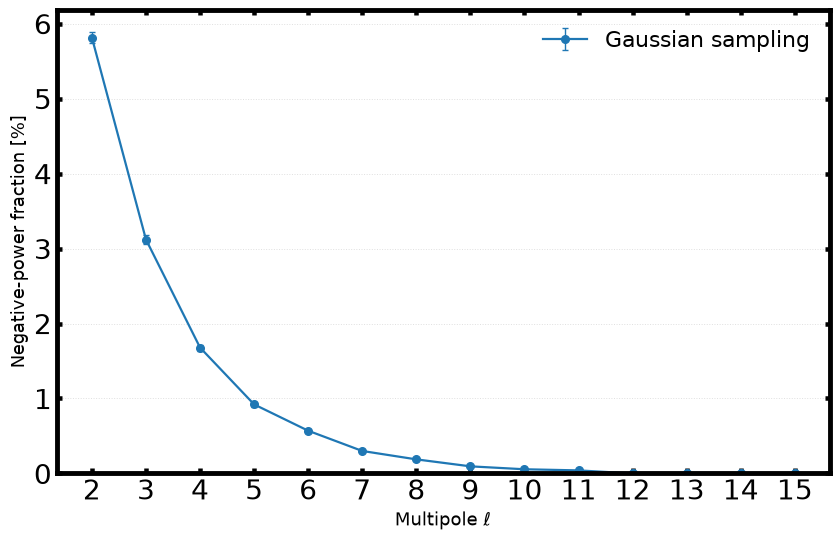


Negative-power fraction
ell= 2 : Gaussian =   5.8130 +/-  0.0740%   chi-square =   0.0000%
ell= 3 : Gaussian =   3.1200 +/-  0.0550%   chi-square =   0.0000%
ell= 4 : Gaussian =   1.6790 +/-  0.0406%   chi-square =   0.0000%
ell= 5 : Gaussian =   0.9210 +/-  0.0302%   chi-square =   0.0000%
ell= 6 : Gaussian =   0.5700 +/-  0.0238%   chi-square =   0.0000%
ell= 7 : Gaussian =   0.3000 +/-  0.0173%   chi-square =   0.0000%
ell= 8 : Gaussian =   0.1880 +/-  0.0137%   chi-square =   0.0000%
ell= 9 : Gaussian =   0.0950 +/-  0.0097%   chi-square =   0.0000%
ell=10 : Gaussian =   0.0560 +/-  0.0075%   chi-square =   0.0000%
ell=11 : Gaussian =   0.0410 +/-  0.0064%   chi-square =   0.0000%
ell=12 : Gaussian =   0.0000 +/-  0.0000%   chi-square =   0.0000%
ell=13 : Gaussian =   0.0000 +/-  0.0000%   chi-square =   0.0000%
ell=14 : Gaussian =   0.0000 +/-  0.0000%   chi-square =   0.0000%
ell=15 : Gaussian =   0.0000 +/-  0.0000%   chi-square =   0.0000%


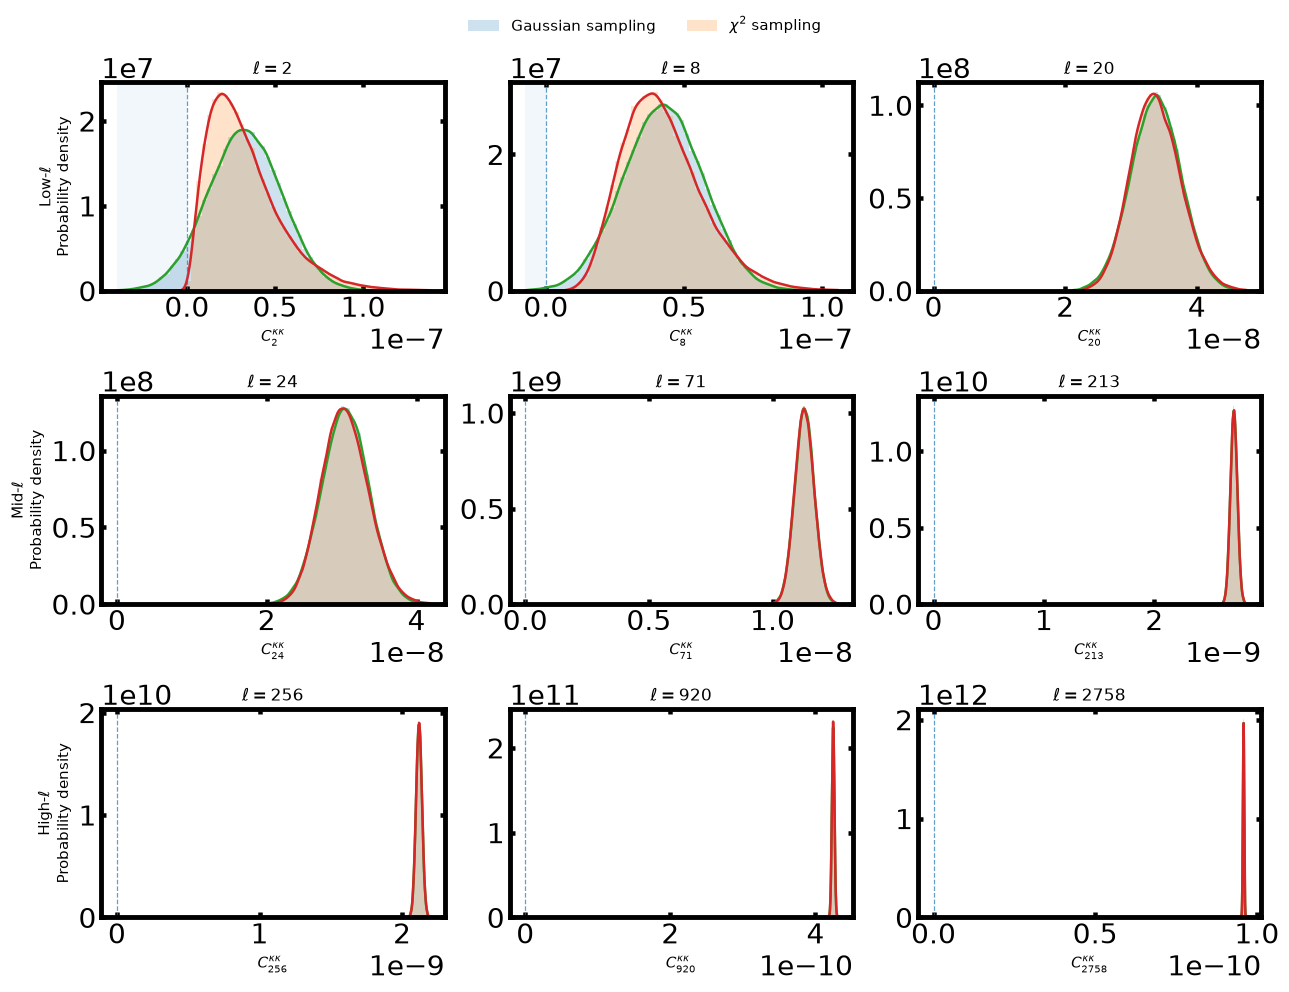


Running bootstrap uncertainty estimation with 300 resamples...

ell =    2 complete
ell =    8 complete
ell =   20 complete
ell =   24 complete
ell =   71 complete
ell =  213 complete
ell =  256 complete
ell =  920 complete
ell = 2758 complete

Bootstrap complete.


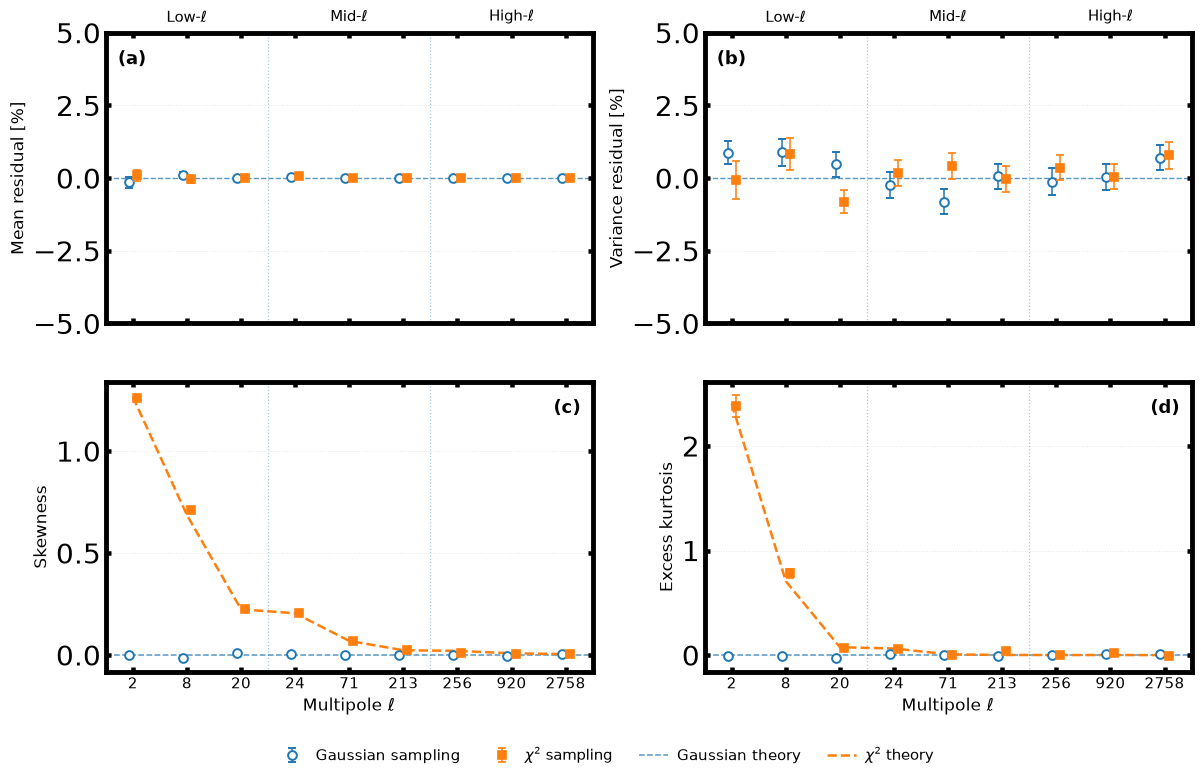


   ell      nu_eff   mean G [%]       err  mean chi2 [%]       err    var G [%]       err   var chi2 [%]       err     skew G       err   skew chi2       err    skew th     kurt G       err   kurt chi2       err    kurt th
     2        4.99      -0.1402    0.1946         0.0898    0.2003       0.8649    0.3942        -0.0644    0.6444    -0.0018    0.0077      1.2597    0.0162     1.2661    -0.0060    0.0151      2.3828    0.1064     2.4044
     8       16.99       0.1059    0.1034        -0.0443    0.1082       0.8954    0.4664         0.8174    0.5538    -0.0128    0.0076      0.7090    0.0105     0.6862    -0.0130    0.0153      0.7834    0.0438     0.7064
    20      159.54       0.0020    0.0353        -0.0096    0.0356       0.4695    0.4410        -0.8062    0.4059     0.0081    0.0075      0.2237    0.0081     0.2239    -0.0238    0.0149      0.0672    0.0188     0.0752
    24      191.43       0.0518    0.0351         0.0674    0.0338      -0.2478    0.4493         0.1815   

In [7]:
# ============================================================
# GAUSSIAN VS CHI-SQUARE SAMPLING VALIDATION
#
# N = 100,000 realisations
#
# Figure 1
#   Negative-power fraction from Gaussian sampling
#   for ell = 2,...,15
#
# Figure 2
#   Gaussian vs chi-square distributions at
#   9 representative multipoles
#
# Figure 3
#   Publication-style 2x2 moment validation:
#
#       (a) Mean residual [%]
#       (b) Variance residual [%]
#       (c) Skewness
#       (d) Excess kurtosis
#
#   Sample measurements:
#       bootstrap 1-sigma error bars
#
#   Theory:
#       Gaussian:
#           skewness = 0
#           excess kurtosis = 0
#
#       chi-square:
#           skewness       = sqrt(8 / nu_eff)
#           excess kurtosis = 12 / nu_eff
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    gaussian_kde,
    skew,
    kurtosis
)


# ============================================================
# SETTINGS
# ============================================================

N_COMPARE = 100_000
COMPARE_SEED = 12345

# Bootstrap uncertainty
N_BOOTSTRAP = 300
BOOTSTRAP_SEED = 54321

# Number of bootstrap realisations processed simultaneously
BOOTSTRAP_CHUNK = 10


# ------------------------------------------------------------
# Representative multipoles
# ------------------------------------------------------------

ELL_GROUPS = {
    "Low":  [2, 8, 20],
    "Mid":  [24, 71, 213],
    "High": [256, 920, 2758],
}

ELLS_COMPARE = np.array(
    [
        2, 8, 20,
        24, 71, 213,
        256, 920, 2758
    ],
    dtype=int
)


# ------------------------------------------------------------
# Negative-power diagnostic
# ------------------------------------------------------------

ELLS_NEGATIVE = np.arange(
    2,
    16
)


# ============================================================
# LOAD THEORY PRODUCT
# ============================================================

th = load_npz_product(
    TARGET_POWER_NPZ
)


theory_ells = np.asarray(
    th["ells"],
    dtype=int
)


target_mean = np.asarray(
    th["target_mean"],
    dtype=float
)


mean_binned = np.asarray(
    th["theory_target_mean_binned"],
    dtype=float
)


cov_total = project_psd(
    np.asarray(
        th["cov_total"],
        dtype=float
    ),
    PSD_RELATIVE_FLOOR
)


bin_ell_min = np.asarray(
    th["correlation_bin_ell_min"],
    dtype=int
)


bin_ell_max = np.asarray(
    th["correlation_bin_ell_max"],
    dtype=int
)


# ============================================================
# EFFECTIVE CHI-SQUARE DEGREES OF FREEDOM
#
# nu_eff = 2 mu^2 / V
# ============================================================

target_variance_binned = np.diag(
    cov_total
)


nu_eff = (
    2.0
    * mean_binned**2
    / target_variance_binned
)


# ============================================================
# GENERATE REALISATIONS
# ============================================================

# ------------------------------------------------------------
# Gaussian sampling
# ------------------------------------------------------------

rng = np.random.default_rng(
    COMPARE_SEED
)


gaussian_binned = rng.multivariate_normal(
    mean_binned,
    cov_total,
    size=N_COMPARE,
    method="eigh"
)


# ------------------------------------------------------------
# Chi-square sampling
# ------------------------------------------------------------

chisquare_binned, _, _, _, _ = chisquare_copula_samples(
    mean_binned,
    cov_total,
    n_samples=N_COMPARE,
    seed=COMPARE_SEED
)


# ============================================================
# HELPER
#
# RECONSTRUCT C_ell FROM BINNED REALISATIONS
#
# Within each bin:
#
# C_ell^(n) =
#     Cbar_ell * C_b^(n) / Cbar_b
# ============================================================

def get_samples_at_ell(ell):

    # --------------------------------------------------------
    # Identify covariance bin
    # --------------------------------------------------------

    matching = np.where(
        (ell >= bin_ell_min)
        & (ell <= bin_ell_max)
    )[0]


    if matching.size != 1:

        raise RuntimeError(
            f"Could not identify a unique covariance bin "
            f"for ell={ell}."
        )


    bin_index = int(
        matching[0]
    )


    # --------------------------------------------------------
    # Identify multipole in mean spectrum
    # --------------------------------------------------------

    ell_matching = np.where(
        theory_ells == ell
    )[0]


    if ell_matching.size != 1:

        raise RuntimeError(
            f"Could not identify ell={ell} "
            f"in theory_ells."
        )


    ell_index = int(
        ell_matching[0]
    )


    # --------------------------------------------------------
    # Mean spectrum
    # --------------------------------------------------------

    mean_C_ell = float(
        target_mean[ell_index]
    )


    mean_C_bin = float(
        mean_binned[bin_index]
    )


    # --------------------------------------------------------
    # Reconstruction factor
    # --------------------------------------------------------

    factor = (
        mean_C_ell
        / mean_C_bin
    )


    # --------------------------------------------------------
    # Reconstructed realisations
    # --------------------------------------------------------

    gaussian_C_ell = (
        factor
        * gaussian_binned[:, bin_index]
    )


    chisquare_C_ell = (
        factor
        * chisquare_binned[:, bin_index]
    )


    # --------------------------------------------------------
    # Theoretical target moments
    # --------------------------------------------------------

    target_mean_ell = (
        mean_C_ell
    )


    target_variance_ell = (
        factor**2
        * cov_total[
            bin_index,
            bin_index
        ]
    )


    return (
        gaussian_C_ell,
        chisquare_C_ell,
        bin_index,
        target_mean_ell,
        target_variance_ell
    )


# ============================================================
# BOOTSTRAP MOMENT UNCERTAINTIES
#
# Returns bootstrap 1-sigma uncertainty in:
#
#   mean
#   variance
#   skewness
#   excess kurtosis
# ============================================================

def bootstrap_moment_errors(
    samples,
    n_bootstrap=300,
    seed=0,
    chunk_size=10
):

    samples = np.asarray(
        samples,
        dtype=float
    )


    n_samples = samples.size


    rng_boot = np.random.default_rng(
        seed
    )


    boot_mean = np.empty(
        n_bootstrap,
        dtype=float
    )

    boot_var = np.empty(
        n_bootstrap,
        dtype=float
    )

    boot_skew = np.empty(
        n_bootstrap,
        dtype=float
    )

    boot_kurt = np.empty(
        n_bootstrap,
        dtype=float
    )


    start = 0


    while start < n_bootstrap:

        stop = min(
            start + chunk_size,
            n_bootstrap
        )


        n_this = stop - start


        # ----------------------------------------------------
        # Bootstrap resampling
        # ----------------------------------------------------

        indices = rng_boot.integers(
            0,
            n_samples,
            size=(
                n_this,
                n_samples
            )
        )


        resampled = samples[
            indices
        ]


        # ----------------------------------------------------
        # Moments
        # ----------------------------------------------------

        boot_mean[
            start:stop
        ] = np.mean(
            resampled,
            axis=1
        )


        boot_var[
            start:stop
        ] = np.var(
            resampled,
            axis=1,
            ddof=1
        )


        boot_skew[
            start:stop
        ] = skew(
            resampled,
            axis=1,
            bias=False
        )


        boot_kurt[
            start:stop
        ] = kurtosis(
            resampled,
            axis=1,
            fisher=True,
            bias=False
        )


        start = stop


    return (
        np.std(
            boot_mean,
            ddof=1
        ),
        np.std(
            boot_var,
            ddof=1
        ),
        np.std(
            boot_skew,
            ddof=1
        ),
        np.std(
            boot_kurt,
            ddof=1
        )
    )


# ============================================================
# FIGURE 1
#
# NEGATIVE POWER FROM GAUSSIAN SAMPLING
# ============================================================

negative_fraction_G = []
negative_fraction_X = []


for ell in ELLS_NEGATIVE:

    G, X, _, _, _ = get_samples_at_ell(
        ell
    )


    negative_fraction_G.append(
        100.0
        * np.mean(
            G < 0.0
        )
    )


    negative_fraction_X.append(
        100.0
        * np.mean(
            X < 0.0
        )
    )


negative_fraction_G = np.asarray(
    negative_fraction_G
)


negative_fraction_X = np.asarray(
    negative_fraction_X
)


# ------------------------------------------------------------
# Binomial uncertainty on Gaussian negative fraction
#
# p is expressed as fraction here, then converted to %
# ------------------------------------------------------------

p_negative = (
    negative_fraction_G
    / 100.0
)


negative_fraction_err_G = (
    100.0
    * np.sqrt(
        p_negative
        * (1.0 - p_negative)
        / N_COMPARE
    )
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


ax.errorbar(
    ELLS_NEGATIVE,
    negative_fraction_G,
    yerr=negative_fraction_err_G,
    fmt="o-",
    markersize=5.5,
    linewidth=1.6,
    elinewidth=1.0,
    capsize=2.5,
    label="Gaussian sampling"
)


ax.axhline(
    0.0,
    linewidth=1.0,
    linestyle="--",
    alpha=0.6
)


ax.set_xlabel(
    r"Multipole $\ell$",
    fontsize=13
)


ax.set_ylabel(
    "Negative-power fraction [%]",
    fontsize=13
)


ax.set_xticks(
    ELLS_NEGATIVE
)


ax.set_ylim(
    bottom=0.0
)


ax.tick_params(
    direction="in",
    top=True,
    right=True
)


ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)


ax.legend(
    frameon=False
)


plt.tight_layout()

plt.show()


# ============================================================
# NEGATIVE-POWER NUMERICAL SUMMARY
# ============================================================

print()
print("Negative-power fraction")
print("=" * 72)


for ell, fG, eG, fX in zip(
    ELLS_NEGATIVE,
    negative_fraction_G,
    negative_fraction_err_G,
    negative_fraction_X
):

    print(
        f"ell={ell:2d} : "
        f"Gaussian = {fG:8.4f} +/- {eG:7.4f}%   "
        f"chi-square = {fX:8.4f}%"
    )


print("=" * 72)


# ============================================================
# FIGURE 2
#
# DISTRIBUTION COMPARISON
# ============================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(13.0, 10.0)
)


group_names = [
    "Low",
    "Mid",
    "High"
]


for row, group_name in enumerate(
    group_names
):

    for col, ell in enumerate(
        ELL_GROUPS[group_name]
    ):

        ax = axes[
            row,
            col
        ]


        (
            G,
            X,
            bin_index,
            _,
            _
        ) = get_samples_at_ell(
            ell
        )


        # ----------------------------------------------------
        # Common plotting interval
        # ----------------------------------------------------

        qlo = min(
            np.quantile(
                G,
                0.002
            ),
            np.quantile(
                X,
                0.002
            )
        )


        qhi = max(
            np.quantile(
                G,
                0.998
            ),
            np.quantile(
                X,
                0.998
            )
        )


        pad = (
            0.08
            * (qhi - qlo)
        )


        xmin = qlo - pad
        xmax = qhi + pad


        xgrid = np.linspace(
            xmin,
            xmax,
            1000
        )


        bins = np.linspace(
            xmin,
            xmax,
            60
        )


        # ----------------------------------------------------
        # Negative C_ell region
        # ----------------------------------------------------

        if xmin < 0.0:

            ax.axvspan(
                xmin,
                0.0,
                alpha=0.06,
                zorder=0
            )


        # ----------------------------------------------------
        # Histograms
        # ----------------------------------------------------

        ax.hist(
            G,
            bins=bins,
            density=True,
            alpha=0.22,
            label="Gaussian sampling"
        )


        ax.hist(
            X,
            bins=bins,
            density=True,
            alpha=0.22,
            label=r"$\chi^2$ sampling"
        )


        # ----------------------------------------------------
        # KDE
        # ----------------------------------------------------

        kde_G = gaussian_kde(
            G
        )


        kde_X = gaussian_kde(
            X
        )


        ax.plot(
            xgrid,
            kde_G(xgrid),
            linewidth=1.8
        )


        ax.plot(
            xgrid,
            kde_X(xgrid),
            linewidth=1.8
        )


        # ----------------------------------------------------
        # C_ell = 0
        # ----------------------------------------------------

        ax.axvline(
            0.0,
            linestyle="--",
            linewidth=0.9,
            alpha=0.7
        )


        # ----------------------------------------------------
        # ell title
        # ----------------------------------------------------

        ax.set_title(
            rf"$\ell={ell}$",
            fontsize=12.5
        )


        ax.set_xlabel(
            rf"$C_{{{ell}}}^{{\kappa\kappa}}$",
            fontsize=10.5
        )


        if col == 0:

            ax.set_ylabel(
                f"{group_name}-"
                + r"$\ell$"
                + "\nProbability density",
                fontsize=10.5
            )


        ax.tick_params(
            direction="in",
            top=True,
            right=True
        )


# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)


fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(
        0.5,
        0.995
    ),
    fontsize=11
)


plt.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.955
    ]
)


plt.show()


# ============================================================
# CALCULATE MOMENTS
# ============================================================

mean_G = []
mean_X = []

var_G = []
var_X = []

skew_G = []
skew_X = []

kurt_G = []
kurt_X = []


# ------------------------------------------------------------
# Bootstrap errors
# ------------------------------------------------------------

mean_err_G = []
mean_err_X = []

var_err_G = []
var_err_X = []

skew_err_G = []
skew_err_X = []

kurt_err_G = []
kurt_err_X = []


# ------------------------------------------------------------
# Theory
# ------------------------------------------------------------

mean_target_compare = []
var_target_compare = []

skew_target_X = []
kurt_target_X = []

selected_nu = []


print()
print(
    f"Running bootstrap uncertainty estimation "
    f"with {N_BOOTSTRAP} resamples..."
)
print()


for i, ell in enumerate(
    ELLS_COMPARE
):

    (
        G,
        X,
        bin_index,
        mu_theory,
        var_theory
    ) = get_samples_at_ell(
        ell
    )


    nu = float(
        nu_eff[
            bin_index
        ]
    )


    selected_nu.append(
        nu
    )


    # ========================================================
    # SAMPLE MOMENTS
    # ========================================================

    mean_G.append(
        np.mean(
            G
        )
    )


    mean_X.append(
        np.mean(
            X
        )
    )


    var_G.append(
        np.var(
            G,
            ddof=1
        )
    )


    var_X.append(
        np.var(
            X,
            ddof=1
        )
    )


    skew_G.append(
        skew(
            G,
            bias=False
        )
    )


    skew_X.append(
        skew(
            X,
            bias=False
        )
    )


    kurt_G.append(
        kurtosis(
            G,
            fisher=True,
            bias=False
        )
    )


    kurt_X.append(
        kurtosis(
            X,
            fisher=True,
            bias=False
        )
    )


    # ========================================================
    # THEORY
    # ========================================================

    mean_target_compare.append(
        mu_theory
    )


    var_target_compare.append(
        var_theory
    )


    skew_target_X.append(
        np.sqrt(
            8.0 / nu
        )
    )


    kurt_target_X.append(
        12.0 / nu
    )


    # ========================================================
    # BOOTSTRAP ERROR:
    # GAUSSIAN
    # ========================================================

    (
        e_mean_G,
        e_var_G,
        e_skew_G,
        e_kurt_G
    ) = bootstrap_moment_errors(
        G,
        n_bootstrap=N_BOOTSTRAP,
        seed=(
            BOOTSTRAP_SEED
            + 100 * i
        ),
        chunk_size=BOOTSTRAP_CHUNK
    )


    mean_err_G.append(
        e_mean_G
    )

    var_err_G.append(
        e_var_G
    )

    skew_err_G.append(
        e_skew_G
    )

    kurt_err_G.append(
        e_kurt_G
    )


    # ========================================================
    # BOOTSTRAP ERROR:
    # CHI-SQUARE
    # ========================================================

    (
        e_mean_X,
        e_var_X,
        e_skew_X,
        e_kurt_X
    ) = bootstrap_moment_errors(
        X,
        n_bootstrap=N_BOOTSTRAP,
        seed=(
            BOOTSTRAP_SEED
            + 100 * i
            + 1
        ),
        chunk_size=BOOTSTRAP_CHUNK
    )


    mean_err_X.append(
        e_mean_X
    )

    var_err_X.append(
        e_var_X
    )

    skew_err_X.append(
        e_skew_X
    )

    kurt_err_X.append(
        e_kurt_X
    )


    print(
        f"ell = {ell:4d} complete"
    )


print()
print("Bootstrap complete.")


# ============================================================
# CONVERT TO NUMPY ARRAYS
# ============================================================

mean_G = np.asarray(mean_G)
mean_X = np.asarray(mean_X)

var_G = np.asarray(var_G)
var_X = np.asarray(var_X)

skew_G = np.asarray(skew_G)
skew_X = np.asarray(skew_X)

kurt_G = np.asarray(kurt_G)
kurt_X = np.asarray(kurt_X)


mean_err_G = np.asarray(mean_err_G)
mean_err_X = np.asarray(mean_err_X)

var_err_G = np.asarray(var_err_G)
var_err_X = np.asarray(var_err_X)

skew_err_G = np.asarray(skew_err_G)
skew_err_X = np.asarray(skew_err_X)

kurt_err_G = np.asarray(kurt_err_G)
kurt_err_X = np.asarray(kurt_err_X)


mean_target_compare = np.asarray(
    mean_target_compare
)

var_target_compare = np.asarray(
    var_target_compare
)

skew_target_X = np.asarray(
    skew_target_X
)

kurt_target_X = np.asarray(
    kurt_target_X
)

selected_nu = np.asarray(
    selected_nu
)


# ============================================================
# RESIDUALS RELATIVE TO THEORY
# ============================================================

mean_residual_G = (
    100.0
    * (
        mean_G
        / mean_target_compare
        - 1.0
    )
)


mean_residual_X = (
    100.0
    * (
        mean_X
        / mean_target_compare
        - 1.0
    )
)


variance_residual_G = (
    100.0
    * (
        var_G
        / var_target_compare
        - 1.0
    )
)


variance_residual_X = (
    100.0
    * (
        var_X
        / var_target_compare
        - 1.0
    )
)


# ============================================================
# BOOTSTRAP ERRORS IN RESIDUAL [%]
# ============================================================

mean_residual_err_G = (
    100.0
    * mean_err_G
    / mean_target_compare
)


mean_residual_err_X = (
    100.0
    * mean_err_X
    / mean_target_compare
)


variance_residual_err_G = (
    100.0
    * var_err_G
    / var_target_compare
)


variance_residual_err_X = (
    100.0
    * var_err_X
    / var_target_compare
)


# ============================================================
# FIGURE 3
#
# CLEAN PUBLICATION-STYLE 2 x 2 VALIDATION
# ============================================================

xpos = np.arange(
    len(
        ELLS_COMPARE
    ),
    dtype=float
)


# Slight horizontal offset to avoid overlapping error bars
dx = 0.075

x_G = xpos - dx
x_X = xpos + dx


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        12.2,
        8.2
    ),
    sharex=True
)


ax_mean = axes[0, 0]
ax_var = axes[0, 1]

ax_skew = axes[1, 0]
ax_kurt = axes[1, 1]


# ============================================================
# COMMON FORMATTING
# ============================================================

for ax in axes.flat:

    # --------------------------------------------------------
    # Low / Mid separator
    # --------------------------------------------------------

    ax.axvline(
        2.5,
        linestyle=":",
        linewidth=0.9,
        alpha=0.4,
        zorder=0
    )


    # --------------------------------------------------------
    # Mid / High separator
    # --------------------------------------------------------

    ax.axvline(
        5.5,
        linestyle=":",
        linewidth=0.9,
        alpha=0.4,
        zorder=0
    )


    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.7,
        alpha=0.20,
        zorder=0
    )


    ax.tick_params(
        direction="in",
        top=True,
        right=True
    )


    ax.set_xlim(
        -0.5,
        len(
            ELLS_COMPARE
        ) - 0.5
    )


# ============================================================
# (a) MEAN RESIDUAL
# ============================================================

ax_mean.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
    alpha=0.75,
    zorder=1
)


# Gaussian
h_mean_G = ax_mean.errorbar(
    x_G,
    mean_residual_G,
    yerr=mean_residual_err_G,
    fmt="o",
    markersize=6.3,
    markerfacecolor="white",
    markeredgewidth=1.4,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label="Gaussian sampling",
    zorder=4
)


# Chi-square
h_mean_X = ax_mean.errorbar(
    x_X,
    mean_residual_X,
    yerr=mean_residual_err_X,
    fmt="s",
    markersize=6.3,
    markeredgewidth=1.2,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label=r"$\chi^2$ sampling",
    zorder=5
)


# Keep the same sampling colors in all four panels
color_G = h_mean_G.lines[0].get_color()
color_X = h_mean_X.lines[0].get_color()


ax_mean.set_ylabel(
    "Mean residual [%]",
    fontsize=12.5
)


# ------------------------------------------------------------
# ±1 %
# ------------------------------------------------------------

ax_mean.set_ylim(
    -5.0,
    5.0
)


ax_mean.set_yticks(
    [
        -5.0,
        -2.5,
        0.0,
        2.5,
        5.0
    ]
)


ax_mean.text(
    0.025,
    0.94,
    "(a)",
    transform=ax_mean.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# (b) VARIANCE RESIDUAL
# ============================================================

ax_var.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
    alpha=0.75,
    zorder=1
)


ax_var.errorbar(
    x_G,
    variance_residual_G,
    yerr=variance_residual_err_G,
    fmt="o",
    markersize=6.3,
    markerfacecolor="white",
    markeredgewidth=1.4,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label="Gaussian sampling",
    zorder=4
)


ax_var.errorbar(
    x_X,
    variance_residual_X,
    yerr=variance_residual_err_X,
    fmt="s",
    markersize=6.3,
    markeredgewidth=1.2,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label=r"$\chi^2$ sampling",
    zorder=5
)


ax_var.set_ylabel(
    "Variance residual [%]",
    fontsize=12.5
)


# ------------------------------------------------------------
# ±1 %
# ------------------------------------------------------------

ax_var.set_ylim(
    -5.0,
    5.0
)


ax_var.set_yticks(
    [
        -5.0,
        -2.5,
        0.0,
        2.5,
        5.0
    ]
)


ax_var.text(
    0.025,
    0.94,
    "(b)",
    transform=ax_var.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# (c) SKEWNESS
# ============================================================

# ------------------------------------------------------------
# Gaussian theory
# ------------------------------------------------------------

h_G_theory = ax_skew.axhline(
    0.0,
    linestyle="--",
    linewidth=1.1,
    color=color_G,
    alpha=0.75,
    label="Gaussian theory",
    zorder=1
)


# ------------------------------------------------------------
# Chi-square theory
# ------------------------------------------------------------

h_X_theory, = ax_skew.plot(
    xpos,
    skew_target_X,
    linestyle="--",
    linewidth=1.8,
    color=color_X,
    label=r"$\chi^2$ theory",
    zorder=2
)


# ------------------------------------------------------------
# Gaussian samples
# ------------------------------------------------------------

ax_skew.errorbar(
    x_G,
    skew_G,
    yerr=skew_err_G,
    fmt="o",
    color=color_G,
    markersize=6.3,
    markerfacecolor="white",
    markeredgewidth=1.4,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label="Gaussian sampling",
    zorder=4
)


# ------------------------------------------------------------
# Chi-square samples
# ------------------------------------------------------------

ax_skew.errorbar(
    x_X,
    skew_X,
    yerr=skew_err_X,
    fmt="s",
    color=color_X,
    markersize=6.3,
    markeredgewidth=1.2,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label=r"$\chi^2$ sampling",
    zorder=5
)


ax_skew.set_ylabel(
    "Skewness",
    fontsize=12.5
)


ax_skew.text(
    0.975,
    0.94,
    "(c)",
    transform=ax_skew.transAxes,
    ha="right",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# (d) EXCESS KURTOSIS
# ============================================================

ax_kurt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.1,
    color=color_G,
    alpha=0.75,
    label="Gaussian theory",
    zorder=1
)


ax_kurt.plot(
    xpos,
    kurt_target_X,
    linestyle="--",
    linewidth=1.8,
    color=color_X,
    label=r"$\chi^2$ theory",
    zorder=2
)


ax_kurt.errorbar(
    x_G,
    kurt_G,
    yerr=kurt_err_G,
    fmt="o",
    color=color_G,
    markersize=6.3,
    markerfacecolor="white",
    markeredgewidth=1.4,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label="Gaussian sampling",
    zorder=4
)


ax_kurt.errorbar(
    x_X,
    kurt_X,
    yerr=kurt_err_X,
    fmt="s",
    color=color_X,
    markersize=6.3,
    markeredgewidth=1.2,
    elinewidth=1.1,
    capsize=3.0,
    capthick=1.0,
    label=r"$\chi^2$ sampling",
    zorder=5
)


ax_kurt.set_ylabel(
    "Excess kurtosis",
    fontsize=12.5
)


ax_kurt.text(
    0.975,
    0.94,
    "(d)",
    transform=ax_kurt.transAxes,
    ha="right",
    va="top",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# X AXIS
# ============================================================

for ax in axes[1, :]:

    ax.set_xticks(
        xpos
    )


    ax.set_xticklabels(
        [
            str(ell)
            for ell in ELLS_COMPARE
        ],
        fontsize=10.5
    )


    ax.set_xlabel(
        r"Multipole $\ell$",
        fontsize=12.5
    )


# ============================================================
# LOW / MID / HIGH LABELS
#
# Only on top panels
# ============================================================

for ax in axes[0, :]:

    ax.text(
        1.0,
        1.025,
        r"Low-$\ell$",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=10.5
    )


    ax.text(
        4.0,
        1.025,
        r"Mid-$\ell$",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=10.5
    )


    ax.text(
        7.0,
        1.025,
        r"High-$\ell$",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=10.5
    )


# ============================================================
# SINGLE COMMON LEGEND
# ============================================================

legend_handles = [
    h_mean_G,
    h_mean_X,
    h_G_theory,
    h_X_theory
]


legend_labels = [
    "Gaussian sampling",
    r"$\chi^2$ sampling",
    "Gaussian theory",
    r"$\chi^2$ theory"
]


fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        0.012
    ),
    ncol=4,
    frameon=False,
    fontsize=10.5,
    columnspacing=1.8,
    handletextpad=0.6
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.14,
    top=0.92,
    wspace=0.23,
    hspace=0.20
)


plt.show()


# ============================================================
# NUMERICAL SUMMARY
# ============================================================

print()
print("=" * 190)

print(
    f"{'ell':>6} "
    f"{'nu_eff':>11} "
    f"{'mean G [%]':>12} "
    f"{'err':>9} "
    f"{'mean chi2 [%]':>14} "
    f"{'err':>9} "
    f"{'var G [%]':>12} "
    f"{'err':>9} "
    f"{'var chi2 [%]':>14} "
    f"{'err':>9} "
    f"{'skew G':>10} "
    f"{'err':>9} "
    f"{'skew chi2':>11} "
    f"{'err':>9} "
    f"{'skew th':>10} "
    f"{'kurt G':>10} "
    f"{'err':>9} "
    f"{'kurt chi2':>11} "
    f"{'err':>9} "
    f"{'kurt th':>10}"
)

print("=" * 190)


for i, ell in enumerate(
    ELLS_COMPARE
):

    print(
        f"{ell:6d} "
        f"{selected_nu[i]:11.2f} "

        f"{mean_residual_G[i]:12.4f} "
        f"{mean_residual_err_G[i]:9.4f} "

        f"{mean_residual_X[i]:14.4f} "
        f"{mean_residual_err_X[i]:9.4f} "

        f"{variance_residual_G[i]:12.4f} "
        f"{variance_residual_err_G[i]:9.4f} "

        f"{variance_residual_X[i]:14.4f} "
        f"{variance_residual_err_X[i]:9.4f} "

        f"{skew_G[i]:10.4f} "
        f"{skew_err_G[i]:9.4f} "

        f"{skew_X[i]:11.4f} "
        f"{skew_err_X[i]:9.4f} "

        f"{skew_target_X[i]:10.4f} "

        f"{kurt_G[i]:10.4f} "
        f"{kurt_err_G[i]:9.4f} "

        f"{kurt_X[i]:11.4f} "
        f"{kurt_err_X[i]:9.4f} "

        f"{kurt_target_X[i]:10.4f}"
    )


print("=" * 190)

## 8. Source redshift distribution check


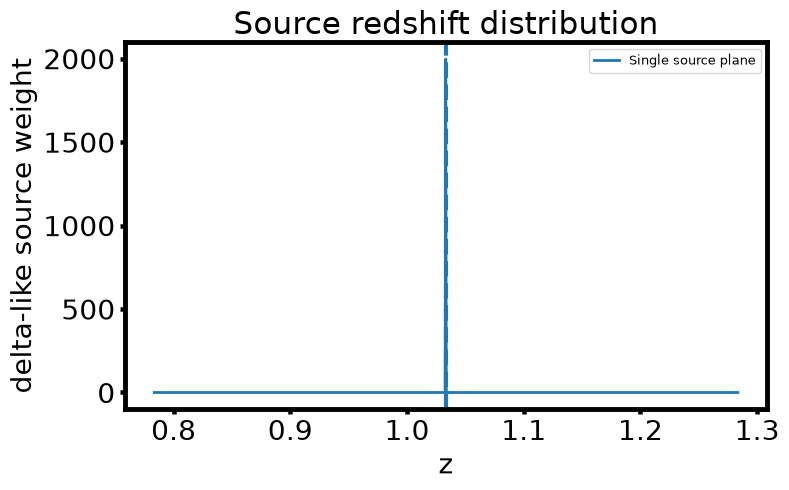

In [8]:
# ============================================================
# Source redshift distribution check
# ============================================================

plt.figure(figsize=(8, 5))

if SOURCE_MODE == "redshift_distribution":
    plt.plot(
        SOURCE_Z_GRID,
        SOURCE_NZ,
        lw=2,
        label="Input n(z)",
    )
    plt.axvline(
        SOURCE_EFFECTIVE_REDSHIFT,
        ls="--",
        label=rf"mean $z={SOURCE_EFFECTIVE_REDSHIFT:.3f}$",
    )
    plt.xlim(
        max(0.0, float(SOURCE_Z_GRID[0])),
        float(SOURCE_Z_GRID[-1]),
    )
    plt.ylabel(r"normalised $n(z)$")
else:
    z_plot = np.linspace(
        max(0.0, SOURCE_PLANE_REDSHIFT - 0.25),
        SOURCE_PLANE_REDSHIFT + 0.25,
        1000,
    )
    dz = z_plot[1] - z_plot[0]
    source_weight = np.zeros_like(z_plot)
    source_weight[np.argmin(np.abs(z_plot - SOURCE_PLANE_REDSHIFT))] = 1.0 / dz
    plt.plot(z_plot, source_weight, lw=2, label="Single source plane")
    plt.axvline(SOURCE_PLANE_REDSHIFT, ls="--")
    plt.ylabel("delta-like source weight")

plt.xlabel("z")
plt.title("Source redshift distribution")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 9. Generate and compare wavelet L1 products with simulation

In [9]:
# ============================================================
# CELL 1/4: COMMON SETTINGS AND DEFINITIONS
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import gc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import healpy as hp

from astropy import units as u
from scipy.integrate import simpson
from scipy.optimize import (
    root,
    least_squares,
    newton,
)

from scipy.interpolate import PchipInterpolator, CubicSpline, PchipInterpolator

# ============================================================
# NUMERICAL PARAMETERS
# ============================================================

REAL_LAMBDA_POINTS = 41

LAMBDA_SIGMA_FACTOR = 1.20
LAMBDA_MIN_ABS_MAX = 80.0
LAMBDA_MAX_ABS_MAX = 600.0

CONTOUR_MAX = 40000.0
CONTOUR_STEP = 10.0

POLYNOMIAL_DEGREE = 9

THEORY_KAPPA_MIN_SIGMA = -10.0
THEORY_KAPPA_MAX_SIGMA = +10.0
THEORY_KAPPA_POINTS = 300

SOLVER_RESIDUAL_TOL = 2.0e-4

# ============================================================
# USER SETTINGS
# ============================================================

RUN_SIMULATION_CALCULATION = False # If set to True, it takes approximately 72 minutes.
RUN_THEORY_CALCULATION = False # If set to True, it takes approximately 1 minute and 27 secons.

REDSHIFT = 1.0334

USE_PIXEL_WINDOW_IN_THEORY_VARIANCE = False

REDSHIFT_TAG = (
    f"{REDSHIFT:.4f}"
    .replace(".", "_")
)

SIMULATION_INDICES = tuple(range(10))

SIM_MAP_DIR = Path(
    r"E:\data\sim_data"
)

SIM_MAP_NAME_TEMPLATE = (
    "allskymap_nres12r{index:03d}.zs16.mag.dat"
)

OUTPUT_DIR = Path(
    r"E:\data\full_sky_map_results\wavelet_l1"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def simulation_map_path(index):
    return (
        SIM_MAP_DIR
        /
        SIM_MAP_NAME_TEMPLATE.format(index=int(index))
    )


def simulation_npz_path(index):
    return (
        OUTPUT_DIR
        /
        f"sim_z{REDSHIFT_TAG}_r{int(index):03d}_all_scale.npz"
    )


THEORY_NPZ_PATH = (
    OUTPUT_DIR
    /
    f"theory_z{REDSHIFT_TAG}_all_scale.npz"
)


# ============================================================
# ANALYSIS SETTINGS
# ============================================================

N_KAPPA_BINS = 240

FULL_SUPPORT_PERCENTILES = (
    0.0,
    100.0,
)

WAVELET_BANDS = [
    (
        "10-20",
        10.0,
        20.0,
        False,
        "wavelet_10_20",
    ),
    (
        "20-40",
        20.0,
        40.0,
        False,
        "wavelet_20_40",
    ),
    (
        f"coarse {COARSE_ARCMIN:g}",
        None,
        None,
        True,
        "coarse_40",
    ),
]


# ============================================================
# PLOT SETTINGS
# ============================================================

FIGSIZE = (
    10.0,
    8.0,
)

HEIGHT_RATIOS = (
    1.45,
    1.0,
)

HSPACE = 0.24

BOTTOM_XLIM = (
    -1.5,
    +1.5,
)

BOTTOM_YLIM = (
    -10.0,
    +10.0,
)

SIM_LW = 2.2
THEORY_LW = 2.0
RESIDUAL_LW = 2.0

LABEL_SIZE = 15
TICK_SIZE = 12
LEGEND_SIZE = 12


# ============================================================
# REQUIRED NOTEBOOK DEFINITIONS
# ============================================================

REQUIRED_DEFINITIONS = [
    "COARSE_ARCMIN",
    "HARMONIC_ITER",
    "ThreeScaleTheoryContext",
    "wavelet_theory_product",
    "coarse_theory_product",
    "psi_2cell_scalar",
    "normalize_pdf",
    "read_native_fullsky_map_binary",
    "top_hat_beam",
]

MISSING_DEFINITIONS = [
    name
    for name in REQUIRED_DEFINITIONS
    if name not in globals()
]

if MISSING_DEFINITIONS:

    raise RuntimeError(
        "Required notebook definitions are missing:\n"
        +
        "\n".join(
            f"  - {name}"
            for name in MISSING_DEFINITIONS
        )
    )


# ============================================================
# TWO-CELL STATIONARY SOLVER
#
# The numerical algorithm is unchanged.
#
# The observable is defined as:
#
#   smaller angular scale - larger angular scale
#
# therefore:
#
#   observable = delta1 - delta2
#
# and the stationary equations are derived consistently from:
#
#   lambda * w * (delta1 - delta2) - psi
# ============================================================

def solve_2cell_delta(
    context,
    lambda_value,
    lens_weight,
    chi,
    z,
    theta1_rad,
    theta2_rad,
    initial_guess,
):

    if np.isclose(
        lambda_value,
        0.0,
        atol=1.0e-14,
    ):

        return np.asarray(
            [
                0.0,
                0.0,
            ],
            dtype=float,
        )


    derivative_steps = (
        1.0e-5,
        2.0e-5,
        5.0e-5,
        1.0e-4,
        2.0e-4,
        5.0e-4,
    )


    forcing_scale = abs(
        float(lambda_value)
        *
        float(lens_weight)
    )


    residual_tolerance = 2.0e-4


    guess0 = np.clip(
        np.asarray(
            initial_guess,
            dtype=float,
        ),
        -0.95,
        10.0,
    )


    fallback_guesses = [
        guess0,

        np.zeros(
            2,
            dtype=float,
        ),

        np.asarray(
            [
                -0.05,
                +0.05,
            ],
            dtype=float,
        ),

        np.asarray(
            [
                -0.15,
                +0.15,
            ],
            dtype=float,
        ),

        np.asarray(
            [
                -0.30,
                +0.30,
            ],
            dtype=float,
        ),

        np.asarray(
            [
                +0.15,
                -0.15,
            ],
            dtype=float,
        ),
    ]


    best_x = None
    best_residual = np.inf
    best_step = None


    for derivative_step in derivative_steps:


        def equations(
            delta,
        ):

            d1 = float(
                delta[0]
            )

            d2 = float(
                delta[1]
            )


            h1 = min(
                derivative_step,
                0.45
                *
                (
                    d1
                    +
                    0.999
                ),
            )

            h2 = min(
                derivative_step,
                0.45
                *
                (
                    d2
                    +
                    0.999
                ),
            )


            h1 = max(
                h1,
                1.0e-7,
            )

            h2 = max(
                h2,
                1.0e-7,
            )


            psi_d1_plus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1 + h1,
                d2,
                theta1_rad,
                theta2_rad,
            )

            psi_d1_minus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1 - h1,
                d2,
                theta1_rad,
                theta2_rad,
            )

            psi_d2_plus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1,
                d2 + h2,
                theta1_rad,
                theta2_rad,
            )

            psi_d2_minus = psi_2cell_scalar(
                context,
                chi,
                z,
                d1,
                d2 - h2,
                theta1_rad,
                theta2_rad,
            )


            derivative1 = (
                psi_d1_plus
                -
                psi_d1_minus
            ) / (
                2.0
                *
                h1
            )


            derivative2 = (
                psi_d2_plus
                -
                psi_d2_minus
            ) / (
                2.0
                *
                h2
            )


            result = np.asarray(
                [
                    (
                        float(lambda_value)
                        *
                        float(lens_weight)
                        -
                        derivative1
                    ),
                    (
                        -float(lambda_value)
                        *
                        float(lens_weight)
                        -
                        derivative2
                    ),
                ],
                dtype=float,
            )


            return np.nan_to_num(
                result,
                nan=1.0e100,
                posinf=1.0e100,
                neginf=-1.0e100,
            )


        hybrid = root(
            equations,
            guess0,
            method="hybr",
        )


        if (
            hybrid.success
            and
            np.all(
                np.isfinite(
                    hybrid.x
                )
            )
            and
            np.all(
                hybrid.x
                >
                -0.999
            )
        ):

            residual = float(
                np.linalg.norm(
                    equations(
                        hybrid.x
                    )
                )
            )


            if residual < best_residual:

                best_x = (
                    hybrid.x.copy()
                )

                best_residual = (
                    residual
                )

                best_step = (
                    derivative_step
                )


            if (
                residual
                <
                residual_tolerance
            ):

                return hybrid.x.astype(
                    float
                )


        for fallback_guess in fallback_guesses:

            solution = least_squares(
                equations,

                x0=np.clip(
                    fallback_guess,
                    -0.95,
                    10.0,
                ),

                bounds=(
                    [
                        -0.999,
                        -0.999,
                    ],
                    [
                        30.0,
                        30.0,
                    ],
                ),

                x_scale="jac",
                loss="linear",

                xtol=1.0e-11,
                ftol=1.0e-11,
                gtol=1.0e-11,

                max_nfev=1200,
            )


            residual = float(
                np.linalg.norm(
                    equations(
                        solution.x
                    )
                )
            )


            if residual < best_residual:

                best_x = (
                    solution.x.copy()
                )

                best_residual = (
                    residual
                )

                best_step = (
                    derivative_step
                )


            if (
                solution.success
                and
                residual
                <
                residual_tolerance
            ):

                return solution.x.astype(
                    float
                )


        if best_x is not None:

            guess0 = np.clip(
                best_x,
                -0.95,
                10.0,
            )

            fallback_guesses[0] = (
                guess0
            )


    raise RuntimeError(
        "2-cell solve failed after adaptive central differences: "
        f"lambda={lambda_value}, "
        f"z={z}, "
        f"chi={chi}, "
        f"lens_weight={lens_weight}, "
        f"best_delta={best_x}, "
        f"best_residual={best_residual}, "
        f"accepted_tolerance={residual_tolerance}, "
        f"forcing_scale={forcing_scale}, "
        f"best_derivative_step={best_step}"
    )


# ============================================================
# PROJECTED TWO-CELL CGF
#
# The observable is intrinsically:
#
#   delta1 - delta2
# ============================================================

def projected_cgf_2cell(
    context,
    theta1_arcmin,
    theta2_arcmin,
    lambdas,
):

    lambdas = np.asarray(
        lambdas,
        dtype=float,
    )


    theta1_rad = (
        theta1_arcmin
        *
        u.arcmin
    ).to(
        u.radian
    ).value


    theta2_rad = (
        theta2_arcmin
        *
        u.arcmin
    ).to(
        u.radian
    ).value


    nplanes = len(
        context.chis
    )


    zero_index = int(
        np.argmin(
            np.abs(
                lambdas
            )
        )
    )


    deltas = np.zeros(
        (
            nplanes,
            len(lambdas),
            2,
        ),
        dtype=float,
    )


    maximum_weight = np.max(
        np.abs(
            context.lensing_weight
        )
    )


    negligible_weight = (
        maximum_weight
        *
        1.0e-7
    )


    for plane in range(
        nplanes
    ):

        print(
            f"[THEORY 2-cell] "
            f"plane {plane + 1}/{nplanes}",
            end="\r",
        )


        if (
            np.abs(
                context.lensing_weight[
                    plane
                ]
            )
            <=
            negligible_weight
        ):

            continue


        for index in range(
            zero_index + 1,
            len(lambdas),
        ):

            deltas[
                plane,
                index,
            ] = solve_2cell_delta(
                context,

                lambdas[
                    index
                ],

                context.lensing_weight[
                    plane
                ],

                context.chis[
                    plane
                ],

                context.z_lens[
                    plane
                ],

                theta1_rad,
                theta2_rad,

                deltas[
                    plane,
                    index - 1,
                ],
            )


        for index in range(
            zero_index - 1,
            -1,
            -1,
        ):

            deltas[
                plane,
                index,
            ] = solve_2cell_delta(
                context,

                lambdas[
                    index
                ],

                context.lensing_weight[
                    plane
                ],

                context.chis[
                    plane
                ],

                context.z_lens[
                    plane
                ],

                theta1_rad,
                theta2_rad,

                deltas[
                    plane,
                    index + 1,
                ],
            )


    print()


    phi = np.zeros(
        len(lambdas),
        dtype=float,
    )


    for index, lambda_value in enumerate(
        lambdas
    ):

        for plane in range(
            nplanes
        ):

            delta1, delta2 = (
                deltas[
                    plane,
                    index,
                ]
            )


            psi = psi_2cell_scalar(
                context,

                context.chis[
                    plane
                ],

                context.z_lens[
                    plane
                ],

                delta1,
                delta2,

                theta1_rad,
                theta2_rad,
            )


            phi[
                index
            ] += (
                lambda_value
                *
                context.lensing_weight[
                    plane
                ]
                *
                (
                    delta1
                    -
                    delta2
                )
                -
                psi
            ) * context.dchis[
                plane
            ]


    phi -= phi[
        zero_index
    ]


    return phi


# ============================================================
# HELPERS
# ============================================================

def load_npz_dictionary(
    path,
):

    with np.load(
        path,
        allow_pickle=False,
    ) as data:

        return {
            key:
                np.array(
                    data[key],
                    copy=True,
                )
            for key in data.files
        }


def simulation_histogram_product(
    field,
    n_bins,
):

    finite = np.isfinite(
        field
    )


    n_finite = int(
        np.count_nonzero(
            finite
        )
    )


    if n_finite == 0:

        raise ValueError(
            "Simulation field contains no finite pixels."
        )


    if n_finite == field.size:

        values = field

    else:

        values = field[
            finite
        ]


    sigma = float(
        np.std(
            values,
            ddof=0,
        )
    )


    qlo, qhi = (
        FULL_SUPPORT_PERCENTILES
    )


    if (
        qlo == 0.0
        and
        qhi == 100.0
    ):

        lo = float(
            np.min(
                values
            )
        )

        hi = float(
            np.max(
                values
            )
        )

    else:

        lo, hi = np.percentile(
            values,
            [
                qlo,
                qhi,
            ],
        )

        lo = float(lo)
        hi = float(hi)


    if not (
        np.isfinite(lo)
        and
        np.isfinite(hi)
        and
        hi > lo
    ):

        raise ValueError(
            f"Invalid simulation support: "
            f"[{lo}, {hi}]"
        )


    edges = np.linspace(
        lo,
        hi,
        int(n_bins) + 1,
        dtype=np.float64,
    )


    counts, _ = np.histogram(
        values,
        bins=edges,
        density=False,
    )


    widths = np.diff(
        edges
    )


    pdf = (
        counts.astype(
            np.float64
        )
        /
        (
            float(
                n_finite
            )
            *
            widths
        )
    )


    kappa = (
        0.5
        *
        (
            edges[:-1]
            +
            edges[1:]
        )
    )


    l1 = (
        np.abs(
            kappa
        )
        *
        pdf
    )


    probability = float(
        np.sum(
            pdf
            *
            widths
        )
    )


    if not np.isfinite(
        sigma
    ):

        raise ValueError(
            "Invalid simulation sigma."
        )


    return (
        kappa,
        pdf,
        l1,
        sigma,
        probability,
    )


def prepare_theory_pdf(
    kappa,
    pdf,
    label,
):

    kappa = np.asarray(
        kappa,
        dtype=np.float64,
    )

    pdf = np.asarray(
        pdf,
        dtype=np.float64,
    )


    valid = (
        np.isfinite(
            kappa
        )
        &
        np.isfinite(
            pdf
        )
    )


    kappa = kappa[
        valid
    ]

    pdf = pdf[
        valid
    ]


    if kappa.size < 2:

        raise ValueError(
            f"{label}: too few finite theory samples."
        )


    order = np.argsort(
        kappa
    )


    kappa = kappa[
        order
    ]

    pdf = pdf[
        order
    ]


    kappa, unique_index = np.unique(
        kappa,
        return_index=True,
    )


    pdf = pdf[
        unique_index
    ]


    if kappa.size < 2:

        raise ValueError(
            f"{label}: too few unique theory kappa values."
        )


    pdf = normalize_pdf(
        kappa,
        pdf,
    )


    return (
        kappa,
        pdf,
    )




In [10]:
# ============================================================
# CELL 2/4: SIMULATION CALCULATION AND PER-REALISATION SAVE
# ============================================================

if RUN_SIMULATION_CALCULATION:

    for simulation_index in SIMULATION_INDICES:

        SIM_MAP_PATH = simulation_map_path(simulation_index)
        SIM_NPZ_PATH = simulation_npz_path(simulation_index)

        print()
        print("#" * 88)
        print(
            f"SIMULATION r{simulation_index:03d} "
            f"({simulation_index + 1}/{len(SIMULATION_INDICES)})"
        )
        print("#" * 88)

        # CALCULATE ONE SIMULATION REALISATION
        # ========================================================

        print()
        print("=" * 88)
        print("CALCULATING NATIVE NSIDE SIMULATION")
        print("=" * 88)


        if not SIM_MAP_PATH.exists():

            raise FileNotFoundError(
                f"Simulation map not found:\n"
                f"{SIM_MAP_PATH}"
            )


        sim_map, native_nside = (
            read_native_fullsky_map_binary(
                SIM_MAP_PATH,
                return_nside=True,
            )
        )


        native_nside = int(
            native_nside
        )


        lmax_sim = (
            3
            *
            native_nside
            -
            1
        )


        print(
            f"[SIM] native NSIDE = {native_nside}"
        )

        print(
            f"[SIM] Npix         = {sim_map.size}"
        )

        print(
            f"[SIM] pixel size   = "
            f"{hp.nside2resol(native_nside, arcmin=True):.6f} arcmin"
        )

        print(
            f"[SIM] lmax         = {lmax_sim}"
        )


        # ========================================================
        # Transform the native map to alm once
        # ========================================================

        print()
        print(
            "[SIM] map2alm...",
            flush=True,
        )


        alm = hp.map2alm(
            sim_map,
            lmax=lmax_sim,
            iter=HARMONIC_ITER,
            pol=False,
        )


        del sim_map
        gc.collect()


        # ========================================================
        # Smooth at 10 arcmin
        # ========================================================

        print()
        print(
            "[SIM] alm2map: 10 arcmin",
            flush=True,
        )


        field_10 = hp.alm2map(
            hp.almxfl(
                alm,
                top_hat_beam(
                    10.0,
                    lmax_sim,
                ),
            ),
            nside=native_nside,
            lmax=lmax_sim,
            pol=False,
        )


        # ========================================================
        # Smooth at 20 arcmin
        # ========================================================

        print(
            "[SIM] alm2map: 20 arcmin",
            flush=True,
        )


        field_20 = hp.alm2map(
            hp.almxfl(
                alm,
                top_hat_beam(
                    20.0,
                    lmax_sim,
                ),
            ),
            nside=native_nside,
            lmax=lmax_sim,
            pol=False,
        )


        # ========================================================
        # Construct 10-20 directly as smooth(10) - smooth(20)
        # ========================================================

        print(
            "[SIM] histogram: 10-20",
            flush=True,
        )


        field_10 -= field_20


        (
            kappa_10_20,
            pdf_10_20,
            l1_10_20,
            sigma_10_20,
            probability_10_20,
        ) = simulation_histogram_product(
            field_10,
            N_KAPPA_BINS,
        )


        print(
            f"    sigma={sigma_10_20:.8e} | "
            f"P={probability_10_20:.12f}"
        )


        del field_10
        gc.collect()


        # ========================================================
        # Smooth at 40 arcmin
        # ========================================================

        print(
            "[SIM] alm2map: 40 arcmin",
            flush=True,
        )


        field_40 = hp.alm2map(
            hp.almxfl(
                alm,
                top_hat_beam(
                    COARSE_ARCMIN,
                    lmax_sim,
                ),
            ),
            nside=native_nside,
            lmax=lmax_sim,
            pol=False,
        )


        # ========================================================
        # Construct 20-40 directly as smooth(20) - smooth(40)
        # ========================================================

        print(
            "[SIM] histogram: 20-40",
            flush=True,
        )


        field_20 -= field_40


        (
            kappa_20_40,
            pdf_20_40,
            l1_20_40,
            sigma_20_40,
            probability_20_40,
        ) = simulation_histogram_product(
            field_20,
            N_KAPPA_BINS,
        )


        print(
            f"    sigma={sigma_20_40:.8e} | "
            f"P={probability_20_40:.12f}"
        )


        del field_20
        gc.collect()


        # ========================================================
        # Construct the coarse 40-arcmin product
        # ========================================================

        print(
            f"[SIM] histogram: coarse {COARSE_ARCMIN:g}",
            flush=True,
        )


        (
            kappa_coarse,
            pdf_coarse,
            l1_coarse,
            sigma_coarse,
            probability_coarse,
        ) = simulation_histogram_product(
            field_40,
            N_KAPPA_BINS,
        )


        print(
            f"    sigma={sigma_coarse:.8e} | "
            f"P={probability_coarse:.12f}"
        )


        del field_40
        del alm

        gc.collect()


        sim_data = {
            "wavelet_10_20_kappa":
                kappa_10_20,

            "wavelet_10_20_pdf":
                pdf_10_20,

            "wavelet_10_20_l1":
                l1_10_20,

            "wavelet_10_20_sigma":
                np.asarray(
                    sigma_10_20,
                    dtype=np.float64,
                ),


            "wavelet_20_40_kappa":
                kappa_20_40,

            "wavelet_20_40_pdf":
                pdf_20_40,

            "wavelet_20_40_l1":
                l1_20_40,

            "wavelet_20_40_sigma":
                np.asarray(
                    sigma_20_40,
                    dtype=np.float64,
                ),


            "coarse_40_kappa":
                kappa_coarse,

            "coarse_40_pdf":
                pdf_coarse,

            "coarse_40_l1":
                l1_coarse,

            "coarse_40_sigma":
                np.asarray(
                    sigma_coarse,
                    dtype=np.float64,
                ),
        }


        np.savez_compressed(
            SIM_NPZ_PATH,
            **sim_data,
        )


        print()
        print(
            "[SAVED SIMULATION]",
            SIM_NPZ_PATH,
        )


else:
    print("[SKIP SIMULATION] RUN_SIMULATION_CALCULATION = False")


[SKIP SIMULATION] RUN_SIMULATION_CALCULATION = False


In [11]:
# ============================================================
# CELL 3/4: THEORY CALCULATION AND SAVE
# ============================================================

if RUN_THEORY_CALCULATION:
    # CALCULATE THEORY
    # ========================================================

    print()
    print("=" * 88)
    print("CALCULATING THEORY")
    print("=" * 88)

    print(
        "Wavelet definition:"
    )

    print(
        "    10-20 = smooth(10) - smooth(20)"
    )

    print(
        "    20-40 = smooth(20) - smooth(40)"
    )


    ctx = (
        ThreeScaleTheoryContext
        .build()
    )


    print()
    print(
        "[THEORY 1/3] 10-20 arcmin",
        flush=True,
    )


    product_10_20 = (
        wavelet_theory_product(
            ctx,
            10.0,
            20.0,
            "wavelet_10_20",
        )
    )


    print()
    print(
        "[THEORY 2/3] 20-40 arcmin",
        flush=True,
    )


    product_20_40 = (
        wavelet_theory_product(
            ctx,
            20.0,
            40.0,
            "wavelet_20_40",
        )
    )


    print()
    print(
        f"[THEORY 3/3] coarse {COARSE_ARCMIN:g} arcmin",
        flush=True,
    )


    product_coarse = (
        coarse_theory_product(
            ctx,
            COARSE_ARCMIN,
        )
    )


    theory_data = {
        "wavelet_10_20_kappa":
            np.asarray(
                product_10_20[
                    "kappa"
                ],
                dtype=np.float64,
            ),

        "wavelet_10_20_pdf":
            np.asarray(
                product_10_20[
                    "pdf"
                ],
                dtype=np.float64,
            ),

        "wavelet_10_20_l1":
            np.asarray(
                product_10_20[
                    "l1"
                ],
                dtype=np.float64,
            ),


        "wavelet_20_40_kappa":
            np.asarray(
                product_20_40[
                    "kappa"
                ],
                dtype=np.float64,
            ),

        "wavelet_20_40_pdf":
            np.asarray(
                product_20_40[
                    "pdf"
                ],
                dtype=np.float64,
            ),

        "wavelet_20_40_l1":
            np.asarray(
                product_20_40[
                    "l1"
                ],
                dtype=np.float64,
            ),


        "coarse_40_kappa":
            np.asarray(
                product_coarse[
                    "kappa"
                ],
                dtype=np.float64,
            ),

        "coarse_40_pdf":
            np.asarray(
                product_coarse[
                    "pdf"
                ],
                dtype=np.float64,
            ),

        "coarse_40_l1":
            np.asarray(
                product_coarse[
                    "l1"
                ],
                dtype=np.float64,
            ),
    }


    np.savez_compressed(
        THEORY_NPZ_PATH,
        **theory_data,
    )


    print()
    print(
        "[SAVED THEORY]",
        THEORY_NPZ_PATH,
    )


    del product_10_20
    del product_20_40
    del product_coarse
    del ctx

    gc.collect()


    # ========================================================

else:
    print("[SKIP THEORY] RUN_THEORY_CALCULATION = False")


[SKIP THEORY] RUN_THEORY_CALCULATION = False



LOADING SAVED WAVELET-L1 RESULTS
[LOAD THEORY] E:\data\full_sky_map_results\wavelet_l1\theory_z1_0334_all_scale.npz
[LOAD SIM r000] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r000_all_scale.npz
[LOAD SIM r001] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r001_all_scale.npz
[LOAD SIM r002] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r002_all_scale.npz
[LOAD SIM r003] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r003_all_scale.npz
[LOAD SIM r004] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r004_all_scale.npz
[LOAD SIM r005] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r005_all_scale.npz
[LOAD SIM r006] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r006_all_scale.npz
[LOAD SIM r007] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r007_all_scale.npz
[LOAD SIM r008] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r008_all_scale.npz
[LOAD SIM r009] E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r009_all_scale.npz


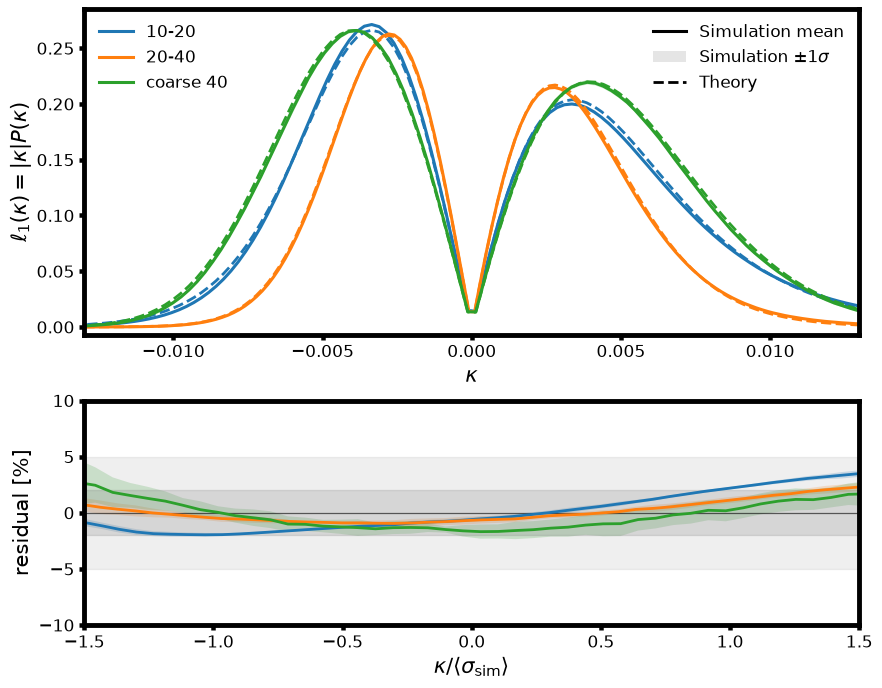


DONE
Simulation caches:
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r000_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r001_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r002_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r003_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r004_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r005_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r006_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r007_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r008_all_scale.npz
    E:\data\full_sky_map_results\wavelet_l1\sim_z1_0334_r009_all_scale.npz
Theory cache     : E:\data\full_sky_map_results\wavelet_l1\theory_z1_0334_all_scale.npz
Top x-range      : (-0.012987211502418546, 0.012987211502418546)
Residual x-range : (-1.5, 1.5)
Residual y-range : (-10.0, 10.0)


In [12]:
# ============================================================
# CELL 4/4: LOAD SAVED RESULTS AND PLOT
# ============================================================

print()
print("=" * 88)
print("LOADING SAVED WAVELET-L1 RESULTS")
print("=" * 88)


# ============================================================
# LOAD AND VALIDATE SAVED FILES
# ============================================================

required_paths = [
    THEORY_NPZ_PATH,
    *[
        simulation_npz_path(index)
        for index in SIMULATION_INDICES
    ],
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Required saved result files are missing:\n"
        + "\n".join(
            f"  - {path}"
            for path in missing_paths
        )
    )


print("[LOAD THEORY]", THEORY_NPZ_PATH)

theory_data = load_npz_dictionary(
    THEORY_NPZ_PATH
)


simulation_data = []

for simulation_index in SIMULATION_INDICES:

    path = simulation_npz_path(
        simulation_index
    )

    print(
        f"[LOAD SIM r{simulation_index:03d}]",
        path,
    )

    simulation_data.append(
        load_npz_dictionary(path)
    )


required_theory_keys = [
    f"{key_prefix}_{suffix}"
    for _, _, _, _, key_prefix in WAVELET_BANDS
    for suffix in (
        "kappa",
        "pdf",
        "l1",
    )
]

required_simulation_keys = [
    f"{key_prefix}_{suffix}"
    for _, _, _, _, key_prefix in WAVELET_BANDS
    for suffix in (
        "kappa",
        "pdf",
        "l1",
        "sigma",
    )
]


missing_theory_keys = [
    key
    for key in required_theory_keys
    if key not in theory_data
]

if missing_theory_keys:
    raise KeyError(
        "Theory file is missing keys:\n"
        + "\n".join(
            f"  - {key}"
            for key in missing_theory_keys
        )
    )


for simulation_index, sim_data in zip(
    SIMULATION_INDICES,
    simulation_data,
):

    missing_simulation_keys = [
        key
        for key in required_simulation_keys
        if key not in sim_data
    ]

    if missing_simulation_keys:
        raise KeyError(
            f"Simulation r{simulation_index:03d} "
            f"file is missing keys:\n"
            + "\n".join(
                f"  - {key}"
                for key in missing_simulation_keys
            )
        )


# ============================================================
# ENSEMBLE STATISTICS ON EACH THEORY KAPPA GRID
# ============================================================

comparison = {}


for (
    label,
    _,
    _,
    _,
    key_prefix,
) in WAVELET_BANDS:

    # --------------------------------------------------------
    # Theory PDF
    # --------------------------------------------------------

    theory_kappa, theory_pdf = prepare_theory_pdf(
        np.asarray(
            theory_data[
                f"{key_prefix}_kappa"
            ],
            dtype=np.float64,
        ),
        np.asarray(
            theory_data[
                f"{key_prefix}_pdf"
            ],
            dtype=np.float64,
        ),
        label,
    )


    # --------------------------------------------------------
    # Interpolate all ten simulations onto the theory grid
    # --------------------------------------------------------

    interpolated_simulation_pdfs = []
    simulation_sigmas = []


    for sim_data in simulation_data:

        sim_kappa = np.asarray(
            sim_data[
                f"{key_prefix}_kappa"
            ],
            dtype=np.float64,
        )

        sim_pdf = np.asarray(
            sim_data[
                f"{key_prefix}_pdf"
            ],
            dtype=np.float64,
        )


        finite = (
            np.isfinite(sim_kappa)
            &
            np.isfinite(sim_pdf)
        )

        sim_kappa = sim_kappa[finite]
        sim_pdf = sim_pdf[finite]


        order = np.argsort(
            sim_kappa
        )

        sim_kappa = sim_kappa[order]
        sim_pdf = sim_pdf[order]


        sim_kappa, unique_indices = np.unique(
            sim_kappa,
            return_index=True,
        )

        sim_pdf = sim_pdf[
            unique_indices
        ]


        if sim_kappa.size < 2:
            raise ValueError(
                f"Too few simulation samples "
                f"for {label}."
            )


        interpolator = PchipInterpolator(
            sim_kappa,
            sim_pdf,
            extrapolate=False,
        )


        interpolated_simulation_pdfs.append(
            np.asarray(
                interpolator(
                    theory_kappa
                ),
                dtype=np.float64,
            )
        )


        simulation_sigmas.append(
            float(
                np.asarray(
                    sim_data[
                        f"{key_prefix}_sigma"
                    ]
                )
            )
        )


    simulation_pdf_stack = np.stack(
        interpolated_simulation_pdfs,
        axis=0,
    )

    simulation_sigmas = np.asarray(
        simulation_sigmas,
        dtype=np.float64,
    )


    # --------------------------------------------------------
    # Keep only support shared by theory and all simulations
    # --------------------------------------------------------

    common = (
        np.isfinite(
            theory_kappa
        )
        &
        np.isfinite(
            theory_pdf
        )
        &
        np.all(
            np.isfinite(
                simulation_pdf_stack
            ),
            axis=0,
        )
        &
        np.all(
            simulation_pdf_stack
            >
            0.0,
            axis=0,
        )
    )


    if not np.any(common):
        raise ValueError(
            f"The ten simulations and theory "
            f"have no common support for {label}."
        )


    theory_kappa = theory_kappa[
        common
    ]

    theory_pdf = theory_pdf[
        common
    ]

    simulation_pdf_stack = (
        simulation_pdf_stack[
            :,
            common,
        ]
    )


    # --------------------------------------------------------
    # Wavelet L1 norm
    # --------------------------------------------------------

    simulation_l1_stack = (
        np.abs(
            theory_kappa
        )[
            None,
            :
        ]
        *
        simulation_pdf_stack
    )

    simulation_l1_mean = np.mean(
        simulation_l1_stack,
        axis=0,
    )

    simulation_l1_std = np.std(
        simulation_l1_stack,
        axis=0,
        ddof=1,
    )

    theory_l1 = (
        np.abs(
            theory_kappa
        )
        *
        theory_pdf
    )


    # --------------------------------------------------------
    # Simulation ensemble PDF statistics
    # --------------------------------------------------------

    simulation_pdf_mean = np.mean(
        simulation_pdf_stack,
        axis=0,
    )

    simulation_pdf_std = np.std(
        simulation_pdf_stack,
        axis=0,
        ddof=1,
    )


    # --------------------------------------------------------
    # Central residual
    #
    # 100 * (theory / simulation ensemble mean - 1)
    #
    # Away from kappa=0, the PDF ratio is identical to the
    # L1 ratio because the common |kappa| factor cancels.
    # Using the PDF ratio also avoids 0/0 at kappa=0.
    # --------------------------------------------------------

    residual_pct = (
        100.0
        *
        (
            theory_pdf
            /
            simulation_pdf_mean
            -
            1.0
        )
    )


    # --------------------------------------------------------
    # Convert simulation mean +/- 1 sigma into residual bounds
    #
    # Since theory/simulation decreases as the simulation
    # denominator increases:
    #
    # lower residual = theory / (mean + sigma) - 1
    # upper residual = theory / (mean - sigma) - 1
    # --------------------------------------------------------

    residual_lower = (
        100.0
        *
        (
            theory_pdf
            /
            (
                simulation_pdf_mean
                +
                simulation_pdf_std
            )
            -
            1.0
        )
    )


    residual_upper = np.full_like(
        residual_pct,
        np.nan,
    )


    positive_lower_envelope = (
        simulation_pdf_mean
        -
        simulation_pdf_std
        >
        0.0
    )


    residual_upper[
        positive_lower_envelope
    ] = (
        100.0
        *
        (
            theory_pdf[
                positive_lower_envelope
            ]
            /
            (
                simulation_pdf_mean[
                    positive_lower_envelope
                ]
                -
                simulation_pdf_std[
                    positive_lower_envelope
                ]
            )
            -
            1.0
        )
    )


    # --------------------------------------------------------
    # Residual x-axis
    # --------------------------------------------------------

    mean_sigma = float(
        np.mean(
            simulation_sigmas
        )
    )


    comparison[
        label
    ] = {
        "sim_kappa":
            theory_kappa,

        "sim_pdf":
            simulation_pdf_mean,

        "sim_l1":
            simulation_l1_mean,

        "sim_l1_std":
            simulation_l1_std,

        "sigma_sim":
            mean_sigma,

        "theory_kappa_native":
            theory_kappa,

        "theory_pdf_native":
            theory_pdf,

        "theory_pdf_on_sim":
            theory_pdf,

        "theory_l1_on_sim":
            theory_l1,

        "residual_x":
            theory_kappa
            /
            mean_sigma,

        "residual_pct":
            residual_pct,

        "residual_lower":
            residual_lower,

        "residual_upper":
            residual_upper,

        "valid_residual":
            (
                np.isfinite(
                    residual_pct
                )
                &
                np.isfinite(
                    residual_lower
                )
                &
                np.isfinite(
                    residual_upper
                )
            ),
    }


# ============================================================
# COMMON TOP-PANEL PHYSICAL-KAPPA RANGE
# ============================================================

common_min = -np.inf
common_max = +np.inf


for (
    label,
    _,
    _,
    _,
    _,
) in WAVELET_BANDS:

    item = comparison[
        label
    ]


    x = item[
        "sim_kappa"
    ]

    y_sim = item[
        "sim_l1"
    ]

    y_theory = item[
        "theory_l1_on_sim"
    ]


    valid = (
        np.isfinite(
            x
        )
        &
        np.isfinite(
            y_sim
        )
        &
        np.isfinite(
            y_theory
        )
    )


    if not np.any(valid):
        raise ValueError(
            f"No common finite theory/simulation "
            f"kappa support for {label}."
        )


    local_min = float(
        np.min(
            x[valid]
        )
    )

    local_max = float(
        np.max(
            x[valid]
        )
    )


    common_min = max(
        common_min,
        local_min,
    )

    common_max = min(
        common_max,
        local_max,
    )


if not (
    np.isfinite(common_min)
    and
    np.isfinite(common_max)
    and
    common_max
    >
    common_min
):
    raise ValueError(
        "The three scales have no common "
        "physical-kappa support."
    )


symmetric_limit = min(
    abs(common_min),
    abs(common_max),
)


if not (
    np.isfinite(symmetric_limit)
    and
    symmetric_limit
    >
    0.0
):
    raise ValueError(
        "Could not construct a symmetric "
        "common kappa range."
    )


TOP_XLIM = (
    -symmetric_limit,
    +symmetric_limit,
)


# ============================================================
# PLOT
# ============================================================

fig, (
    ax_top,
    ax_bottom,
) = plt.subplots(
    2,
    1,

    figsize=FIGSIZE,

    gridspec_kw={
        "height_ratios":
            HEIGHT_RATIOS,

        "hspace":
            HSPACE,
    },
)


scale_handles = []


for (
    label,
    _,
    _,
    _,
    _,
) in WAVELET_BANDS:

    item = comparison[
        label
    ]


    # --------------------------------------------------------
    # Simulation ensemble mean
    # --------------------------------------------------------

    sim_line, = ax_top.plot(
        item[
            "sim_kappa"
        ],

        item[
            "sim_l1"
        ],

        linestyle="-",
        linewidth=SIM_LW,
        label=label,
    )


    color = sim_line.get_color()


    # --------------------------------------------------------
    # Simulation mean +/- 1 sigma
    # --------------------------------------------------------

    ax_top.fill_between(
        item[
            "sim_kappa"
        ],

        item[
            "sim_l1"
        ]
        -
        item[
            "sim_l1_std"
        ],

        item[
            "sim_l1"
        ]
        +
        item[
            "sim_l1_std"
        ],

        color=color,
        alpha=0.20,
        linewidth=0.0,
        zorder=0,
    )


    # --------------------------------------------------------
    # Theory
    # --------------------------------------------------------

    ax_top.plot(
        item[
            "sim_kappa"
        ],

        item[
            "theory_l1_on_sim"
        ],

        linestyle="--",
        linewidth=THEORY_LW,
        color=color,
    )


    # --------------------------------------------------------
    # Residual and transformed 1-sigma bounds
    # --------------------------------------------------------

    valid = item[
        "valid_residual"
    ]


    ax_bottom.plot(
        item[
            "residual_x"
        ][
            valid
        ],

        item[
            "residual_pct"
        ][
            valid
        ],

        linestyle="-",
        linewidth=RESIDUAL_LW,
        color=color,
    )


    ax_bottom.fill_between(
        item[
            "residual_x"
        ][
            valid
        ],

        item[
            "residual_lower"
        ][
            valid
        ],

        item[
            "residual_upper"
        ][
            valid
        ],

        color=color,
        alpha=0.20,
        linewidth=0.0,
        zorder=0,
    )


    scale_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linestyle="-",
            linewidth=SIM_LW,
            label=label,
        )
    )


# ============================================================
# TOP PANEL FORMAT
# ============================================================

ax_top.set_xlim(
    *TOP_XLIM
)


ax_top.set_xlabel(
    r"$\kappa$",
    fontsize=LABEL_SIZE,
)


ax_top.set_ylabel(
    r"$\ell_1(\kappa)=|\kappa|P(\kappa)$",
    fontsize=LABEL_SIZE,
)


# Include the complete 1-sigma band when determining y-limits.

visible_y = []


for (
    label,
    _,
    _,
    _,
    _,
) in WAVELET_BANDS:

    item = comparison[
        label
    ]


    x = item[
        "sim_kappa"
    ]


    inside = (
        np.isfinite(
            x
        )
        &
        (
            x
            >=
            TOP_XLIM[0]
        )
        &
        (
            x
            <=
            TOP_XLIM[1]
        )
    )


    for y in (
        item[
            "sim_l1"
        ]
        -
        item[
            "sim_l1_std"
        ],

        item[
            "sim_l1"
        ]
        +
        item[
            "sim_l1_std"
        ],

        item[
            "theory_l1_on_sim"
        ],
    ):

        valid = (
            inside
            &
            np.isfinite(y)
        )


        if np.any(valid):
            visible_y.append(
                y[valid]
            )


if visible_y:

    y_all = np.concatenate(
        visible_y
    )

    y_min = float(
        np.min(y_all)
    )

    y_max = float(
        np.max(y_all)
    )

    y_span = (
        y_max
        -
        y_min
    )


    if (
        not np.isfinite(y_span)
        or
        y_span
        <=
        0.0
    ):
        y_span = max(
            abs(y_max),
            1.0,
        )


    ax_top.set_ylim(
        y_min
        -
        0.025
        *
        y_span,

        y_max
        +
        0.05
        *
        y_span,
    )


# ============================================================
# LEGENDS
# ============================================================

legend_scale = ax_top.legend(
    handles=scale_handles,
    loc="upper left",
    fontsize=LEGEND_SIZE,
    frameon=False,
)


style_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="-",
        linewidth=SIM_LW,
        label="Simulation mean",
    ),

    Patch(
        facecolor="gray",
        alpha=0.20,
        edgecolor="none",
        label=r"Simulation $\pm1\sigma$",
    ),

    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=THEORY_LW,
        label="Theory",
    ),
]


ax_top.legend(
    handles=style_handles,
    loc="upper right",
    fontsize=LEGEND_SIZE,
    frameon=False,
)


ax_top.add_artist(
    legend_scale
)


# ============================================================
# BOTTOM PANEL FORMAT
# ============================================================

# Residual reference ranges, not simulation uncertainty.

ax_bottom.axhspan(
    -5.0,
    +5.0,
    color="gray",
    alpha=0.12,
    zorder=0,
)

ax_bottom.axhspan(
    -2.0,
    +2.0,
    color="gray",
    alpha=0.22,
    zorder=0,
)


ax_bottom.axhline(
    0.0,
    color="black",
    linewidth=0.9,
    alpha=0.6,
    zorder=1,
)


ax_bottom.set_xlim(
    *BOTTOM_XLIM
)


ax_bottom.set_ylim(
    *BOTTOM_YLIM
)


ax_bottom.set_xlabel(
    r"$\kappa/\langle\sigma_{\rm sim}\rangle$",
    fontsize=LABEL_SIZE,
)


ax_bottom.set_ylabel(
    "residual [%]",
    fontsize=LABEL_SIZE,
)


for ax in (
    ax_top,
    ax_bottom,
):

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE,
    )


plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 88)
print("DONE")
print("=" * 88)

print("Simulation caches:")

for simulation_index in SIMULATION_INDICES:
    print(
        "   ",
        simulation_npz_path(
            simulation_index
        ),
    )

print(
    "Theory cache     :",
    THEORY_NPZ_PATH,
)

print(
    "Top x-range      :",
    TOP_XLIM,
)

print(
    "Residual x-range :",
    BOTTOM_XLIM,
)

print(
    "Residual y-range :",
    BOTTOM_YLIM,
)

print("=" * 88)

## 11. Emulation

function settings


In [13]:
# ============================================================
# EMULATOR FUNCTIONS
#
# Main emulator method:
#   1. Decompose the current solution into a telescoping set of
#      top-hat components.
#   2. Match the theoretical L1 target independently on each
#      configured wavelet component and on the coarse component.
#   3. Preserve the unresolved fine residual below the smallest
#      configured scale.
#   4. Independently project the SAME current solution onto the
#      target C_ell.
#   5. Average the L1-projected and C_ell-projected maps.
#
# No pseudo-inverse backprojection is used.
# ============================================================


def compute_emulator_bin_edges(centres):
    centres = np.asarray(centres, dtype=np.float64)
    if centres.ndim != 1 or centres.size < 2:
        raise ValueError("At least two one-dimensional bin centres are required.")
    mids = 0.5 * (centres[:-1] + centres[1:])
    edges = np.empty(centres.size + 1, dtype=np.float64)
    edges[1:-1] = mids
    edges[0] = 2.0 * centres[0] - mids[0]
    edges[-1] = 2.0 * centres[-1] - mids[-1]
    return edges


def load_emulator_l1_target(path, flip_sign=False):
    path = Path(path)
    obj = np.load(path, allow_pickle=True)
    data = obj.item() if isinstance(obj, np.ndarray) and obj.shape == () else obj
    if not isinstance(data, dict):
        raise TypeError(f"L1 target is not a dictionary: {path}")
    centres = np.asarray(data["kappa"], dtype=np.float64)
    pdf = np.asarray(data["pdf"], dtype=np.float64)
    if "l1" in data:
        l1 = np.asarray(data["l1"], dtype=np.float64)
    elif "l1_norm" in data:
        l1 = np.asarray(data["l1_norm"], dtype=np.float64)
    else:
        raise KeyError(f"Neither 'l1' nor 'l1_norm' exists in: {path}")
    order = np.argsort(centres)
    centres, pdf, l1 = centres[order], pdf[order], l1[order]
    if flip_sign:
        centres = -centres[::-1]
        pdf = pdf[::-1]
        l1 = l1[::-1]
    return {
        "bincenters": centres,
        "binedges": compute_emulator_bin_edges(centres),
        "histogram": pdf,
        "l1_norm": l1,
        "source_path": str(path),
    }


def validate_emulation_scales(bands, coarse_arcmin):
    bands = [(float(a), float(b)) for a, b in bands]
    if len(bands) == 0:
        raise ValueError("EMULATION_L1_BANDS must contain at least one band.")
    for a, b in bands:
        if not (a > 0.0 and b > a):
            raise ValueError(f"Invalid L1 band: {(a, b)}")
    for (_, b0), (a1, _) in zip(bands[:-1], bands[1:]):
        if not np.isclose(b0, a1, rtol=0.0, atol=1.0e-12):
            raise ValueError(
                "EMULATION_L1_BANDS must form a contiguous telescoping chain. "
                f"Found a gap/overlap between {b0:g} and {a1:g} arcmin."
            )
    if not np.isclose(bands[-1][1], float(coarse_arcmin), rtol=0.0, atol=1.0e-12):
        raise ValueError(
            "The final upper band edge must equal EMULATION_COARSE_ARCMIN."
        )
    return bands


def emulator_top_hat_beam(theta_arcmin, lmax):
    theta_rad = np.deg2rad(float(theta_arcmin) / 60.0)
    mu = np.cos(theta_rad)
    ell = np.arange(int(lmax) + 1, dtype=np.int64)
    beam = np.ones(int(lmax) + 1, dtype=np.float64)
    lp = ell[1:]
    p_minus = eval_legendre(lp - 1, mu)
    p_plus = eval_legendre(lp + 1, mu)
    beam[1:] = (p_minus - p_plus) / ((2.0 * lp + 1.0) * (1.0 - mu))
    beam[0] = 1.0
    return beam


def build_emulator_targets(bands, coarse_arcmin):
    targets = {}
    for a, b in bands:
        key = f"{a:g}-{b:g}"
        # Theory uses beam(theta_large)-beam(theta_small); the telescoping
        # decomposition below uses the opposite sign, so mirror the PDF/L1.
        targets[key] = load_emulator_l1_target(
            theory_l1_path(a, b),
            flip_sign=True,
        )
    targets[f"coarse-{coarse_arcmin:g}"] = load_emulator_l1_target(
        theory_l1_path(coarse=True),
        flip_sign=False,
    )
    return targets


def decompose_map(solution, nside, lmax, bands, coarse_arcmin):
    bands = validate_emulation_scales(bands, coarse_arcmin)
    radii = sorted({bands[0][0], *[b for _, b in bands]})
    alm = hp.map2alm(
        np.asarray(solution, dtype=np.float64),
        lmax=int(lmax),
        iter=HARMONIC_ITER,
        pol=False,
    )
    smooth = {}
    for theta in radii:
        beam = emulator_top_hat_beam(theta, lmax)
        smooth[theta] = hp.alm2map(
            hp.almxfl(alm, beam),
            nside=int(nside),
            lmax=int(lmax),
            pol=False,
        )
    components = {"fine": np.asarray(solution, dtype=np.float64) - smooth[bands[0][0]]}
    for a, b in bands:
        components[f"{a:g}-{b:g}"] = smooth[a] - smooth[b]
    components[f"coarse-{coarse_arcmin:g}"] = smooth[float(coarse_arcmin)]
    del alm, smooth
    gc.collect()
    return components


def adjust_map_l1(input_image, target):
    """Project rank-ordered pixels onto target histogram/L1 constraints."""
    x = np.asarray(input_image, dtype=np.float64).copy()
    edges = np.asarray(target["binedges"], dtype=np.float64)
    pdf = np.asarray(target["histogram"], dtype=np.float64)
    target_l1 = np.asarray(target["l1_norm"], dtype=np.float64)
    widths = np.diff(edges)
    probs = np.maximum(pdf * widths, 0.0)
    prob_sum = float(np.sum(probs))
    if not np.isfinite(prob_sum) or prob_sum <= 0.0:
        raise ValueError("Invalid target histogram probability.")
    probs /= prob_sum

    order = np.argsort(x)
    sorted_x = x[order].copy()
    counts = np.floor(probs * x.size).astype(np.int64)
    counts[-1] += x.size - counts.sum()

    total_err = 0.0
    start = 0
    for j, n in enumerate(counts):
        n = int(n)
        end = start + n
        if n <= 0:
            start = end
            continue
        vals = sorted_x[start:end].copy()
        desired = float(target_l1[j] * widths[j] * x.size)
        current = float(np.sum(np.abs(vals)))
        delta = (desired - current) / float(n)
        positive = vals >= 0.0
        vals[positive] = np.maximum(vals[positive] + delta, 0.0)
        current = float(np.sum(np.abs(vals)))
        negative = ~positive
        n_negative = int(np.count_nonzero(negative))
        if n_negative > 0:
            vals[negative] = np.minimum(
                vals[negative] - (desired - current) / float(n_negative),
                0.0,
            )
        vals = np.clip(vals, edges[j], edges[j + 1])
        achieved = float(np.sum(np.abs(vals)))
        total_err += abs(desired - achieved)
        sorted_x[start:end] = vals
        start = end

    output = np.empty_like(x)
    output[order] = sorted_x
    norm = max(float(np.sum(target_l1 * widths)), 1.0e-30) * x.size
    return output, float(total_err / norm)


def adjust_cls(input_map, nside, lmax, target_cls):
    alm = hp.map2alm(
        np.asarray(input_map, dtype=np.float64),
        lmax=int(lmax),
        iter=HARMONIC_ITER,
        pol=False,
    )
    current_cls = hp.alm2cl(alm, lmax=int(lmax))
    factor = np.sqrt(
        np.maximum(target_cls, 0.0) / np.maximum(current_cls, 1.0e-30)
    )
    factor[:2] = 0.0
    adjusted_map = hp.alm2map(
        hp.almxfl(alm, factor),
        nside=int(nside),
        lmax=int(lmax),
        pol=False,
    )
    del alm, current_cls, factor
    gc.collect()
    return adjusted_map


def emulation_map_path(realisation_index):
    return (
        EMULATION_OUTPUT_DIR
        / f"emu_{source_token()}_Nside{EMULATION_NSIDE}_lmax{EMULATION_LMAX}_{int(realisation_index):02d}.npy"
    )


def emulation_history_path(realisation_index):
    return (
        EMULATION_OUTPUT_DIR
        / f"emu_{source_token()}_Nside{EMULATION_NSIDE}_lmax{EMULATION_LMAX}_{int(realisation_index):02d}_l1_history.npz"
    )


Reference runtime for the main production setting (`EMULATION_NSIDE = 4096`, `EMULATION_LMAX = 2000`): approximately 111 minutes per map.

Reference runtime for the main production setting (`EMULATION_NSIDE = 512`, `EMULATION_LMAX = 1535`): approximately 350 seconds per map.

<span style="color: darkorange; font-weight: bold;">
</span>


In [14]:
# ============================================================
# AGGREGATE THEORETICAL L1 TARGET
# ============================================================

THEORY_ALL_SCALE_NPZ = (
    L1_DIR
    /
    f"theory_{source_token()}_all_scale.npz"
)


def aggregate_wavelet_key_prefix(theta1, theta2):
    """NPZ key prefix for one wavelet band."""
    theta1_token = f"{float(theta1):g}".replace(".", "_")
    theta2_token = f"{float(theta2):g}".replace(".", "_")
    return f"wavelet_{theta1_token}_{theta2_token}"


def aggregate_coarse_key_prefix(theta):
    """NPZ key prefix for the coarse component."""
    theta_token = f"{float(theta):g}".replace(".", "_")
    return f"coarse_{theta_token}"


def load_aggregate_emulator_target(npz_data, key_prefix, source_path):
    """Convert one aggregate-NPZ component to the emulator target format."""
    required_keys = {
        f"{key_prefix}_kappa",
        f"{key_prefix}_pdf",
        f"{key_prefix}_l1",
    }
    missing_keys = required_keys - set(npz_data.files)

    if missing_keys:
        raise KeyError(
            f"Missing target keys in {source_path}: "
            + ", ".join(sorted(missing_keys))
        )

    centres = np.asarray(
        npz_data[f"{key_prefix}_kappa"],
        dtype=np.float64,
    )
    pdf = np.asarray(
        npz_data[f"{key_prefix}_pdf"],
        dtype=np.float64,
    )
    l1 = np.asarray(
        npz_data[f"{key_prefix}_l1"],
        dtype=np.float64,
    )

    if not (
        centres.ndim == 1
        and pdf.ndim == 1
        and l1.ndim == 1
        and centres.size == pdf.size == l1.size
        and centres.size >= 2
    ):
        raise ValueError(
            f"Invalid target-array shapes for {key_prefix} in {source_path}."
        )

    finite = (
        np.isfinite(centres)
        & np.isfinite(pdf)
        & np.isfinite(l1)
    )
    centres = centres[finite]
    pdf = pdf[finite]
    l1 = l1[finite]

    order = np.argsort(centres)
    centres = centres[order]
    pdf = pdf[order]
    l1 = l1[order]

    centres, unique_indices = np.unique(
        centres,
        return_index=True,
    )
    pdf = pdf[unique_indices]
    l1 = l1[unique_indices]

    if centres.size < 2:
        raise ValueError(
            f"Too few finite unique kappa values for {key_prefix} "
            f"in {source_path}."
        )

    return {
        "bincenters": centres,
        "binedges": compute_emulator_bin_edges(centres),
        "histogram": pdf,
        "l1_norm": l1,
        "source_path": str(source_path),
    }


def build_aggregate_emulator_targets(path, bands, coarse_arcmin):
    """Load all emulator L1 targets from one aggregate NPZ file."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Aggregate theoretical L1 file not found:\n{path}"
        )

    targets = {}

    with np.load(path, allow_pickle=False) as npz_data:
        for theta1, theta2 in bands:
            name = f"{theta1:g}-{theta2:g}"
            key_prefix = aggregate_wavelet_key_prefix(theta1, theta2)
            targets[name] = load_aggregate_emulator_target(
                npz_data,
                key_prefix,
                path,
            )

        coarse_name = f"coarse-{coarse_arcmin:g}"
        coarse_key_prefix = aggregate_coarse_key_prefix(coarse_arcmin)
        targets[coarse_name] = load_aggregate_emulator_target(
            npz_data,
            coarse_key_prefix,
            path,
        )

    return targets


# ============================================================
# CONTROLLED EXECUTION
# ============================================================

if RUN_EMULATION:

    # ============================================================
    # RUN EMULATOR
    # ============================================================

    BANDS = validate_emulation_scales(
        EMULATION_L1_BANDS,
        EMULATION_COARSE_ARCMIN,
    )
    TARGET_L1 = build_aggregate_emulator_targets(
        THEORY_ALL_SCALE_NPZ,
        BANDS,
        EMULATION_COARSE_ARCMIN,
    )
    REALISATION_INDICES = np.arange(
        REALISATION_START,
        REALISATION_END + 1,
        dtype=np.int64,
    )

    with np.load(TARGET_POWER_NPZ, allow_pickle=False) as f:
        target_ells = np.asarray(f["ells"], dtype=np.int64)
        target_all_cls = np.asarray(f["all_cls"], dtype=np.float64)

    required_ells = np.arange(2, EMULATION_LMAX + 1, dtype=np.int64)
    pos = np.searchsorted(target_ells, required_ells)
    if np.any(pos >= target_ells.size) or not np.array_equal(target_ells[pos], required_ells):
        missing = np.setdiff1d(required_ells, target_ells)
        raise ValueError(f"Target C_ell does not cover all required multipoles. First missing: {missing[:20]}")
    if REALISATION_END >= target_all_cls.shape[0]:
        raise ValueError(
            f"Requested realisation {REALISATION_END}, but only {target_all_cls.shape[0]} C_ell realisations exist."
        )

    print()
    print("=" * 96)
    print("EMULATION START")
    print("=" * 96)
    print("NSIDE                 :", EMULATION_NSIDE)
    print("lmax                  :", EMULATION_LMAX)
    print("harmonic iter         :", HARMONIC_ITER)
    print("realisations          :", REALISATION_INDICES.tolist())
    print("iterations            :", N_ITERATIONS)
    print("n_jobs                :", N_JOBS)
    print("L1 bands              :", [f"{a:g}-{b:g}" for a, b in BANDS])
    print("coarse                :", f"{EMULATION_COARSE_ARCMIN:g} arcmin")
    print("fine residual         :", f"< {BANDS[0][0]:g} arcmin preserved")
    print("output                :", EMULATION_OUTPUT_DIR)
    print("=" * 96)


    def run_one_emulation(realisation_index):
        realisation_index = int(realisation_index)
        map_path = emulation_map_path(realisation_index)
        history_path = emulation_history_path(realisation_index)

        scale_names = [
            f"{a:g}-{b:g}"
            for a, b in BANDS
        ] + [
            f"coarse-{EMULATION_COARSE_ARCMIN:g}"
        ]

        l1_target_paths = [
            THEORY_ALL_SCALE_NPZ
        ]

        l1_target_mtime_ns = np.asarray(
            [path.stat().st_mtime_ns for path in l1_target_paths],
            dtype=np.int64,
        )

        target_power_mtime_ns = np.int64(
            TARGET_POWER_NPZ.stat().st_mtime_ns
        )

        expected_random_seed = int(
            RANDOM_SEED + realisation_index
        )

        if (
            not OVERWRITE_EMULATION
            and map_path.exists()
            and history_path.exists()
        ):
            try:
                with np.load(history_path, allow_pickle=False) as h:
                    mean_history = np.asarray(
                        h["mean_l1_error_percent"],
                        dtype=np.float64,
                    )
                    scale_history = np.asarray(
                        h["scale_l1_error_percent"],
                        dtype=np.float64,
                    )

                    required_metadata = {
                        "harmonic_iter",
                        "nside",
                        "lmax",
                        "n_iterations",
                        "source_tag",
                        "random_seed",
                        "scale_names",
                        "coarse_arcmin",
                        "target_power_path",
                        "target_power_mtime_ns",
                        "l1_target_paths",
                        "l1_target_mtime_ns",
                    }

                    missing_metadata = (
                        required_metadata
                        - set(h.files)
                    )

                    compatible = (
                        len(missing_metadata) == 0
                    )

                    incompatibility_reasons = []

                    if missing_metadata:
                        incompatibility_reasons.append(
                            "missing metadata: "
                            + ", ".join(sorted(missing_metadata))
                        )

                    if compatible:
                        checks = [
                            (
                                int(h["harmonic_iter"]) == HARMONIC_ITER,
                                "HARMONIC_ITER",
                            ),
                            (
                                int(h["nside"]) == EMULATION_NSIDE,
                                "EMULATION_NSIDE",
                            ),
                            (
                                int(h["lmax"]) == EMULATION_LMAX,
                                "EMULATION_LMAX",
                            ),
                            (
                                int(h["n_iterations"]) == N_ITERATIONS,
                                "N_ITERATIONS",
                            ),
                            (
                                str(h["source_tag"]) == source_token(),
                                "source tag",
                            ),
                            (
                                int(h["random_seed"]) == expected_random_seed,
                                "random seed",
                            ),
                            (
                                np.array_equal(
                                    np.asarray(h["scale_names"], dtype=str),
                                    np.asarray(scale_names, dtype=str),
                                ),
                                "L1 scale names",
                            ),
                            (
                                np.isclose(
                                    float(h["coarse_arcmin"]),
                                    float(EMULATION_COARSE_ARCMIN),
                                ),
                                "coarse scale",
                            ),
                            (
                                str(h["target_power_path"])
                                == str(TARGET_POWER_NPZ),
                                "target power-spectrum path",
                            ),
                            (
                                int(h["target_power_mtime_ns"])
                                == int(target_power_mtime_ns),
                                "target power-spectrum file version",
                            ),
                            (
                                np.array_equal(
                                    np.asarray(h["l1_target_paths"], dtype=str),
                                    np.asarray(
                                        [str(path) for path in l1_target_paths],
                                        dtype=str,
                                    ),
                                ),
                                "L1 target paths",
                            ),
                            (
                                np.array_equal(
                                    np.asarray(h["l1_target_mtime_ns"], dtype=np.int64),
                                    l1_target_mtime_ns,
                                ),
                                "L1 target file versions",
                            ),
                        ]

                        for ok, label in checks:
                            if not ok:
                                compatible = False
                                incompatibility_reasons.append(label)

                    if compatible:
                        print(
                            f"[Realisation {realisation_index:03d}] "
                            "existing compatible result loaded.",
                            flush=True,
                        )
                        return {
                            "realisation_index": realisation_index,
                            "map_path": str(map_path),
                            "history_path": str(history_path),
                            "mean_history": mean_history,
                            "scale_history": scale_history,
                            "skipped": True,
                        }

                    print(
                        f"[Realisation {realisation_index:03d}] "
                        "existing result is incompatible: "
                        + "; ".join(incompatibility_reasons),
                        flush=True,
                    )

            except Exception as exc:
                print(
                    f"[Realisation {realisation_index:03d}] "
                    f"existing result ignored: {exc}",
                    flush=True,
                )

        target_cls = np.zeros(EMULATION_LMAX + 1, dtype=np.float64)
        target_cls[required_ells] = target_all_cls[realisation_index, pos]
        target_cls[:2] = 0.0

        np.random.seed(expected_random_seed)
        print(f"[Realisation {realisation_index:03d}] generating Gaussian start map...", flush=True)
        solution = hp.synfast(
            target_cls,
            nside=EMULATION_NSIDE,
            lmax=EMULATION_LMAX,
            new=True,
            pol=False,
        ).astype(np.float64, copy=False)
        solution -= np.mean(solution)

        mean_history = []
        scale_history = []

        for iteration in range(N_ITERATIONS):
            t0 = time.perf_counter()

            # Both branches start from exactly the same current solution.
            components = decompose_map(
                solution,
                EMULATION_NSIDE,
                EMULATION_LMAX,
                BANDS,
                EMULATION_COARSE_ARCMIN,
            )

            errors = []
            for name in scale_names:
                components[name], err = adjust_map_l1(components[name], TARGET_L1[name])
                errors.append(float(err) * 100.0)

            solution_l1 = components["fine"].copy()
            for name in scale_names:
                solution_l1 += components[name]

            solution_cls = adjust_cls(
                solution,
                EMULATION_NSIDE,
                EMULATION_LMAX,
                target_cls,
            )

            solution_next = 0.5 * (solution_l1 + solution_cls)
            solution_next -= np.mean(solution_next)

            errors = np.asarray(errors, dtype=np.float64)
            mean_error = float(np.mean(errors))
            scale_history.append(errors)
            mean_history.append(mean_error)

            detail = ", ".join(f"{name}={err:.6f}%" for name, err in zip(scale_names, errors))
            print(
                f"[Realisation {realisation_index:03d}] Iteration {iteration+1:02d}/{N_ITERATIONS:02d} | "
                f"Mean L1 error={mean_error:.6f}% | {detail} | "
                f"time={time.perf_counter()-t0:.2f}s",
                flush=True,
            )

            del solution, components, solution_l1, solution_cls
            solution = solution_next
            gc.collect()

        mean_history = np.asarray(mean_history, dtype=np.float64)
        scale_history = np.asarray(scale_history, dtype=np.float64)

        np.save(map_path, np.asarray(solution, dtype=np.float32))
        np.savez_compressed(
            history_path,
            realisation_index=np.int64(realisation_index),
            iterations=np.arange(1, N_ITERATIONS + 1, dtype=np.int64),
            mean_l1_error_percent=mean_history,
            scale_l1_error_percent=scale_history,
            scale_names=np.asarray(scale_names, dtype=str),
            harmonic_iter=np.int64(HARMONIC_ITER),
            nside=np.int64(EMULATION_NSIDE),
            lmax=np.int64(EMULATION_LMAX),
            n_iterations=np.int64(N_ITERATIONS),
            source_tag=np.asarray(source_token()),
            random_seed=np.int64(expected_random_seed),
            coarse_arcmin=np.float64(EMULATION_COARSE_ARCMIN),
            target_power_path=np.asarray(str(TARGET_POWER_NPZ)),
            target_power_mtime_ns=target_power_mtime_ns,
            l1_target_paths=np.asarray(
                [str(path) for path in l1_target_paths],
                dtype=str,
            ),
            l1_target_mtime_ns=l1_target_mtime_ns,
            map_path=np.asarray(str(map_path)),
        )
        print(f"[Realisation {realisation_index:03d}] SAVED: {map_path}", flush=True)
        del solution
        gc.collect()
        return {
            "realisation_index": realisation_index,
            "map_path": str(map_path),
            "history_path": str(history_path),
            "mean_history": mean_history,
            "scale_history": scale_history,
            "skipped": False,
        }


    if N_JOBS == 1:
        results = [run_one_emulation(i) for i in REALISATION_INDICES]
    else:
        results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
            delayed(run_one_emulation)(i) for i in REALISATION_INDICES
        )

    results = sorted(results, key=lambda x: x["realisation_index"])
    print("=" * 96)
    print("EMULATION COMPLETED")
    print("=" * 96)

else:

    print(
        "Emulation skipped (RUN_EMULATION = False). Existing saved products remain available to downstream saved-product and diagnostic cells."
    )


Emulation skipped (RUN_EMULATION = False). Existing saved products remain available to downstream saved-product and diagnostic cells.


## 12. L1 convergence by iteration



EXISTING COMBINED L1 HISTORY FOUND
File : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535\emulation_l1_history_z1_0334_000_099.npz
Status: compatible

L1 CONVERGENCE
Realisations              : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Minimum mean error        : 0.043354%
Minimum + 1% threshold    : 0.043787%
Minimum iteration         : 30
Stable convergence iter.  : not found


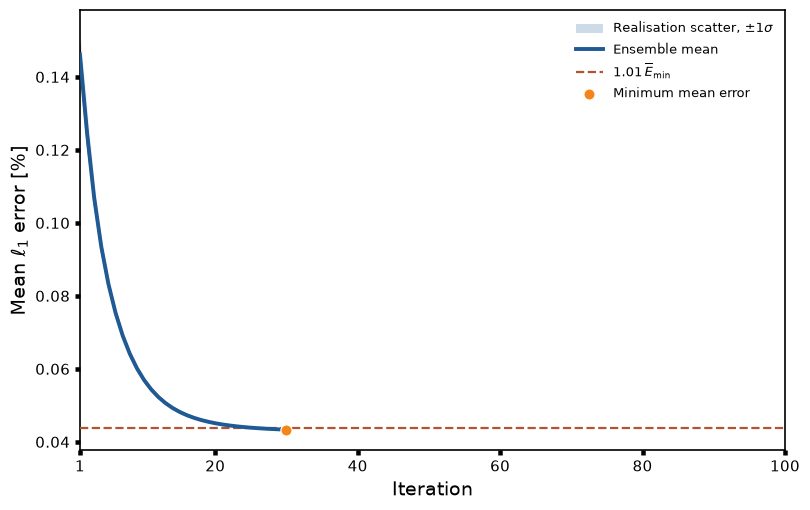

In [15]:
# ============================================================
# L1 CONVERGENCE BY ITERATION
#
# Behaviour after a kernel restart:
#
# 1. Load the combined L1-history NPZ when it exists and is
#    compatible with the current master configuration.
#
# 2. Otherwise reconstruct it from the individual emulator
#    L1-history files.
#
# 3. If the individual histories Do not exist, Do not start an
#    emulation here. Print a clear instruction instead.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Plot settings
# ============================================================

PLOT_L1_CONVERGENCE = True
L1_CONVERGENCE_LOG_Y = False


# ============================================================
# Current expected metadata
# ============================================================

EXPECTED_REALISATION_INDICES = np.arange(
    REALISATION_START,
    REALISATION_END + 1,
    dtype=np.int64,
)

EXPECTED_SCALE_NAMES = np.asarray(
    [
        f"{a:g}-{b:g}"
        for a, b in EMULATION_L1_BANDS
    ]
    + [
        f"coarse-{EMULATION_COARSE_ARCMIN:g}"
    ],
    dtype=str,
)


COMBINED_L1_HISTORY_PATH = (
    EMULATION_OUTPUT_DIR
    / (
        f"emulation_l1_history_"
        f"{source_token()}_"
        f"{REALISATION_START:03d}_"
        f"{REALISATION_END:03d}.npz"
    )
)


# ============================================================
# Helper: validate a combined saved product
# ============================================================

def combined_l1_history_is_compatible(path):

    try:
        with np.load(path, allow_pickle=False) as f:

            required = {
                "realisation_indices",
                "iterations",
                "all_mean_l1_error_percent",
                "mean_l1_error_percent",
                "std_l1_error_percent",
                "minimum_iteration",
                "minimum_error_percent",
                "harmonic_iter",
                "nside",
                "lmax",
                "n_iterations",
                "source_tag",
                "scale_names",
                "coarse_arcmin",
            }

            missing = required - set(f.files)

            if missing:
                return (
                    False,
                    "missing metadata: "
                    + ", ".join(sorted(missing)),
                )

            checks = [
                (
                    np.array_equal(
                        np.asarray(
                            f["realisation_indices"],
                            dtype=np.int64,
                        ),
                        EXPECTED_REALISATION_INDICES,
                    ),
                    "realisation range",
                ),
                (
                    int(f["harmonic_iter"])
                    == HARMONIC_ITER,
                    "HARMONIC_ITER",
                ),
                (
                    int(f["nside"])
                    == EMULATION_NSIDE,
                    "EMULATION_NSIDE",
                ),
                (
                    int(f["lmax"])
                    == EMULATION_LMAX,
                    "EMULATION_LMAX",
                ),
                (
                    int(f["n_iterations"])
                    == N_ITERATIONS,
                    "N_ITERATIONS",
                ),
                (
                    str(f["source_tag"])
                    == source_token(),
                    "source tag",
                ),
                (
                    np.array_equal(
                        np.asarray(
                            f["scale_names"],
                            dtype=str,
                        ),
                        EXPECTED_SCALE_NAMES,
                    ),
                    "L1 scale names",
                ),
                (
                    np.isclose(
                        float(f["coarse_arcmin"]),
                        float(
                            EMULATION_COARSE_ARCMIN
                        ),
                    ),
                    "coarse scale",
                ),
            ]

            failed = [
                label
                for ok, label in checks
                if not ok
            ]

            if failed:
                return (
                    False,
                    "incompatible metadata: "
                    + ", ".join(failed),
                )

    except Exception as exc:
        return (
            False,
            f"validation failed: {exc}",
        )

    return True, "compatible"


# ============================================================
# Try the combined saved product first
# ============================================================

L1_HISTORY_AVAILABLE = False
LOAD_COMBINED = False

if COMBINED_L1_HISTORY_PATH.exists():

    compatible, reason = (
        combined_l1_history_is_compatible(
            COMBINED_L1_HISTORY_PATH
        )
    )

    if compatible:
        LOAD_COMBINED = True

        print()
        print("=" * 88)
        print("EXISTING COMBINED L1 HISTORY FOUND")
        print("=" * 88)
        print("File :", COMBINED_L1_HISTORY_PATH)
        print("Status: compatible")
        print("=" * 88)

    else:
        print()
        print("=" * 88)
        print("EXISTING COMBINED L1 HISTORY IGNORED")
        print("=" * 88)
        print("File   :", COMBINED_L1_HISTORY_PATH)
        print("Reason :", reason)
        print(
            "The notebook will try to rebuild the combined "
            "history from individual emulator histories."
        )
        print("=" * 88)


if LOAD_COMBINED:

    with np.load(
        COMBINED_L1_HISTORY_PATH,
        allow_pickle=False,
    ) as f:

        realisation_indices = np.asarray(
            f["realisation_indices"],
            dtype=np.int64,
        )

        iterations = np.asarray(
            f["iterations"],
            dtype=np.int64,
        )

        error_matrix = np.asarray(
            f["all_mean_l1_error_percent"],
            dtype=np.float64,
        )

        mean_error = np.asarray(
            f["mean_l1_error_percent"],
            dtype=np.float64,
        )

        std_error = np.asarray(
            f["std_l1_error_percent"],
            dtype=np.float64,
        )

        minimum_iteration = int(
            f["minimum_iteration"]
        )

        minimum_error = float(
            f["minimum_error_percent"]
        )

    L1_HISTORY_AVAILABLE = True


# ============================================================
# Reconstruct from individual histories when needed
# ============================================================

else:

    results = []
    missing_history_files = []

    for realisation_index in EXPECTED_REALISATION_INDICES:

        realisation_index = int(
            realisation_index
        )

        history_path = emulation_history_path(
            realisation_index
        )

        map_path = emulation_map_path(
            realisation_index
        )

        if not history_path.exists():
            missing_history_files.append(
                history_path
            )
            continue

        with np.load(
            history_path,
            allow_pickle=False,
        ) as h:

            mean_history = np.asarray(
                h["mean_l1_error_percent"],
                dtype=np.float64,
            )

            scale_history = np.asarray(
                h["scale_l1_error_percent"],
                dtype=np.float64,
            )

            # Older history files may not contain every
            # metadata field. Validate all available fields.
            optional_checks = []

            if "harmonic_iter" in h.files:
                optional_checks.append(
                    (
                        int(h["harmonic_iter"])
                        == HARMONIC_ITER,
                        "HARMONIC_ITER",
                    )
                )

            if "nside" in h.files:
                optional_checks.append(
                    (
                        int(h["nside"])
                        == EMULATION_NSIDE,
                        "EMULATION_NSIDE",
                    )
                )

            if "lmax" in h.files:
                optional_checks.append(
                    (
                        int(h["lmax"])
                        == EMULATION_LMAX,
                        "EMULATION_LMAX",
                    )
                )

            if "source_tag" in h.files:
                optional_checks.append(
                    (
                        str(h["source_tag"])
                        == source_token(),
                        "source tag",
                    )
                )

            if "scale_names" in h.files:
                optional_checks.append(
                    (
                        np.array_equal(
                            np.asarray(
                                h["scale_names"],
                                dtype=str,
                            ),
                            EXPECTED_SCALE_NAMES,
                        ),
                        "L1 scale names",
                    )
                )

            failed = [
                label
                for ok, label in optional_checks
                if not ok
            ]

            if failed:
                raise ValueError(
                    "Incompatible individual L1 history for "
                    f"realisation {realisation_index:03d}: "
                    + ", ".join(failed)
                )

        if mean_history.size != N_ITERATIONS:
            raise ValueError(
                "Incompatible number of iterations for "
                f"realisation {realisation_index:03d}: "
                f"saved={mean_history.size}, "
                f"current={N_ITERATIONS}"
            )

        results.append(
            {
                "realisation_index":
                    realisation_index,
                "map_path":
                    str(map_path),
                "history_path":
                    str(history_path),
                "mean_history":
                    mean_history,
                "scale_history":
                    scale_history,
            }
        )


    if missing_history_files:

        print()
        print("=" * 88)
        print("L1 HISTORY FILES ARE NOT AVAILABLE")
        print("=" * 88)
        print(
            "The following required emulator history file(s) "
            "were not found:"
        )

        for path in missing_history_files:
            print("  ", path)

        print()
        print(
            "Run the emulation first by setting "
            "RUN_EMULATION = True in the MASTER PARAMETERS cell."
        )
        print("=" * 88)


    else:

        results = sorted(
            results,
            key=lambda x: x[
                "realisation_index"
            ],
        )

        error_matrix = np.stack(
            [
                np.asarray(
                    r["mean_history"],
                    dtype=np.float64,
                )
                for r in results
            ],
            axis=0,
        )

        realisation_indices = np.asarray(
            [
                r["realisation_index"]
                for r in results
            ],
            dtype=np.int64,
        )

        iterations = np.arange(
            1,
            error_matrix.shape[1] + 1,
            dtype=np.int64,
        )

        mean_error = np.mean(
            error_matrix,
            axis=0,
        )

        std_error = (
            np.std(
                error_matrix,
                axis=0,
                ddof=1,
            )
            if error_matrix.shape[0] > 1
            else np.zeros_like(
                mean_error
            )
        )

        minimum_index = int(
            np.argmin(
                mean_error
            )
        )

        minimum_iteration = int(
            iterations[
                minimum_index
            ]
        )

        minimum_error = float(
            mean_error[
                minimum_index
            ]
        )

        np.savez_compressed(
            COMBINED_L1_HISTORY_PATH,
            realisation_indices=
                realisation_indices,
            iterations=
                iterations,
            all_mean_l1_error_percent=
                error_matrix,
            mean_l1_error_percent=
                mean_error,
            std_l1_error_percent=
                std_error,
            minimum_iteration=
                np.int64(
                    minimum_iteration
                ),
            minimum_error_percent=
                np.float64(
                    minimum_error
                ),
            harmonic_iter=
                np.int64(
                    HARMONIC_ITER
                ),
            nside=
                np.int64(
                    EMULATION_NSIDE
                ),
            lmax=
                np.int64(
                    EMULATION_LMAX
                ),
            n_iterations=
                np.int64(
                    N_ITERATIONS
                ),
            source_tag=
                np.asarray(
                    source_token()
                ),
            scale_names=
                EXPECTED_SCALE_NAMES,
            coarse_arcmin=
                np.float64(
                    EMULATION_COARSE_ARCMIN
                ),
        )

        print()
        print(
            "[SAVED] Combined L1 history:"
        )
        print(
            COMBINED_L1_HISTORY_PATH
        )

        L1_HISTORY_AVAILABLE = True


# ============================================================
# Summary and publication-style plot
# ============================================================

if L1_HISTORY_AVAILABLE:

    # --------------------------------------------------------
    # Minimum and relative plateau-convergence threshold
    # --------------------------------------------------------

    minimum_index = int(
        np.argmin(mean_error)
    )

    minimum_iteration = int(
        iterations[minimum_index]
    )

    minimum_error = float(
        mean_error[minimum_index]
    )

    relative_tolerance = 0.01
    required_consecutive = 10

    convergence_threshold = (
        minimum_error
        *
        (
            1.0
            +
            relative_tolerance
        )
    )


    # The convergence iteration is the first iteration that
    # begins a sequence of at least ten consecutive values
    # within 1 per cent of the final minimum.

    below_threshold = (
        mean_error
        <=
        convergence_threshold
    )

    if iterations.size < required_consecutive:
        raise ValueError(
            "The saved history is shorter than the required "
            f"{required_consecutive} consecutive iterations."
        )

    window_counts = np.convolve(
        below_threshold.astype(np.int64),
        np.ones(
            required_consecutive,
            dtype=np.int64,
        ),
        mode="valid",
    )

    valid_starts = np.flatnonzero(
        window_counts
        ==
        required_consecutive
    )

    if valid_starts.size > 0:

        convergence_index = int(
            valid_starts[0]
        )

        convergence_iteration = int(
            iterations[
                convergence_index
            ]
        )

    else:

        convergence_index = None
        convergence_iteration = None


    # --------------------------------------------------------
    # Numerical summary
    # --------------------------------------------------------

    print()
    print("=" * 88)
    print("L1 CONVERGENCE")
    print("=" * 88)

    print(
        "Realisations              :",
        realisation_indices,
    )

    print(
        "Minimum mean error        :",
        f"{minimum_error:.6f}%",
    )

    print(
        "Minimum + 1% threshold    :",
        f"{convergence_threshold:.6f}%",
    )

    print(
        "Minimum iteration         :",
        minimum_iteration,
    )

    print(
        "Stable convergence iter.  :",
        (
            convergence_iteration
            if convergence_iteration is not None
            else "not found"
        ),
    )

    print("=" * 88)


    # ========================================================
    # Plot
    # ========================================================

    if PLOT_L1_CONVERGENCE:

        # ----------------------------------------------------
        # Figure and colours
        # ----------------------------------------------------

        figure_colour = "#1F5A94"
        threshold_colour = "#B55233"
        convergence_colour = "#54A24B"
        minimum_colour = "#F58518"

        fig, ax = plt.subplots(
            figsize=(8.2, 5.2)
        )


        # ----------------------------------------------------
        # Individual histories for all realisations
        # ----------------------------------------------------

        for index in range(
            error_matrix.shape[0]
        ):

            ax.plot(
                iterations,
                error_matrix[index],
                color="0.50",
                linewidth=0.65,
                alpha=0.12,
                zorder=1,
            )


        # ----------------------------------------------------
        # Pointwise realisation-to-realisation scatter
        # ----------------------------------------------------

        ax.fill_between(
            iterations,
            mean_error - std_error,
            mean_error + std_error,
            color=figure_colour,
            alpha=0.22,
            linewidth=0.0,
            label=r"Realisation scatter, $\pm1\sigma$",
            zorder=2,
        )


        # ----------------------------------------------------
        # Ensemble mean
        # ----------------------------------------------------

        ax.plot(
            iterations,
            mean_error,
            color=figure_colour,
            linewidth=2.8,
            label=(
                "Ensemble mean"
            ),
            zorder=4,
        )


        # ----------------------------------------------------
        # Minimum plus 1 per cent threshold
        # ----------------------------------------------------

        ax.axhline(
            convergence_threshold,
            color=threshold_colour,
            linestyle="--",
            linewidth=1.6,
            label=(
                r"$1.01\,\overline{E}_{\min}$"
            ),
            zorder=3,
        )


        # ----------------------------------------------------
        # Stable convergence range
        # ----------------------------------------------------

        if convergence_iteration is not None:

            ax.axvspan(
                convergence_iteration,
                iterations[-1],
                color=convergence_colour,
                alpha=0.08,
                linewidth=0.0,
                zorder=0,
            )

            ax.axvline(
                convergence_iteration,
                color=convergence_colour,
                linestyle=":",
                linewidth=1.8,
                zorder=3,
            )


        # ----------------------------------------------------
        # Minimum point
        # ----------------------------------------------------

        ax.scatter(
            minimum_iteration,
            minimum_error,
            s=65,
            color=minimum_colour,
            edgecolor="white",
            linewidth=0.9,
            label="Minimum mean error",
            zorder=6,
        )


        # ----------------------------------------------------
        # Compact convergence annotation
        # ----------------------------------------------------

        if convergence_iteration is not None:

            annotation_x = convergence_iteration
            annotation_y = convergence_threshold

            ax.annotate(
                (
                    rf"$i_{{\rm conv}}="
                    rf"{convergence_iteration}$"
                    "\n"
                    rf"$\overline{{E}}_{{\min}}="
                    rf"{minimum_error:.4f}\%$"
                    "\n"
                    rf"$1.01\,\overline{{E}}_{{\min}}="
                    rf"{convergence_threshold:.4f}\%$"
                ),
                xy=(
                    annotation_x,
                    annotation_y,
                ),
                xytext=(
                    12,
                    18,
                ),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=10,
                color="0.15",
                arrowprops={
                    "arrowstyle": "-",
                    "color": convergence_colour,
                    "linewidth": 1.0,
                },
            )


        # ----------------------------------------------------
        # Axes and ticks
        # ----------------------------------------------------

        ax.set_xlim(
            iterations[0],
            iterations[-1],
        )

        ax.set_xlabel(
            "Iteration",
            fontsize=14,
        )

        ax.set_ylabel(
            r"Mean $\ell_1$ error [%]",
            fontsize=14,
        )

        # Fixed x-axis tick positions
        ax.set_xticks(
            [
                1,
                20,
                40,
                60,
                80,
                100,
            ]
        )

        ax.tick_params(
            axis="both",
            labelsize=11,
        )


        # ----------------------------------------------------
        # Optional logarithmic y-axis
        # ----------------------------------------------------

        if L1_CONVERGENCE_LOG_Y:

            ax.set_yscale(
                "log"
            )


        # ----------------------------------------------------
        # Legend and frame
        # ----------------------------------------------------

        ax.legend(
            loc="upper right",
            fontsize=9.5,
            frameon=False,
        )

        for spine in ax.spines.values():

            spine.set_linewidth(
                1.2
            )


        # No large title
        # No grid

        fig.tight_layout()
        plt.show()

## 13. Measure and save power spectra of emulated maps


In [16]:
# ============================================================
# Measure power spectra from selected emulated maps
#
# Input:
#   individual emulation NPY files
#
# Output:
#   one combined NPZ containing:
#
#       ells
#       all_cls
#       mean_cls
#       std_cls
#       realisation_indices
#       map_paths
#       nside
#       lmax
#       source information
#
# Saved-product behaviour:
#
#   If the expected output NPZ already exists and is compatible
#   with the current settings, the expensive hp.anafast()
#   calculation is skipped and the saved results are restored.
#
# ============================================================

import gc
import time
import shutil

from pathlib import Path

import numpy as np
import healpy as hp


# ============================================================
# Selected realisation range
# ============================================================

MEASURE_REALISATION_INDICES = np.arange(
    REALISATION_START,
    REALISATION_END + 1,
    dtype=np.int64,
)


# ============================================================
# Source tag
#
# Use exactly the same source tag as the emulator.
# ============================================================

if "SOURCE_TAG" not in globals():

    raise NameError(
        "SOURCE_TAG is not defined.\n"
        "Run the source-configuration cells first."
    )


EMULATION_SOURCE_TAG = source_token()

# RevB stored SOURCE_TAG, whereas RevC uses the filename-oriented
# source_token().  Accept both when validating a legacy saved product.
ACCEPTED_SOURCE_TAGS = {
    EMULATION_SOURCE_TAG,
    str(SOURCE_TAG),
}


# ============================================================
# Basic settings
# ============================================================

NSIDE_MEASURE = int(
    EMULATION_NSIDE
)


LMAX_MEASURE = int(
    EMULATION_LMAX
)


EXPECTED_NPIX = hp.nside2npix(
    NSIDE_MEASURE
)


# ============================================================
# Check emulation output directory
# ============================================================

if not EMULATION_OUTPUT_DIR.exists():

    raise FileNotFoundError(
        "Emulation output directory does not exist:\n"
        f"{EMULATION_OUTPUT_DIR}"
    )


# ============================================================
# Output path
#
# Define this BEFORE measuring anything so that an existing
# result can be detected immediately.
# ============================================================

ps_out = (
    EMULATION_OUTPUT_DIR
    /
    (
        f"emulation_power_spectra_"
        f"{source_token()}_"
        f"{REALISATION_START:03d}_"
        f"{REALISATION_END:03d}"
        f".npz"
    )
)


# RevB compatibility: older notebooks used a filename without
# the source tag.  A compatible legacy file is migrated rather
# than forcing a new hp.anafast() calculation.
legacy_ps_out = (
    EMULATION_OUTPUT_DIR
    / (
        f"emulation_power_spectra_"
        f"{REALISATION_START:03d}_"
        f"{REALISATION_END:03d}.npz"
    )
)

if ps_out.exists():
    ps_product_path = ps_out
elif legacy_ps_out.exists():
    ps_product_path = legacy_ps_out
else:
    ps_product_path = ps_out


# ============================================================
# Check for an existing compatible result
# ============================================================

USE_SAVED_POWER_SPECTRA = False


if ps_product_path.exists():

    print()
    print("=" * 96)
    print("EXISTING EMULATION POWER-SPECTRUM FILE FOUND")
    print("=" * 96)
    print("File :", ps_product_path)
    print("Checking compatibility...")


    try:

        with np.load(
            ps_product_path,
            allow_pickle=False,
        ) as saved:

            # ----------------------------------------------------
            # Required metadata
            # ----------------------------------------------------

            saved_nside = int(
                saved["nside"]
            )

            saved_lmax = int(
                saved["lmax"]
            )

            saved_indices = np.asarray(
                saved["realisation_indices"],
                dtype=np.int64,
            )

            # ----------------------------------------------------
            # Optional metadata
            #
            # Older files may not contain every metadata field.
            # ----------------------------------------------------

            saved_source_tag = (
                str(saved["source_tag"])
                if "source_tag" in saved.files
                else None
            )

            saved_harmonic_iter = (
                int(saved["harmonic_iter"])
                if "harmonic_iter" in saved.files
                else None
            )


        compatible = True

        incompatibility_reasons = []


        # --------------------------------------------------------
        # NSIDE
        # --------------------------------------------------------

        if saved_nside != NSIDE_MEASURE:

            compatible = False

            incompatibility_reasons.append(
                f"NSIDE mismatch: "
                f"saved={saved_nside}, "
                f"current={NSIDE_MEASURE}"
            )


        # --------------------------------------------------------
        # LMAX
        # --------------------------------------------------------

        if saved_lmax != LMAX_MEASURE:

            compatible = False

            incompatibility_reasons.append(
                f"LMAX mismatch: "
                f"saved={saved_lmax}, "
                f"current={LMAX_MEASURE}"
            )


        # --------------------------------------------------------
        # Realisation range
        # --------------------------------------------------------

        if not np.array_equal(
            saved_indices,
            MEASURE_REALISATION_INDICES,
        ):

            compatible = False

            incompatibility_reasons.append(
                "Realisation indices mismatch:\n"
                f"    saved   = {saved_indices}\n"
                f"    current = {MEASURE_REALISATION_INDICES}"
            )


        # --------------------------------------------------------
        # Source tag
        # --------------------------------------------------------

        if (
            saved_source_tag is not None
            and
            saved_source_tag not in ACCEPTED_SOURCE_TAGS
        ):

            compatible = False

            incompatibility_reasons.append(
                f"SOURCE_TAG mismatch: "
                f"saved={saved_source_tag}, "
                f"current={EMULATION_SOURCE_TAG}"
            )


        # --------------------------------------------------------
        # Harmonic iteration
        #
        # Older output files may not contain this field.
        # In that case, Do not reject the file.
        # --------------------------------------------------------

        if (
            saved_harmonic_iter is not None
            and
            saved_harmonic_iter != HARMONIC_ITER
        ):

            compatible = False

            incompatibility_reasons.append(
                f"HARMONIC_ITER mismatch: "
                f"saved={saved_harmonic_iter}, "
                f"current={HARMONIC_ITER}"
            )


        # --------------------------------------------------------
        # Result
        # --------------------------------------------------------

        if compatible:

            USE_SAVED_POWER_SPECTRA = True

            print(
                "Existing file is compatible."
            )

            print(
                "Power-spectrum calculation will be skipped."
            )

        else:

            print()
            print(
                "Existing file is NOT compatible "
                "with the current settings."
            )

            for reason in incompatibility_reasons:

                print(
                    "  -",
                    reason,
                )

            print()
            print(
                "The power spectra will be recalculated "
                "and the existing file will be overwritten."
            )


    except Exception as exc:

        print()
        print(
            "The existing file could not be validated."
        )

        print(
            "Reason:",
            repr(exc),
        )

        print()
        print(
            "The power spectra will be recalculated "
            "and the existing file will be overwritten."
        )


# ============================================================
# CASE 1:
# Existing compatible power-spectrum file
#
# Restore saved arrays and skip hp.anafast().
# ============================================================

if USE_SAVED_POWER_SPECTRA:

    with np.load(
        ps_product_path,
        allow_pickle=False,
    ) as saved:

        ells = np.asarray(
            saved["ells"],
            dtype=np.int64,
        )

        all_cls = np.asarray(
            saved["all_cls"],
            dtype=np.float64,
        )

        mean_cls = np.asarray(
            saved["mean_cls"],
            dtype=np.float64,
        )

        std_cls = np.asarray(
            saved["std_cls"],
            dtype=np.float64,
        )

        measured_indices = np.asarray(
            saved["realisation_indices"],
            dtype=np.int64,
        )

        map_paths = np.asarray(
            saved["map_paths"],
            dtype=str,
        )

        saved_nside = int(
            saved["nside"]
        )

        saved_lmax = int(
            saved["lmax"]
        )


    print()
    print("=" * 96)
    print("EMULATION POWER SPECTRA RESTORED FROM SAVED PRODUCT")
    print("=" * 96)

    print(
        "Realisations    :",
        measured_indices,
    )

    print(
        "Number of maps  :",
        measured_indices.size,
    )

    print(
        "all_cls shape   :",
        all_cls.shape,
    )

    print(
        "mean_cls shape  :",
        mean_cls.shape,
    )

    print(
        "std_cls shape   :",
        std_cls.shape,
    )

    print(
        "ell range       :",
        f"{ells.min()} - {ells.max()}",
    )

    print(
        "NSIDE           :",
        saved_nside,
    )

    print(
        "lmax            :",
        saved_lmax,
    )

    print(
        "[LOADED]        :",
        ps_product_path,
    )

    print("=" * 96)

    if (
        ps_product_path == legacy_ps_out
        and not ps_out.exists()
    ):
        shutil.copy2(
            legacy_ps_out,
            ps_out,
        )
        print(
            "[MIGRATED] Legacy power-spectrum saved product ->",
            ps_out,
        )


# ============================================================
# CASE 2:
# No compatible saved result
#
# Measure the power spectra from the emulated maps.
# ============================================================

else:

    # ========================================================
    # Find requested emulated maps
    # ========================================================

    paths = []


    for realisation_index in MEASURE_REALISATION_INDICES:

        pattern = (
            f"emu_*_"
            f"Nside{NSIDE_MEASURE}_"
            f"lmax{LMAX_MEASURE}_"
            f"{int(realisation_index):02d}.npy"
        )


        candidates = sorted(
            EMULATION_OUTPUT_DIR.glob(
                pattern
            )
        )


        if len(candidates) == 0:

            raise FileNotFoundError(
                "Emulated map not found.\n"
                f"Directory: {EMULATION_OUTPUT_DIR}\n"
                f"Pattern  : {pattern}"
            )


        if len(candidates) > 1:

            raise RuntimeError(
                "Multiple emulated maps found:\n"
                +
                "\n".join(
                    str(path)
                    for path in candidates
                )
            )


        paths.append(
            candidates[0]
        )


    # ========================================================
    # Initial summary
    # ========================================================

    print()
    print("=" * 96)
    print("EMULATION POWER-SPECTRUM MEASUREMENT")
    print("=" * 96)


    print(
        "Realisations   :",
        MEASURE_REALISATION_INDICES,
    )


    print(
        "Number of maps :",
        len(
            paths
        ),
    )


    print(
        "NSIDE          :",
        NSIDE_MEASURE,
    )


    print(
        "Expected NPIX  :",
        EXPECTED_NPIX,
    )


    print(
        "lmax           :",
        LMAX_MEASURE,
    )


    print(
        "Harmonic iter  :",
        HARMONIC_ITER,
    )


    print(
        "Source tag     :",
        EMULATION_SOURCE_TAG,
    )


    print(
        "Input dir      :",
        EMULATION_OUTPUT_DIR,
    )


    print(
        "Output file    :",
        ps_out,
    )


    print("=" * 96)


    # ========================================================
    # Storage
    # ========================================================

    all_cls = []

    measured_indices = []

    map_paths = []


    # ========================================================
    # Measure power spectra
    # ========================================================

    total_start = time.perf_counter()


    for i, (
        realisation_index,
        path,
    ) in enumerate(
        zip(
            MEASURE_REALISATION_INDICES,
            paths,
        ),
        start=1,
    ):

        map_start = time.perf_counter()


        print()
        print("-" * 96)


        print(
            f"[Map {i}/{len(paths)}] "
            f"Realisation {int(realisation_index):03d} START",
            flush=True,
        )


        print(
            f"    file = {path.name}",
            flush=True,
        )


        # ====================================================
        # Load map
        #
        # The emulator saves a plain NPY array.
        #
        # mmap_mode='r':
        #     avoids an unnecessary full copy at load time.
        # ====================================================

        print(
            f"[Map {i}/{len(paths)}] "
            "Loading map...",
            flush=True,
        )


        m_memmap = np.load(
            path,
            mmap_mode="r",
            allow_pickle=False,
        )


        # ====================================================
        # Map validation
        # ====================================================

        if m_memmap.ndim != 1:

            raise ValueError(
                "Emulated map must be one-dimensional.\n"
                f"Shape : {m_memmap.shape}\n"
                f"File  : {path}"
            )


        if m_memmap.size != EXPECTED_NPIX:

            inferred_nside = None


            try:

                inferred_nside = hp.npix2nside(
                    int(
                        m_memmap.size
                    )
                )

            except Exception:

                pass


            raise ValueError(
                "Emulated-map pixel count does not match "
                "the current NSIDE setting.\n"
                f"File          : {path}\n"
                f"Pixels        : {m_memmap.size}\n"
                f"Expected      : {EXPECTED_NPIX}\n"
                f"NSIDE setting : {NSIDE_MEASURE}\n"
                f"Inferred NSIDE: {inferred_nside}"
            )


        if not np.all(
            np.isfinite(
                m_memmap
            )
        ):

            raise ValueError(
                "Emulated map contains NaN or infinite values.\n"
                f"{path}"
            )


        # ====================================================
        # Convert for HEALPix calculation
        #
        # The saved map is usually float32.
        # Use float64 for the harmonic measurement.
        # ====================================================

        m = np.asarray(
            m_memmap,
            dtype=np.float64,
        )


        del m_memmap


        # ====================================================
        # Optional monopole diagnostic
        #
        # We Do not modify the saved map here.
        # This is measurement only.
        # ====================================================

        map_mean = float(
            np.mean(
                m
            )
        )


        map_std = float(
            np.std(
                m
            )
        )


        print(
            f"    mean = {map_mean:+.6e}",
            flush=True,
        )


        print(
            f"    std  = {map_std:.6e}",
            flush=True,
        )


        # ====================================================
        # Measure C_ell
        # ====================================================

        print(
            f"[Map {i}/{len(paths)}] "
            f"Running hp.anafast "
            f"(lmax={LMAX_MEASURE}, "
            f"iter={HARMONIC_ITER})...",
            flush=True,
        )


        cl = hp.anafast(
            m,
            lmax=LMAX_MEASURE,
            iter=HARMONIC_ITER,
            pol=False,
            use_pixel_weights=False,
        )


        cl = np.asarray(
            cl,
            dtype=np.float64,
        )


        # ====================================================
        # Validate C_ell length
        # ====================================================

        if cl.size != (
            LMAX_MEASURE
            +
            1
        ):

            raise RuntimeError(
                "Unexpected C_ell length.\n"
                f"Expected : {LMAX_MEASURE + 1}\n"
                f"Measured : {cl.size}\n"
                f"File     : {path}"
            )


        if not np.all(
            np.isfinite(
                cl
            )
        ):

            raise ValueError(
                "Measured power spectrum contains "
                "NaN or infinite values.\n"
                f"{path}"
            )


        # ====================================================
        # Store
        # ====================================================

        all_cls.append(
            cl
        )


        measured_indices.append(
            int(
                realisation_index
            )
        )


        map_paths.append(
            str(
                path
            )
        )


        # ====================================================
        # Progress
        # ====================================================

        elapsed = (
            time.perf_counter()
            -
            map_start
        )


        print(
            f"[Map {i}/{len(paths)}] DONE",
            flush=True,
        )


        print(
            f"    ell range = "
            f"0 - {cl.size - 1}",
            flush=True,
        )


        print(
            f"    elapsed   = "
            f"{elapsed / 60.0:.2f} min",
            flush=True,
        )


        # ====================================================
        # Cleanup
        # ====================================================

        del m
        del cl

        gc.collect()


    # ========================================================
    # Stack all spectra
    #
    # Shape:
    #
    #   (N_maps, LMAX_MEASURE + 1)
    # ========================================================

    all_cls = np.stack(
        all_cls,
        axis=0,
    ).astype(
        np.float64,
        copy=False,
    )


    measured_indices = np.asarray(
        measured_indices,
        dtype=np.int64,
    )


    map_paths = np.asarray(
        map_paths,
        dtype=str,
    )


    # ========================================================
    # Ensemble statistics
    # ========================================================

    mean_cls = np.mean(
        all_cls,
        axis=0,
    )


    if all_cls.shape[0] > 1:

        std_cls = np.std(
            all_cls,
            axis=0,
            ddof=1,
        )

    else:

        std_cls = np.zeros_like(
            mean_cls
        )


    # ========================================================
    # Ell array
    # ========================================================

    ells = np.arange(
        LMAX_MEASURE + 1,
        dtype=np.int64,
    )


    # ========================================================
    # Source metadata
    # ========================================================

    if "SOURCE_MODE" in globals():

        saved_source_mode = str(
            SOURCE_MODE
        )

    else:

        saved_source_mode = "unknown"


    # ========================================================
    # Save all selected spectra in one NPZ
    # ========================================================

    np.savez_compressed(

        ps_out,

        # ----------------------------------------------------
        # Multipoles
        # ----------------------------------------------------

        ells=
            ells,

        # ----------------------------------------------------
        # Individual measured spectra
        #
        # shape:
        #
        #     (N_maps, lmax + 1)
        # ----------------------------------------------------

        all_cls=
            all_cls,

        # ----------------------------------------------------
        # Ensemble statistics
        # ----------------------------------------------------

        mean_cls=
            mean_cls,

        std_cls=
            std_cls,

        # ----------------------------------------------------
        # Realisation information
        # ----------------------------------------------------

        realisation_indices=
            measured_indices,

        map_paths=
            map_paths,

        # ----------------------------------------------------
        # Harmonic / map settings
        # ----------------------------------------------------

        nside=
            np.int64(
                NSIDE_MEASURE
            ),

        lmax=
            np.int64(
                LMAX_MEASURE
            ),

        harmonic_iter=
            np.int64(
                HARMONIC_ITER
            ),

        # ----------------------------------------------------
        # Source metadata
        # ----------------------------------------------------

        source_mode=
            np.asarray(
                saved_source_mode
            ),

        source_tag=
            np.asarray(
                EMULATION_SOURCE_TAG
            ),

        # ----------------------------------------------------
        # Emulator metadata
        # ----------------------------------------------------

        emulator_method=
            np.asarray(
                "l1_plus_cl"
            ),

        l1_constraints=
            np.asarray(
                [
                    "10-20",
                    "20-40",
                    "coarse-40",
                ],
                dtype=str,
            ),
    )


    # ========================================================
    # Final summary
    # ========================================================

    total_elapsed = (
        time.perf_counter()
        -
        total_start
    )


    print()
    print("=" * 96)
    print("POWER-SPECTRUM MEASUREMENT COMPLETED")
    print("=" * 96)


    print(
        "Realisations    :",
        measured_indices,
    )


    print(
        "Number of maps  :",
        measured_indices.size,
    )


    print(
        "all_cls shape   :",
        all_cls.shape,
    )


    print(
        "mean_cls shape  :",
        mean_cls.shape,
    )


    print(
        "std_cls shape   :",
        std_cls.shape,
    )


    print(
        "ell range       :",
        f"{ells.min()} - {ells.max()}",
    )


    print(
        "NSIDE           :",
        NSIDE_MEASURE,
    )


    print(
        "lmax            :",
        LMAX_MEASURE,
    )


    print(
        "Harmonic iter   :",
        HARMONIC_ITER,
    )


    print(
        "Total time      :",
        f"{total_elapsed / 60.0:.2f} min",
    )


    print(
        "[SAVED]         :",
        ps_out,
    )


    print("=" * 96)



EXISTING EMULATION POWER-SPECTRUM FILE FOUND
File : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535\emulation_power_spectra_z1_0334_000_099.npz
Checking compatibility...
Existing file is compatible.
Power-spectrum calculation will be skipped.

EMULATION POWER SPECTRA RESTORED FROM SAVED PRODUCT
Realisations    : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Number of maps  : 100
all_cls shape   : (100, 1536)
mean_cls shape  : (1536,)
std_cls shape   : (1536,)
ell range       : 0 - 1535
NSIDE           : 512
lmax            : 1535
[LOADED]        : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535\emulation_power_spectra_z1_0334_000_099.npz


## 14. Power-spectrum comparison and correlation diagnostics


[WARNING] Expected 30 emulation realisations, found 100; using all.
[ELL RANGE] Theory     : 2 -- 3000
[ELL RANGE] Simulation : 2 -- 12287
[ELL RANGE] Emulation  : 0 -- 1535
[ELL RANGE] Common     : 2 -- 1535
[BINNING] Stored Theory bins total   : 40
[BINNING] Complete Theory bins used  : 36
[BINNING] Retained bin indices       : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
[BINNING] Retained edge range        : 2.0 -- 1444.0
[BINNING] Largest matrix multipole   : 1443
[ANALYSIS] Maximum ell used in ALL panels: 1443
[ANALYSIS] Stored bins / retained bins: 40 / 36
[ENSEMBLE] Theory     : 100 realisations
[ENSEMBLE] Simulation : 100 realisations
[ENSEMBLE] Emulation  : 100 realisations
[ENSEMBLE] Emulation indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 

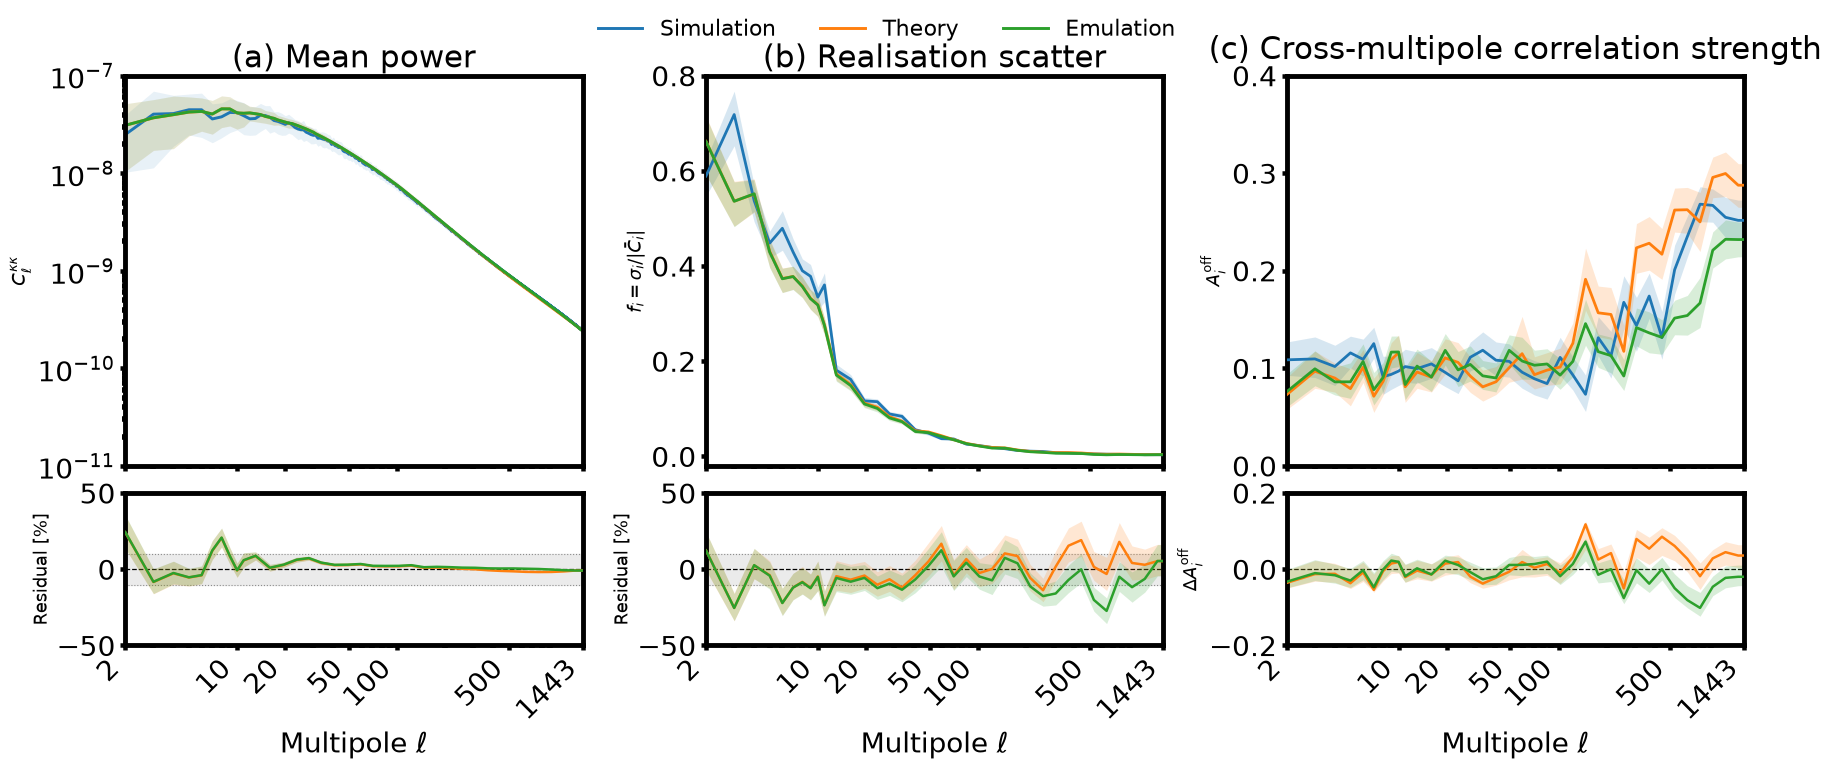

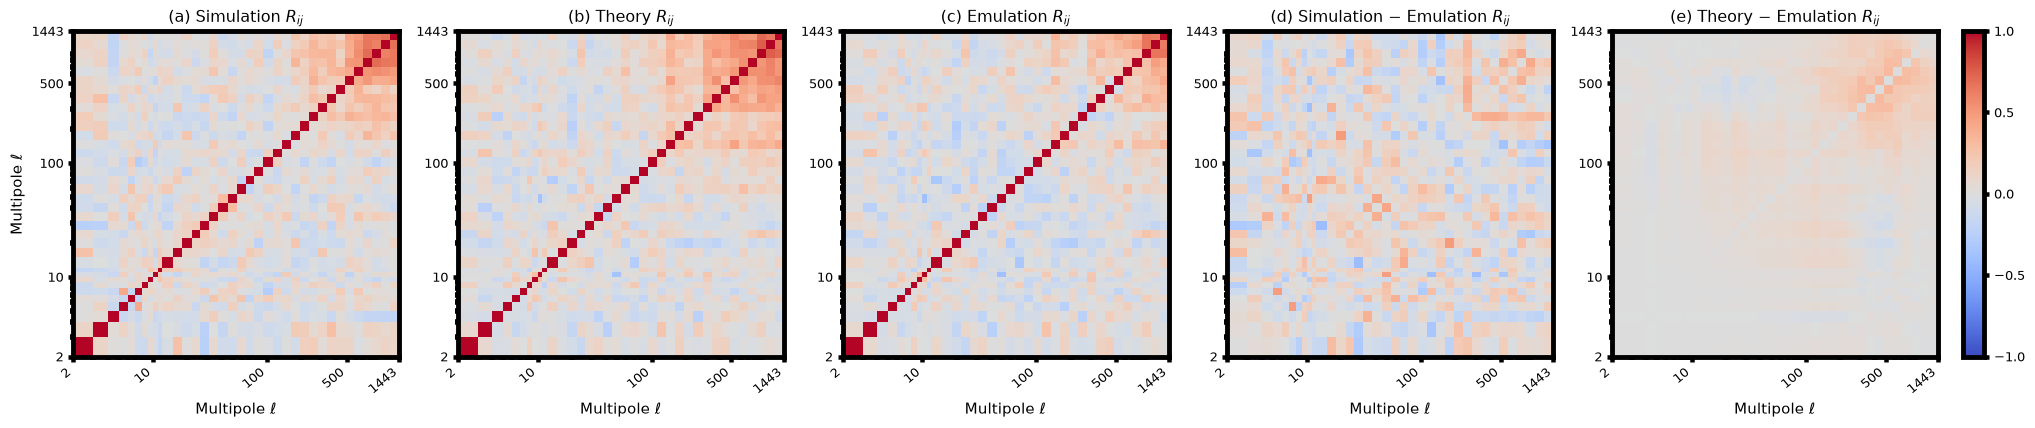

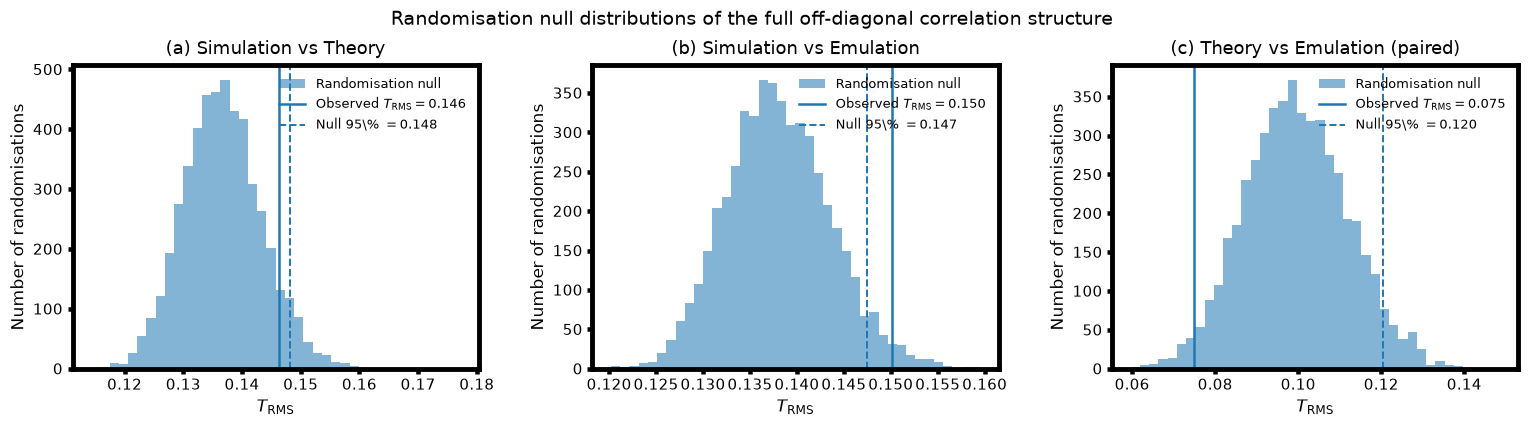


COMPACT NUMERICAL SUMMARY FOR PAPER DRAFTING
[f_i] Theory / Simulation: 61.1% within +/-10%, median |residual|=6.64%, 95th percentile |residual|=22.35%
[f_i] Emulation / Simulation: 58.3% within +/-10%, median |residual|=7.83%, 95th percentile |residual|=24.10%
[f_i] Emulation / Theory: 80.6% within +/-10%, median |residual|=2.42%, 95th percentile |residual|=19.92%
[R_ij] Simulation vs Theory (independent): T_RMS=0.1463, null95=0.1482, p=0.083983
[R_ij] Simulation vs Emulation (independent): T_RMS=0.1501, null95=0.1475, p=0.021396
[R_ij] Theory vs Emulation (paired): T_RMS=0.0750, null95=0.1203, p=0.978404


In [17]:
"""Paper-ready three-ensemble power-spectrum and correlation comparison.

This version uses exactly the same stored Theory binning as the original
Simulation-versus-Theory validation.

Expected upstream objects
-------------------------
TARGET_POWER_NPZ, SIMULATION_POWER_NPZ, EMULATION_OUTPUT_DIR,
EMULATION_NSIDE, EMULATION_LMAX, REALISATION_START, REALISATION_END,
and source_token().

Important binning rule
----------------------
- Read the binning matrix, bin edges, and effective multipoles directly from
  TARGET_POWER_NPZ.
- Do not construct a new logarithmic binning.
- Restrict the analysis to the common native multipole range supported by
  Simulation, Theory, and Emulation.
- Keep only complete stored Theory bins whose full support lies inside that
  common multipole range.
- Apply those identical retained Theory bins to all three ensembles.

The script creates exactly two figures.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter


# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

THEORY_PS_PATH = TARGET_POWER_NPZ
SIM_PS_PATH = SIMULATION_POWER_NPZ
EMU_PS_PATH = (
    EMULATION_OUTPUT_DIR
    / (
        f"emulation_power_spectra_{source_token()}_"
        f"{REALISATION_START:03d}_{REALISATION_END:03d}.npz"
    )
)

DISPLAY_ELL_MIN = 2
DISPLAY_ELL_MAX = 3000
POWER_YLIM = (1.0e-11, 1.0e-7)

AGREEMENT_TARGET_PCT = 10.0
N_CONSECUTIVE = 20
N_BOOTSTRAP = 5000          # use 1000 while developing
BOOTSTRAP_SEED = 20260902
N_PERMUTATIONS = 5000
PERMUTATION_SEED = 20260903

POWER_TICKS = np.array([2, 10, 20, 50, 100, 500], dtype=float)
MATRIX_TICKS = np.array([2, 10, 100, 500], dtype=float)
EPS = np.finfo(float).eps

SAVE_FIGURES = False
FIGURE_DIR = Path("stochasticity_figures")


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------



def extract_on_grid(source_ells, source_values, target_ells):
    """Extract values exactly on target_ells. No interpolation is performed."""
    source_ells = np.asarray(source_ells, dtype=np.int64)
    target_ells = np.asarray(target_ells, dtype=np.int64)

    indices = np.searchsorted(source_ells, target_ells)

    if np.any(indices >= source_ells.size):
        raise ValueError(
            "Requested ell exceeds source grid. "
            f"Source range is [{source_ells.min()}, {source_ells.max()}], "
            f"requested range is [{target_ells.min()}, {target_ells.max()}]."
        )

    if not np.array_equal(source_ells[indices], target_ells):
        missing = np.setdiff1d(target_ells, source_ells)
        raise ValueError(
            "Required ell values are missing from the source grid. "
            f"First missing values: {missing[:20]}"
        )

    return np.asarray(source_values)[..., indices]


def cov_to_corr(cov):
    cov = np.asarray(cov, dtype=float)
    sigma = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    denominator = np.outer(sigma, sigma)

    corr = np.zeros_like(cov)
    np.divide(cov, denominator, out=corr, where=denominator > 0.0)

    corr = 0.5 * (corr + corr.T)
    np.fill_diagonal(corr, 1.0)

    return np.clip(corr, -1.0, 1.0)


def row_offdiag_rms(corr):
    """RMS magnitude of off-diagonal correlations for each row."""
    corr = np.asarray(corr, dtype=float)
    p = corr.shape[0]

    if p < 2:
        return np.full(p, np.nan)

    corr_sq = corr**2
    return np.sqrt(
        (np.sum(corr_sq, axis=1) - np.diag(corr_sq))
        / (p - 1)
    )


def band_statistics(band):
    """Ensemble statistics of band powers."""
    band = np.asarray(band, dtype=float)

    if band.ndim != 2 or band.shape[0] < 2:
        raise ValueError("Each ensemble needs at least two realisations.")

    mean = np.mean(band, axis=0)
    cov = np.cov(band, rowvar=False, ddof=1)
    sigma = np.sqrt(np.clip(np.diag(cov), 0.0, None))
    corr = cov_to_corr(cov)

    return {
        "mean": mean,
        "sigma": sigma,
        "frms": safe_ratio(sigma, np.abs(mean)),
        "corr": corr,
        "coherence": row_offdiag_rms(corr),
    }


def bootstrap_ensemble(band, n_boot, seed):
    """Bootstrap over whole realisations."""
    band = np.asarray(band, dtype=float)
    n_real, n_bin = band.shape

    rng = np.random.default_rng(seed)

    result = {
        "mean": np.empty((n_boot, n_bin)),
        "frms": np.empty((n_boot, n_bin)),
        "coherence": np.empty((n_boot, n_bin)),
    }

    for b in range(n_boot):
        indices = rng.integers(0, n_real, size=n_real)
        stat = band_statistics(band[indices])

        for key in result:
            result[key][b] = stat[key]

    return result


def interval68(samples):
    lo, median, hi = np.nanpercentile(
        samples,
        [16.0, 50.0, 84.0],
        axis=0,
    )
    return {
        "lo": lo,
        "median": median,
        "hi": hi,
    }


def draw_ci68(
    ax,
    x,
    point,
    ci,
    label=None,
    linewidth=2.0,
    alpha=0.18,
    color=None,
):
    line, = ax.plot(
        x,
        point,
        linewidth=linewidth,
        label=label,
        color=color,
        zorder=4,
    )

    ax.fill_between(
        x,
        ci["lo"],
        ci["hi"],
        color=line.get_color(),
        alpha=alpha,
        linewidth=0,
        zorder=2,
    )

    return line


def extend_binned_curve_to_edge(x, y, edge_x):
    """
    Visually extend a binned curve to the right-hand analysis boundary.

    This does NOT create a new bin or change any statistic.  It simply
    repeats the final plotted band value at edge_x so the line reaches the
    displayed end of the multipole range.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.size == 0:
        return x, y

    if np.isclose(x[-1], edge_x):
        return x, y

    return (
        np.concatenate([x, [float(edge_x)]]),
        np.concatenate([y, [y[-1]]]),
    )


def extend_ci_to_edge(ci, edge_x):
    """Repeat the final confidence-band values at the visual right edge."""
    out = {}
    for key, value in ci.items():
        arr = np.asarray(value, dtype=float)
        out[key] = np.concatenate([arr, [arr[-1]]])
    return out


def recenter_interval_on_point(point, ci):
    """
    Recenter a bootstrap percentile interval on the plotted point estimate.

    The asymmetric bootstrap half-widths relative to the bootstrap median
    are preserved:
        lower = point - (median - lo)
        upper = point + (hi - median)
    """
    point = np.asarray(point, dtype=float)
    median = np.asarray(ci["median"], dtype=float)
    lo = np.asarray(ci["lo"], dtype=float)
    hi = np.asarray(ci["hi"], dtype=float)

    return {
        "lo": point - (median - lo),
        "median": point.copy(),
        "hi": point + (hi - median),
    }



def offdiag_rms_difference(r_a, r_b):
    """
    RMS difference between two correlation matrices over unique
    off-diagonal pairs only (i < j).
    """
    r_a = np.asarray(r_a, dtype=float)
    r_b = np.asarray(r_b, dtype=float)

    if r_a.shape != r_b.shape:
        raise ValueError(
            f"Correlation-matrix shapes differ: {r_a.shape} vs {r_b.shape}"
        )

    iu = np.triu_indices_from(r_a, k=1)
    delta = r_b[iu] - r_a[iu]
    delta = delta[np.isfinite(delta)]

    if delta.size == 0:
        return np.nan

    return float(np.sqrt(np.mean(delta**2)))


def independent_permutation_corr_test(
    band_a,
    band_b,
    name_a,
    name_b,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
):
    """
    Independent two-sample permutation test for the full correlation structure.

    Appropriate for Simulation--Theory and Simulation--Emulation, where there
    is no realisation-by-realisation pairing between the two ensembles.

    The two ensembles are pooled, labels are permuted, and the original sample
    sizes are preserved.
    """
    band_a = np.asarray(band_a, dtype=float)
    band_b = np.asarray(band_b, dtype=float)

    if band_a.ndim != 2 or band_b.ndim != 2:
        raise ValueError("Each ensemble must be 2D: [realisations, bins].")
    if band_a.shape[1] != band_b.shape[1]:
        raise ValueError("The two ensembles must use the same retained bins.")

    n_a = band_a.shape[0]
    n_b = band_b.shape[0]

    r_a_obs = band_statistics(band_a)["corr"]
    r_b_obs = band_statistics(band_b)["corr"]
    t_obs = offdiag_rms_difference(r_a_obs, r_b_obs)

    pooled = np.vstack([band_a, band_b])
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm, dtype=float)

    for p in range(n_perm):
        perm = rng.permutation(pooled.shape[0])

        a_p = pooled[perm[:n_a]]
        b_p = pooled[perm[n_a:n_a + n_b]]

        r_a_p = band_statistics(a_p)["corr"]
        r_b_p = band_statistics(b_p)["corr"]

        null[p] = offdiag_rms_difference(r_a_p, r_b_p)

    p_value = (1.0 + np.sum(null >= t_obs)) / (n_perm + 1.0)

    return {
        "kind": "independent",
        "name_a": name_a,
        "name_b": name_b,
        "observed_rms": float(t_obs),
        "null_rms": null,
        "null_median": float(np.percentile(null, 50.0)),
        "null_p68": float(np.percentile(null, 68.0)),
        "null_p95": float(np.percentile(null, 95.0)),
        "null_p99": float(np.percentile(null, 99.0)),
        "observed_percentile": 100.0 * float(np.mean(null <= t_obs)),
        "p_value": float(p_value),
    }


def paired_label_swap_corr_test(
    theory_band,
    emulation_band,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
):
    """
    Paired randomisation test for Theory--Emulation.

    Theory realisation i is the stochastic target used to generate Emulation
    realisation i. Therefore the pairing MUST be preserved.

    Under the paired null hypothesis of exchangeability within each matched
    Theory/Emulation pair, the two labels are independently swapped with
    probability 1/2 for each realisation. The full R_ij matrices are then
    recomputed and compared with T_RMS.
    """
    theory_band = np.asarray(theory_band, dtype=float)
    emulation_band = np.asarray(emulation_band, dtype=float)

    if theory_band.shape != emulation_band.shape:
        raise ValueError(
            "Paired Theory--Emulation test requires identical shapes. "
            f"Got {theory_band.shape} and {emulation_band.shape}."
        )

    r_theory_obs = band_statistics(theory_band)["corr"]
    r_emu_obs = band_statistics(emulation_band)["corr"]
    t_obs = offdiag_rms_difference(r_theory_obs, r_emu_obs)

    n_real = theory_band.shape[0]
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm, dtype=float)

    for p in range(n_perm):
        swap = rng.random(n_real) < 0.5

        theory_p = theory_band.copy()
        emu_p = emulation_band.copy()

        theory_p[swap] = emulation_band[swap]
        emu_p[swap] = theory_band[swap]

        r_theory_p = band_statistics(theory_p)["corr"]
        r_emu_p = band_statistics(emu_p)["corr"]

        null[p] = offdiag_rms_difference(r_theory_p, r_emu_p)

    p_value = (1.0 + np.sum(null >= t_obs)) / (n_perm + 1.0)

    return {
        "kind": "paired",
        "name_a": "Theory",
        "name_b": "Emulation",
        "observed_rms": float(t_obs),
        "null_rms": null,
        "null_median": float(np.percentile(null, 50.0)),
        "null_p68": float(np.percentile(null, 68.0)),
        "null_p95": float(np.percentile(null, 95.0)),
        "null_p99": float(np.percentile(null, 99.0)),
        "observed_percentile": 100.0 * float(np.mean(null <= t_obs)),
        "p_value": float(p_value),
    }


def summarise_fractional_scatter(reference_name, comparison_name):
    """
    Detailed quantitative summary of panel (b):
        residual_i = 100 * (f_i^comparison / f_i^reference - 1).
    """
    f_ref = np.asarray(stats[reference_name]["frms"], dtype=float)
    f_cmp = np.asarray(stats[comparison_name]["frms"], dtype=float)

    residual = 100.0 * (safe_ratio(f_cmp, f_ref) - 1.0)
    finite = residual[np.isfinite(residual)]
    absolute = np.abs(finite)

    return {
        "reference": reference_name,
        "comparison": comparison_name,
        "n_bins": int(finite.size),
        "within_5": 100.0 * float(np.mean(absolute <= 5.0)),
        "within_10": 100.0 * float(np.mean(absolute <= 10.0)),
        "within_20": 100.0 * float(np.mean(absolute <= 20.0)),
        "median_signed": float(np.median(finite)),
        "mean_signed": float(np.mean(finite)),
        "median_abs": float(np.median(absolute)),
        "mean_abs": float(np.mean(absolute)),
        "p68_abs": float(np.percentile(absolute, 68.0)),
        "p95_abs": float(np.percentile(absolute, 95.0)),
        "max_abs": float(np.max(absolute)),
    }


def add_percent_target_band(ax):
    patch = ax.axhspan(
        -AGREEMENT_TARGET_PCT,
        AGREEMENT_TARGET_PCT,
        color="0.92",
        zorder=0,
    )

    ax.axhline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=0.9,
    )
    ax.axhline(
        +AGREEMENT_TARGET_PCT,
        color="0.55",
        linestyle=":",
        linewidth=0.8,
    )
    ax.axhline(
        -AGREEMENT_TARGET_PCT,
        color="0.55",
        linestyle=":",
        linewidth=0.8,
    )

    return patch


def first_sustained_crossing(ells, difference, sim_sigma, threshold):
    """First ell where |difference/sim_sigma| exceeds threshold persistently."""
    z = safe_ratio(difference, sim_sigma)
    above = np.isfinite(z) & (np.abs(z) > threshold)

    if above.size < N_CONSECUTIVE:
        return None

    runs = np.convolve(
        above.astype(int),
        np.ones(N_CONSECUTIVE, dtype=int),
        mode="valid",
    )

    hit = np.flatnonzero(runs == N_CONSECUTIVE)

    return None if hit.size == 0 else int(ells[hit[0]])


def format_log_axis(ax, ell_min, ell_max):
    """
    Log multipole axis with fixed ticks 2, 10, 20, 50, 100, 500 plus the
    actual final analysis multipole.  The 1000 tick is intentionally omitted.
    """
    base_ticks = POWER_TICKS[
        (POWER_TICKS >= ell_min)
        & (POWER_TICKS <= ell_max)
    ]
    ticks = np.unique(
        np.concatenate(
            [base_ticks, np.array([float(ell_max)])]
        )
    )

    ax.set_xscale("log")
    ax.set_xlim(ell_min, ell_max)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(x)) for x in ticks])
    ax.xaxis.set_minor_formatter(NullFormatter())


def format_matrix_axis(ax, edges, matrix_ell_max):
    """
    Format the correlation-matrix axes.

    The fixed labelled ticks are 2, 10, 100, and 500.  The largest
    multipole actually represented by the retained Theory bins is appended
    explicitly as the final tick.  In the present setup this should be close
    to the common retained-bin analysis limit.
    """
    base_ticks = MATRIX_TICKS[
        (MATRIX_TICKS >= edges[0])
        & (MATRIX_TICKS <= matrix_ell_max)
    ]

    ticks = np.unique(
        np.concatenate(
            [base_ticks, np.array([float(matrix_ell_max)])]
        )
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(edges[0], matrix_ell_max)
    ax.set_ylim(edges[0], matrix_ell_max)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    labels = [str(int(x)) for x in ticks]
    ax.set_xticklabels(
        labels,
        rotation=40,
        ha="right",
        fontsize=9,
    )
    ax.set_yticklabels(
        labels,
        fontsize=9,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9,
    )

    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(
        r"Multipole $\ell$",
        fontsize=11,
    )


def maybe_save(fig, stem):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            FIGURE_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIGURE_DIR / f"{stem}.png",
            dpi=240,
            bbox_inches="tight",
        )


# -----------------------------------------------------------------------------
# Load Theory, Simulation, and Emulation products
# -----------------------------------------------------------------------------

for label, path in (
    ("Theory", THEORY_PS_PATH),
    ("Simulation", SIM_PS_PATH),
    ("Emulation", EMU_PS_PATH),
):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"{label} power-spectrum file not found: {path}"
        )


# -----------------------------------------------------------------------------
# Theory product
#
# Use the stored Theory binning exactly as in the original
# Simulation-versus-Theory validation.
# -----------------------------------------------------------------------------

with np.load(THEORY_PS_PATH, allow_pickle=False) as f:
    theory_ells = np.asarray(f["ells"], dtype=int)
    theory_cls_all = np.asarray(f["all_cls"], dtype=float)

    B_full = np.asarray(f["binning_matrix"], dtype=float)
    bin_edges_full = np.asarray(
        f["correlation_bin_edges"],
        dtype=float,
    )
    ell_eff_full = np.asarray(
        f["correlation_bin_ell_eff"],
        dtype=float,
    )


# -----------------------------------------------------------------------------
# Simulation product
# -----------------------------------------------------------------------------

with np.load(SIM_PS_PATH, allow_pickle=False) as f:
    sim_ells = np.asarray(f["ells"], dtype=int)
    simulation_cls_all = np.asarray(f["all_cls"], dtype=float)


# -----------------------------------------------------------------------------
# Emulation product
# -----------------------------------------------------------------------------

with np.load(EMU_PS_PATH, allow_pickle=False) as f:
    emu_ells = np.asarray(f["ells"], dtype=int)
    emulation_cls_all = np.asarray(f["all_cls"], dtype=float)

    emulation_indices = (
        np.asarray(f["realisation_indices"], dtype=int)
        if "realisation_indices" in f.files
        else np.arange(emulation_cls_all.shape[0])
    )


# -----------------------------------------------------------------------------
# Basic consistency checks
# -----------------------------------------------------------------------------

if B_full.ndim != 2:
    raise ValueError(
        f"Stored theory binning_matrix must be 2D, got shape {B_full.shape}."
    )

if B_full.shape[1] != theory_ells.size:
    raise ValueError(
        "Stored theory binning_matrix is incompatible with theory_ells: "
        f"B has {B_full.shape[1]} ell columns, "
        f"but theory_ells contains {theory_ells.size} values."
    )

if B_full.shape[0] != ell_eff_full.size:
    raise ValueError(
        "Stored theory binning_matrix is incompatible with "
        "correlation_bin_ell_eff."
    )

if bin_edges_full.size != B_full.shape[0] + 1:
    raise ValueError(
        "Stored correlation_bin_edges must contain exactly "
        "N_bin + 1 values."
    )


# -----------------------------------------------------------------------------
# Common native multipole range
# -----------------------------------------------------------------------------

ell_min = int(
    max(
        DISPLAY_ELL_MIN,
        theory_ells.min(),
        sim_ells.min(),
        emu_ells.min(),
    )
)

ell_max = int(
    min(
        DISPLAY_ELL_MAX,
        theory_ells.max(),
        sim_ells.max(),
        emu_ells.max(),
    )
)

if ell_max < ell_min:
    raise ValueError(
        "Theory, Simulation, and Emulation have no common multipole range."
    )

# Use the Theory ell grid inside the common range.
# No interpolation is introduced.
common_mask_theory = (
    (theory_ells >= ell_min)
    & (theory_ells <= ell_max)
)

common_ells = theory_ells[common_mask_theory]

if common_ells.size == 0:
    raise ValueError(
        "No theory multipoles lie inside the common multipole range."
    )


# -----------------------------------------------------------------------------
# Align all three ensembles on exactly the same native ell grid
# -----------------------------------------------------------------------------

theory_cls = theory_cls_all[:, common_mask_theory]

simulation_cls = extract_on_grid(
    sim_ells,
    simulation_cls_all,
    common_ells,
)

emulation_cls = extract_on_grid(
    emu_ells,
    emulation_cls_all,
    common_ells,
)


# -----------------------------------------------------------------------------
# Retain only COMPLETE stored Theory bins inside the common ell range
#
# A bin is retained only when every non-zero element of that stored Theory
# bin lies between ell_min and ell_max. Therefore no bin is truncated and
# no bin is renormalised.
# -----------------------------------------------------------------------------

valid_bins = []

for b in range(B_full.shape[0]):
    support_index = np.flatnonzero(B_full[b] != 0.0)

    if support_index.size == 0:
        continue

    support_ells = theory_ells[support_index]
    support_min = int(support_ells.min())
    support_max = int(support_ells.max())

    if (
        support_min >= ell_min
        and support_max <= ell_max
    ):
        valid_bins.append(b)

valid_bins = np.asarray(valid_bins, dtype=int)

if valid_bins.size == 0:
    raise ValueError(
        "No complete stored Theory bins lie inside the common "
        f"multipole range [{ell_min}, {ell_max}]."
    )

# For the edge-array representation used by pcolormesh, the retained bins
expected_valid_bins = np.arange(
    valid_bins[0],
    valid_bins[-1] + 1,
    dtype=int,
)

if not np.array_equal(valid_bins, expected_valid_bins):
    raise ValueError(
        "The complete stored Theory bins inside the common multipole range "
        "are not contiguous. Please inspect the stored binning definition "
        "rather than automatically redefining the bins."
    )


# -----------------------------------------------------------------------------
# Restrict the original Theory binning without changing its weights
# -----------------------------------------------------------------------------

B = B_full[valid_bins][:, common_mask_theory]

ell_eff = ell_eff_full[valid_bins]

bin_edges = bin_edges_full[
    valid_bins[0] : valid_bins[-1] + 2
]


# Largest multipole actually represented by the final retained Theory bin.
# bin_edges use an upper-exclusive convention, so the largest integer ell is
# one below the final edge.
matrix_ell_max = int(np.floor(bin_edges[-1] - 1))

# One common displayed/analysis maximum for every panel in both figures.
# With the current products this is expected to be 1443.
ANALYSIS_ELL_MAX = matrix_ell_max


# -----------------------------------------------------------------------------
# Verify that retained bins really are unchanged
# -----------------------------------------------------------------------------

row_sums = np.sum(B, axis=1)

if not np.allclose(
    row_sums,
    1.0,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError(
        "At least one retained Theory bin was truncated by the common ell "
        "range. The code intentionally refuses to renormalise or redefine "
        "stored Theory bins. Row sums are: "
        f"{row_sums}"
    )


# -----------------------------------------------------------------------------
# Ensemble information
# -----------------------------------------------------------------------------

n_theory = theory_cls.shape[0]
n_sim = simulation_cls.shape[0]
n_emu = emulation_cls.shape[0]

if n_emu != 30:
    print(
        f"[WARNING] Expected 30 emulation realisations, "
        f"found {n_emu}; using all."
    )

print(
    f"[ELL RANGE] Theory     : "
    f"{theory_ells.min()} -- {theory_ells.max()}"
)
print(
    f"[ELL RANGE] Simulation : "
    f"{sim_ells.min()} -- {sim_ells.max()}"
)
print(
    f"[ELL RANGE] Emulation  : "
    f"{emu_ells.min()} -- {emu_ells.max()}"
)
print(
    f"[ELL RANGE] Common     : "
    f"{ell_min} -- {ell_max}"
)

print(
    f"[BINNING] Stored Theory bins total   : "
    f"{B_full.shape[0]}"
)
print(
    f"[BINNING] Complete Theory bins used  : "
    f"{B.shape[0]}"
)
print(
    f"[BINNING] Retained bin indices       : "
    f"{valid_bins.tolist()}"
)
print(
    f"[BINNING] Retained edge range        : "
    f"{bin_edges[0]} -- {bin_edges[-1]}"
)
print(
    f"[BINNING] Largest matrix multipole   : "
    f"{matrix_ell_max}"
)
print(
    f"[ANALYSIS] Maximum ell used in ALL panels: "
    f"{ANALYSIS_ELL_MAX}"
)
print(
    f"[ANALYSIS] Stored bins / retained bins: "
    f"{B_full.shape[0]} / {B.shape[0]}"
)

print(
    f"[ENSEMBLE] Theory     : "
    f"{n_theory} realisations"
)
print(
    f"[ENSEMBLE] Simulation : "
    f"{n_sim} realisations"
)
print(
    f"[ENSEMBLE] Emulation  : "
    f"{n_emu} realisations"
)
print(
    f"[ENSEMBLE] Emulation indices: "
    f"{emulation_indices.tolist()}"
)


# -----------------------------------------------------------------------------
# Apply the SAME retained Theory binning to all three ensembles
# -----------------------------------------------------------------------------

ensembles = {
    "Simulation": simulation_cls,
    "Theory": theory_cls,
    "Emulation": emulation_cls,
}

bands = {
    name: cls @ B.T
    for name, cls in ensembles.items()
}

stats = {
    name: band_statistics(band)
    for name, band in bands.items()
}


# -----------------------------------------------------------------------------
# Bootstrap uncertainties
# -----------------------------------------------------------------------------

boots = {
    name: bootstrap_ensemble(
        band,
        N_BOOTSTRAP,
        BOOTSTRAP_SEED + i,
    )
    for i, (name, band) in enumerate(bands.items())
}

cis = {
    name: {
        key: interval68(values)
        for key, values in boot.items()
    }
    for name, boot in boots.items()
}


# -----------------------------------------------------------------------------
# Figure 1 quantities
# -----------------------------------------------------------------------------

# Native-ell means and realisation-to-realisation scatter.
sim_mean_ell_full = np.mean(simulation_cls, axis=0)
theory_mean_ell_full = np.mean(theory_cls, axis=0)
emu_mean_ell_full = np.mean(emulation_cls, axis=0)

sim_std_ell_full = np.std(
    simulation_cls,
    axis=0,
    ddof=1,
)
theory_std_ell_full = np.std(
    theory_cls,
    axis=0,
    ddof=1,
)
emu_std_ell_full = np.std(
    emulation_cls,
    axis=0,
    ddof=1,
)

# Figure 1(a) is deliberately restricted to the same maximum multipole as
# the retained Theory-bin statistics used by panels (b), (c), and Figure 2.
native_plot_mask = common_ells <= ANALYSIS_ELL_MAX
plot_ells = common_ells[native_plot_mask]

sim_mean_ell = sim_mean_ell_full[native_plot_mask]
theory_mean_ell = theory_mean_ell_full[native_plot_mask]
emu_mean_ell = emu_mean_ell_full[native_plot_mask]

sim_std_ell = sim_std_ell_full[native_plot_mask]
theory_std_ell = theory_std_ell_full[native_plot_mask]
emu_std_ell = emu_std_ell_full[native_plot_mask]


# Positive residual means that the model is above Simulation.
mean_residual = {
    "Theory": 100.0 * (
        safe_ratio(
            stats["Theory"]["mean"],
            stats["Simulation"]["mean"],
        )
        - 1.0
    ),
    "Emulation": 100.0 * (
        safe_ratio(
            stats["Emulation"]["mean"],
            stats["Simulation"]["mean"],
        )
        - 1.0
    ),
}

frms_residual = {
    "Theory": 100.0 * (
        safe_ratio(
            stats["Theory"]["frms"],
            stats["Simulation"]["frms"],
        )
        - 1.0
    ),
    "Emulation": 100.0 * (
        safe_ratio(
            stats["Emulation"]["frms"],
            stats["Simulation"]["frms"],
        )
        - 1.0
    ),
}

coherence_difference = {
    "Theory": (
        stats["Theory"]["coherence"]
        - stats["Simulation"]["coherence"]
    ),
    "Emulation": (
        stats["Emulation"]["coherence"]
        - stats["Simulation"]["coherence"]
    ),
}


mean_residual_ci = {
    name: interval68(
        100.0
        * (
            safe_ratio(
                boots[name]["mean"],
                boots["Simulation"]["mean"],
            )
            - 1.0
        )
    )
    for name in ("Theory", "Emulation")
}

frms_residual_ci = {
    name: interval68(
        100.0
        * (
            safe_ratio(
                boots[name]["frms"],
                boots["Simulation"]["frms"],
            )
            - 1.0
        )
    )
    for name in ("Theory", "Emulation")
}

coherence_difference_ci = {
    name: interval68(
        boots[name]["coherence"]
        - boots["Simulation"]["coherence"]
    )
    for name in ("Theory", "Emulation")
}


# -----------------------------------------------------------------------------
# Quantitative panel-(b) diagnostics
# -----------------------------------------------------------------------------

frms_quantitative = [
    summarise_fractional_scatter("Simulation", "Theory"),
    summarise_fractional_scatter("Simulation", "Emulation"),
    summarise_fractional_scatter("Theory", "Emulation"),
]

print("\n" + "=" * 100)
print("PANEL (b): DETAILED FRACTIONAL REALISATION-SCATTER AGREEMENT")
print("=" * 100)
print("Residual convention: 100 * (f_comparison / f_reference - 1)")

for result in frms_quantitative:
    print("-" * 100)
    print(
        f"{result['comparison']} relative to {result['reference']} "
        f"({result['n_bins']} retained bins)"
    )
    print(f"  bins within +/- 5%                : {result['within_5']:.1f}%")
    print(f"  bins within +/-10%                : {result['within_10']:.1f}%")
    print(f"  bins within +/-20%                : {result['within_20']:.1f}%")
    print(f"  median signed residual            : {result['median_signed']:+.2f}%")
    print(f"  mean signed residual              : {result['mean_signed']:+.2f}%")
    print(f"  median absolute residual          : {result['median_abs']:.2f}%")
    print(f"  mean absolute residual            : {result['mean_abs']:.2f}%")
    print(f"  68th percentile |residual|        : {result['p68_abs']:.2f}%")
    print(f"  95th percentile |residual|        : {result['p95_abs']:.2f}%")
    print(f"  maximum |residual|                : {result['max_abs']:.2f}%")

print("=" * 100)


# -----------------------------------------------------------------------------
# Correlation-structure tests
#
# Simulation--Theory and Simulation--Emulation:
#   independent two-sample permutation tests.
#
# Theory--Emulation:
#   paired label-swap randomisation test preserving the 1-to-1 mapping
#   Theory_i <-> Emulation_i.
# -----------------------------------------------------------------------------

print(f"\n[PERMUTATION] {N_PERMUTATIONS} randomisations per comparison")

perm_sim_theory = independent_permutation_corr_test(
    bands["Simulation"],
    bands["Theory"],
    "Simulation",
    "Theory",
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
)

perm_sim_emu = independent_permutation_corr_test(
    bands["Simulation"],
    bands["Emulation"],
    "Simulation",
    "Emulation",
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED + 1,
)

perm_theory_emu = paired_label_swap_corr_test(
    bands["Theory"],
    bands["Emulation"],
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED + 2,
)

permutation_results = [
    perm_sim_theory,
    perm_sim_emu,
    perm_theory_emu,
]

print("\n" + "=" * 100)
print("FULL OFF-DIAGONAL CORRELATION-STRUCTURE RANDOMISATION TESTS")
print("=" * 100)

for result in permutation_results:
    print("-" * 100)

    comparison = f"{result['name_a']} vs {result['name_b']}"
    test_name = (
        "independent label permutation"
        if result["kind"] == "independent"
        else "paired within-pair label swap"
    )

    print(f"{comparison}")
    print(f"  test                                  : {test_name}")
    print(f"  observed T_RMS                        : {result['observed_rms']:.4f}")
    print(f"  null median                           : {result['null_median']:.4f}")
    print(f"  null 68th percentile                  : {result['null_p68']:.4f}")
    print(f"  null 95th percentile                  : {result['null_p95']:.4f}")
    print(f"  null 99th percentile                  : {result['null_p99']:.4f}")
    print(f"  observed statistic percentile         : {result['observed_percentile']:.2f}%")
    print(f"  randomisation p-value                 : {result['p_value']:.6f}")

    if result["observed_rms"] <= result["null_p95"]:
        print("  95% interpretation                    : within the null range")
    else:
        print("  95% interpretation                    : above the null 95% threshold")

print("=" * 100)


# -----------------------------------------------------------------------------
# Native-ell sigma-crossing diagnostic
# -----------------------------------------------------------------------------

sigma_crossings = {}

for name, mean in (
    ("Theory", theory_mean_ell),
    ("Emulation", emu_mean_ell),
):
    sigma_crossings[name] = {
        1: first_sustained_crossing(
            plot_ells,
            mean - sim_mean_ell,
            sim_std_ell,
            1.0,
        ),
        2: first_sustained_crossing(
            plot_ells,
            mean - sim_mean_ell,
            sim_std_ell,
            2.0,
        ),
    }

    print(
        f"[SIGMA] {name}: "
        f"1 sigma={sigma_crossings[name][1]}, "
        f"2 sigma={sigma_crossings[name][2]} "
        f"({N_CONSECUTIVE} consecutive multipoles)"
    )


# -----------------------------------------------------------------------------
# Visual x-grid for binned curves
#
# The statistics remain evaluated at the stored effective multipoles ell_eff.
# For presentation only, the final value is repeated at ANALYSIS_ELL_MAX so
# each binned curve visually reaches the common right-hand edge.
# -----------------------------------------------------------------------------

ell_eff_plot, _dummy = extend_binned_curve_to_edge(
    ell_eff,
    np.zeros_like(ell_eff, dtype=float),
    ANALYSIS_ELL_MAX,
)


# -----------------------------------------------------------------------------
# Figure 1: mean power, realisation scatter, cross-multipole strength
# -----------------------------------------------------------------------------

fig = plt.figure(figsize=(17.5, 7.7))

outer = fig.add_gridspec(
    1,
    3,
    wspace=0.27,
)

axes = []

for col in range(3):
    gs = outer[0, col].subgridspec(
        2,
        1,
        height_ratios=[3.2, 1.25],
        hspace=0.10,
    )

    top = fig.add_subplot(gs[0, 0])
    bottom = fig.add_subplot(
        gs[1, 0],
        sharex=top,
    )

    axes.append((top, bottom))


colours = {
    "Simulation": "C0",
    "Theory": "C1",
    "Emulation": "C2",
}


# -----------------------------------------------------------------------------
# Figure 1(a): Mean power
# -----------------------------------------------------------------------------

ax, axr = axes[0]

for name, mean, std in (
    ("Simulation", sim_mean_ell, sim_std_ell),
    ("Theory", theory_mean_ell, theory_std_ell),
    ("Emulation", emu_mean_ell, emu_std_ell),
):
    ax.plot(
        plot_ells,
        mean,
        color=colours[name],
        linewidth=2.1,
        label=name,
    )

    ax.fill_between(
        plot_ells,
        np.maximum(
            mean - std,
            1.0e-300,
        ),
        mean + std,
        color=colours[name],
        alpha=0.10,
        linewidth=0,
    )

ax.set_yscale("log")
ax.set_ylim(*POWER_YLIM)
ax.set_ylabel(r"$C_\ell^{\kappa\kappa}$", fontsize=13.0, labelpad=4)
ax.set_title("(a) Mean power")


target_patch = add_percent_target_band(axr)

for name in ("Theory", "Emulation"):
    x_ext, y_ext = extend_binned_curve_to_edge(
        ell_eff,
        mean_residual[name],
        ANALYSIS_ELL_MAX,
    )
    ci_ext = extend_ci_to_edge(
        mean_residual_ci[name],
        ANALYSIS_ELL_MAX,
    )

    draw_ci68(
        axr,
        x_ext,
        y_ext,
        ci_ext,
        label=name,
        linewidth=1.8,
        color=colours[name],
    )


line_styles = {
    1: "--",
    2: ":",
}

for name in ("Theory", "Emulation"):
    for nsigma in (1, 2):
        crossing = sigma_crossings[name][nsigma]

        if crossing is not None:
            axr.axvline(
                crossing,
                color=colours[name],
                linestyle=line_styles[nsigma],
                linewidth=1.25,
                label=(
                    rf"{name} {nsigma}$\sigma$: "
                    rf"$\ell={crossing}$"
                ),
            )

axr.set_ylim(-50.0, 50.0)
axr.set_ylabel("Residual [%]", fontsize=13.0, labelpad=4)


# -----------------------------------------------------------------------------
# Figure 1(b): Fractional realisation scatter
# -----------------------------------------------------------------------------

ax, axr = axes[1]

for name in (
    "Simulation",
    "Theory",
    "Emulation",
):
    x_ext, y_ext = extend_binned_curve_to_edge(
        ell_eff,
        stats[name]["frms"],
        ANALYSIS_ELL_MAX,
    )
    ci_ext = extend_ci_to_edge(
        cis[name]["frms"],
        ANALYSIS_ELL_MAX,
    )

    draw_ci68(
        ax,
        x_ext,
        y_ext,
        ci_ext,
        label=name,
        linewidth=2.0,
        color=colours[name],
    )

ax.set_ylabel(
    r"$f_i=\sigma_i/|\bar C_i|$",
    fontsize=13.0,
    labelpad=4,
)
ax.set_title(
    "(b) Realisation scatter"
)
ax.set_ylim(-0.02, 0.8)


add_percent_target_band(axr)

for name in (
    "Theory",
    "Emulation",
):
    x_ext, y_ext = extend_binned_curve_to_edge(
        ell_eff,
        frms_residual[name],
        ANALYSIS_ELL_MAX,
    )
    ci_ext = extend_ci_to_edge(
        frms_residual_ci[name],
        ANALYSIS_ELL_MAX,
    )

    draw_ci68(
        axr,
        x_ext,
        y_ext,
        ci_ext,
        label=name,
        linewidth=1.8,
        color=colours[name],
    )

axr.set_ylim(-50.0, 50.0)
axr.set_ylabel("Residual [%]", fontsize=13.0, labelpad=4)


# -----------------------------------------------------------------------------
# Figure 1(c): Off-diagonal correlation strength
# -----------------------------------------------------------------------------

ax, axr = axes[2]

for name in (
    "Simulation",
    "Theory",
    "Emulation",
):
    point = stats[name]["coherence"]

    # Preserve the asymmetric bootstrap widths but centre the shaded interval
    # on the plotted A_i^off point estimate.
    centred_ci = recenter_interval_on_point(
        point,
        cis[name]["coherence"],
    )

    x_ext, y_ext = extend_binned_curve_to_edge(
        ell_eff,
        point,
        ANALYSIS_ELL_MAX,
    )
    centred_ci_ext = extend_ci_to_edge(
        centred_ci,
        ANALYSIS_ELL_MAX,
    )

    draw_ci68(
        ax,
        x_ext,
        y_ext,
        centred_ci_ext,
        label=name,
        linewidth=2.0,
        color=colours[name],
    )

ax.set_ylabel(
    r"$A_i^{\rm off}$",
    fontsize=13.0,
    labelpad=4,
)
ax.set_title(
    "(c) Cross-multipole correlation strength",
    pad=12,
)
ax.set_ylim(0.0, 0.4)


axr.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=0.9,
)

for name in (
    "Theory",
    "Emulation",
):
    x_ext, y_ext = extend_binned_curve_to_edge(
        ell_eff,
        coherence_difference[name],
        ANALYSIS_ELL_MAX,
    )
    ci_ext = extend_ci_to_edge(
        coherence_difference_ci[name],
        ANALYSIS_ELL_MAX,
    )

    draw_ci68(
        axr,
        x_ext,
        y_ext,
        ci_ext,
        label=name,
        linewidth=1.8,
        color=colours[name],
    )

axr.set_ylabel(
    r"$\Delta A_i^{\rm off}$",
    fontsize=13.0,
    labelpad=4,
)
axr.set_ylim(-0.2, 0.2)


# -----------------------------------------------------------------------------
# Format Figure 1
# -----------------------------------------------------------------------------

for top, bottom in axes:
    format_log_axis(
        top,
        ell_min,
        ANALYSIS_ELL_MAX,
    )
    format_log_axis(
        bottom,
        ell_min,
        ANALYSIS_ELL_MAX,
    )

    top.tick_params(
        labelbottom=False
    )

    bottom.set_xlabel(
        r"Multipole $\ell$"
    )

    plt.setp(
        bottom.get_xticklabels(),
        rotation=45,
        ha="right",
    )


handles = [
    plt.Line2D(
        [],
        [],
        color=colours[name],
        linewidth=2.1,
        label=name,
    )
    for name in (
        "Simulation",
        "Theory",
        "Emulation",
    )
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
)

fig.subplots_adjust(
    left=0.065,
    right=0.99,
    bottom=0.14,
    top=0.88,
)

maybe_save(
    fig,
    "fig01_three_ensemble_stochasticity_theory_binning",
)

plt.show()


# -----------------------------------------------------------------------------
# Figure 2: five R_ij matrices
#
# Reference-style layout:
# - slightly smaller axis numbers
# - no 1000 tick
# - explicitly show the largest retained multipole
# - one shared, full-height colour bar
# - all matrices use the same fixed colour range [-1, +1]
# -----------------------------------------------------------------------------

R_sim = stats["Simulation"]["corr"]
R_theory = stats["Theory"]["corr"]
R_emu = stats["Emulation"]["corr"]


matrix_panels = [
    (
        r"(a) Simulation $R_{ij}$",
        R_sim,
    ),
    (
        r"(b) Theory $R_{ij}$",
        R_theory,
    ),
    (
        r"(c) Emulation $R_{ij}$",
        R_emu,
    ),
    (
        r"(d) Simulation $-$ Emulation $R_{ij}$",
        R_sim - R_emu,
    ),
    (
        r"(e) Theory $-$ Emulation $R_{ij}$",
        R_theory - R_emu,
    ),
]


# All five panels deliberately use the same scale so that both the
# correlation matrices and their differences can be read against one
# common reference.
MATRIX_VMIN = -1.0
MATRIX_VMAX = +1.0
MATRIX_CBAR_TICKS = [-1.0, -0.5, 0.0, 0.5, 1.0]


fig, matrix_axes = plt.subplots(
    1,
    5,
    figsize=(21.0, 4.65),
)

images = []

for i, (title, matrix) in enumerate(matrix_panels):

    image = matrix_axes[i].pcolormesh(
        bin_edges,
        bin_edges,
        matrix,
        shading="flat",
        cmap="coolwarm",
        vmin=MATRIX_VMIN,
        vmax=MATRIX_VMAX,
        rasterized=True,
    )

    images.append(image)

    format_matrix_axis(
        matrix_axes[i],
        bin_edges,
        ANALYSIS_ELL_MAX,
    )

    matrix_axes[i].set_title(
        title,
        fontsize=11.5,
        pad=6,
    )

    if i == 0:
        matrix_axes[i].set_ylabel(
            r"Multipole $\ell$",
            fontsize=11,
        )
    else:
        matrix_axes[i].set_ylabel("")


# Leave a narrow strip on the right for one long shared colour bar.
fig.subplots_adjust(
    left=0.047,
    right=0.935,
    bottom=0.18,
    top=0.88,
    wspace=0.18,
)

# One full-height colour bar, shared by all five panels.
cax = fig.add_axes(
    [0.947, 0.18, 0.010, 0.70]
)

cbar = fig.colorbar(
    images[0],
    cax=cax,
    ticks=MATRIX_CBAR_TICKS,
)

# Numerical colour scale only.  No text label is added.
cbar.ax.tick_params(
    labelsize=9,
)


maybe_save(
    fig,
    "fig02_five_correlation_matrices_theory_binning_shared_cbar",
)

plt.show()


# -----------------------------------------------------------------------------
# Figure 3: randomisation null distributions
# -----------------------------------------------------------------------------

fig_perm, perm_axes = plt.subplots(
    1,
    3,
    figsize=(15.8, 4.6),
)

fig_perm.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.18,
    top=0.84,
    wspace=0.28,
)

perm_titles = [
    "(a) Simulation vs Theory",
    "(b) Simulation vs Emulation",
    "(c) Theory vs Emulation (paired)",
]

for ax, result, title in zip(
    perm_axes,
    permutation_results,
    perm_titles,
):
    ax.hist(
        result["null_rms"],
        bins=40,
        histtype="stepfilled",
        alpha=0.55,
        label="Randomisation null",
    )

    ax.axvline(
        result["observed_rms"],
        linestyle="-",
        linewidth=1.8,
        label=(
            rf"Observed $T_{{\rm RMS}}="
            rf"{result['observed_rms']:.3f}$"
        ),
    )

    ax.axvline(
        result["null_p95"],
        linestyle="--",
        linewidth=1.4,
        label=(
            rf"Null 95\% $="
            rf"{result['null_p95']:.3f}$"
        ),
    )

    ax.set_title(
        title,
        fontsize=13.0,
        pad=8,
    )

    ax.set_xlabel(
        r"$T_{\rm RMS}$",
        fontsize=12.5,
    )

    ax.set_ylabel(
        "Number of randomisations",
        fontsize=12.5,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=10.5,
    )

    ax.legend(
        frameon=False,
        fontsize=9.5,
        loc="upper right",
    )

fig_perm.suptitle(
    "Randomisation null distributions of the full off-diagonal correlation structure",
    fontsize=14.0,
    y=0.96,
)

maybe_save(
    fig_perm,
    "fig03_correlation_randomisation_tests",
)

plt.show()


# -----------------------------------------------------------------------------
# Compact numerical summary for paper drafting
# -----------------------------------------------------------------------------

print("\n" + "=" * 100)
print("COMPACT NUMERICAL SUMMARY FOR PAPER DRAFTING")
print("=" * 100)

for result in frms_quantitative:
    print(
        f"[f_i] {result['comparison']} / {result['reference']}: "
        f"{result['within_10']:.1f}% within +/-10%, "
        f"median |residual|={result['median_abs']:.2f}%, "
        f"95th percentile |residual|={result['p95_abs']:.2f}%"
    )

for result in permutation_results:
    test_tag = "paired" if result["kind"] == "paired" else "independent"
    print(
        f"[R_ij] {result['name_a']} vs {result['name_b']} ({test_tag}): "
        f"T_RMS={result['observed_rms']:.4f}, "
        f"null95={result['null_p95']:.4f}, "
        f"p={result['p_value']:.6f}"
    )

print("=" * 100)


# wavelet L1-norm variance, skewness, and kurtosis


FIVE-SCALE WAVELET L1 MOMENT PIPELINE
Simulation source     : E:\data\sim_data
Emulation source      : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535
Target NSIDE          : 512
Target lmax           : 1535
Wavelets              : ['10-20', '15-30', '18-36', '20-40', '25-50']
Histogram bins        : 400
Simulation output     : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535\100sim_wavelet_l1_norm_moments.npz
Emulation output      : E:\data\full_sky_map_results\emulated_map\nside512_lmax1535\100emu_wavelet_l1_norm_moments.npz
No hp.ud_grade        : True
Existing compatible Simulation/Emulation NPZ files are reused.

[FOUND] Simulation result -> validating and skipping map calculation
[OK] Simulation result is compatible.

[FOUND] Emulation result -> validating and skipping map calculation
[OK] Emulation result is compatible.

Both compatible result files already exist.
All expensive map / harmonic / wavelet calculations were skipped.
[LOADED] E:\data\full_sky_

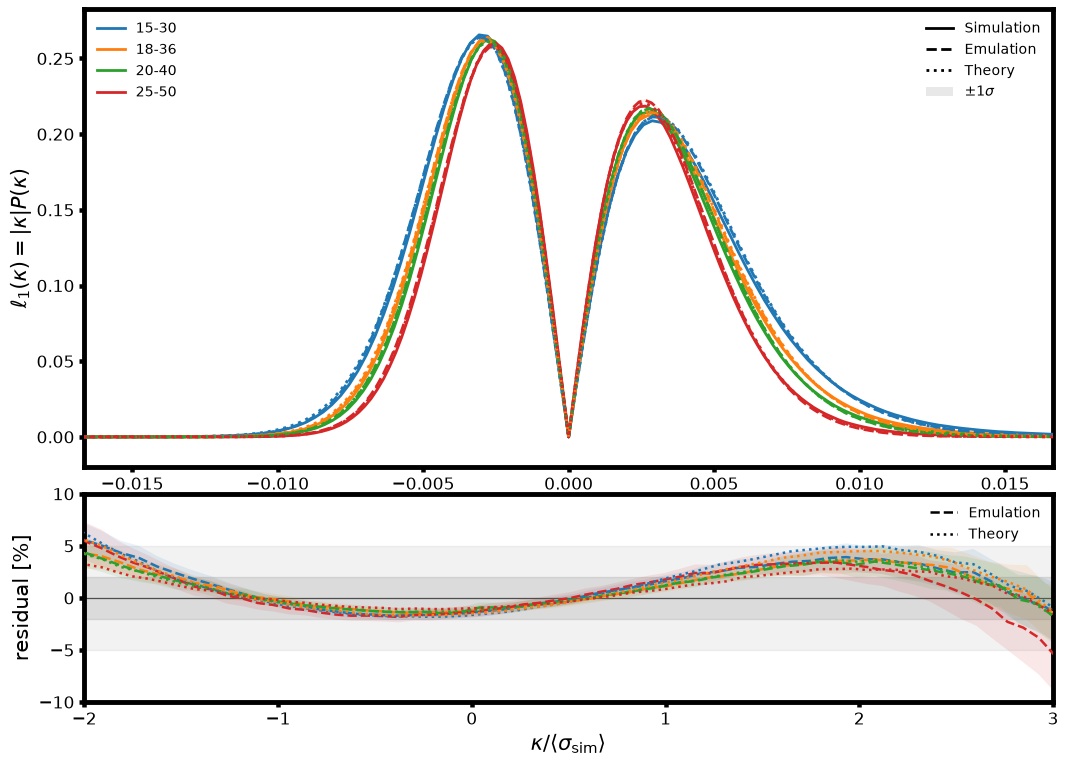


DISPLAYED RESIDUAL SUMMARY

15-30 arcmin
  Emu median |residual|    : 1.6177%
  Emu max    |residual|    : 5.5536%
  Theory median |residual| : 1.7740%
  Theory max    |residual| : 6.2141%

18-36 arcmin
  Emu median |residual|    : 1.3066%
  Emu max    |residual|    : 4.0300%
  Theory median |residual| : 1.6412%
  Theory max    |residual| : 5.0329%

20-40 arcmin
  Emu median |residual|    : 1.3473%
  Emu max    |residual|    : 4.3591%
  Theory median |residual| : 1.3072%
  Theory max    |residual| : 4.2250%

25-50 arcmin
  Emu median |residual|    : 1.6650%
  Emu max    |residual|    : 5.4089%
  Theory median |residual| : 1.0452%
  Theory max    |residual| : 3.2048%


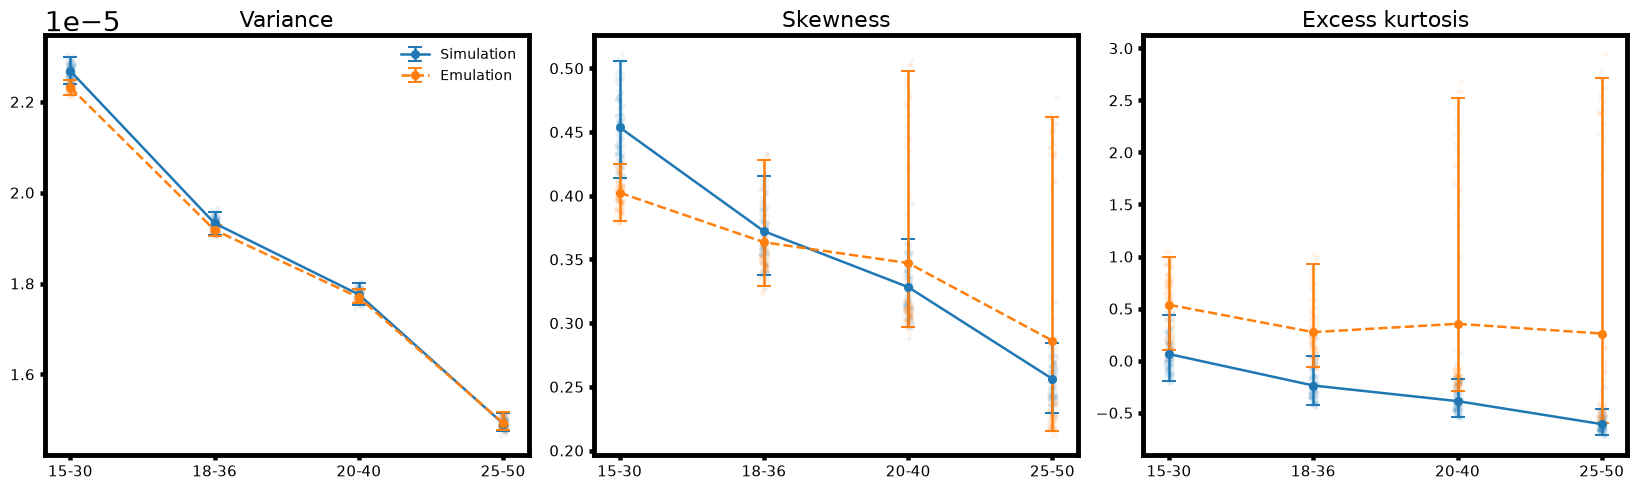


Empirical central 95% intervals (2.5th--97.5th percentile)

Variance
  15-30       Simulation: mean= 2.26794e-05, 95%=[ 2.23902e-05,  2.29765e-05]   Emulation: mean= 2.23173e-05, 95%=[ 2.2153e-05,  2.24872e-05]
  18-36       Simulation: mean= 1.93258e-05, 95%=[ 1.90672e-05,  1.95774e-05]   Emulation: mean= 1.91768e-05, 95%=[ 1.90555e-05,  1.92904e-05]
  20-40       Simulation: mean= 1.77572e-05, 95%=[ 1.75263e-05,  1.80082e-05]   Emulation: mean= 1.76924e-05, 95%=[ 1.7566e-05,  1.78828e-05]
  25-50       Simulation: mean= 1.49136e-05, 95%=[ 1.47425e-05,  1.51387e-05]   Emulation: mean= 1.49279e-05, 95%=[ 1.47645e-05,  1.51619e-05]

Skewness
  15-30       Simulation: mean= 0.453627, 95%=[ 0.413661,  0.505953]   Emulation: mean= 0.402332, 95%=[ 0.379767,  0.424576]
  18-36       Simulation: mean= 0.372112, 95%=[ 0.337549,  0.415246]   Emulation: mean= 0.363471, 95%=[ 0.329109,  0.427643]
  20-40       Simulation: mean= 0.328261, 95%=[ 0.296574,  0.365713]   Emulation: mean= 0.347136, 95

In [18]:
from pathlib import Path
import gc
import time

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ============================================================
# ONE-CELL PIPELINE: CALCULATE/LOAD -> M-CURVE -> MOMENTS
# 100 Simulation (native NSIDE 4096) -> lmax=1535 -> NSIDE 512 fields
# 100 Emulation  (native NSIDE 512)  -> lmax=1535 -> NSIDE 512 fields
# Five wavelets: 10-20, 15-30, 18-36, 20-40, 25-50 arcmin
#
# Simulation/Emulation result files:
#   100sim_wavelet_l1_norm_moments.npz
#   100emu_wavelet_l1_norm_moments.npz
# Theory cache:
#   theory_wavelet_l1_norm_5scales.npz
# Existing compatible files are reused and their expensive calculations are skipped.
# No downgraded maps, ALMs, PNGs, or other persistent caches are saved.
# ============================================================

# ------------------------------------------------------------
# REQUIRED DEFINITIONS FROM EARLIER NOTEBOOK CELLS
# ------------------------------------------------------------
_REQUIRED = [
    "SIMULATION_MAP_DIR",
    "SIMULATION_MAP_PATTERN",
    "EMULATION_OUTPUT_DIR",
    "EMULATION_NSIDE",
    "EMULATION_LMAX",
    "HISTOGRAM_BINS",
    "HARMONIC_ITER",
    "read_native_fullsky_map_binary",
    "top_hat_beam",
    "source_token",
    "ThreeScaleTheoryContext",
    "wavelet_theory_product",
]

_missing = [name for name in _REQUIRED if name not in globals()]
if _missing:
    raise NameError(
        "Run the earlier notebook-definition cells first.\n"
        f"Missing definitions: {_missing}"
    )

# ------------------------------------------------------------
# FIXED SETTINGS FOR THIS ANALYSIS
# ------------------------------------------------------------
N_REALISATIONS = 100
INDICES = np.arange(N_REALISATIONS, dtype=np.int64)

TARGET_NSIDE = 512
TARGET_LMAX = 1535
N_BINS = int(HISTOGRAM_BINS)
ENSEMBLE_DDOF = 1

if int(EMULATION_NSIDE) != TARGET_NSIDE:
    raise ValueError(
        f"This cell expects EMULATION_NSIDE={TARGET_NSIDE}, "
        f"but found {EMULATION_NSIDE}."
    )

if int(EMULATION_LMAX) != TARGET_LMAX:
    raise ValueError(
        f"This cell expects EMULATION_LMAX={TARGET_LMAX}, "
        f"but found {EMULATION_LMAX}."
    )

# Five band-pass wavelets, smaller smoothing minus larger smoothing.
WAVELET_PAIRS = np.asarray(
    [
        [10.0, 20.0],
        [15.0, 30.0],
        [18.0, 36.0],
        [20.0, 40.0],
        [25.0, 50.0],
    ],
    dtype=np.float64,
)

COMPONENT_NAMES = np.asarray(
    ["10-20", "15-30", "18-36", "20-40", "25-50"],
    dtype=str,
)
N_COMPONENTS = len(COMPONENT_NAMES)

OUTPUT_DIR = Path(
    r"E:\data\full_sky_map_results\emulated_map\nside512_lmax1535"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIM_PATH = OUTPUT_DIR / "100sim_wavelet_l1_norm_moments.npz"
EMU_PATH = OUTPUT_DIR / "100emu_wavelet_l1_norm_moments.npz"

# ------------------------------------------------------------
# PATH HELPERS
# ------------------------------------------------------------
def get_simulation_map_path(index):
    return (
        Path(SIMULATION_MAP_DIR)
        / SIMULATION_MAP_PATTERN.format(index=int(index))
    )


def get_emulation_map_path(index):
    return (
        Path(EMULATION_OUTPUT_DIR)
        / (
            f"emu_{source_token()}_"
            f"Nside{int(EMULATION_NSIDE)}_"
            f"lmax{int(EMULATION_LMAX)}_"
            f"{int(index):02d}.npy"
        )
    )


# ------------------------------------------------------------
# INPUT CHECK
# Only done for the side(s) that actually need calculation.
# ------------------------------------------------------------
def check_source_files(source_kind):
    missing = []

    for idx in INDICES:
        if source_kind == "simulation":
            path = get_simulation_map_path(idx)
        elif source_kind == "emulation":
            path = get_emulation_map_path(idx)
        else:
            raise ValueError(f"Unknown source_kind: {source_kind}")

        if not path.is_file():
            missing.append((int(idx), path))

    if missing:
        print(f"\nMissing {source_kind} indices:", [i for i, _ in missing])
        for i, p in missing:
            print(f"  [{i:02d}] {p}")
        raise FileNotFoundError(
            f"{len(missing)} required {source_kind} map(s) are missing."
        )


# ------------------------------------------------------------
# WAVELET FILTERS
# ------------------------------------------------------------
# Build each unique top-hat beam only once.
_unique_scales = sorted(set(WAVELET_PAIRS.ravel().tolist()))
_top_hats = {
    scale: np.asarray(top_hat_beam(scale, TARGET_LMAX), dtype=np.float64)
    for scale in _unique_scales
}

WAVELET_FILTERS = np.asarray(
    [
        _top_hats[float(small)] - _top_hats[float(large)]
        for small, large in WAVELET_PAIRS
    ],
    dtype=np.float64,
)

del _top_hats, _unique_scales


# ------------------------------------------------------------
# LOAD ONE SOURCE MAP
# ------------------------------------------------------------
def load_one_map(source_kind, index):
    index = int(index)

    if source_kind == "simulation":
        path = get_simulation_map_path(index)
        field, native_nside = read_native_fullsky_map_binary(
            path,
            return_nside=True,
        )
        field = np.asarray(field, dtype=np.float32)

        # This analysis is specifically the native 4096 Simulation ensemble.
        if int(native_nside) != 4096:
            raise ValueError(
                f"Unexpected Simulation NSIDE for index {index}: "
                f"expected 4096, found {native_nside}.\n{path}"
            )

        return field, int(native_nside), path

    if source_kind == "emulation":
        path = get_emulation_map_path(index)
        field = np.load(path, mmap_mode="r", allow_pickle=False)
        native_nside = hp.npix2nside(field.size)

        if int(native_nside) != TARGET_NSIDE:
            raise ValueError(
                f"Unexpected Emulation NSIDE for index {index}: "
                f"expected {TARGET_NSIDE}, found {native_nside}.\n{path}"
            )

        return field, int(native_nside), path

    raise ValueError(f"Unknown source_kind: {source_kind}")


# ------------------------------------------------------------
# MAP -> BAND-LIMITED ALM
# ------------------------------------------------------------
def map_to_limited_alm(map_data):
    # Do not make an explicit float64 copy of the enormous NSIDE=4096 map.
    # healpy handles the input conversion internally if needed.
    return hp.map2alm(
        map_data,
        lmax=TARGET_LMAX,
        iter=int(HARMONIC_ITER),
        pol=False,
    )


# ------------------------------------------------------------
# ALM -> ONE NSIDE-512 WAVELET FIELD
# ------------------------------------------------------------
def alm_to_wavelet_field(alm, component_index):
    filtered_alm = hp.almxfl(
        alm,
        WAVELET_FILTERS[component_index],
        inplace=False,
    )

    try:
        field = hp.alm2map(
            filtered_alm,
            nside=TARGET_NSIDE,
            lmax=TARGET_LMAX,
            pol=False,
            verbose=False,
        )
    except TypeError:
        # Compatibility with healpy versions where verbose is unavailable.
        field = hp.alm2map(
            filtered_alm,
            nside=TARGET_NSIDE,
            lmax=TARGET_LMAX,
            pol=False,
        )

    del filtered_alm
    return np.asarray(field, dtype=np.float64)


# ------------------------------------------------------------
# PASS 1: MEASURE KAPPA RANGES
# No maps/ALMs/fields are retained after each realisation.
# ------------------------------------------------------------
def measure_kappa_ranges(source_kind):
    minima = np.full(N_COMPONENTS, np.inf, dtype=np.float64)
    maxima = np.full(N_COMPONENTS, -np.inf, dtype=np.float64)

    print("\n" + "=" * 100)
    print(f"PASS 1: {source_kind.upper()} KAPPA RANGE")
    print("=" * 100)

    for counter, idx in enumerate(INDICES, start=1):
        t0 = time.perf_counter()
        map_data = None
        alm = None

        try:
            map_data, native_nside, path = load_one_map(source_kind, idx)
            print(
                f"[{source_kind.upper()} {counter:03d}/{N_REALISATIONS}] "
                f"r{int(idx):03d}  native NSIDE={native_nside}",
                flush=True,
            )

            alm = map_to_limited_alm(map_data)

            # Release the source map immediately after map2alm.
            del map_data
            map_data = None
            gc.collect()

            for s in range(N_COMPONENTS):
                field = alm_to_wavelet_field(alm, s)
                finite = np.isfinite(field)

                if not np.any(finite):
                    raise ValueError(
                        f"No finite wavelet values for {source_kind}, "
                        f"r{int(idx):03d}, {COMPONENT_NAMES[s]}."
                    )

                values = field[finite]
                minima[s] = min(minima[s], float(np.min(values)))
                maxima[s] = max(maxima[s], float(np.max(values)))

                del values, finite, field
                gc.collect()

            del alm
            alm = None
            gc.collect()

            print(
                f"    elapsed {time.perf_counter() - t0:.1f} s",
                flush=True,
            )

        finally:
            if map_data is not None:
                del map_data
            if alm is not None:
                del alm
            gc.collect()

    return minima, maxima


# ------------------------------------------------------------
# COMMON HISTOGRAM GRID
# ------------------------------------------------------------
def make_common_edges(global_min, global_max):
    edges = np.empty(
        (N_COMPONENTS, N_BINS + 1),
        dtype=np.float64,
    )

    for s in range(N_COMPONENTS):
        lower = float(global_min[s])
        upper = float(global_max[s])

        if not np.isfinite(lower) or not np.isfinite(upper) or upper <= lower:
            raise ValueError(
                f"Invalid kappa range for {COMPONENT_NAMES[s]}: "
                f"{lower}, {upper}"
            )

        # Tiny padding avoids round-off putting a later value microscopically
        # outside an edge measured in PASS 1.
        span = upper - lower
        pad = max(span * 1.0e-10, np.finfo(np.float64).eps)
        edges[s] = np.linspace(
            lower - pad,
            upper + pad,
            N_BINS + 1,
            dtype=np.float64,
        )

    return edges


# ------------------------------------------------------------
# PDF NORMALISATION
# ------------------------------------------------------------
def normalize_pdf_on_grid(kappa, pdf):
    kappa = np.asarray(kappa, dtype=np.float64)
    pdf = np.asarray(pdf, dtype=np.float64)

    pdf = np.nan_to_num(pdf, nan=0.0, posinf=0.0, neginf=0.0)
    pdf = np.clip(pdf, 0.0, None)

    area = np.trapezoid(pdf, kappa)
    if not np.isfinite(area) or area <= 0.0:
        raise ValueError("Invalid PDF area.")

    return pdf / area


# ------------------------------------------------------------
# PASS 2: MAP -> ALM -> FIVE WAVELET FIELDS -> PDF -> L1
# Only all_l1 is retained. No map or field is stored.
# ------------------------------------------------------------
def calculate_all_l1(source_kind, common_edges):
    all_l1 = np.empty(
        (N_REALISATIONS, N_COMPONENTS, N_BINS),
        dtype=np.float64,
    )

    kappa = 0.5 * (common_edges[:, :-1] + common_edges[:, 1:])

    print("\n" + "=" * 100)
    print(f"PASS 2: {source_kind.upper()} PDF -> L1")
    print("=" * 100)

    for counter, idx in enumerate(INDICES, start=1):
        t0 = time.perf_counter()
        map_data = None
        alm = None

        try:
            map_data, native_nside, path = load_one_map(source_kind, idx)
            print(
                f"[{source_kind.upper()} {counter:03d}/{N_REALISATIONS}] "
                f"r{int(idx):03d}  native NSIDE={native_nside}",
                flush=True,
            )

            alm = map_to_limited_alm(map_data)

            del map_data
            map_data = None
            gc.collect()

            for s in range(N_COMPONENTS):
                field = alm_to_wavelet_field(alm, s)
                finite = np.isfinite(field)
                values = field[finite]

                if values.size == 0:
                    raise ValueError(
                        f"No finite wavelet values for {source_kind}, "
                        f"r{int(idx):03d}, {COMPONENT_NAMES[s]}."
                    )

                edges = common_edges[s]
                vmin = float(np.min(values))
                vmax = float(np.max(values))

                if vmin < edges[0] or vmax > edges[-1]:
                    raise ValueError(
                        "Wavelet values lie outside the established common "
                        "histogram range.\n"
                        f"source={source_kind}, index={int(idx)}, "
                        f"scale={COMPONENT_NAMES[s]}\n"
                        f"field=[{vmin:+.8e}, {vmax:+.8e}]\n"
                        f"edges=[{edges[0]:+.8e}, {edges[-1]:+.8e}]"
                    )

                counts, _ = np.histogram(values, bins=edges, density=False)
                widths = np.diff(edges)
                total = float(np.sum(counts))

                if total <= 0.0:
                    raise ValueError(
                        f"Empty histogram for {source_kind}, "
                        f"r{int(idx):03d}, {COMPONENT_NAMES[s]}."
                    )

                raw_pdf = counts.astype(np.float64) / (total * widths)
                pdf = normalize_pdf_on_grid(kappa[s], raw_pdf)
                l1 = np.abs(kappa[s]) * pdf

                all_l1[counter - 1, s, :] = l1

                del l1, pdf, raw_pdf, widths, counts
                del values, finite, field
                gc.collect()

            del alm
            alm = None
            gc.collect()

            print(
                f"    elapsed {time.perf_counter() - t0:.1f} s",
                flush=True,
            )

        finally:
            if map_data is not None:
                del map_data
            if alm is not None:
                del alm
            gc.collect()

    return all_l1, kappa


# ------------------------------------------------------------
# SAVE EXACTLY ONE RESULT FILE FOR A SOURCE
# ------------------------------------------------------------
def save_result(path, source_kind, common_edges, all_l1, kappa):
    np.savez_compressed(
        path,
        all_l1=np.asarray(all_l1, dtype=np.float64),
        kappa=np.asarray(kappa, dtype=np.float64),
        bin_edges=np.asarray(common_edges, dtype=np.float64),
        component_names=COMPONENT_NAMES,
        wavelet_pairs_arcmin=WAVELET_PAIRS,
        realisation_indices=INDICES,
        source_kind=np.asarray(source_kind),
        source_tag=np.asarray(source_token()),
        n_maps=np.int64(N_REALISATIONS),
        nside=np.int64(TARGET_NSIDE),
        lmax=np.int64(TARGET_LMAX),
        harmonic_iter=np.int64(HARMONIC_ITER),
        histogram_bins=np.int64(N_BINS),
        wavelet_sign_convention=np.asarray("smaller_minus_larger"),
        pdf_normalisation=np.asarray("trapezoid(P,kappa)=1"),
        l1_definition=np.asarray("abs(kappa)*P(kappa)"),
        simulation_harmonic_downgrade=np.asarray(
            "native_map -> map2alm(lmax=1535) -> filtered alm2map(nside=512)"
        ),
    )

    print(f"\n[SAVED] {path}", flush=True)


# ------------------------------------------------------------
# LOAD + VALIDATE EXISTING RESULT
# Existing file => expensive source-map calculation is skipped.
# Incompatible existing file is does not silently overwritten.
# ------------------------------------------------------------
def load_result(path, expected_source_kind):
    with np.load(path, allow_pickle=False) as f:
        result = {key: np.asarray(f[key]) for key in f.files}

    required = [
        "all_l1",
        "kappa",
        "bin_edges",
        "component_names",
        "wavelet_pairs_arcmin",
        "realisation_indices",
        "source_kind",
        "n_maps",
        "nside",
        "lmax",
        "harmonic_iter",
        "histogram_bins",
    ]

    missing = [key for key in required if key not in result]
    if missing:
        raise ValueError(
            f"Existing cache is incomplete: {path}\nMissing keys: {missing}"
        )

    expected_shape = (N_REALISATIONS, N_COMPONENTS, N_BINS)

    checks = [
        (result["all_l1"].shape == expected_shape,
         f"all_l1 shape {result['all_l1'].shape} != {expected_shape}"),
        (result["kappa"].shape == (N_COMPONENTS, N_BINS),
         f"kappa shape {result['kappa'].shape} is wrong"),
        (result["bin_edges"].shape == (N_COMPONENTS, N_BINS + 1),
         f"bin_edges shape {result['bin_edges'].shape} is wrong"),
        (np.array_equal(result["component_names"].astype(str), COMPONENT_NAMES),
         "component_names mismatch"),
        (np.allclose(result["wavelet_pairs_arcmin"], WAVELET_PAIRS, rtol=0, atol=0),
         "wavelet_pairs_arcmin mismatch"),
        (np.array_equal(result["realisation_indices"], INDICES),
         "realisation_indices mismatch"),
        (str(result["source_kind"].item()) == expected_source_kind,
         "source_kind mismatch"),
        (int(result["n_maps"].item()) == N_REALISATIONS,
         "n_maps mismatch"),
        (int(result["nside"].item()) == TARGET_NSIDE,
         "nside mismatch"),
        (int(result["lmax"].item()) == TARGET_LMAX,
         "lmax mismatch"),
        (int(result["harmonic_iter"].item()) == int(HARMONIC_ITER),
         "harmonic_iter mismatch"),
        (int(result["histogram_bins"].item()) == N_BINS,
         "histogram_bins mismatch"),
    ]

    failed = [message for ok, message in checks if not ok]
    if failed:
        raise ValueError(
            f"Existing file is incompatible and will not be overwritten:\n{path}\n"
            + "\n".join(f"  - {msg}" for msg in failed)
        )

    return result


# ============================================================
# CACHE / CALCULATION CONTROL
# ============================================================
print("\n" + "=" * 100)
print("FIVE-SCALE WAVELET L1 MOMENT PIPELINE")
print("=" * 100)
print("Simulation source     :", SIMULATION_MAP_DIR)
print("Emulation source      :", EMULATION_OUTPUT_DIR)
print("Target NSIDE          :", TARGET_NSIDE)
print("Target lmax           :", TARGET_LMAX)
print("Wavelets              :", COMPONENT_NAMES.tolist())
print("Histogram bins        :", N_BINS)
print("Simulation output     :", SIM_PATH)
print("Emulation output      :", EMU_PATH)
print("No hp.ud_grade        : True")
print("Existing compatible Simulation/Emulation NPZ files are reused.")
print("=" * 100)

sim_result = None
emu_result = None

if SIM_PATH.exists():
    print("\n[FOUND] Simulation result -> validating and skipping map calculation")
    sim_result = load_result(SIM_PATH, "simulation")
    print("[OK] Simulation result is compatible.")

if EMU_PATH.exists():
    print("\n[FOUND] Emulation result -> validating and skipping map calculation")
    emu_result = load_result(EMU_PATH, "emulation")
    print("[OK] Emulation result is compatible.")

# Only check raw source files if that source actually needs calculation.
if sim_result is None:
    check_source_files("simulation")
if emu_result is None:
    check_source_files("emulation")

# ------------------------------------------------------------
# BOTH MISSING
# Need one common histogram grid measured from both ensembles.
# ------------------------------------------------------------
if sim_result is None and emu_result is None:
    sim_min, sim_max = measure_kappa_ranges("simulation")
    emu_min, emu_max = measure_kappa_ranges("emulation")

    global_min = np.minimum(sim_min, emu_min)
    global_max = np.maximum(sim_max, emu_max)
    common_edges = make_common_edges(global_min, global_max)

    del sim_min, sim_max, emu_min, emu_max, global_min, global_max
    gc.collect()

    # Simulation is completed and saved first. If a later Emulation calculation
    # is interrupted, the expensive Simulation result remains available next run.
    sim_all_l1, sim_kappa = calculate_all_l1("simulation", common_edges)
    save_result(
        SIM_PATH,
        "simulation",
        common_edges,
        sim_all_l1,
        sim_kappa,
    )
    del sim_all_l1, sim_kappa
    gc.collect()
    sim_result = load_result(SIM_PATH, "simulation")

    emu_all_l1, emu_kappa = calculate_all_l1("emulation", common_edges)
    save_result(
        EMU_PATH,
        "emulation",
        common_edges,
        emu_all_l1,
        emu_kappa,
    )
    del emu_all_l1, emu_kappa
    gc.collect()
    emu_result = load_result(EMU_PATH, "emulation")

# ------------------------------------------------------------
# SIMULATION MISSING ONLY
# Reuse Emulation histogram edges so only Simulation is computed.
# ------------------------------------------------------------
elif sim_result is None and emu_result is not None:
    common_edges = np.asarray(emu_result["bin_edges"], dtype=np.float64)
    sim_all_l1, sim_kappa = calculate_all_l1("simulation", common_edges)
    save_result(
        SIM_PATH,
        "simulation",
        common_edges,
        sim_all_l1,
        sim_kappa,
    )
    del sim_all_l1, sim_kappa
    gc.collect()
    sim_result = load_result(SIM_PATH, "simulation")

# ------------------------------------------------------------
# EMULATION MISSING ONLY
# Reuse Simulation histogram edges so only Emulation is computed.
# ------------------------------------------------------------
elif sim_result is not None and emu_result is None:
    common_edges = np.asarray(sim_result["bin_edges"], dtype=np.float64)
    emu_all_l1, emu_kappa = calculate_all_l1("emulation", common_edges)
    save_result(
        EMU_PATH,
        "emulation",
        common_edges,
        emu_all_l1,
        emu_kappa,
    )
    del emu_all_l1, emu_kappa
    gc.collect()
    emu_result = load_result(EMU_PATH, "emulation")

else:
    print("\nBoth compatible result files already exist.")
    print("All expensive map / harmonic / wavelet calculations were skipped.")

# Final common-grid check.
if not np.array_equal(sim_result["bin_edges"], emu_result["bin_edges"]):
    raise ValueError(
        "Simulation and Emulation saved histogram grids differ. "
        "The two existing files were not produced as one compatible pair."
    )

if not np.array_equal(sim_result["kappa"], emu_result["kappa"]):
    raise ValueError(
        "Simulation and Emulation saved kappa grids differ."
    )

# ============================================================
# M-CURVE SETTINGS / HELPERS
# Calculation and storage still use all five scales.
# Both figures intentionally DISPLAY only:
#   15-30, 18-36, 20-40, 25-50 arcmin
# ============================================================

THEORY_PATH = OUTPUT_DIR / "theory_wavelet_l1_norm_5scales.npz"

THEORY_PREFIXES = [
    "wavelet_10_20",
    "wavelet_15_30",
    "wavelet_18_36",
    "wavelet_20_40",
    "wavelet_25_50",
]

# 10-20 remains in every saved cache but is omitted from both figures.
PLOT_INDICES = np.arange(1, N_COMPONENTS, dtype=np.int64)

FIGSIZE = (12.5, 9.0)
HEIGHT_RATIOS = (2.2, 1.0)
HSPACE = 0.08

TOP_LINEWIDTH = 2.0
RESIDUAL_LINEWIDTH = 1.8
SIM_SHADE_ALPHA = 0.15
EMU_SHADE_ALPHA = 0.08

LABEL_SIZE = 15
TICK_SIZE = 12
LEGEND_SIZE = 10

BOTTOM_YLIM = (-10.0, +10.0)
RESIDUAL_MIN_PEAK_FRACTION = 0.01


def normalize_pdf_sorted_for_mcurve(kappa, pdf):
    """Finite-mask, sort, clip, and trapezoid-normalise a PDF."""
    kappa = np.asarray(kappa, dtype=np.float64)
    pdf = np.asarray(pdf, dtype=np.float64)

    good = np.isfinite(kappa) & np.isfinite(pdf)
    kappa = kappa[good]
    pdf = pdf[good]

    order = np.argsort(kappa)
    kappa = kappa[order]
    pdf = np.clip(pdf[order], 0.0, None)

    area = np.trapezoid(pdf, kappa)
    if not np.isfinite(area) or area <= 0.0:
        raise ValueError("Invalid PDF area.")

    return kappa, pdf / area


def add_exact_zero_to_curve(kappa, y, zero_value=0.0):
    kappa = np.asarray(kappa, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    if np.any(kappa == 0.0):
        return kappa, y

    x_new = np.concatenate([kappa, [0.0]])
    y_new = np.concatenate([y, [zero_value]])
    order = np.argsort(x_new)
    return x_new[order], y_new[order]


def add_exact_zero_to_band(kappa, lower, upper):
    kappa = np.asarray(kappa, dtype=np.float64)
    lower = np.asarray(lower, dtype=np.float64)
    upper = np.asarray(upper, dtype=np.float64)

    if np.any(kappa == 0.0):
        return kappa, lower, upper

    x_new = np.concatenate([kappa, [0.0]])
    lo_new = np.concatenate([lower, [0.0]])
    hi_new = np.concatenate([upper, [0.0]])
    order = np.argsort(x_new)
    return x_new[order], lo_new[order], hi_new[order]


# ============================================================
# FIRST FIGURE: M-SHAPED L1 CURVES + RESIDUALS
# ============================================================

sim_all_l1 = np.asarray(sim_result["all_l1"], dtype=np.float64)
emu_all_l1 = np.asarray(emu_result["all_l1"], dtype=np.float64)
common_kappa_grid = np.asarray(sim_result["kappa"], dtype=np.float64)

sim_mean_l1 = np.nanmean(sim_all_l1, axis=0)
emu_mean_l1 = np.nanmean(emu_all_l1, axis=0)

sim_std_l1 = np.nanstd(sim_all_l1, axis=0, ddof=ENSEMBLE_DDOF)
emu_std_l1 = np.nanstd(emu_all_l1, axis=0, ddof=ENSEMBLE_DDOF)

print("[LOADED]", SIM_PATH)
print("[LOADED]", EMU_PATH)


# ============================================================
# RECOVER <sigma_sim> FROM SAVED L1 CURVES
# L1(kappa) = |kappa| P(kappa)
# ============================================================

sim_map_sigma = np.full(
    (sim_all_l1.shape[0], N_COMPONENTS),
    np.nan,
    dtype=np.float64,
)

for r in range(sim_all_l1.shape[0]):
    for s in range(N_COMPONENTS):
        kappa = common_kappa_grid[s]
        l1 = sim_all_l1[r, s]

        finite = np.isfinite(kappa) & np.isfinite(l1)
        x = kappa[finite]
        y = l1[finite]

        pdf = np.zeros_like(y)
        nonzero = np.abs(x) > 0.0
        pdf[nonzero] = y[nonzero] / np.abs(x[nonzero])

        x_pdf, pdf = normalize_pdf_sorted_for_mcurve(x, pdf)

        mean_kappa = np.trapezoid(x_pdf * pdf, x_pdf)
        variance = np.trapezoid(
            (x_pdf - mean_kappa) ** 2 * pdf,
            x_pdf,
        )

        if np.isfinite(variance) and variance >= 0.0:
            sim_map_sigma[r, s] = np.sqrt(variance)

mean_sim_sigma = np.nanmean(sim_map_sigma, axis=0)

if np.any(~np.isfinite(mean_sim_sigma)) or np.any(mean_sim_sigma <= 0.0):
    raise ValueError("Failed to recover valid <sigma_sim> values.")

print("\n<sigma_sim> recovered from saved Simulation L1 curves:")
for name, value in zip(COMPONENT_NAMES, mean_sim_sigma):
    print(f"  {name:7s}: {value:.8e}")


# ============================================================
# THEORY CACHE
# ============================================================

def build_theory_cache():
    print("\n" + "=" * 90)
    print("THEORY CACHE NOT FOUND -> CALCULATING FIVE SCALES")
    print("=" * 90)

    ctx = ThreeScaleTheoryContext.build()

    save_dict = {
        "component_names": COMPONENT_NAMES,
        "wavelet_pairs_arcmin": WAVELET_PAIRS,
        "nside": np.int64(512),
        "lmax": np.int64(1535),
        "source_tag": np.asarray(source_token()),
        "l1_definition": np.asarray("abs(kappa)*P(kappa)"),
    }

    try:
        for i, ((small, large), prefix) in enumerate(
            zip(WAVELET_PAIRS, THEORY_PREFIXES),
            start=1,
        ):
            print(
                f"[THEORY {i}/{N_COMPONENTS}] "
                f"{small:g}-{large:g} arcmin",
                flush=True,
            )

            product = wavelet_theory_product(
                ctx,
                float(small),
                float(large),
                prefix,
            )

            for key in ("kappa", "pdf", "l1"):
                if key not in product:
                    raise KeyError(
                        f"Theory product {prefix} has no '{key}' key."
                    )

                save_dict[f"{prefix}_{key}"] = np.asarray(
                    product[key],
                    dtype=np.float64,
                )

            del product
            gc.collect()

        np.savez_compressed(THEORY_PATH, **save_dict)
        print("[SAVED THEORY]", THEORY_PATH)

    finally:
        del ctx
        gc.collect()


def load_theory_cache():
    theory_existed = THEORY_PATH.is_file()

    if not theory_existed:
        build_theory_cache()

    with np.load(THEORY_PATH, allow_pickle=False) as f:
        data = {key: np.asarray(f[key]) for key in f.files}

    required_meta = [
        "component_names",
        "wavelet_pairs_arcmin",
        "nside",
        "lmax",
    ]

    missing_meta = [key for key in required_meta if key not in data]
    if missing_meta:
        raise ValueError(
            f"Incompatible theory cache:\n{THEORY_PATH}\n"
            f"Missing metadata: {missing_meta}"
        )

    if not np.array_equal(data["component_names"].astype(str), COMPONENT_NAMES):
        raise ValueError(
            "Theory cache component_names mismatch.\n"
            "Delete the theory cache and rerun."
        )

    if not np.allclose(
        data["wavelet_pairs_arcmin"],
        WAVELET_PAIRS,
        rtol=0.0,
        atol=0.0,
    ):
        raise ValueError(
            "Theory cache wavelet_pairs_arcmin mismatch.\n"
            "Delete the theory cache and rerun."
        )

    if int(data["nside"].item()) != 512:
        raise ValueError("Theory cache NSIDE mismatch.")
    if int(data["lmax"].item()) != 1535:
        raise ValueError("Theory cache lmax mismatch.")

    for prefix in THEORY_PREFIXES:
        for suffix in ("kappa", "pdf", "l1"):
            key = f"{prefix}_{suffix}"
            if key not in data:
                raise ValueError(
                    f"Incompatible theory cache: missing {key}\n"
                    f"{THEORY_PATH}"
                )

    if theory_existed:
        print("\n[FOUND + VALID] Theory cache -> theory calculation skipped.")
        print("               ", THEORY_PATH)

    return data


theory_data = load_theory_cache()


# ============================================================
# INTERPOLATE THEORY PDF ONTO THE SAVED COMMON KAPPA GRID
# ============================================================

theory_on_common = []

for s, prefix in enumerate(THEORY_PREFIXES):
    theory_kappa_native = np.asarray(
        theory_data[f"{prefix}_kappa"],
        dtype=np.float64,
    )
    theory_pdf_native = np.asarray(
        theory_data[f"{prefix}_pdf"],
        dtype=np.float64,
    )

    finite = (
        np.isfinite(theory_kappa_native)
        & np.isfinite(theory_pdf_native)
    )

    x = theory_kappa_native[finite]
    p = theory_pdf_native[finite]

    order = np.argsort(x)
    x = x[order]
    p = p[order]

    x, unique_idx = np.unique(x, return_index=True)
    p = p[unique_idx]
    x, p = normalize_pdf_sorted_for_mcurve(x, p)

    interpolator = PchipInterpolator(
        x,
        p,
        extrapolate=False,
    )

    common_kappa = common_kappa_grid[s]
    p_common = np.asarray(interpolator(common_kappa), dtype=np.float64)

    valid = np.isfinite(p_common)
    p_common[valid] = np.clip(p_common[valid], 0.0, None)

    l1_common = np.full_like(common_kappa, np.nan)
    l1_common[valid] = np.abs(common_kappa[valid]) * p_common[valid]

    theory_on_common.append(
        {
            "kappa": common_kappa,
            "pdf": p_common,
            "l1": l1_common,
            "valid": valid,
        }
    )


# ============================================================
# TOP-PANEL X RANGE
#
# Use the COMMON physical kappa support shared by
# Simulation + Emulation + Theory across the four displayed scales,
# then make that common interval symmetric around zero.
#
# 10-20 is omitted from this range determination as well as the plot.
# ============================================================

common_min = -np.inf
common_max = +np.inf

for s in PLOT_INDICES:
    kappa = np.asarray(common_kappa_grid[s], dtype=np.float64)
    theory_l1 = np.asarray(theory_on_common[s]["l1"], dtype=np.float64)

    valid = (
        np.isfinite(kappa)
        & np.isfinite(sim_mean_l1[s])
        & np.isfinite(emu_mean_l1[s])
        & np.isfinite(theory_l1)
    )

    if not np.any(valid):
        raise ValueError(
            f"No common Simulation/Emulation/Theory support for "
            f"{COMPONENT_NAMES[s]}."
        )

    local_min = float(np.min(kappa[valid]))
    local_max = float(np.max(kappa[valid]))

    common_min = max(common_min, local_min)
    common_max = min(common_max, local_max)

if not (
    np.isfinite(common_min)
    and np.isfinite(common_max)
    and common_max > common_min
):
    raise ValueError(
        "No common physical-kappa interval across displayed scales."
    )

symmetric_limit = min(abs(common_min), abs(common_max))

if not np.isfinite(symmetric_limit) or symmetric_limit <= 0.0:
    raise ValueError(
        "Could not construct symmetric common kappa range."
    )

TOP_XLIM = (-symmetric_limit, +symmetric_limit)

print("\nCommon physical kappa range (10-20 omitted):")
print(f"  intersection : {common_min:+.8e} -> {common_max:+.8e}")
print(f"  symmetric    : {TOP_XLIM[0]:+.8e} -> {TOP_XLIM[1]:+.8e}")


# ============================================================
# RESIDUAL DATA
# x = kappa / <sigma_sim>
# residual = 100 * (comparison / Simulation - 1)
# ============================================================

residual_data = []

for s in range(N_COMPONENTS):
    kappa = common_kappa_grid[s]
    sim_mean = sim_mean_l1[s]
    sim_std = sim_std_l1[s]
    emu_mean = emu_mean_l1[s]
    emu_std = emu_std_l1[s]
    theory_l1 = theory_on_common[s]["l1"]

    sigma_scale = float(mean_sim_sigma[s])
    residual_x = kappa / sigma_scale

    amplitude_floor = RESIDUAL_MIN_PEAK_FRACTION * np.nanmax(sim_mean)

    valid_emu = (
        np.isfinite(residual_x)
        & np.isfinite(sim_mean)
        & np.isfinite(emu_mean)
        & (sim_mean > amplitude_floor)
    )

    emu_residual = np.full_like(sim_mean, np.nan)
    emu_residual[valid_emu] = (
        100.0
        * (
            emu_mean[valid_emu] / sim_mean[valid_emu]
            - 1.0
        )
    )

    emu_residual_sigma = np.full_like(sim_mean, np.nan)
    emu_residual_sigma[valid_emu] = (
        100.0
        * np.sqrt(
            (emu_std[valid_emu] / sim_mean[valid_emu]) ** 2
            + (
                emu_mean[valid_emu]
                * sim_std[valid_emu]
                / sim_mean[valid_emu] ** 2
            ) ** 2
        )
    )

    valid_theory = (
        np.isfinite(residual_x)
        & np.isfinite(sim_mean)
        & np.isfinite(theory_l1)
        & (sim_mean > amplitude_floor)
    )

    theory_residual = np.full_like(sim_mean, np.nan)
    theory_residual[valid_theory] = (
        100.0
        * (
            theory_l1[valid_theory] / sim_mean[valid_theory]
            - 1.0
        )
    )

    residual_data.append(
        {
            "x": residual_x,
            "emu": emu_residual,
            "emu_sigma": emu_residual_sigma,
            "theory": theory_residual,
            "valid_emu": valid_emu,
            "valid_theory": valid_theory,
        }
    )


# ============================================================
# BOTTOM-PANEL X RANGE
# Fixed by request.
# ============================================================

BOTTOM_XLIM = (-2.0, +3.0)

print("Residual x range:")
print(f"  {BOTTOM_XLIM[0]:+.1f} -> {BOTTOM_XLIM[1]:+.1f}")


# ============================================================
# PLOT
# ============================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=FIGSIZE,
    gridspec_kw={
        "height_ratios": HEIGHT_RATIOS,
        "hspace": HSPACE,
    },
)

PLOT_COLORS = {
    s: f"C{i}"
    for i, s in enumerate(PLOT_INDICES)
}
scale_handles = []

for s in PLOT_INDICES:
    color = PLOT_COLORS[s]
    kappa = common_kappa_grid[s]

    sim_mean = sim_mean_l1[s]
    sim_std = sim_std_l1[s]
    emu_mean = emu_mean_l1[s]
    emu_std = emu_std_l1[s]
    theory_l1 = theory_on_common[s]["l1"]

    sim_lower = np.maximum(sim_mean - sim_std, 0.0)
    sim_upper = sim_mean + sim_std
    x_band, lo_band, hi_band = add_exact_zero_to_band(
        kappa,
        sim_lower,
        sim_upper,
    )
    ax_top.fill_between(
        x_band,
        lo_band,
        hi_band,
        color=color,
        alpha=SIM_SHADE_ALPHA,
        linewidth=0.0,
        zorder=1,
    )

    emu_lower = np.maximum(emu_mean - emu_std, 0.0)
    emu_upper = emu_mean + emu_std
    x_band, lo_band, hi_band = add_exact_zero_to_band(
        kappa,
        emu_lower,
        emu_upper,
    )
    ax_top.fill_between(
        x_band,
        lo_band,
        hi_band,
        color=color,
        alpha=EMU_SHADE_ALPHA,
        linewidth=0.0,
        zorder=2,
    )

    x_plot, y_plot = add_exact_zero_to_curve(kappa, sim_mean, 0.0)
    ax_top.plot(
        x_plot,
        y_plot,
        color=color,
        linestyle="-",
        linewidth=TOP_LINEWIDTH,
        zorder=5,
    )

    x_plot, y_plot = add_exact_zero_to_curve(kappa, emu_mean, 0.0)
    ax_top.plot(
        x_plot,
        y_plot,
        color=color,
        linestyle="--",
        linewidth=TOP_LINEWIDTH,
        zorder=6,
    )

    valid_theory = np.isfinite(theory_l1)
    x_plot, y_plot = add_exact_zero_to_curve(
        kappa[valid_theory],
        theory_l1[valid_theory],
        0.0,
    )
    ax_top.plot(
        x_plot,
        y_plot,
        color=color,
        linestyle=":",
        linewidth=TOP_LINEWIDTH + 0.15,
        zorder=7,
    )

    scale_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linestyle="-",
            linewidth=TOP_LINEWIDTH,
            label=COMPONENT_NAMES[s],
        )
    )

ax_top.set_xlim(*TOP_XLIM)
ax_top.set_ylabel(
    r"$\ell_1(\kappa)=|\kappa|P(\kappa)$",
    fontsize=LABEL_SIZE,
)
ax_top.set_xlabel(r"$\kappa$", fontsize=LABEL_SIZE)

visible_values = []
for s in PLOT_INDICES:
    kappa = common_kappa_grid[s]
    inside = (
        np.isfinite(kappa)
        & (kappa >= TOP_XLIM[0])
        & (kappa <= TOP_XLIM[1])
    )

    curves = [
        sim_mean_l1[s] + sim_std_l1[s],
        emu_mean_l1[s] + emu_std_l1[s],
        theory_on_common[s]["l1"],
    ]

    for curve in curves:
        valid = inside & np.isfinite(curve)
        if np.any(valid):
            visible_values.append(curve[valid])

if visible_values:
    ymax = float(np.max(np.concatenate(visible_values)))
    ax_top.set_ylim(-0.02, 1.06 * ymax)
else:
    ax_top.set_ylim(bottom=-0.02)

legend_scale = ax_top.legend(
    handles=scale_handles,
    loc="upper left",
    fontsize=LEGEND_SIZE,
    frameon=False,
)

style_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        linewidth=TOP_LINEWIDTH,
        label="Simulation",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=TOP_LINEWIDTH,
        label="Emulation",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=TOP_LINEWIDTH,
        label="Theory",
    ),
    Patch(
        facecolor="gray",
        alpha=0.18,
        edgecolor="none",
        label=r"$\pm1\sigma$",
    ),
]

ax_top.legend(
    handles=style_handles,
    loc="upper right",
    fontsize=LEGEND_SIZE,
    frameon=False,
)
ax_top.add_artist(legend_scale)


# Bottom panel
ax_bottom.axhspan(
    -5.0,
    +5.0,
    color="gray",
    alpha=0.10,
    zorder=0,
)
ax_bottom.axhspan(
    -2.0,
    +2.0,
    color="gray",
    alpha=0.20,
    zorder=0,
)
ax_bottom.axhline(
    0.0,
    color="black",
    linewidth=0.9,
    alpha=0.65,
    zorder=1,
)

for s in PLOT_INDICES:
    color = PLOT_COLORS[s]
    item = residual_data[s]
    # Do not pre-crop the residual arrays to [-2, +3].
    # Plot the full valid residual curves and let the axes clip them
    # exactly at x=-2 and x=+3. This makes BOTH sides terminate
    # against the plot frame in the same way.
    valid_emu = item["valid_emu"]

    ax_bottom.fill_between(
        item["x"][valid_emu],
        item["emu"][valid_emu] - item["emu_sigma"][valid_emu],
        item["emu"][valid_emu] + item["emu_sigma"][valid_emu],
        color=color,
        alpha=0.10,
        linewidth=0.0,
        zorder=1,
        clip_on=True,
    )

    ax_bottom.plot(
        item["x"][valid_emu],
        item["emu"][valid_emu],
        color=color,
        linestyle="--",
        linewidth=RESIDUAL_LINEWIDTH,
        zorder=4,
        clip_on=True,
    )

    valid_theory = item["valid_theory"]

    ax_bottom.plot(
        item["x"][valid_theory],
        item["theory"][valid_theory],
        color=color,
        linestyle=":",
        linewidth=RESIDUAL_LINEWIDTH,
        zorder=5,
        clip_on=True,
    )

ax_bottom.set_xlim(*BOTTOM_XLIM)
ax_bottom.set_ylim(*BOTTOM_YLIM)
ax_bottom.set_xlabel(
    r"$\kappa/\langle\sigma_{\rm sim}\rangle$",
    fontsize=LABEL_SIZE,
)
ax_bottom.set_ylabel("residual [%]", fontsize=LABEL_SIZE)

bottom_style_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=RESIDUAL_LINEWIDTH,
        label="Emulation",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle=":",
        linewidth=RESIDUAL_LINEWIDTH,
        label="Theory",
    ),
]

ax_bottom.legend(
    handles=bottom_style_handles,
    loc="upper right",
    fontsize=LEGEND_SIZE,
    frameon=False,
)

for ax in (ax_top, ax_bottom):
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

plt.show()


# ============================================================
# SHORT NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("DISPLAYED RESIDUAL SUMMARY")
print("=" * 90)

for s in PLOT_INDICES:
    item = residual_data[s]

    ve = (
        item["valid_emu"]
        & (item["x"] >= BOTTOM_XLIM[0])
        & (item["x"] <= BOTTOM_XLIM[1])
    )

    vt = (
        item["valid_theory"]
        & (item["x"] >= BOTTOM_XLIM[0])
        & (item["x"] <= BOTTOM_XLIM[1])
    )

    print(f"\n{COMPONENT_NAMES[s]} arcmin")

    if np.any(ve):
        a = np.abs(item["emu"][ve])
        print(f"  Emu median |residual|    : {np.nanmedian(a):.4f}%")
        print(f"  Emu max    |residual|    : {np.nanmax(a):.4f}%")

    if np.any(vt):
        a = np.abs(item["theory"][vt])
        print(f"  Theory median |residual| : {np.nanmedian(a):.4f}%")
        print(f"  Theory max    |residual| : {np.nanmax(a):.4f}%")

# ============================================================
# L1-WEIGHTED MOMENTS
# q(kappa) proportional to L1(kappa)
# ============================================================
def l1_weighted_moments(kappa, l1_curve):
    x = np.asarray(kappa, dtype=np.float64)
    y = np.asarray(l1_curve, dtype=np.float64)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if x.size < 2:
        return np.full(4, np.nan, dtype=np.float64)

    order = np.argsort(x)
    x = x[order]
    y = np.clip(y[order], 0.0, None)

    norm = np.trapezoid(y, x)
    if not np.isfinite(norm) or norm <= 0.0:
        return np.full(4, np.nan, dtype=np.float64)

    q = y / norm

    mean = np.trapezoid(q * x, x)
    d = x - mean

    mu2 = np.trapezoid(q * d**2, x)
    mu3 = np.trapezoid(q * d**3, x)
    mu4 = np.trapezoid(q * d**4, x)

    variance = mu2

    if np.isfinite(mu2) and mu2 > 0.0:
        sigma = np.sqrt(mu2)
        skewness = mu3 / sigma**3
        excess_kurtosis = mu4 / mu2**2 - 3.0
    else:
        skewness = np.nan
        excess_kurtosis = np.nan

    return np.asarray(
        [mean, variance, skewness, excess_kurtosis],
        dtype=np.float64,
    )


def calculate_ensemble_moments(all_l1, kappa):
    all_l1 = np.asarray(all_l1, dtype=np.float64)
    kappa = np.asarray(kappa, dtype=np.float64)

    n_real, n_scale, _ = all_l1.shape
    out = np.full((n_real, n_scale, 4), np.nan, dtype=np.float64)

    for r in range(n_real):
        for s in range(n_scale):
            out[r, s] = l1_weighted_moments(kappa[s], all_l1[r, s])

    return out

sim_l1 = np.asarray(sim_result["all_l1"], dtype=np.float64)
emu_l1 = np.asarray(emu_result["all_l1"], dtype=np.float64)
sim_kappa = np.asarray(sim_result["kappa"], dtype=np.float64)
emu_kappa = np.asarray(emu_result["kappa"], dtype=np.float64)

# Compute moments for all five saved scales.
sim_moments = calculate_ensemble_moments(sim_l1, sim_kappa)
emu_moments = calculate_ensemble_moments(emu_l1, emu_kappa)

# Display only 15-30, 18-36, 20-40, 25-50.
MOMENT_PLOT_INDICES = np.arange(1, N_COMPONENTS, dtype=np.int64)
MOMENT_SCALE_LABELS = COMPONENT_NAMES[MOMENT_PLOT_INDICES].tolist()
N_MOMENT_SCALES = len(MOMENT_PLOT_INDICES)

# Variance, Skewness, Excess kurtosis only.
sim_plot = sim_moments[:, MOMENT_PLOT_INDICES, 1:4]
emu_plot = emu_moments[:, MOMENT_PLOT_INDICES, 1:4]

sim_mean = np.nanmean(sim_plot, axis=0)
emu_mean = np.nanmean(emu_plot, axis=0)

sim_p025 = np.nanpercentile(sim_plot, 2.5, axis=0)
sim_p975 = np.nanpercentile(sim_plot, 97.5, axis=0)
emu_p025 = np.nanpercentile(emu_plot, 2.5, axis=0)
emu_p975 = np.nanpercentile(emu_plot, 97.5, axis=0)


# ============================================================
# SECOND FIGURE: L1-WEIGHTED MOMENTS
# - mean marker
# - empirical central 95% interval: 2.5th to 97.5th percentile
# - all 100 realisations very faint
# - no shading, no grid, no overall title, no y-axis name
# - Simulation and Emulation means at identical x positions
# - displayed scales start at 15-30
# ============================================================

SCALE_X = np.arange(N_MOMENT_SCALES, dtype=np.float64)
MOMENT_NAMES = ["Variance", "Skewness", "Excess kurtosis"]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.0))

n_sim = sim_plot.shape[0]
n_emu = emu_plot.shape[0]
sim_jitter = np.linspace(-0.025, 0.025, n_sim)
emu_jitter = np.linspace(-0.025, 0.025, n_emu)

for col, ax in enumerate(axes):
    for s in range(N_MOMENT_SCALES):
        ax.scatter(
            SCALE_X[s] + sim_jitter,
            sim_plot[:, s, col],
            s=12,
            alpha=0.08,
            color="C0",
            linewidths=0,
            zorder=1,
        )

        ax.scatter(
            SCALE_X[s] + emu_jitter,
            emu_plot[:, s, col],
            s=12,
            alpha=0.08,
            color="C1",
            linewidths=0,
            zorder=1,
        )

    sim_yerr = np.vstack(
        [
            sim_mean[:, col] - sim_p025[:, col],
            sim_p975[:, col] - sim_mean[:, col],
        ]
    )

    emu_yerr = np.vstack(
        [
            emu_mean[:, col] - emu_p025[:, col],
            emu_p975[:, col] - emu_mean[:, col],
        ]
    )

    ax.errorbar(
        SCALE_X,
        sim_mean[:, col],
        yerr=sim_yerr,
        fmt="o-",
        color="C0",
        linewidth=1.8,
        markersize=5.5,
        elinewidth=1.8,
        capsize=5,
        capthick=1.4,
        label="Simulation",
        zorder=4,
    )

    ax.errorbar(
        SCALE_X,
        emu_mean[:, col],
        yerr=emu_yerr,
        fmt="o--",
        color="C1",
        linewidth=1.8,
        markersize=5.5,
        elinewidth=1.8,
        capsize=5,
        capthick=1.4,
        label="Emulation",
        zorder=4,
    )

    ax.set_title(MOMENT_NAMES[col], fontsize=16)
    ax.set_xticks(SCALE_X)
    ax.set_xticklabels(MOMENT_SCALE_LABELS)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(False)
    ax.set_ylabel("")

axes[0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


# ============================================================
# NUMERICAL OUTPUT
# ============================================================

print("\nEmpirical central 95% intervals (2.5th--97.5th percentile)")
print("=" * 92)

for col, moment_name in enumerate(MOMENT_NAMES):
    print(f"\n{moment_name}")
    for s, scale_name in enumerate(MOMENT_SCALE_LABELS):
        print(
            f"  {scale_name:10s}  "
            f"Simulation: mean={sim_mean[s, col]: .6g}, "
            f"95%=[{sim_p025[s, col]: .6g}, {sim_p975[s, col]: .6g}]   "
            f"Emulation: mean={emu_mean[s, col]: .6g}, "
            f"95%=[{emu_p025[s, col]: .6g}, {emu_p975[s, col]: .6g}]"
        )

print("\nDone.")
print("Result/cache files used by this cell:")
print("  ", SIM_PATH)
print("  ", EMU_PATH)
print("  ", THEORY_PATH)
print("Existing compatible files are loaded directly; only missing compatible targets are calculated and saved.")
